In [1]:
# ============================================================
# NOTEBOOK 08
# 08_CXR_CoAtNet_Preparation_and_Final_Manifest_QC.ipynb
#
# CELL 1 — FINAL 2,070 CXR DATASET ASSEMBLY
#           + COHORT MAPPING QC
# ============================================================
#
# PURPOSE:
#   Assemble the final validated lung-focused CXR dataset from:
#
#       1. Original PSPNet outputs       = 2,049
#       2. 16-bit recovered outputs       =    21
#
#       TOTAL                             = 2,070
#
# IMPORTANT:
#   - Notebook 07 is frozen.
#   - Do NOT modify Notebook 07 outputs.
#   - Do NOT delete any images.
#   - Do NOT overwrite existing masks/images.
#   - This notebook creates a NEW derived dataset.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import shutil


print("=" * 80)
print("NOTEBOOK 08 — CELL 1")
print("FINAL 2,070 CXR DATASET ASSEMBLY + COHORT MAPPING QC")
print("=" * 80)


# ============================================================
# 1. DEFINE NOTEBOOK 07 ROOT
# ============================================================

NOTEBOOK07_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing"
)

NOTEBOOK07_QC_DIR = (
    NOTEBOOK07_DIR /
    "QC"
)


# ============================================================
# 2. SOURCE DIRECTORIES
# ============================================================

ORIGINAL_LUNG_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Focused_CXR"
)

RECOVERY_LUNG_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Focused_CXR_16bit_Recovery"
)


# ============================================================
# 3. NEW NOTEBOOK 08 ROOT
# ============================================================

NOTEBOOK08_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
)


NOTEBOOK08_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. FINAL DERIVED CXR DIRECTORY
# ============================================================

FINAL_CXR_DIR = (
    NOTEBOOK08_DIR /
    "Final_2070_Lung_Focused_CXR"
)

FINAL_CXR_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 5. FINAL QC DIRECTORY
# ============================================================

NOTEBOOK08_QC_DIR = (
    NOTEBOOK08_DIR /
    "QC"
)

NOTEBOOK08_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print()
print("Notebook 08 root:")
print(NOTEBOOK08_DIR)

print()
print("Final derived CXR directory:")
print(FINAL_CXR_DIR)


# ============================================================
# 6. LOAD NOTEBOOK 07 FINAL RECONCILIATION
# ============================================================

RECONCILIATION_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_FINAL_Reconciliation_2070_Usable_11_Excluded.csv"
)


if not RECONCILIATION_PATH.exists():

    raise FileNotFoundError(
        "Notebook 07 final reconciliation file was not found:\n"
        f"{RECONCILIATION_PATH}"
    )


reconciliation = pd.read_csv(
    RECONCILIATION_PATH
)


print()
print(
    "Notebook 07 reconciliation records:",
    len(reconciliation)
)


# ============================================================
# 7. VERIFY RECONCILIATION
# ============================================================

if len(reconciliation) != 2081:

    raise RuntimeError(
        f"Expected 2081 reconciliation records, "
        f"found {len(reconciliation)}."
    )


usable_reconciliation = (
    reconciliation[
        reconciliation[
            "final_status"
        ]
        .astype(str)
        .str.upper()
        == "USABLE"
    ]
    .copy()
)


excluded_reconciliation = (
    reconciliation[
        reconciliation[
            "final_status"
        ]
        .astype(str)
        .str.upper()
        == "EXCLUDED"
    ]
    .copy()
)


print()
print(
    "Usable records:",
    len(usable_reconciliation)
)

print(
    "Excluded records:",
    len(excluded_reconciliation)
)


if len(usable_reconciliation) != 2070:

    raise RuntimeError(
        f"Expected 2070 usable records, "
        f"found {len(usable_reconciliation)}."
    )


if len(excluded_reconciliation) != 11:

    raise RuntimeError(
        f"Expected 11 excluded records, "
        f"found {len(excluded_reconciliation)}."
    )


# ============================================================
# 8. VERIFY SOURCE DIRECTORIES
# ============================================================

if not ORIGINAL_LUNG_DIR.exists():

    raise FileNotFoundError(
        f"Original lung-focused directory not found:\n"
        f"{ORIGINAL_LUNG_DIR}"
    )


if not RECOVERY_LUNG_DIR.exists():

    raise FileNotFoundError(
        f"Recovery lung-focused directory not found:\n"
        f"{RECOVERY_LUNG_DIR}"
    )


# ============================================================
# 9. DISCOVER SOURCE IMAGES
# ============================================================

original_files = sorted(
    ORIGINAL_LUNG_DIR.glob("*.png")
)

recovery_files = sorted(
    RECOVERY_LUNG_DIR.glob("*.png")
)


original_stems = {
    p.stem
    for p in original_files
}

recovery_stems = {
    p.stem
    for p in recovery_files
}


print()
print("=" * 80)
print("SOURCE IMAGE COUNTS")
print("=" * 80)

print(
    "Original lung-focused images:",
    len(original_files)
)

print(
    "Recovery lung-focused images:",
    len(recovery_files)
)


# ============================================================
# 10. VERIFY EXPECTED SOURCE COUNTS
# ============================================================

if len(original_files) != 2049:

    raise RuntimeError(
        f"Expected 2049 original lung-focused images, "
        f"found {len(original_files)}."
    )


if len(recovery_files) != 21:

    raise RuntimeError(
        f"Expected 21 recovery lung-focused images, "
        f"found {len(recovery_files)}."
    )


# ============================================================
# 11. CHECK SOURCE OVERLAP
# ============================================================

source_overlap = (
    original_stems
    &
    recovery_stems
)


print()
print(
    "Original ↔ Recovery overlap:",
    len(source_overlap)
)


if len(source_overlap) != 0:

    raise RuntimeError(
        "Duplicate stems detected between original "
        "and recovery datasets."
    )


# ============================================================
# 12. EXPECTED FINAL STEMS
# ============================================================

expected_final_stems = set(
    usable_reconciliation[
        "stem"
    ]
    .astype(str)
)


actual_source_stems = (
    original_stems
    |
    recovery_stems
)


print()
print(
    "Expected final usable stems:",
    len(expected_final_stems)
)

print(
    "Actual source stems:",
    len(actual_source_stems)
)


# ============================================================
# 13. EXPECTED ↔ SOURCE RECONCILIATION
# ============================================================

missing_source_images = (
    expected_final_stems
    -
    actual_source_stems
)

unexpected_source_images = (
    actual_source_stems
    -
    expected_final_stems
)


print()
print(
    "Expected but missing:",
    len(missing_source_images)
)

print(
    "Unexpected source images:",
    len(unexpected_source_images)
)


if len(missing_source_images) != 0:

    print()
    print(
        "Missing stems:"
    )

    for stem in sorted(
        missing_source_images
    ):

        print(
            stem
        )

    raise RuntimeError(
        "Some usable cohort records do not have "
        "a corresponding lung-focused image."
    )


if len(unexpected_source_images) != 0:

    print()
    print(
        "Unexpected stems:"
    )

    for stem in sorted(
        unexpected_source_images
    ):

        print(
            stem
        )

    raise RuntimeError(
        "Source directory contains images that "
        "are not part of the frozen usable cohort."
    )


# ============================================================
# 14. CHECK EXCLUDED CASES
# ============================================================

excluded_stems = set(
    excluded_reconciliation[
        "stem"
    ]
    .astype(str)
)


excluded_present_in_source = (
    excluded_stems
    &
    actual_source_stems
)


print()
print(
    "Excluded cases present in source:",
    len(excluded_present_in_source)
)


if len(excluded_present_in_source) != 0:

    raise RuntimeError(
        "An excluded Notebook 07 case is present "
        "in the final source image directories."
    )


# ============================================================
# 15. BUILD SOURCE LOOKUP
# ============================================================

source_lookup = {}


for path in original_files:

    source_lookup[
        path.stem
    ] = {

        "source_path":
            path,

        "source_type":
            "ORIGINAL_PSPNET"

    }


for path in recovery_files:

    if path.stem in source_lookup:

        raise RuntimeError(
            f"Duplicate source stem: {path.stem}"
        )

    source_lookup[
        path.stem
    ] = {

        "source_path":
            path,

        "source_type":
            "16BIT_RECOVERY"

    }


# ============================================================
# 16. CREATE FINAL DERIVED DATASET
# ============================================================
#
# We COPY the files.
#
# We do NOT move them.
# We do NOT modify the Notebook 07 originals.
#
# If a destination already exists, we stop rather than
# silently overwrite it.
# ============================================================

print()
print("=" * 80)
print("CREATING FINAL 2,070-IMAGE DERIVED DATASET")
print("=" * 80)


existing_final_files = list(
    FINAL_CXR_DIR.glob("*.png")
)


if len(existing_final_files) > 0:

    raise RuntimeError(
        "Final_2070_Lung_Focused_CXR is not empty.\n"
        "Stopping to prevent accidental overwrite."
    )


manifest_rows = []


for idx, stem in enumerate(
    sorted(
        expected_final_stems
    ),
    start=1
):

    source_info = source_lookup[
        stem
    ]

    source_path = source_info[
        "source_path"
    ]

    source_type = source_info[
        "source_type"
    ]


    destination_path = (
        FINAL_CXR_DIR /
        source_path.name
    )


    if destination_path.exists():

        raise RuntimeError(
            f"Destination already exists:\n"
            f"{destination_path}"
        )


    shutil.copy2(
        source_path,
        destination_path
    )


    manifest_rows.append({

        "stem":
            stem,

        "filename":
            source_path.name,

        "source_type":
            source_type,

        "source_path":
            str(source_path),

        "final_cxr_path":
            str(destination_path)

    })


    if (
        idx % 250 == 0
        or
        idx == len(
            expected_final_stems
        )
    ):

        print(
            f"Copied {idx}/"
            f"{len(expected_final_stems)}"
        )


# ============================================================
# 17. CREATE FINAL MANIFEST
# ============================================================

final_manifest = pd.DataFrame(
    manifest_rows
)


MANIFEST_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2070_CXR_Manifest.csv"
)


final_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)


# ============================================================
# 18. VERIFY FINAL DIRECTORY
# ============================================================

final_files = sorted(
    FINAL_CXR_DIR.glob("*.png")
)


final_stems = {
    p.stem
    for p in final_files
}


print()
print("=" * 80)
print("FINAL DERIVED DATASET VALIDATION")
print("=" * 80)

print(
    "Expected images:",
    2070
)

print(
    "Actual images:",
    len(final_files)
)

print(
    "Unique stems:",
    len(final_stems)
)


if len(final_files) != 2070:

    raise RuntimeError(
        f"Expected 2070 final images, "
        f"found {len(final_files)}."
    )


if len(final_stems) != 2070:

    raise RuntimeError(
        "Final image filenames are not unique."
    )


# ============================================================
# 19. FINAL STEM CHECK
# ============================================================

missing_final = (
    expected_final_stems
    -
    final_stems
)

unexpected_final = (
    final_stems
    -
    expected_final_stems
)


print(
    "Missing final images:",
    len(missing_final)
)

print(
    "Unexpected final images:",
    len(unexpected_final)
)


if len(missing_final) != 0:

    raise RuntimeError(
        "Final derived dataset is missing images."
    )


if len(unexpected_final) != 0:

    raise RuntimeError(
        "Final derived dataset contains unexpected images."
    )


# ============================================================
# 20. SOURCE TYPE SUMMARY
# ============================================================

print()
print("=" * 80)
print("SOURCE TYPE SUMMARY")
print("=" * 80)

print(
    final_manifest[
        "source_type"
    ]
    .value_counts()
)


if (
    final_manifest[
        "source_type"
    ]
    .value_counts()
    .get(
        "ORIGINAL_PSPNET",
        0
    )
    != 2049
):

    raise RuntimeError(
        "Original PSPNet source count mismatch."
    )


if (
    final_manifest[
        "source_type"
    ]
    .value_counts()
    .get(
        "16BIT_RECOVERY",
        0
    )
    != 21
):

    raise RuntimeError(
        "16-bit recovery source count mismatch."
    )


# ============================================================
# 21. FINAL MANIFEST QC
# ============================================================

if final_manifest[
    "stem"
].duplicated().any():

    raise RuntimeError(
        "Duplicate stem detected in final manifest."
    )


if final_manifest[
    "final_cxr_path"
].duplicated().any():

    raise RuntimeError(
        "Duplicate final path detected."
    )


if final_manifest[
    "source_path"
].duplicated().any():

    raise RuntimeError(
        "Duplicate source path detected."
    )


# ============================================================
# 22. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 CELL 1 — FINAL STATUS")
print("=" * 80)

print()
print(
    "Frozen usable cohort:",
    2070
)

print(
    "Original PSPNet images:",
    2049
)

print(
    "Recovered 16-bit images:",
    21
)

print(
    "Final derived images:",
    len(final_files)
)

print(
    "Final unique stems:",
    len(final_stems)
)

print()
print(
    "Manifest:",
    MANIFEST_PATH
)

print(
    "Final CXR directory:",
    FINAL_CXR_DIR
)

print()
print(
    "Notebook 07 source files were copied, "
    "not moved or modified."
)

print()
print("=" * 80)
print("CELL 1 — FINAL 2,070 CXR ASSEMBLY: PASS")
print("=" * 80)

NOTEBOOK 08 — CELL 1
FINAL 2,070 CXR DATASET ASSEMBLY + COHORT MAPPING QC

Notebook 08 root:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation

Final derived CXR directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\Final_2070_Lung_Focused_CXR

Notebook 07 reconciliation records: 2081

Usable records: 2070
Excluded records: 11

SOURCE IMAGE COUNTS
Original lung-focused images: 2049
Recovery lung-focused images: 21

Original ↔ Recovery overlap: 0

Expected final usable stems: 2070
Actual source stems: 2070

Expected but missing: 0
Unexpected source images: 0

Excluded cases present in source: 0

CREATING FINAL 2,070-IMAGE DERIVED DATASET
Copied 250/2070
Copied 500/2070
Copied 750/2070
Copied 1000/2070
Copied 1250/2070
Copied 1500/2070
Copied 1750/2070
Copied 2000/2070
Copied 2070/2070

FINAL DERIVED DATASET VALIDATION
Expected images: 2070
Actual images: 2070
Unique stems: 2070
Missing final images: 0
Unexpected final images: 0

SOURCE TYPE SUMMARY
source_type
ORIGINAL_PSPNET    

In [2]:
# ============================================================
# NOTEBOOK 08
# 08_CXR_CoAtNet_Preparation_and_Final_Manifest_QC.ipynb
#
# CELL 2 — FINAL CXR IMAGE INTEGRITY + CONTENT QC
# ============================================================
#
# PURPOSE:
#   Validate all 2,070 lung-focused CXR images before
#   any CoAtNet preprocessing.
#
# CHECKS:
#   1. File count
#   2. Manifest ↔ image correspondence
#   3. PNG readability
#   4. Empty images
#   5. NaN / Inf
#   6. Image mode
#   7. Dimensions
#   8. Pixel statistics
#   9. Exact duplicate file content
#
# IMPORTANT:
#   - No resizing
#   - No normalization
#   - No augmentation
#   - No source image modification
#   - No files deleted
# ============================================================

from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
from PIL import Image


print("=" * 80)
print("NOTEBOOK 08 — CELL 2")
print("FINAL CXR IMAGE INTEGRITY + CONTENT QC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

FINAL_CXR_DIR = (
    NOTEBOOK08_DIR /
    "Final_2070_Lung_Focused_CXR"
)

MANIFEST_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2070_CXR_Manifest.csv"
)


if not FINAL_CXR_DIR.exists():

    raise FileNotFoundError(
        f"Final CXR directory not found:\n"
        f"{FINAL_CXR_DIR}"
    )


if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Final manifest not found:\n"
        f"{MANIFEST_PATH}"
    )


# ============================================================
# 2. LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

print()
print(
    "Manifest records:",
    len(manifest)
)


if len(manifest) != 2070:

    raise RuntimeError(
        f"Expected 2070 manifest records, "
        f"found {len(manifest)}."
    )


# ============================================================
# 3. DISCOVER FINAL IMAGES
# ============================================================

image_files = sorted(
    FINAL_CXR_DIR.glob("*.png")
)

print(
    "PNG files discovered:",
    len(image_files)
)


if len(image_files) != 2070:

    raise RuntimeError(
        f"Expected 2070 PNG files, "
        f"found {len(image_files)}."
    )


# ============================================================
# 4. STEM RECONCILIATION
# ============================================================

file_stems = {
    p.stem
    for p in image_files
}

manifest_stems = set(
    manifest[
        "stem"
    ]
    .astype(str)
)


print()
print(
    "Unique file stems:",
    len(file_stems)
)

print(
    "Unique manifest stems:",
    len(manifest_stems)
)


if len(file_stems) != 2070:

    raise RuntimeError(
        "Duplicate PNG stems detected."
    )


if len(manifest_stems) != 2070:

    raise RuntimeError(
        "Duplicate manifest stems detected."
    )


missing_from_directory = (
    manifest_stems
    -
    file_stems
)

unexpected_in_directory = (
    file_stems
    -
    manifest_stems
)


print(
    "Manifest images missing:",
    len(missing_from_directory)
)

print(
    "Unexpected directory images:",
    len(unexpected_in_directory)
)


if len(missing_from_directory) != 0:

    raise RuntimeError(
        "Manifest contains images missing from directory."
    )


if len(unexpected_in_directory) != 0:

    raise RuntimeError(
        "Directory contains images not present in manifest."
    )


# ============================================================
# 5. IMAGE-BY-IMAGE QC
# ============================================================

qc_rows = []

read_errors = []
empty_images = []
nan_images = []
inf_images = []
invalid_dimensions = []


print()
print("=" * 80)
print("READING AND VALIDATING 2,070 IMAGES")
print("=" * 80)


for idx, path in enumerate(
    image_files,
    start=1
):

    stem = path.stem

    row = {
        "stem": stem,
        "filename": path.name,
        "path": str(path),
        "read_status": "PASS"
    }


    try:

        # ----------------------------------------------------
        # Verify PNG integrity
        # ----------------------------------------------------

        with Image.open(path) as img:

            img.verify()


        # ----------------------------------------------------
        # Reopen after verify
        # ----------------------------------------------------

        with Image.open(path) as img:

            img.load()

            mode = img.mode

            width, height = img.size

            arr = np.asarray(img)


        row[
            "mode"
        ] = mode

        row[
            "width"
        ] = width

        row[
            "height"
        ] = height


        # ----------------------------------------------------
        # Dimension validation
        # ----------------------------------------------------

        if (
            width <= 0
            or
            height <= 0
        ):

            invalid_dimensions.append(
                stem
            )

            row[
                "read_status"
            ] = "INVALID_DIMENSIONS"


        # ----------------------------------------------------
        # Empty image check
        # ----------------------------------------------------

        if arr.size == 0:

            empty_images.append(
                stem
            )

            row[
                "read_status"
            ] = "EMPTY"


        # ----------------------------------------------------
        # Convert to float for statistics
        # ----------------------------------------------------

        numeric = arr.astype(
            np.float32
        )


        # ----------------------------------------------------
        # NaN / Inf
        # ----------------------------------------------------

        nan_count = int(
            np.isnan(
                numeric
            ).sum()
        )

        inf_count = int(
            np.isinf(
                numeric
            ).sum()
        )


        row[
            "nan_count"
        ] = nan_count

        row[
            "inf_count"
        ] = inf_count


        if nan_count > 0:

            nan_images.append(
                stem
            )

            row[
                "read_status"
            ] = "NAN"


        if inf_count > 0:

            inf_images.append(
                stem
            )

            row[
                "read_status"
            ] = "INF"


        # ----------------------------------------------------
        # Pixel statistics
        # ----------------------------------------------------

        finite = np.isfinite(
            numeric
        )

        if finite.any():

            values = numeric[
                finite
            ]

            row[
                "min"
            ] = float(
                values.min()
            )

            row[
                "max"
            ] = float(
                values.max()
            )

            row[
                "mean"
            ] = float(
                values.mean()
            )

            row[
                "std"
            ] = float(
                values.std()
            )

            row[
                "median"
            ] = float(
                np.median(
                    values
                )
            )

            row[
                "p01"
            ] = float(
                np.percentile(
                    values,
                    1
                )
            )

            row[
                "p99"
            ] = float(
                np.percentile(
                    values,
                    99
                )
            )

        else:

            row[
                "min"
            ] = np.nan

            row[
                "max"
            ] = np.nan

            row[
                "mean"
            ] = np.nan

            row[
                "std"
            ] = np.nan

            row[
                "median"
            ] = np.nan

            row[
                "p01"
            ] = np.nan

            row[
                "p99"
            ] = np.nan


        # ----------------------------------------------------
        # File size
        # ----------------------------------------------------

        row[
            "file_size_bytes"
        ] = path.stat().st_size


    except Exception as e:

        read_errors.append(
            stem
        )

        row[
            "read_status"
        ] = "READ_ERROR"

        row[
            "error"
        ] = repr(e)


    qc_rows.append(
        row
    )


    if (
        idx % 250 == 0
        or
        idx == len(image_files)
    ):

        print(
            f"Validated {idx}/2070"
        )


# ============================================================
# 6. CREATE QC DATAFRAME
# ============================================================

image_qc = pd.DataFrame(
    qc_rows
)


# ============================================================
# 7. SAVE IMAGE QC
# ============================================================

IMAGE_QC_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_CXR_Image_Integrity_QC.csv"
)

image_qc.to_csv(
    IMAGE_QC_PATH,
    index=False
)


# ============================================================
# 8. BASIC SUMMARY
# ============================================================

print()
print("=" * 80)
print("IMAGE INTEGRITY SUMMARY")
print("=" * 80)

print(
    "Total images:",
    len(image_qc)
)

print(
    "Read errors:",
    len(read_errors)
)

print(
    "Empty images:",
    len(empty_images)
)

print(
    "NaN images:",
    len(nan_images)
)

print(
    "Inf images:",
    len(inf_images)
)

print(
    "Invalid dimensions:",
    len(invalid_dimensions)
)


# ============================================================
# 9. IMAGE MODE DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("IMAGE MODE DISTRIBUTION")
print("=" * 80)

print(
    image_qc[
        "mode"
    ]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 10. DIMENSION DISTRIBUTION
# ============================================================

image_qc[
    "dimension"
] = (
    image_qc[
        "width"
    ].astype(str)
    +
    "x"
    +
    image_qc[
        "height"
    ].astype(str)
)


print()
print("=" * 80)
print("TOP IMAGE DIMENSIONS")
print("=" * 80)

print(
    image_qc[
        "dimension"
    ]
    .value_counts()
    .head(20)
)


# ============================================================
# 11. PIXEL STATISTICS
# ============================================================

print()
print("=" * 80)
print("PIXEL STATISTICS")
print("=" * 80)

print(
    image_qc[
        [
            "min",
            "max",
            "mean",
            "std",
            "median",
            "p01",
            "p99"
        ]
    ]
    .describe()
)


# ============================================================
# 12. FILE SIZE STATISTICS
# ============================================================

print()
print("=" * 80)
print("FILE SIZE STATISTICS")
print("=" * 80)

print(
    image_qc[
        "file_size_bytes"
    ]
    .describe()
)


# ============================================================
# 13. SHA-256 EXACT DUPLICATE CHECK
# ============================================================

print()
print("=" * 80)
print("CHECKING EXACT DUPLICATE FILE CONTENT")
print("=" * 80)


def sha256_file(path):

    digest = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    return digest.hexdigest()


hash_rows = []


for idx, path in enumerate(
    image_files,
    start=1
):

    hash_rows.append({

        "stem":
            path.stem,

        "sha256":
            sha256_file(
                path
            )

    })


    if (
        idx % 250 == 0
        or
        idx == len(image_files)
    ):

        print(
            f"Hashed {idx}/2070"
        )


hash_df = pd.DataFrame(
    hash_rows
)


duplicate_hash_groups = (
    hash_df[
        hash_df[
            "sha256"
        ]
        .duplicated(
            keep=False
        )
    ]
    .sort_values(
        "sha256"
    )
)


print()
print(
    "Exact duplicate image files:",
    len(duplicate_hash_groups)
)


HASH_QC_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_CXR_SHA256_QC.csv"
)

hash_df.to_csv(
    HASH_QC_PATH,
    index=False
)


# ============================================================
# 14. FINAL ASSERTIONS
# ============================================================

if len(read_errors) != 0:

    raise RuntimeError(
        f"{len(read_errors)} images could not be read."
    )


if len(empty_images) != 0:

    raise RuntimeError(
        f"{len(empty_images)} empty images detected."
    )


if len(nan_images) != 0:

    raise RuntimeError(
        f"{len(nan_images)} images contain NaN."
    )


if len(inf_images) != 0:

    raise RuntimeError(
        f"{len(inf_images)} images contain Inf."
    )


if len(invalid_dimensions) != 0:

    raise RuntimeError(
        f"{len(invalid_dimensions)} images have invalid dimensions."
    )


if len(duplicate_hash_groups) != 0:

    print()
    print(
        "DUPLICATE FILE CONTENT DETECTED:"
    )

    print(
        duplicate_hash_groups
    )

    raise RuntimeError(
        "Exact duplicate image content detected."
    )


# ============================================================
# 15. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 CELL 2 — FINAL STATUS")
print("=" * 80)

print()
print(
    "Images validated:",
    len(image_qc)
)

print(
    "Read errors:",
    len(read_errors)
)

print(
    "Empty images:",
    len(empty_images)
)

print(
    "NaN images:",
    len(nan_images)
)

print(
    "Inf images:",
    len(inf_images)
)

print(
    "Invalid dimensions:",
    len(invalid_dimensions)
)

print(
    "Exact duplicate files:",
    len(duplicate_hash_groups)
)

print()
print(
    "Image QC:"
)

print(
    IMAGE_QC_PATH
)

print()
print(
    "SHA-256 QC:"
)

print(
    HASH_QC_PATH
)

print()
print("=" * 80)
print("CELL 2 — CXR IMAGE INTEGRITY QC: PASS")
print("=" * 80)

NOTEBOOK 08 — CELL 2
FINAL CXR IMAGE INTEGRITY + CONTENT QC

Manifest records: 2070
PNG files discovered: 2070

Unique file stems: 2070
Unique manifest stems: 2070
Manifest images missing: 0
Unexpected directory images: 0

READING AND VALIDATING 2,070 IMAGES
Validated 250/2070
Validated 500/2070
Validated 750/2070
Validated 1000/2070
Validated 1250/2070
Validated 1500/2070
Validated 1750/2070
Validated 2000/2070
Validated 2070/2070

IMAGE INTEGRITY SUMMARY
Total images: 2070
Read errors: 0
Empty images: 0
NaN images: 0
Inf images: 0
Invalid dimensions: 0

IMAGE MODE DISTRIBUTION
mode
L    2070
Name: count, dtype: int64

TOP IMAGE DIMENSIONS
dimension
512x512    2070
Name: count, dtype: int64

PIXEL STATISTICS
          min          max         mean          std       median     p01  \
count  2070.0  2070.000000  2070.000000  2070.000000  2070.000000  2070.0   
mean      0.0   238.132850    61.296147    71.738682    30.846377     0.0   
std       0.0    23.708053    23.659569    17.1961

NOTEBOOK 08 — CELL 3
CXR VISUAL + DISTRIBUTION SANITY QC

Manifest records: 2070
Image QC records: 2070

Merged analysis records: 2070

SOURCE TYPE DISTRIBUTION
source_type
ORIGINAL_PSPNET    2049
16BIT_RECOVERY       21
Name: count, dtype: int64

COMPUTING ADDITIONAL IMAGE STATISTICS
Processed 250/2070
Processed 500/2070
Processed 750/2070
Processed 1000/2070
Processed 1250/2070
Processed 1500/2070
Processed 1750/2070
Processed 2000/2070
Processed 2070/2070

BACKGROUND / NONZERO PIXEL SUMMARY
       zero_fraction  nonzero_fraction  bbox_area_fraction
count    2070.000000       2070.000000         2070.000000
mean        0.526889          0.473111            0.745802
std         0.142795          0.142795            0.180451
min         0.171963          0.000317            0.000446
25%         0.422187          0.378030            0.624347
50%         0.511013          0.488987            0.782156
75%         0.621970          0.577813            0.888672
max         0.999683         

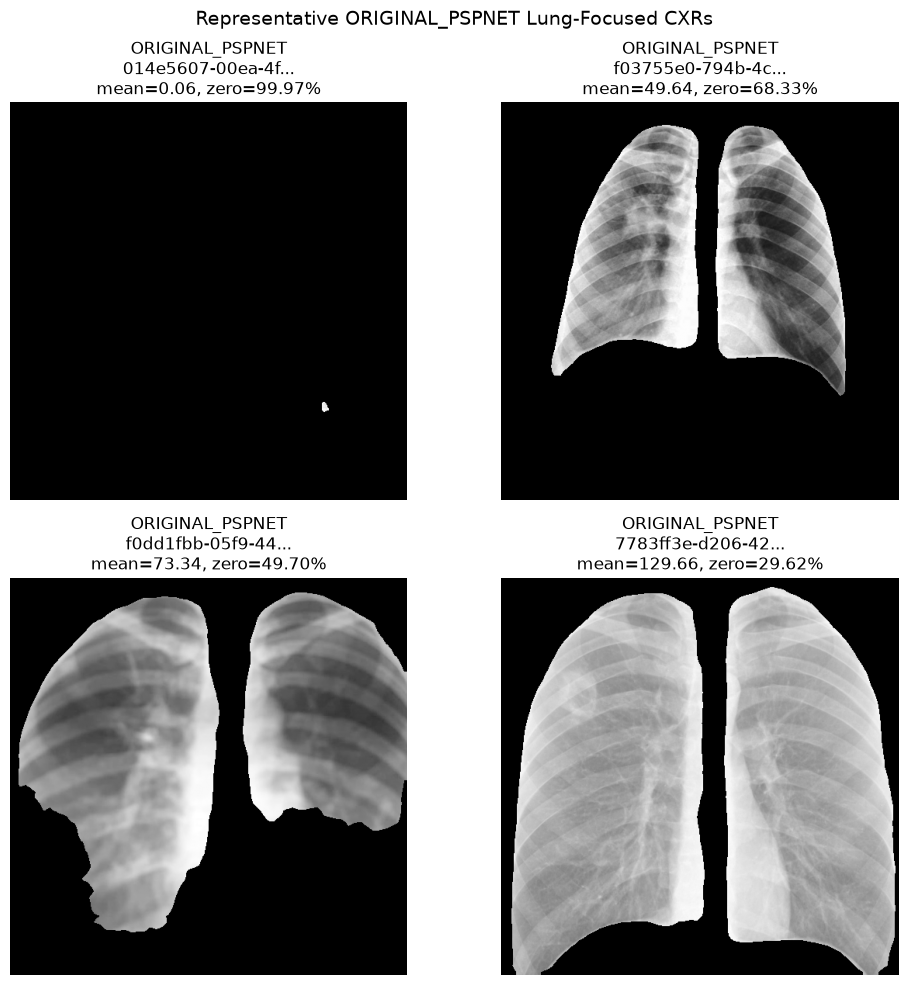


DISPLAYING ALL 21 16BIT_RECOVERY IMAGES


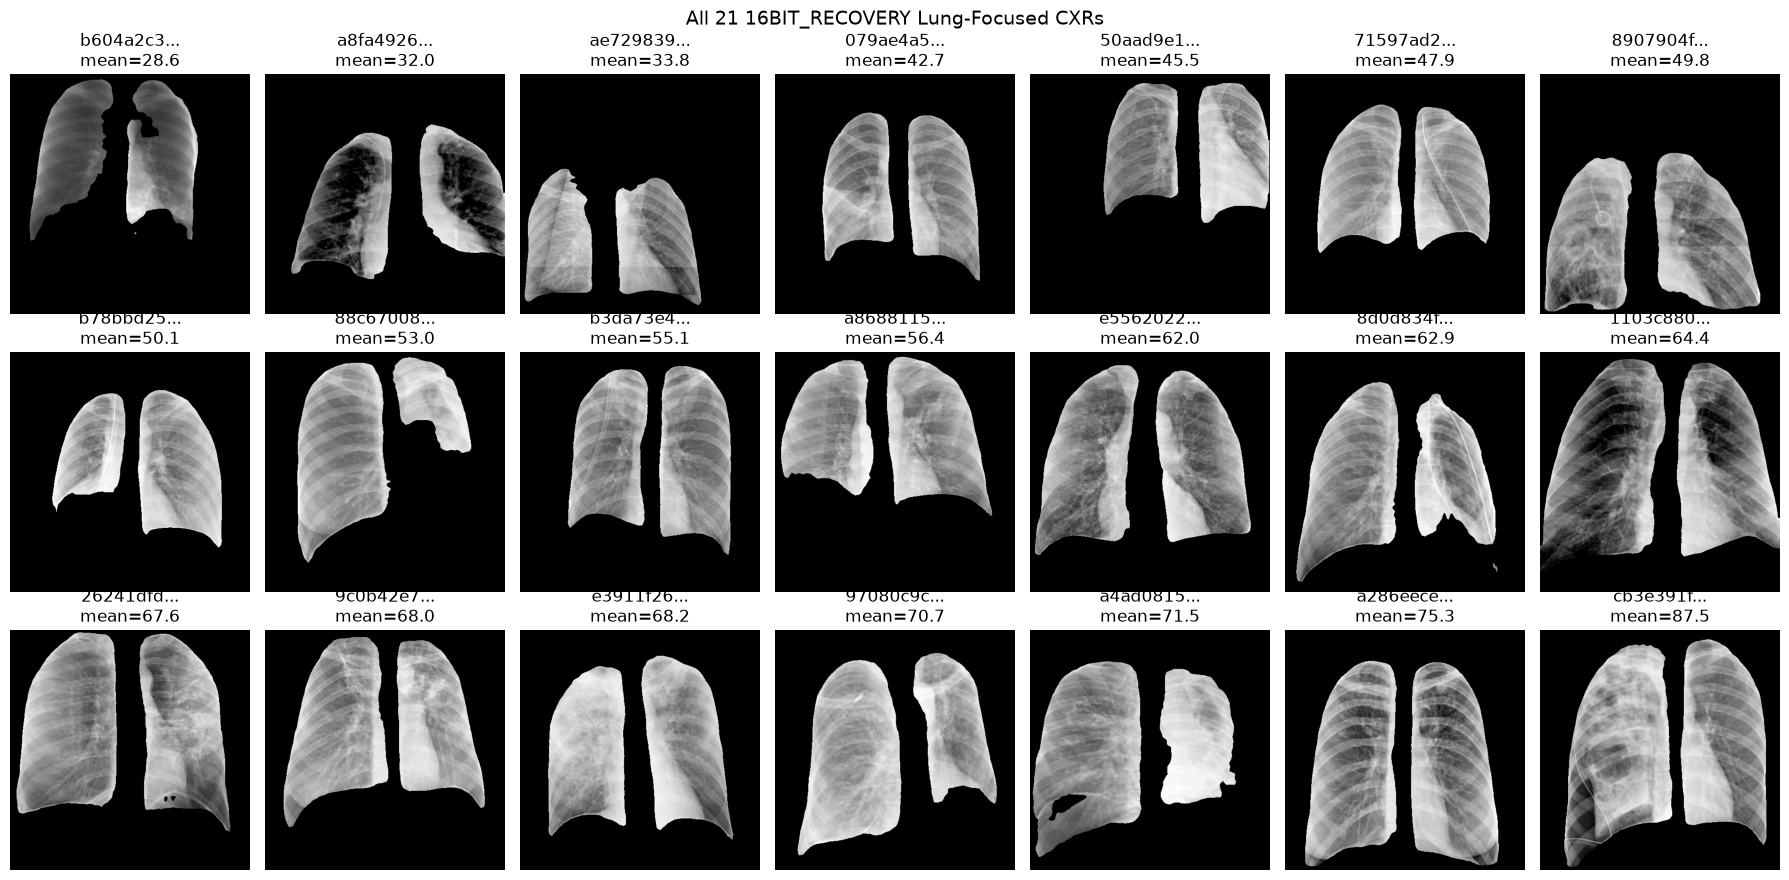


PIXEL INTENSITY DISTRIBUTION


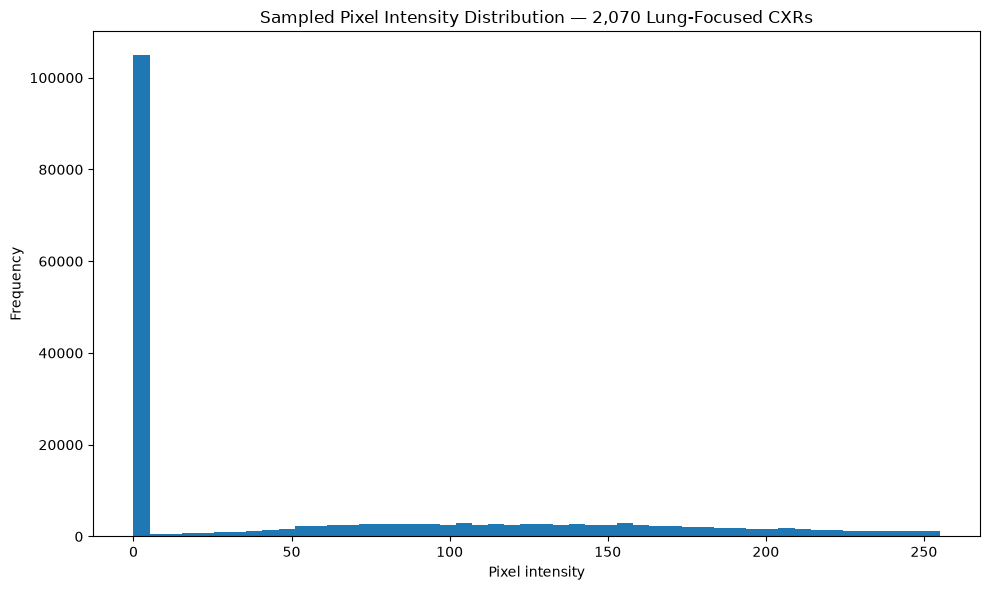

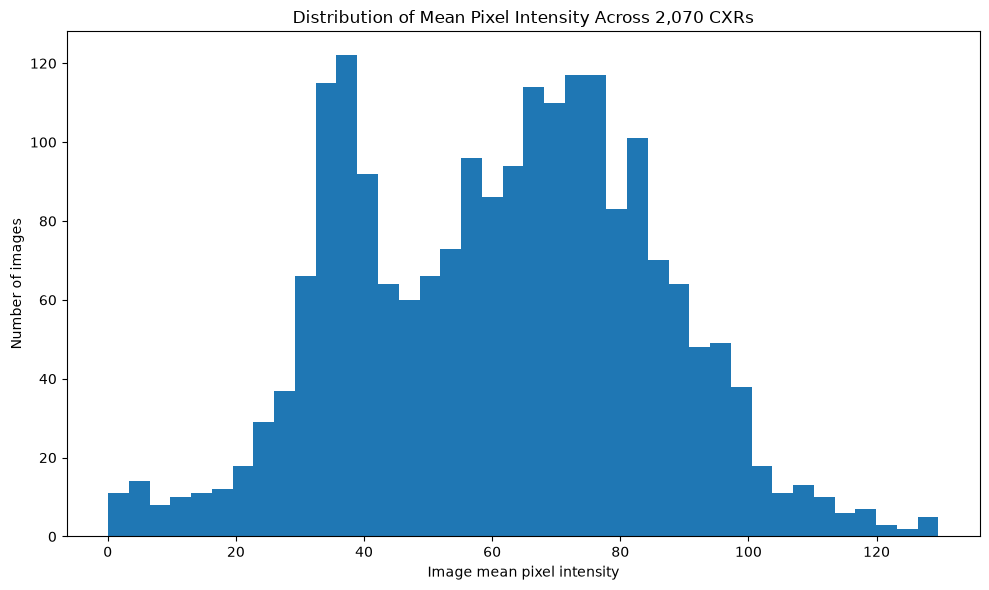

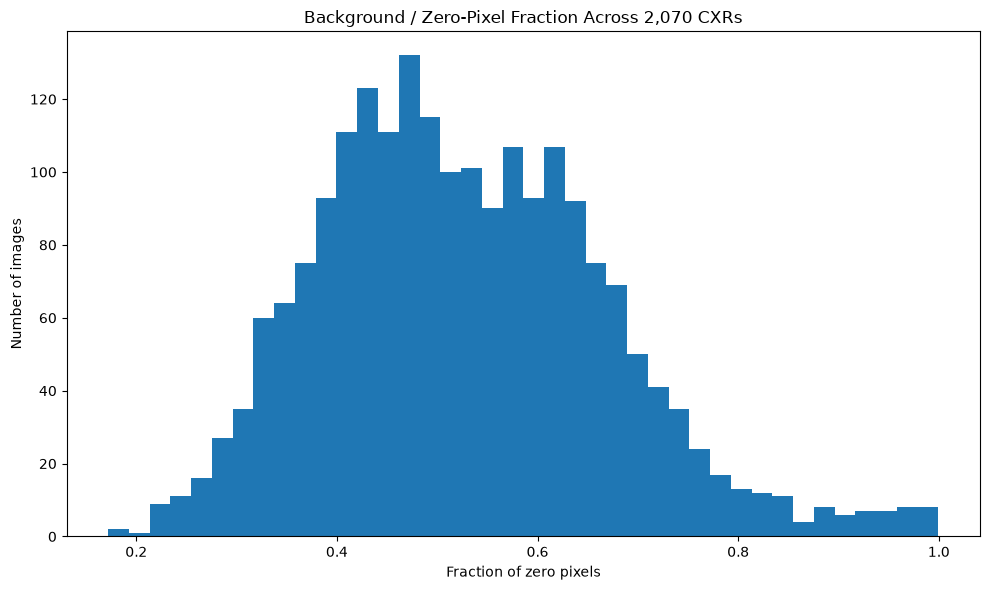


STATISTICAL EXTREME CASES — DIAGNOSTIC ONLY

Lowest image means:
                                                   stem      source_type  \
15    014e5607-00ea-4ff1-bcd5-15290bf02cf3_c4f27f84e474  ORIGINAL_PSPNET   
376   2e43670b-e0a1-4ce5-817b-30774639e04d_7606021d201c  ORIGINAL_PSPNET   
603   4b052613-b0ce-44e0-8a7c-66dbe7202cce_6a7cc2b4cf72  ORIGINAL_PSPNET   
746   5ce165f7-f161-41f4-bf14-01068f1aff83_a6d152b6db9f  ORIGINAL_PSPNET   
1308  a2f2c4ab-a488-4118-bd13-b0ae4ade7f0c_07c9c5db327a  ORIGINAL_PSPNET   
1033  8254bbf1-1b73-4014-af21-25c51345b675_b9a742b7414e  ORIGINAL_PSPNET   
400   30bf6af5-6937-4ead-bca6-a3c184460c59_2d720509c160  ORIGINAL_PSPNET   
2061  ff335a84-a6e0-498a-b375-0838257205b3_62f0fe42ed18  ORIGINAL_PSPNET   
991   7bae3ead-8e6a-4ade-8d17-b232b7730ca7_1c97c9e7f5aa  ORIGINAL_PSPNET   
1829  e2cef347-c884-4154-9a57-a79677720a08_bd14f0c80fa1  ORIGINAL_PSPNET   

          mean        std  zero_fraction  bbox_area_fraction  
15    0.061623   3.464036       0.

In [3]:
# ============================================================
# NOTEBOOK 08
# CELL 3 — CXR VISUAL + DISTRIBUTION SANITY QC
# ============================================================
#
# PURPOSE:
#   Perform a final visual and statistical sanity check on the
#   2,070 lung-focused CXR images before CoAtNet preprocessing.
#
# IMPORTANT:
#   - Diagnostic only
#   - No image modification
#   - No resizing
#   - No normalization
#   - No augmentation
#   - No deletion
#
# CHECKS:
#   1. Representative image visualization
#   2. ORIGINAL_PSPNET vs 16BIT_RECOVERY comparison
#   3. Pixel intensity distributions
#   4. Zero/background fraction
#   5. Non-zero bounding box
#   6. Potentially unusual images
#   7. Final visual QC summary
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


print("=" * 80)
print("NOTEBOOK 08 — CELL 3")
print("CXR VISUAL + DISTRIBUTION SANITY QC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

FINAL_CXR_DIR = (
    NOTEBOOK08_DIR /
    "Final_2070_Lung_Focused_CXR"
)

MANIFEST_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2070_CXR_Manifest.csv"
)

IMAGE_QC_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_CXR_Image_Integrity_QC.csv"
)


if not FINAL_CXR_DIR.exists():

    raise FileNotFoundError(
        f"Final CXR directory not found:\n{FINAL_CXR_DIR}"
    )


if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST_PATH}"
    )


if not IMAGE_QC_PATH.exists():

    raise FileNotFoundError(
        f"Image QC file not found:\n{IMAGE_QC_PATH}"
    )


# ============================================================
# 2. LOAD DATA
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

image_qc = pd.read_csv(
    IMAGE_QC_PATH
)


print()
print("Manifest records:", len(manifest))
print("Image QC records:", len(image_qc))


if len(manifest) != 2070:

    raise RuntimeError(
        f"Expected 2070 manifest records, "
        f"found {len(manifest)}."
    )


if len(image_qc) != 2070:

    raise RuntimeError(
        f"Expected 2070 image QC records, "
        f"found {len(image_qc)}."
    )


# ============================================================
# 3. MERGE MANIFEST + IMAGE QC
# ============================================================

required_manifest_columns = [
    "stem",
    "source_type"
]

for col in required_manifest_columns:

    if col not in manifest.columns:

        raise RuntimeError(
            f"Required manifest column missing: {col}"
        )


required_qc_columns = [
    "stem",
    "mode",
    "width",
    "height",
    "min",
    "max",
    "mean",
    "std",
    "median",
    "p01",
    "p99"
]

for col in required_qc_columns:

    if col not in image_qc.columns:

        raise RuntimeError(
            f"Required image QC column missing: {col}"
        )


analysis_df = manifest[
    [
        "stem",
        "source_type"
    ]
].merge(
    image_qc,
    on="stem",
    how="inner",
    validate="one_to_one"
)


print()
print(
    "Merged analysis records:",
    len(analysis_df)
)


if len(analysis_df) != 2070:

    raise RuntimeError(
        "Manifest ↔ image QC merge did not produce "
        "exactly 2,070 records."
    )


# ============================================================
# 4. SOURCE TYPE DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("SOURCE TYPE DISTRIBUTION")
print("=" * 80)

print(
    analysis_df[
        "source_type"
    ]
    .value_counts(
        dropna=False
    )
)


expected_source_counts = {
    "ORIGINAL_PSPNET": 2049,
    "16BIT_RECOVERY": 21
}


actual_source_counts = (
    analysis_df[
        "source_type"
    ]
    .value_counts()
    .to_dict()
)


for source_type, expected_count in (
    expected_source_counts.items()
):

    actual_count = (
        actual_source_counts
        .get(source_type, 0)
    )

    if actual_count != expected_count:

        raise RuntimeError(
            f"Unexpected count for "
            f"{source_type}: "
            f"expected {expected_count}, "
            f"found {actual_count}."
        )


# ============================================================
# 5. COMPUTE ADDITIONAL IMAGE STATISTICS
# ============================================================
#
# These statistics are calculated from the already-created
# 512x512 lung-focused images.
#
# NOTHING IS WRITTEN BACK TO THE IMAGES.
# ============================================================

print()
print("=" * 80)
print("COMPUTING ADDITIONAL IMAGE STATISTICS")
print("=" * 80)


additional_rows = []


for idx, row in enumerate(
    analysis_df.itertuples(index=False),
    start=1
):

    stem = row.stem

    path = (
        FINAL_CXR_DIR /
        f"{stem}.png"
    )


    if not path.exists():

        raise FileNotFoundError(
            f"Image not found:\n{path}"
        )


    with Image.open(path) as img:

        arr = np.asarray(
            img
        ).astype(
            np.float32
        )


    # --------------------------------------------------------
    # Basic pixel counts
    # --------------------------------------------------------

    total_pixels = arr.size

    zero_pixels = int(
        np.sum(
            arr == 0
        )
    )

    nonzero_pixels = int(
        np.sum(
            arr > 0
        )
    )


    zero_fraction = (
        zero_pixels /
        total_pixels
    )

    nonzero_fraction = (
        nonzero_pixels /
        total_pixels
    )


    # --------------------------------------------------------
    # Non-zero bounding box
    # --------------------------------------------------------

    nonzero_coords = np.argwhere(
        arr > 0
    )


    if len(nonzero_coords) > 0:

        y_min = int(
            nonzero_coords[:, 0].min()
        )

        y_max = int(
            nonzero_coords[:, 0].max()
        )

        x_min = int(
            nonzero_coords[:, 1].min()
        )

        x_max = int(
            nonzero_coords[:, 1].max()
        )

        bbox_height = (
            y_max - y_min + 1
        )

        bbox_width = (
            x_max - x_min + 1
        )

        bbox_area_fraction = (
            bbox_height *
            bbox_width
        ) / (
            arr.shape[0] *
            arr.shape[1]
        )

    else:

        y_min = np.nan
        y_max = np.nan
        x_min = np.nan
        x_max = np.nan

        bbox_height = 0
        bbox_width = 0
        bbox_area_fraction = 0.0


    additional_rows.append({

        "stem":
            stem,

        "zero_fraction":
            float(zero_fraction),

        "nonzero_fraction":
            float(nonzero_fraction),

        "bbox_x_min":
            x_min,

        "bbox_x_max":
            x_max,

        "bbox_y_min":
            y_min,

        "bbox_y_max":
            y_max,

        "bbox_width":
            bbox_width,

        "bbox_height":
            bbox_height,

        "bbox_area_fraction":
            float(bbox_area_fraction)

    })


    if (
        idx % 250 == 0
        or
        idx == len(analysis_df)
    ):

        print(
            f"Processed {idx}/2070"
        )


additional_df = pd.DataFrame(
    additional_rows
)


# ============================================================
# 6. MERGE ADDITIONAL STATISTICS
# ============================================================

analysis_df = analysis_df.merge(
    additional_df,
    on="stem",
    how="left",
    validate="one_to_one"
)


if len(analysis_df) != 2070:

    raise RuntimeError(
        "Statistics merge failed."
    )


# ============================================================
# 7. BACKGROUND / NONZERO SUMMARY
# ============================================================

print()
print("=" * 80)
print("BACKGROUND / NONZERO PIXEL SUMMARY")
print("=" * 80)

print(
    analysis_df[
        [
            "zero_fraction",
            "nonzero_fraction",
            "bbox_area_fraction"
        ]
    ]
    .describe()
)


# ============================================================
# 8. COMPARE SOURCE TYPES
# ============================================================

print()
print("=" * 80)
print("SOURCE-TYPE STATISTICAL COMPARISON")
print("=" * 80)


comparison_columns = [
    "mean",
    "std",
    "median",
    "p01",
    "p99",
    "zero_fraction",
    "nonzero_fraction",
    "bbox_area_fraction"
]


source_comparison = (
    analysis_df
    .groupby(
        "source_type"
    )[
        comparison_columns
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


print(
    source_comparison
)


# ============================================================
# 9. SAVE DISTRIBUTION QC
# ============================================================

DISTRIBUTION_QC_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_CXR_Visual_Distribution_QC.csv"
)

analysis_df.to_csv(
    DISTRIBUTION_QC_PATH,
    index=False
)


print()
print(
    "Distribution QC saved:"
)

print(
    DISTRIBUTION_QC_PATH
)


# ============================================================
# 10. SELECT REPRESENTATIVE IMAGES
# ============================================================
#
# Deterministic selection.
#
# We select:
#   - 4 ORIGINAL_PSPNET images
#   - 4 16BIT_RECOVERY images
#
# For the large original group, selection is based on
# intensity statistics:
#   low mean
#   low-middle mean
#   high-middle mean
#   high mean
#
# All 21 recovery images will additionally be visualized
# in a separate grid.
# ============================================================

original_df = (
    analysis_df[
        analysis_df[
            "source_type"
        ] == "ORIGINAL_PSPNET"
    ]
    .sort_values(
        "mean"
    )
    .reset_index(
        drop=True
    )
)


if len(original_df) != 2049:

    raise RuntimeError(
        "Expected 2,049 ORIGINAL_PSPNET images."
    )


original_positions = [
    0,
    len(original_df) // 3,
    (2 * len(original_df)) // 3,
    len(original_df) - 1
]


original_samples = (
    original_df
    .iloc[
        original_positions
    ]
)


recovery_df = (
    analysis_df[
        analysis_df[
            "source_type"
        ] == "16BIT_RECOVERY"
    ]
    .sort_values(
        "mean"
    )
    .reset_index(
        drop=True
    )
)


if len(recovery_df) != 21:

    raise RuntimeError(
        "Expected 21 16BIT_RECOVERY images."
    )


# ============================================================
# 11. VISUALIZE REPRESENTATIVE ORIGINAL IMAGES
# ============================================================

print()
print("=" * 80)
print("DISPLAYING REPRESENTATIVE ORIGINAL_PSPNET IMAGES")
print("=" * 80)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10)
)

axes = axes.ravel()


for ax, (_, row) in zip(
    axes,
    original_samples.iterrows()
):

    stem = row["stem"]

    path = (
        FINAL_CXR_DIR /
        f"{stem}.png"
    )


    with Image.open(path) as img:

        arr = np.asarray(img)


    ax.imshow(
        arr,
        cmap="gray"
    )

    ax.set_title(
        f"ORIGINAL_PSPNET\n"
        f"{stem[:16]}...\n"
        f"mean={row['mean']:.2f}, "
        f"zero={row['zero_fraction']:.2%}"
    )

    ax.axis(
        "off"
    )


plt.suptitle(
    "Representative ORIGINAL_PSPNET Lung-Focused CXRs",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. VISUALIZE ALL 21 RECOVERY IMAGES
# ============================================================

print()
print("=" * 80)
print("DISPLAYING ALL 21 16BIT_RECOVERY IMAGES")
print("=" * 80)


fig, axes = plt.subplots(
    3,
    7,
    figsize=(18, 9)
)

axes = axes.ravel()


for ax, (_, row) in zip(
    axes,
    recovery_df.iterrows()
):

    stem = row["stem"]

    path = (
        FINAL_CXR_DIR /
        f"{stem}.png"
    )


    with Image.open(path) as img:

        arr = np.asarray(img)


    ax.imshow(
        arr,
        cmap="gray"
    )

    ax.set_title(
        f"{stem[:8]}...\n"
        f"mean={row['mean']:.1f}"
    )

    ax.axis(
        "off"
    )


# Hide any unused axes
for ax in axes[len(recovery_df):]:

    ax.axis(
        "off"
    )


plt.suptitle(
    "All 21 16BIT_RECOVERY Lung-Focused CXRs",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. PIXEL INTENSITY DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("PIXEL INTENSITY DISTRIBUTION")
print("=" * 80)


# ------------------------------------------------------------
# Sample images to keep computation manageable.
# The statistics above already use all 2,070 images.
# ------------------------------------------------------------

rng = np.random.default_rng(
    seed=42
)

sample_size = min(
    100,
    len(analysis_df)
)

sample_df = (
    analysis_df
    .sample(
        n=sample_size,
        random_state=42
    )
)


sample_pixels = []


for _, row in sample_df.iterrows():

    path = (
        FINAL_CXR_DIR /
        f"{row['stem']}.png"
    )

    with Image.open(path) as img:

        arr = np.asarray(
            img
        ).astype(
            np.float32
        )


    # Randomly sample up to 2,000 pixels
    # from each image.

    flat = arr.ravel()

    n_pixels = min(
        2000,
        len(flat)
    )

    pixel_indices = rng.choice(
        len(flat),
        size=n_pixels,
        replace=False
    )

    sample_pixels.extend(
        flat[
            pixel_indices
        ]
        .tolist()
    )


sample_pixels = np.asarray(
    sample_pixels,
    dtype=np.float32
)


plt.figure(
    figsize=(10, 6)
)

plt.hist(
    sample_pixels,
    bins=50
)

plt.xlabel(
    "Pixel intensity"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Sampled Pixel Intensity Distribution — 2,070 Lung-Focused CXRs"
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. DISTRIBUTION OF IMAGE MEANS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    analysis_df[
        "mean"
    ],
    bins=40
)

plt.xlabel(
    "Image mean pixel intensity"
)

plt.ylabel(
    "Number of images"
)

plt.title(
    "Distribution of Mean Pixel Intensity Across 2,070 CXRs"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. DISTRIBUTION OF ZERO/BACKGROUND FRACTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    analysis_df[
        "zero_fraction"
    ],
    bins=40
)

plt.xlabel(
    "Fraction of zero pixels"
)

plt.ylabel(
    "Number of images"
)

plt.title(
    "Background / Zero-Pixel Fraction Across 2,070 CXRs"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. IDENTIFY EXTREME STATISTICAL CASES
# ============================================================
#
# These are NOT automatically excluded.
#
# They are only diagnostic candidates for visual inspection.
# ============================================================

print()
print("=" * 80)
print("STATISTICAL EXTREME CASES — DIAGNOSTIC ONLY")
print("=" * 80)


print()
print("Lowest image means:")

print(
    analysis_df[
        [
            "stem",
            "source_type",
            "mean",
            "std",
            "zero_fraction",
            "bbox_area_fraction"
        ]
    ]
    .sort_values(
        "mean"
    )
    .head(10)
)


print()
print("Highest image means:")

print(
    analysis_df[
        [
            "stem",
            "source_type",
            "mean",
            "std",
            "zero_fraction",
            "bbox_area_fraction"
        ]
    ]
    .sort_values(
        "mean",
        ascending=False
    )
    .head(10)
)


print()
print("Lowest non-zero fraction:")

print(
    analysis_df[
        [
            "stem",
            "source_type",
            "mean",
            "std",
            "zero_fraction",
            "nonzero_fraction",
            "bbox_area_fraction"
        ]
    ]
    .sort_values(
        "nonzero_fraction"
    )
    .head(10)
)


print()
print("Highest non-zero fraction:")

print(
    analysis_df[
        [
            "stem",
            "source_type",
            "mean",
            "std",
            "zero_fraction",
            "nonzero_fraction",
            "bbox_area_fraction"
        ]
    ]
    .sort_values(
        "nonzero_fraction",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 17. FINAL TECHNICAL ASSERTIONS
# ============================================================

print()
print("=" * 80)
print("FINAL TECHNICAL ASSERTIONS")
print("=" * 80)


# All images must be grayscale
mode_counts = (
    analysis_df[
        "mode"
    ]
    .value_counts()
    .to_dict()
)

if mode_counts != {"L": 2070}:

    raise RuntimeError(
        f"Unexpected image modes:\n{mode_counts}"
    )


# All images must be 512x512
dimension_ok = (
    (analysis_df["width"] == 512)
    &
    (analysis_df["height"] == 512)
)

if not dimension_ok.all():

    raise RuntimeError(
        "Not all images are 512x512."
    )


# No NaN / Inf
if (
    analysis_df["nan_count"].sum()
    != 0
):

    raise RuntimeError(
        "NaN values detected."
    )


if (
    analysis_df["inf_count"].sum()
    != 0
):

    raise RuntimeError(
        "Inf values detected."
    )


# Source counts
if (
    (
        analysis_df[
            "source_type"
        ] == "ORIGINAL_PSPNET"
    ).sum()
    != 2049
):

    raise RuntimeError(
        "ORIGINAL_PSPNET count mismatch."
    )


if (
    (
        analysis_df[
            "source_type"
        ] == "16BIT_RECOVERY"
    ).sum()
    != 21
):

    raise RuntimeError(
        "16BIT_RECOVERY count mismatch."
    )


# ============================================================
# 18. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 CELL 3 — FINAL STATUS")
print("=" * 80)

print()
print("Total images analyzed:", len(analysis_df))
print("Original PSPNet:", (
    analysis_df["source_type"]
    .eq("ORIGINAL_PSPNET")
    .sum()
))
print("16-bit recovery:", (
    analysis_df["source_type"]
    .eq("16BIT_RECOVERY")
    .sum()
))

print()
print("All images grayscale: PASS")
print("All images 512x512: PASS")
print("No NaN: PASS")
print("No Inf: PASS")
print("Visual diagnostic completed: PASS")
print("Distribution diagnostic completed: PASS")

print()
print("Distribution QC:")
print(
    DISTRIBUTION_QC_PATH
)

print()
print("=" * 80)
print("CELL 3 — CXR VISUAL + DISTRIBUTION SANITY QC: PASS")
print("=" * 80)

print()
print("IMPORTANT:")
print(
    "No images were modified, resized, normalized, "
    "augmented, deleted, or overwritten."
)

NOTEBOOK 08 — CELL 3A
EXTREME CXR CONTENT / ANATOMICAL QC

QC records: 2070

SOURCE TYPE COUNTS
{'ORIGINAL_PSPNET': 2049, '16BIT_RECOVERY': 21}

10 IMAGES WITH LOWEST NON-ZERO FRACTION
                                             stem     source_type     mean       std  median  zero_fraction  nonzero_fraction  bbox_width  bbox_height  bbox_area_fraction
014e5607-00ea-4ff1-bcd5-15290bf02cf3_c4f27f84e474 ORIGINAL_PSPNET 0.061623  3.464036     0.0       0.999683          0.000317           9           13            0.000446
4b052613-b0ce-44e0-8a7c-66dbe7202cce_6a7cc2b4cf72 ORIGINAL_PSPNET 0.148449  4.775532     0.0       0.999031          0.000969          80           67            0.020447
2e43670b-e0a1-4ce5-817b-30774639e04d_7606021d201c ORIGINAL_PSPNET 0.135155  3.170354     0.0       0.998055          0.001945          14           48            0.002563
5ce165f7-f161-41f4-bf14-01068f1aff83_a6d152b6db9f ORIGINAL_PSPNET 0.312561  5.643568     0.0       0.996933          0.003067      

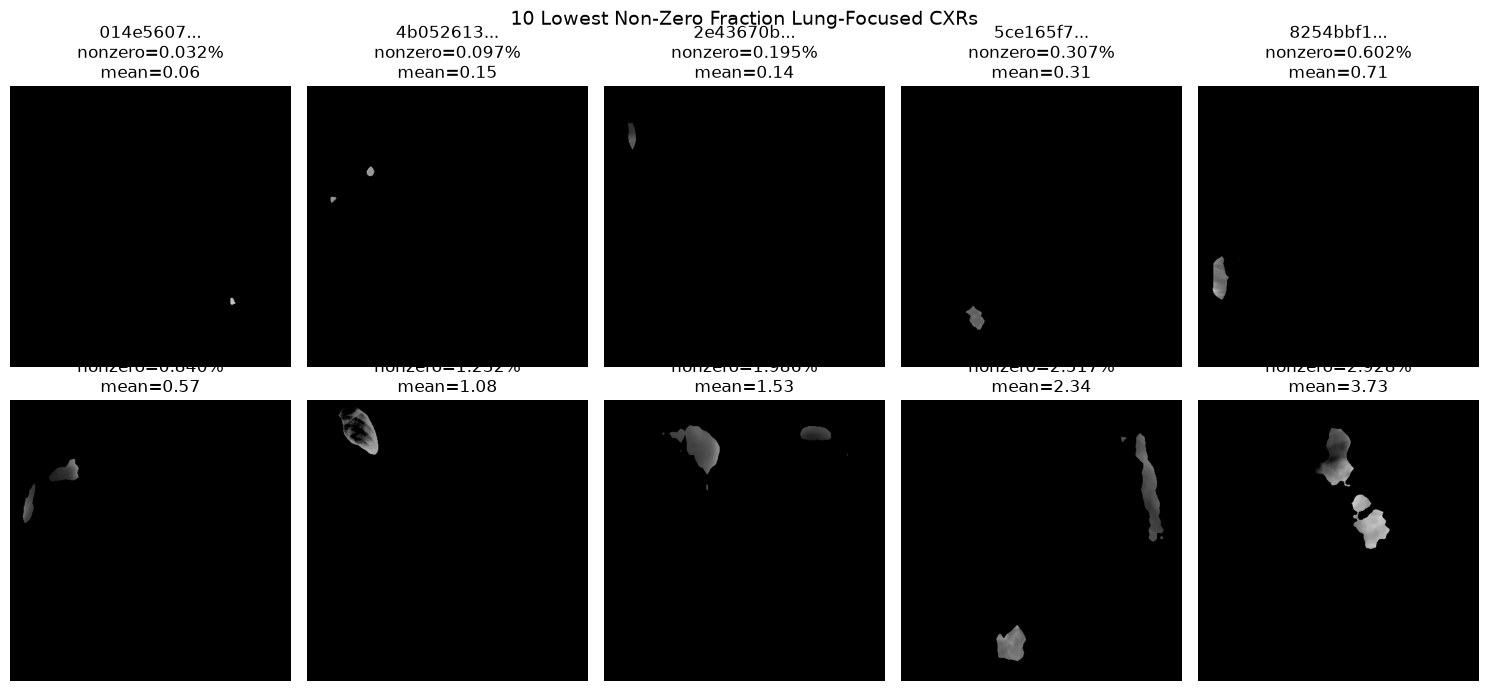


VISUAL QC — SMALLEST RETAINED BOUNDING BOX


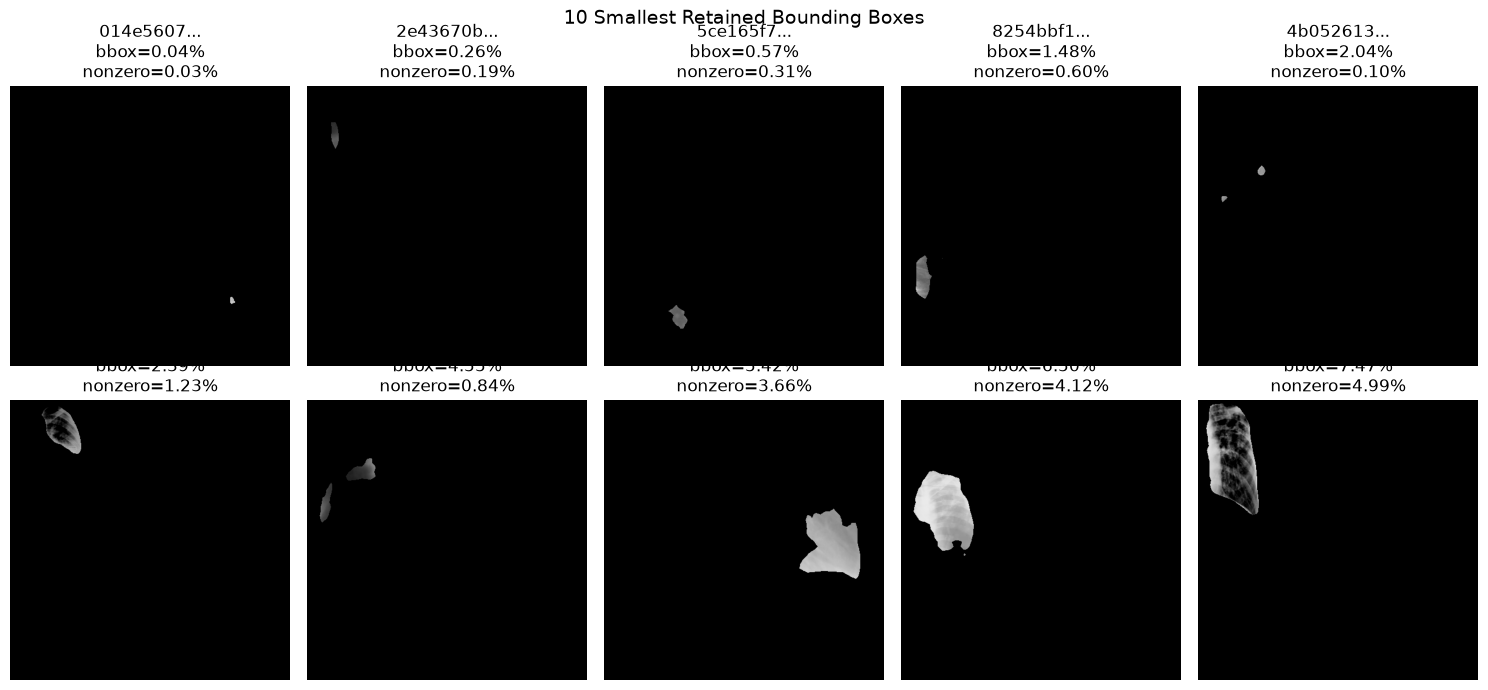


VISUAL QC — HIGHEST CONTENT IMAGES


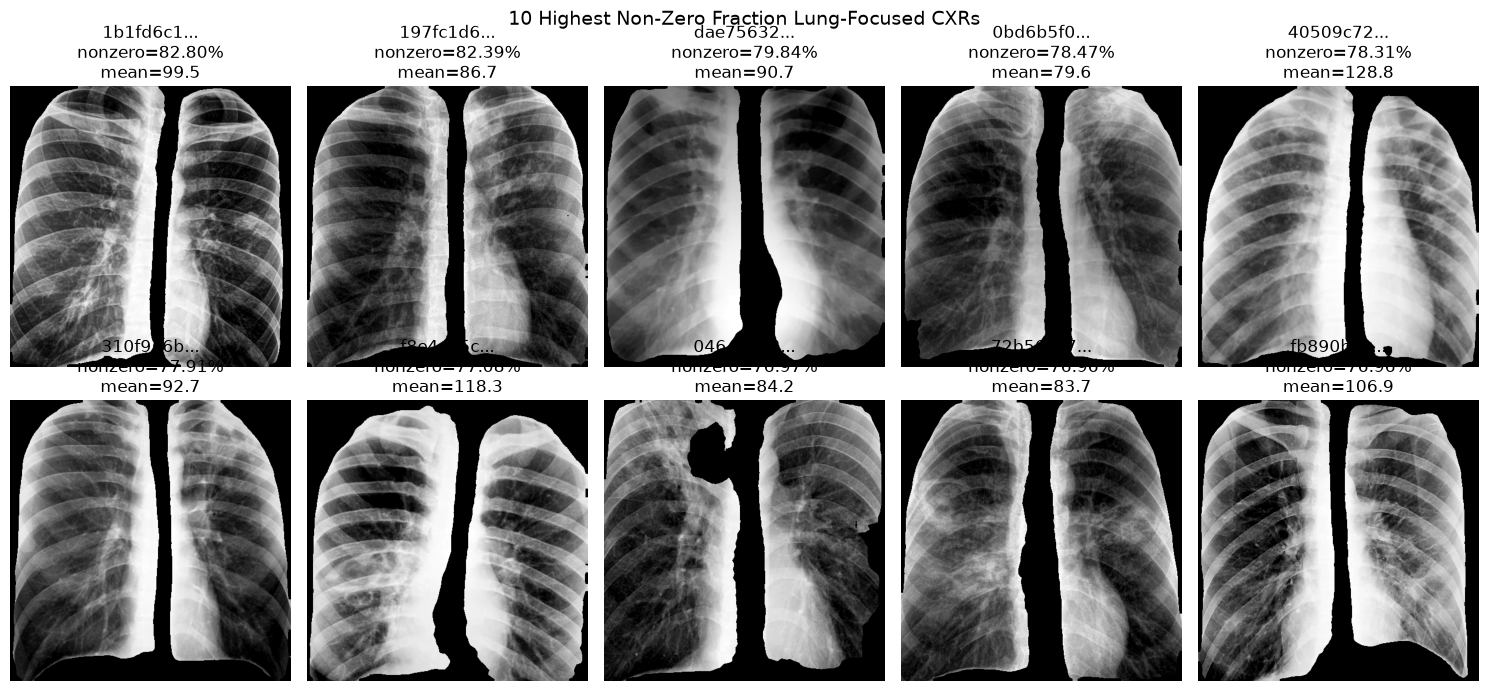


ORIGINAL vs 16BIT RECOVERY CONTENT COMPARISON
                 mean                                                          \
                count       mean        std     median        min         max   
source_type                                                                     
16BIT_RECOVERY     21  56.826037  15.233055  56.432495  28.631039   87.460358   
ORIGINAL_PSPNET  2049  61.341961  23.728507  63.207245   0.061623  129.662140   

                  std                                   ... nonzero_fraction  \
                count       mean        std     median  ...              std   
source_type                                             ...                    
16BIT_RECOVERY     21  76.408583  10.740903  77.408081  ...         0.090064   
ORIGINAL_PSPNET  2049  71.690820  17.244898  74.757210  ...         0.142907   

                                              bbox_area_fraction            \
                   median       min       max              count    

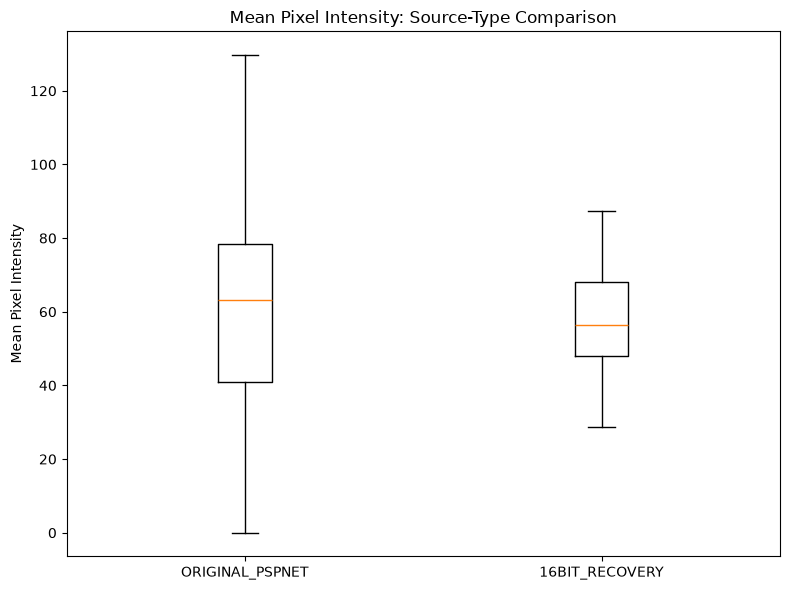

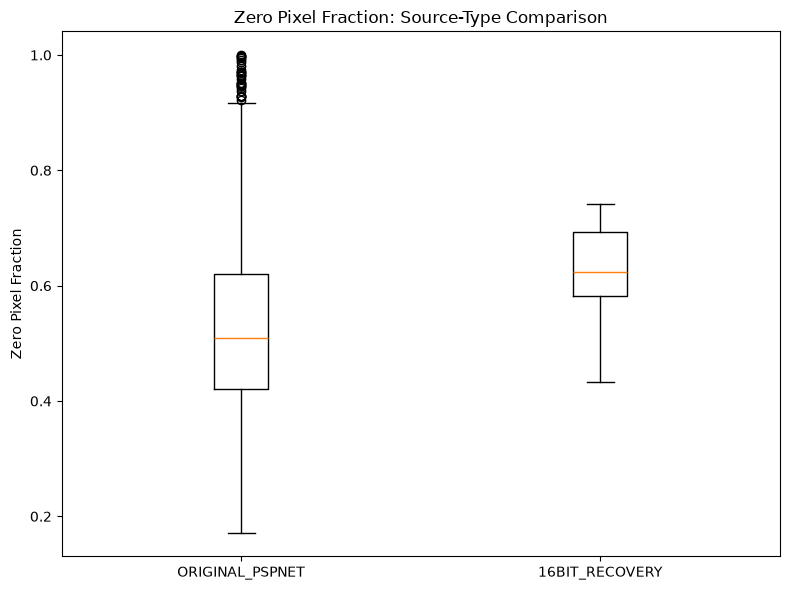

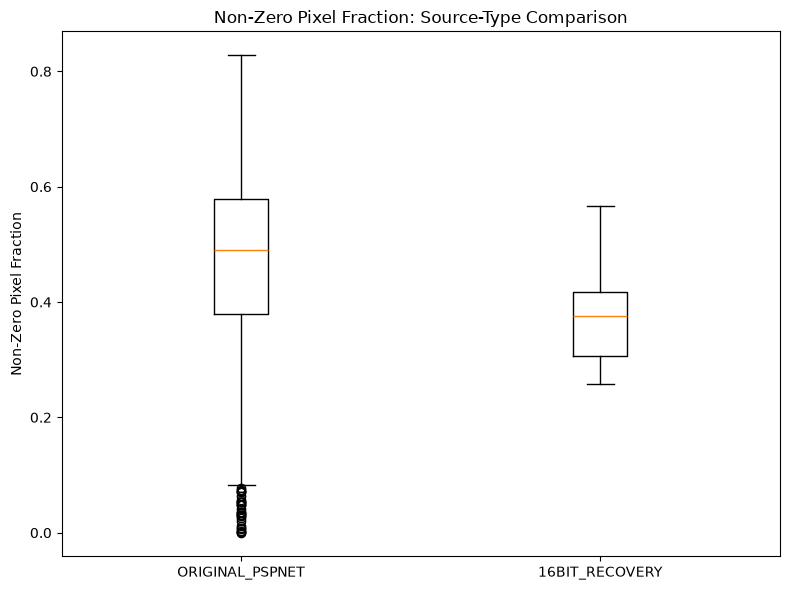

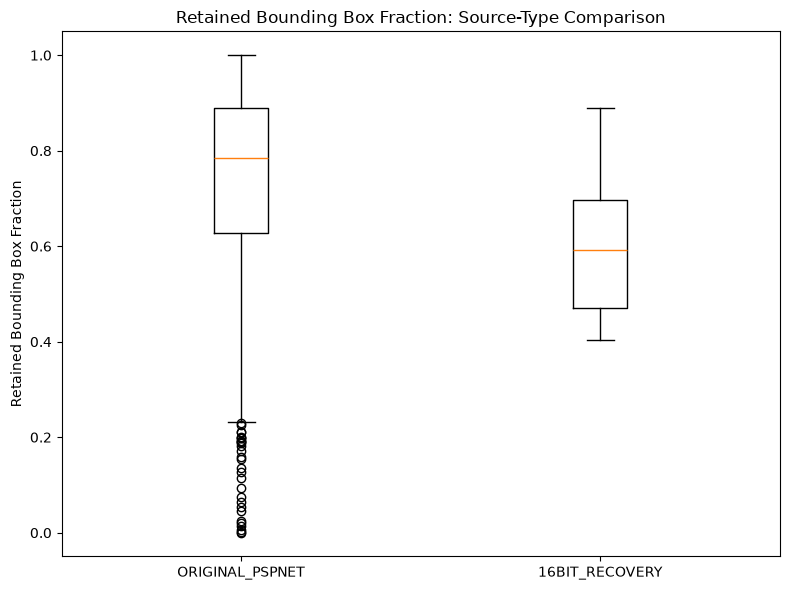


EXTREME CONTENT COUNTS
zero_fraction >= 0.95: 19
zero_fraction >= 0.98: 8
zero_fraction >= 0.99: 6
nonzero_fraction <= 0.05: 19
nonzero_fraction <= 0.02: 8
nonzero_fraction <= 0.01: 6
bbox_area_fraction <= 0.10: 11
bbox_area_fraction <= 0.05: 7

Extreme-content review queue: 12
Review queue:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\TB_Portals_March2025_Notebook08_Extreme_Content_Review_Queue.csv

FINAL TECHNICAL CHECKS

NOTEBOOK 08 CELL 3A — FINAL STATUS

Images analyzed: 2070
Original PSPNet: 2049
16-bit recovery: 21
Extreme-content review queue: 12

No automatic exclusions were made.

Review queue:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\TB_Portals_March2025_Notebook08_Extreme_Content_Review_Queue.csv

CELL 3A — EXTREME CXR CONTENT QC: COMPLETE


In [5]:
# ============================================================
# NOTEBOOK 08
# CELL 3A — EXTREME CXR CONTENT / ANATOMICAL QC
# ============================================================
#
# PURPOSE:
#   Investigate statistically extreme lung-focused CXRs before
#   CoAtNet preprocessing.
#
# IMPORTANT:
#   Diagnostic only.
#
#   NO:
#     - image modification
#     - resizing
#     - normalization
#     - augmentation
#     - deletion
#     - overwriting
#
# NO IMAGE IS AUTOMATICALLY EXCLUDED BY THIS CELL.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


print("=" * 80)
print("NOTEBOOK 08 — CELL 3A")
print("EXTREME CXR CONTENT / ANATOMICAL QC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

FINAL_CXR_DIR = (
    NOTEBOOK08_DIR /
    "Final_2070_Lung_Focused_CXR"
)

DISTRIBUTION_QC_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_CXR_Visual_Distribution_QC.csv"
)


if not FINAL_CXR_DIR.exists():
    raise FileNotFoundError(
        f"Final CXR directory not found:\n{FINAL_CXR_DIR}"
    )


if not DISTRIBUTION_QC_PATH.exists():
    raise FileNotFoundError(
        f"Distribution QC file not found:\n{DISTRIBUTION_QC_PATH}"
    )


# ============================================================
# 2. LOAD QC DATA
# ============================================================

analysis_df = pd.read_csv(
    DISTRIBUTION_QC_PATH
)

print()
print(
    "QC records:",
    len(analysis_df)
)


if len(analysis_df) != 2070:
    raise RuntimeError(
        f"Expected 2070 records, found {len(analysis_df)}."
    )


# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "stem",
    "source_type",
    "mean",
    "std",
    "median",
    "zero_fraction",
    "nonzero_fraction",
    "bbox_width",
    "bbox_height",
    "bbox_area_fraction"
]


missing_columns = [
    col
    for col in required_columns
    if col not in analysis_df.columns
]


if missing_columns:
    raise RuntimeError(
        f"Missing required columns: {missing_columns}"
    )


# ============================================================
# 4. VERIFY SOURCE COUNTS
# ============================================================

source_counts = (
    analysis_df[
        "source_type"
    ]
    .value_counts()
    .to_dict()
)

print()
print("=" * 80)
print("SOURCE TYPE COUNTS")
print("=" * 80)

print(source_counts)


if source_counts.get(
    "ORIGINAL_PSPNET",
    0
) != 2049:

    raise RuntimeError(
        "Expected 2049 ORIGINAL_PSPNET images."
    )


if source_counts.get(
    "16BIT_RECOVERY",
    0
) != 21:

    raise RuntimeError(
        "Expected 21 16BIT_RECOVERY images."
    )


# ============================================================
# 5. EXTREME CASE TABLES
# ============================================================

lowest_nonzero = (
    analysis_df
    .sort_values(
        [
            "nonzero_fraction",
            "mean"
        ],
        ascending=[
            True,
            True
        ]
    )
    .head(10)
    .copy()
)


highest_zero = (
    analysis_df
    .sort_values(
        [
            "zero_fraction",
            "mean"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(10)
    .copy()
)


smallest_bbox = (
    analysis_df
    .sort_values(
        [
            "bbox_area_fraction",
            "nonzero_fraction"
        ],
        ascending=[
            True,
            True
        ]
    )
    .head(10)
    .copy()
)


highest_content = (
    analysis_df
    .sort_values(
        [
            "nonzero_fraction",
            "mean"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(10)
    .copy()
)


display_columns = [
    "stem",
    "source_type",
    "mean",
    "std",
    "median",
    "zero_fraction",
    "nonzero_fraction",
    "bbox_width",
    "bbox_height",
    "bbox_area_fraction"
]


# ============================================================
# 6. PRINT LOWEST NON-ZERO FRACTION
# ============================================================

print()
print("=" * 80)
print("10 IMAGES WITH LOWEST NON-ZERO FRACTION")
print("=" * 80)

print(
    lowest_nonzero[
        display_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# 7. PRINT HIGHEST ZERO FRACTION
# ============================================================

print()
print("=" * 80)
print("10 IMAGES WITH HIGHEST ZERO FRACTION")
print("=" * 80)

print(
    highest_zero[
        display_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# 8. PRINT SMALLEST BOUNDING BOX
# ============================================================

print()
print("=" * 80)
print("10 IMAGES WITH SMALLEST RETAINED BOUNDING BOX")
print("=" * 80)

print(
    smallest_bbox[
        display_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# 9. PRINT HIGHEST CONTENT
# ============================================================

print()
print("=" * 80)
print("10 IMAGES WITH HIGHEST NON-ZERO FRACTION")
print("=" * 80)

print(
    highest_content[
        display_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# 10. IMAGE LOADING FUNCTION
# ============================================================

def load_cxr(stem):

    path = (
        FINAL_CXR_DIR /
        f"{stem}.png"
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Image not found:\n{path}"
        )

    with Image.open(path) as img:

        img.load()

        arr = np.asarray(
            img
        )

    return arr


# ============================================================
# 11. VISUALIZE LOWEST NON-ZERO FRACTION
# ============================================================

print()
print("=" * 80)
print("VISUAL QC — LOWEST NON-ZERO FRACTION")
print("=" * 80)


fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

axes = axes.ravel()


for ax, (_, row) in zip(
    axes,
    lowest_nonzero.iterrows()
):

    arr = load_cxr(
        row["stem"]
    )

    ax.imshow(
        arr,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(
        f"{row['stem'][:8]}...\n"
        f"nonzero={row['nonzero_fraction']:.3%}\n"
        f"mean={row['mean']:.2f}"
    )

    ax.axis("off")


fig.suptitle(
    "10 Lowest Non-Zero Fraction Lung-Focused CXRs",
    fontsize=14
)

fig.tight_layout()

plt.show()


# ============================================================
# 12. VISUALIZE SMALLEST BOUNDING BOX
# ============================================================

print()
print("=" * 80)
print("VISUAL QC — SMALLEST RETAINED BOUNDING BOX")
print("=" * 80)


fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

axes = axes.ravel()


for ax, (_, row) in zip(
    axes,
    smallest_bbox.iterrows()
):

    arr = load_cxr(
        row["stem"]
    )

    ax.imshow(
        arr,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(
        f"{row['stem'][:8]}...\n"
        f"bbox={row['bbox_area_fraction']:.2%}\n"
        f"nonzero={row['nonzero_fraction']:.2%}"
    )

    ax.axis("off")


fig.suptitle(
    "10 Smallest Retained Bounding Boxes",
    fontsize=14
)

fig.tight_layout()

plt.show()


# ============================================================
# 13. VISUALIZE HIGHEST CONTENT
# ============================================================

print()
print("=" * 80)
print("VISUAL QC — HIGHEST CONTENT IMAGES")
print("=" * 80)


fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

axes = axes.ravel()


for ax, (_, row) in zip(
    axes,
    highest_content.iterrows()
):

    arr = load_cxr(
        row["stem"]
    )

    ax.imshow(
        arr,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(
        f"{row['stem'][:8]}...\n"
        f"nonzero={row['nonzero_fraction']:.2%}\n"
        f"mean={row['mean']:.1f}"
    )

    ax.axis("off")


fig.suptitle(
    "10 Highest Non-Zero Fraction Lung-Focused CXRs",
    fontsize=14
)

fig.tight_layout()

plt.show()


# ============================================================
# 14. ORIGINAL vs RECOVERY STATISTICS
# ============================================================

print()
print("=" * 80)
print("ORIGINAL vs 16BIT RECOVERY CONTENT COMPARISON")
print("=" * 80)


comparison_columns = [
    "mean",
    "std",
    "median",
    "zero_fraction",
    "nonzero_fraction",
    "bbox_area_fraction"
]


source_summary = (
    analysis_df
    .groupby(
        "source_type"
    )[
        comparison_columns
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


print(
    source_summary
)


# ============================================================
# 15. SOURCE-TYPE BOXPLOTS
# ============================================================
#
# IMPORTANT:
#   Matplotlib version in the user's environment uses
#   `tick_labels`, not the older `labels` argument.
# ============================================================

print()
print("=" * 80)
print("SOURCE-TYPE BOXPLOTS")
print("=" * 80)


metrics = [
    (
        "mean",
        "Mean Pixel Intensity"
    ),
    (
        "zero_fraction",
        "Zero Pixel Fraction"
    ),
    (
        "nonzero_fraction",
        "Non-Zero Pixel Fraction"
    ),
    (
        "bbox_area_fraction",
        "Retained Bounding Box Fraction"
    )
]


for metric, title in metrics:

    original_values = (
        analysis_df[
            analysis_df[
                "source_type"
            ] == "ORIGINAL_PSPNET"
        ][
            metric
        ]
        .dropna()
        .to_numpy()
    )


    recovery_values = (
        analysis_df[
            analysis_df[
                "source_type"
            ] == "16BIT_RECOVERY"
        ][
            metric
        ]
        .dropna()
        .to_numpy()
    )


    fig, ax = plt.subplots(
        figsize=(8, 6)
    )


    ax.boxplot(
        [
            original_values,
            recovery_values
        ],
        tick_labels=[
            "ORIGINAL_PSPNET",
            "16BIT_RECOVERY"
        ]
    )


    ax.set_ylabel(
        title
    )

    ax.set_title(
        f"{title}: Source-Type Comparison"
    )


    fig.tight_layout()

    plt.show()


# ============================================================
# 16. EXTREME CONTENT COUNTS
# ============================================================

print()
print("=" * 80)
print("EXTREME CONTENT COUNTS")
print("=" * 80)


extreme_counts = {

    "zero_fraction >= 0.95":
        int(
            (
                analysis_df[
                    "zero_fraction"
                ] >= 0.95
            ).sum()
        ),

    "zero_fraction >= 0.98":
        int(
            (
                analysis_df[
                    "zero_fraction"
                ] >= 0.98
            ).sum()
        ),

    "zero_fraction >= 0.99":
        int(
            (
                analysis_df[
                    "zero_fraction"
                ] >= 0.99
            ).sum()
        ),

    "nonzero_fraction <= 0.05":
        int(
            (
                analysis_df[
                    "nonzero_fraction"
                ] <= 0.05
            ).sum()
        ),

    "nonzero_fraction <= 0.02":
        int(
            (
                analysis_df[
                    "nonzero_fraction"
                ] <= 0.02
            ).sum()
        ),

    "nonzero_fraction <= 0.01":
        int(
            (
                analysis_df[
                    "nonzero_fraction"
                ] <= 0.01
            ).sum()
        ),

    "bbox_area_fraction <= 0.10":
        int(
            (
                analysis_df[
                    "bbox_area_fraction"
                ] <= 0.10
            ).sum()
        ),

    "bbox_area_fraction <= 0.05":
        int(
            (
                analysis_df[
                    "bbox_area_fraction"
                ] <= 0.05
            ).sum()
        )
}


for name, count in extreme_counts.items():

    print(
        f"{name}: {count}"
    )


# ============================================================
# 17. REVIEW QUEUE
# ============================================================
#
# This is ONLY a diagnostic queue.
# It does NOT exclude images.
#
# An image enters the queue if at least one strong
# sparsity criterion is met.
# ============================================================

review_mask = (
    (
        analysis_df[
            "zero_fraction"
        ] >= 0.98
    )
    |
    (
        analysis_df[
            "nonzero_fraction"
        ] <= 0.02
    )
    |
    (
        analysis_df[
            "bbox_area_fraction"
        ] <= 0.10
    )
)


review_df = (
    analysis_df[
        review_mask
    ]
    .copy()
    .sort_values(
        [
            "nonzero_fraction",
            "bbox_area_fraction"
        ]
    )
)


REVIEW_QUEUE_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_Extreme_Content_Review_Queue.csv"
)


review_df.to_csv(
    REVIEW_QUEUE_PATH,
    index=False
)


print()
print(
    "Extreme-content review queue:",
    len(review_df)
)

print(
    "Review queue:"
)

print(
    REVIEW_QUEUE_PATH
)


# ============================================================
# 18. FINAL TECHNICAL CHECKS
# ============================================================

print()
print("=" * 80)
print("FINAL TECHNICAL CHECKS")
print("=" * 80)


# ------------------------------------------------------------
# Record count
# ------------------------------------------------------------

if len(analysis_df) != 2070:

    raise RuntimeError(
        "Record count changed unexpectedly."
    )


# ------------------------------------------------------------
# Source counts
# ------------------------------------------------------------

if (
    analysis_df[
        "source_type"
    ]
    .eq("ORIGINAL_PSPNET")
    .sum()
    != 2049
):

    raise RuntimeError(
        "ORIGINAL_PSPNET count changed."
    )


if (
    analysis_df[
        "source_type"
    ]
    .eq("16BIT_RECOVERY")
    .sum()
    != 21
):

    raise RuntimeError(
        "16BIT_RECOVERY count changed."
    )


# ------------------------------------------------------------
# Numerical sanity
# ------------------------------------------------------------

for col in [
    "mean",
    "std",
    "median",
    "zero_fraction",
    "nonzero_fraction",
    "bbox_area_fraction"
]:

    if not np.isfinite(
        analysis_df[col].to_numpy(
            dtype=float
        )
    ).all():

        raise RuntimeError(
            f"Non-finite values detected in {col}."
        )


# ------------------------------------------------------------
# Fractions must be within [0,1]
# ------------------------------------------------------------

for col in [
    "zero_fraction",
    "nonzero_fraction",
    "bbox_area_fraction"
]:

    values = analysis_df[
        col
    ].to_numpy(
        dtype=float
    )

    if (
        (values < 0).any()
        or
        (values > 1).any()
    ):

        raise RuntimeError(
            f"Invalid fraction detected in {col}."
        )


# ============================================================
# 19. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 CELL 3A — FINAL STATUS")
print("=" * 80)

print()
print(
    "Images analyzed:",
    len(analysis_df)
)

print(
    "Original PSPNet:",
    int(
        analysis_df[
            "source_type"
        ]
        .eq("ORIGINAL_PSPNET")
        .sum()
    )
)

print(
    "16-bit recovery:",
    int(
        analysis_df[
            "source_type"
        ]
        .eq("16BIT_RECOVERY")
        .sum()
    )
)

print(
    "Extreme-content review queue:",
    len(review_df)
)

print()
print(
    "No automatic exclusions were made."
)

print()
print(
    "Review queue:"
)

print(
    REVIEW_QUEUE_PATH
)

print()
print("=" * 80)
print(
    "CELL 3A — EXTREME CXR CONTENT QC: COMPLETE"
)
print("=" * 80)

In [6]:
# ============================================================
# NOTEBOOK 08
# CELL 3B — FINAL CXR MODELING COHORT CREATION
#             2,070 → 2,058 AFTER EXTREME-CONTENT QC
# ============================================================
#
# PURPOSE:
#   Create the final CXR modeling cohort after controlled
#   review of extreme lung-focused image content.
#
# CURRENT COHORT:
#   2,070 usable lung-focused CXRs
#
# EXTREME-CONTENT QC:
#   12 images identified for exclusion
#
# FINAL MODELING COHORT:
#   2,058 images
#
# IMPORTANT:
#   - Original 2,070 dataset is NOT modified.
#   - No original files are deleted.
#   - No source files are moved.
#   - No resizing.
#   - No normalization.
#   - No augmentation.
#   - No label-based exclusion.
#   - Exclusion is based ONLY on CXR content QC.
#
# EXCLUSION REASON:
#   EXTREME_LUNG_CONTENT_QC_FAILURE
# ============================================================

from pathlib import Path
import shutil
import pandas as pd


print("=" * 80)
print("NOTEBOOK 08 — CELL 3B")
print("FINAL CXR MODELING COHORT CREATION")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

SOURCE_CXR_DIR = (
    NOTEBOOK08_DIR /
    "Final_2070_Lung_Focused_CXR"
)

SOURCE_MANIFEST_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2070_CXR_Manifest.csv"
)

REVIEW_QUEUE_PATH = (
    NOTEBOOK08_QC_DIR /
    "TB_Portals_March2025_Notebook08_Extreme_Content_Review_Queue.csv"
)


# ------------------------------------------------------------
# New final modeling dataset
# ------------------------------------------------------------

FINAL_MODELING_DIR = (
    NOTEBOOK08_DIR /
    "Final_2058_CXR_Modeling"
)

FINAL_MODELING_QC_DIR = (
    NOTEBOOK08_QC_DIR /
    "Final_2058_Modeling_Cohort_QC"
)


FINAL_MANIFEST_PATH = (
    FINAL_MODELING_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Manifest.csv"
)

EXCLUSION_LOG_PATH = (
    FINAL_MODELING_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_12_CXR_Exclusion_Log.csv"
)

FINAL_COHORT_QC_PATH = (
    FINAL_MODELING_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2058_CXR_Cohort_QC.csv"
)


# ============================================================
# 2. CHECK SOURCE FILES
# ============================================================

if not SOURCE_CXR_DIR.exists():

    raise FileNotFoundError(
        f"Source CXR directory not found:\n"
        f"{SOURCE_CXR_DIR}"
    )


if not SOURCE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Source manifest not found:\n"
        f"{SOURCE_MANIFEST_PATH}"
    )


if not REVIEW_QUEUE_PATH.exists():

    raise FileNotFoundError(
        f"Extreme-content review queue not found:\n"
        f"{REVIEW_QUEUE_PATH}"
    )


# ============================================================
# 3. CREATE NEW DIRECTORIES
# ============================================================

FINAL_MODELING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_MODELING_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print()
print("Source dataset:")
print(SOURCE_CXR_DIR)

print()
print("New final modeling dataset:")
print(FINAL_MODELING_DIR)

print()
print("Final QC directory:")
print(FINAL_MODELING_QC_DIR)


# ============================================================
# 4. LOAD SOURCE MANIFEST
# ============================================================

source_manifest = pd.read_csv(
    SOURCE_MANIFEST_PATH
)

print()
print("=" * 80)
print("SOURCE MANIFEST")
print("=" * 80)

print(
    "Records:",
    len(source_manifest)
)


if len(source_manifest) != 2070:

    raise RuntimeError(
        f"Expected 2070 source-manifest records, "
        f"found {len(source_manifest)}."
    )


if "stem" not in source_manifest.columns:

    raise RuntimeError(
        "Source manifest does not contain 'stem'."
    )


if "source_type" not in source_manifest.columns:

    raise RuntimeError(
        "Source manifest does not contain 'source_type'."
    )


if source_manifest["stem"].duplicated().any():

    raise RuntimeError(
        "Duplicate stems found in source manifest."
    )


# ============================================================
# 5. LOAD EXTREME-CONTENT REVIEW QUEUE
# ============================================================

review_queue = pd.read_csv(
    REVIEW_QUEUE_PATH
)

print()
print("=" * 80)
print("EXTREME-CONTENT REVIEW QUEUE")
print("=" * 80)

print(
    "Review queue records:",
    len(review_queue)
)


if "stem" not in review_queue.columns:

    raise RuntimeError(
        "Review queue does not contain 'stem'."
    )


if review_queue["stem"].duplicated().any():

    raise RuntimeError(
        "Duplicate stems found in review queue."
    )


# ============================================================
# 6. FREEZE EXCLUSION LIST
# ============================================================

excluded_stems = (
    set(
        review_queue[
            "stem"
        ]
        .astype(str)
    )
)


print()
print(
    "Excluded stems:",
    len(excluded_stems)
)


# ------------------------------------------------------------
# We expect exactly 12 based on the completed Cell 3A review.
# ------------------------------------------------------------

EXPECTED_EXCLUSIONS = 12


if len(excluded_stems) != EXPECTED_EXCLUSIONS:

    raise RuntimeError(
        f"Expected exactly {EXPECTED_EXCLUSIONS} "
        f"extreme-content exclusions, "
        f"found {len(excluded_stems)}."
    )


# ============================================================
# 7. VERIFY ALL EXCLUDED STEMS EXIST IN SOURCE MANIFEST
# ============================================================

source_stems = set(
    source_manifest[
        "stem"
    ]
    .astype(str)
)

missing_excluded_from_source = (
    excluded_stems -
    source_stems
)


print()
print(
    "Excluded stems missing from source manifest:",
    len(missing_excluded_from_source)
)


if missing_excluded_from_source:

    print(
        sorted(
            missing_excluded_from_source
        )
    )

    raise RuntimeError(
        "At least one excluded stem does not exist "
        "in the 2,070-image source manifest."
    )


# ============================================================
# 8. VERIFY EXCLUSIONS ARE CONTENT-QC BASED
# ============================================================

# The review queue should contain the statistics generated
# by Cell 3A. We preserve them in the exclusion log.

required_review_columns = [
    "stem",
    "source_type",
    "mean",
    "std",
    "median",
    "zero_fraction",
    "nonzero_fraction",
    "bbox_width",
    "bbox_height",
    "bbox_area_fraction"
]


missing_review_columns = [
    col
    for col in required_review_columns
    if col not in review_queue.columns
]


if missing_review_columns:

    raise RuntimeError(
        "Review queue is missing required QC columns:\n"
        f"{missing_review_columns}"
    )


# ============================================================
# 9. CREATE EXCLUSION LOG
# ============================================================

exclusion_log = (
    review_queue[
        required_review_columns
    ]
    .copy()
)


exclusion_log[
    "exclusion_reason"
] = (
    "EXTREME_LUNG_CONTENT_QC_FAILURE"
)


exclusion_log[
    "exclusion_basis"
] = (
    "Derived lung-focused CXR contained "
    "extreme sparsity / insufficient retained "
    "image content during Cell 3A QC."
)


exclusion_log[
    "target_used_for_exclusion"
] = False


exclusion_log[
    "automatic_model_exclusion"
] = False


exclusion_log[
    "manual_qc_decision"
] = True


# Reorder columns
exclusion_log = exclusion_log[
    [
        "stem",
        "source_type",
        "mean",
        "std",
        "median",
        "zero_fraction",
        "nonzero_fraction",
        "bbox_width",
        "bbox_height",
        "bbox_area_fraction",
        "exclusion_reason",
        "exclusion_basis",
        "target_used_for_exclusion",
        "automatic_model_exclusion",
        "manual_qc_decision"
    ]
]


exclusion_log.to_csv(
    EXCLUSION_LOG_PATH,
    index=False
)


print()
print(
    "Exclusion log saved:"
)

print(
    EXCLUSION_LOG_PATH
)


# ============================================================
# 10. CREATE FINAL 2,058-IMAGE MANIFEST
# ============================================================

modeling_mask = (
    ~source_manifest[
        "stem"
    ]
    .astype(str)
    .isin(
        excluded_stems
    )
)


final_manifest = (
    source_manifest[
        modeling_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print()
print("=" * 80)
print("FINAL MODELING MANIFEST")
print("=" * 80)

print(
    "Source records:",
    len(source_manifest)
)

print(
    "Excluded records:",
    len(excluded_stems)
)

print(
    "Final modeling records:",
    len(final_manifest)
)


EXPECTED_FINAL = (
    2070 -
    EXPECTED_EXCLUSIONS
)


if len(final_manifest) != EXPECTED_FINAL:

    raise RuntimeError(
        f"Expected {EXPECTED_FINAL} final modeling records, "
        f"found {len(final_manifest)}."
    )


# ============================================================
# 11. VERIFY FINAL MANIFEST STEM UNIQUENESS
# ============================================================

if final_manifest[
    "stem"
].duplicated().any():

    raise RuntimeError(
        "Duplicate stems found in final modeling manifest."
    )


final_stems = set(
    final_manifest[
        "stem"
    ]
    .astype(str)
)


if (
    final_stems &
    excluded_stems
):

    raise RuntimeError(
        "Excluded stems are still present "
        "in the final modeling manifest."
    )


# ============================================================
# 12. SAVE FINAL MANIFEST
# ============================================================

final_manifest.to_csv(
    FINAL_MANIFEST_PATH,
    index=False
)


print()
print(
    "Final modeling manifest saved:"
)

print(
    FINAL_MANIFEST_PATH
)


# ============================================================
# 13. DISCOVER SOURCE IMAGES
# ============================================================

source_image_files = sorted(
    SOURCE_CXR_DIR.glob("*.png")
)

source_image_stems = {
    p.stem
    for p in source_image_files
}


print()
print("=" * 80)
print("SOURCE IMAGE VALIDATION")
print("=" * 80)

print(
    "Source PNG files:",
    len(source_image_files)
)

print(
    "Source unique stems:",
    len(source_image_stems)
)


if len(source_image_files) != 2070:

    raise RuntimeError(
        f"Expected 2070 source PNG files, "
        f"found {len(source_image_files)}."
    )


if len(source_image_stems) != 2070:

    raise RuntimeError(
        "Source image stem uniqueness failed."
    )


# ============================================================
# 14. VERIFY FINAL SOURCE SELECTION
# ============================================================

expected_final_source_stems = (
    final_stems
)

missing_final_source_images = (
    expected_final_source_stems -
    source_image_stems
)


if missing_final_source_images:

    print(
        "Missing final source images:"
    )

    print(
        sorted(
            missing_final_source_images
        )
    )

    raise RuntimeError(
        "Some final modeling images are missing "
        "from the 2,070-image source directory."
    )


# ============================================================
# 15. VERIFY EXCLUDED SOURCE IMAGES ARE STILL PRESENT
# ============================================================
#
# This is intentional.
#
# The excluded images remain in the 2,070-image dataset.
# They are NOT deleted.
# ============================================================

excluded_still_present = (
    excluded_stems &
    source_image_stems
)


print()
print(
    "Excluded images still preserved in source:",
    len(excluded_still_present)
)


if len(excluded_still_present) != 12:

    raise RuntimeError(
        "Excluded source images were unexpectedly missing."
    )


# ============================================================
# 16. CREATE FINAL MODELING DIRECTORY
# ============================================================

print()
print("=" * 80)
print("CREATING FINAL 2,058-IMAGE MODELING DATASET")
print("=" * 80)


# ------------------------------------------------------------
# Safety check:
# If the directory already contains PNG files, do not
# overwrite them automatically.
# ------------------------------------------------------------

existing_pngs = sorted(
    FINAL_MODELING_DIR.glob("*.png")
)


if len(existing_pngs) > 0:

    raise RuntimeError(
        "Final modeling directory already contains PNG files. "
        "Refusing to overwrite existing modeling data."
    )


# ------------------------------------------------------------
# Copy selected images only.
# ------------------------------------------------------------

copied = 0


for stem in sorted(
    final_stems
):

    source_path = (
        SOURCE_CXR_DIR /
        f"{stem}.png"
    )

    destination_path = (
        FINAL_MODELING_DIR /
        f"{stem}.png"
    )


    if not source_path.exists():

        raise FileNotFoundError(
            f"Source image missing:\n{source_path}"
        )


    shutil.copy2(
        source_path,
        destination_path
    )


    copied += 1


    if (
        copied % 250 == 0
        or
        copied == len(final_stems)
    ):

        print(
            f"Copied {copied}/{len(final_stems)}"
        )


# ============================================================
# 17. FINAL DIRECTORY VALIDATION
# ============================================================

final_image_files = sorted(
    FINAL_MODELING_DIR.glob("*.png")
)

final_image_stems = {
    p.stem
    for p in final_image_files
}


print()
print("=" * 80)
print("FINAL MODELING DIRECTORY VALIDATION")
print("=" * 80)

print(
    "Expected final images:",
    len(final_stems)
)

print(
    "Actual final images:",
    len(final_image_files)
)

print(
    "Unique final stems:",
    len(final_image_stems)
)


if len(final_image_files) != EXPECTED_FINAL:

    raise RuntimeError(
        f"Expected {EXPECTED_FINAL} final images, "
        f"found {len(final_image_files)}."
    )


if len(final_image_stems) != EXPECTED_FINAL:

    raise RuntimeError(
        "Duplicate final image stems detected."
    )


# ============================================================
# 18. FINAL MANIFEST ↔ DIRECTORY RECONCILIATION
# ============================================================

missing_from_final_directory = (
    final_stems -
    final_image_stems
)


unexpected_in_final_directory = (
    final_image_stems -
    final_stems
)


excluded_in_final_directory = (
    excluded_stems &
    final_image_stems
)


print()
print(
    "Missing final images:",
    len(missing_from_final_directory)
)

print(
    "Unexpected final images:",
    len(unexpected_in_final_directory)
)

print(
    "Excluded images present in final directory:",
    len(excluded_in_final_directory)
)


if missing_from_final_directory:

    raise RuntimeError(
        "Final modeling manifest contains missing images."
    )


if unexpected_in_final_directory:

    raise RuntimeError(
        "Final modeling directory contains unexpected images."
    )


if excluded_in_final_directory:

    raise RuntimeError(
        "An excluded image entered the final modeling dataset."
    )


# ============================================================
# 19. SOURCE DATASET MUST REMAIN UNCHANGED
# ============================================================

# Confirm that the original 2,070-image directory still has
# all 2,070 images.

source_after_files = sorted(
    SOURCE_CXR_DIR.glob("*.png")
)

source_after_stems = {
    p.stem
    for p in source_after_files
}


if len(source_after_files) != 2070:

    raise RuntimeError(
        "Source 2,070-image dataset was unexpectedly modified."
    )


if source_after_stems != source_image_stems:

    raise RuntimeError(
        "Source image stems changed unexpectedly."
    )


# ============================================================
# 20. SOURCE TYPE SUMMARY
# ============================================================

print()
print("=" * 80)
print("FINAL MODELING SOURCE TYPE SUMMARY")
print("=" * 80)

print(
    final_manifest[
        "source_type"
    ]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 21. EXCLUSION SOURCE TYPE SUMMARY
# ============================================================

print()
print("=" * 80)
print("EXCLUDED SOURCE TYPE SUMMARY")
print("=" * 80)

print(
    exclusion_log[
        "source_type"
    ]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 22. CREATE FINAL COHORT QC TABLE
# ============================================================

final_qc_rows = [

    {
        "metric":
            "Original_2070_Cohort",

        "value":
            2070
    },

    {
        "metric":
            "Extreme_Content_Exclusions",

        "value":
            12
    },

    {
        "metric":
            "Final_2058_Modeling_Cohort",

        "value":
            len(final_manifest)
    },

    {
        "metric":
            "Final_Original_PSPNet",

        "value":
            int(
                (
                    final_manifest[
                        "source_type"
                    ]
                    ==
                    "ORIGINAL_PSPNET"
                ).sum()
            )
    },

    {
        "metric":
            "Final_16Bit_Recovery",

        "value":
            int(
                (
                    final_manifest[
                        "source_type"
                    ]
                    ==
                    "16BIT_RECOVERY"
                ).sum()
            )
    },

    {
        "metric":
            "Excluded_Original_PSPNet",

        "value":
            int(
                (
                    exclusion_log[
                        "source_type"
                    ]
                    ==
                    "ORIGINAL_PSPNET"
                ).sum()
            )
    },

    {
        "metric":
            "Excluded_16Bit_Recovery",

        "value":
            int(
                (
                    exclusion_log[
                        "source_type"
                    ]
                    ==
                    "16BIT_RECOVERY"
                ).sum()
            )
    },

    {
        "metric":
            "Final_Directory_Images",

        "value":
            len(final_image_files)
    },

    {
        "metric":
            "Missing_Final_Images",

        "value":
            len(missing_from_final_directory)
    },

    {
        "metric":
            "Unexpected_Final_Images",

        "value":
            len(unexpected_in_final_directory)
    },

    {
        "metric":
            "Excluded_Images_In_Final_Directory",

        "value":
            len(excluded_in_final_directory)
    },

    {
        "metric":
            "Source_2070_Dataset_Preserved",

        "value":
            True
    }
]


final_cohort_qc = pd.DataFrame(
    final_qc_rows
)


final_cohort_qc.to_csv(
    FINAL_COHORT_QC_PATH,
    index=False
)


# ============================================================
# 23. FINAL ASSERTIONS
# ============================================================

if len(final_manifest) != 2058:

    raise RuntimeError(
        "FINAL 2,058 COHORT ASSERTION FAILED."
    )


if len(final_image_files) != 2058:

    raise RuntimeError(
        "FINAL DIRECTORY 2,058 IMAGE ASSERTION FAILED."
    )


if len(excluded_stems) != 12:

    raise RuntimeError(
        "12-image exclusion assertion failed."
    )


if len(excluded_in_final_directory) != 0:

    raise RuntimeError(
        "Excluded images detected in final modeling directory."
    )


if len(missing_from_final_directory) != 0:

    raise RuntimeError(
        "Missing images detected in final modeling directory."
    )


if len(unexpected_in_final_directory) != 0:

    raise RuntimeError(
        "Unexpected images detected in final modeling directory."
    )


if len(source_after_files) != 2070:

    raise RuntimeError(
        "Original 2,070-image source dataset was modified."
    )


# ============================================================
# 24. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 CELL 3B — FINAL STATUS")
print("=" * 80)

print()
print(
    "Original CXR cohort:",
    2070
)

print(
    "Extreme-content exclusions:",
    12
)

print(
    "Final CXR modeling cohort:",
    len(final_manifest)
)

print(
    "Final modeling PNG files:",
    len(final_image_files)
)

print()
print(
    "Final ORIGINAL_PSPNET:",
    int(
        (
            final_manifest[
                "source_type"
            ]
            ==
            "ORIGINAL_PSPNET"
        ).sum()
    )
)

print(
    "Final 16BIT_RECOVERY:",
    int(
        (
            final_manifest[
                "source_type"
            ]
            ==
            "16BIT_RECOVERY"
        ).sum()
    )
)

print()
print(
    "Excluded images present in final dataset:",
    len(excluded_in_final_directory)
)

print(
    "Missing final images:",
    len(missing_from_final_directory)
)

print(
    "Unexpected final images:",
    len(unexpected_in_final_directory)
)

print(
    "Original 2,070-image dataset preserved:",
    len(source_after_files) == 2070
)

print()
print(
    "Final modeling manifest:"
)

print(
    FINAL_MANIFEST_PATH
)

print()
print(
    "Exclusion log:"
)

print(
    EXCLUSION_LOG_PATH
)

print()
print(
    "Final cohort QC:"
)

print(
    FINAL_COHORT_QC_PATH
)

print()
print(
    "Final modeling directory:"
)

print(
    FINAL_MODELING_DIR
)

print()
print("=" * 80)
print(
    "CELL 3B — FINAL 2,058 CXR MODELING COHORT: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 3B
FINAL CXR MODELING COHORT CREATION

Source dataset:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\Final_2070_Lung_Focused_CXR

New final modeling dataset:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\Final_2058_CXR_Modeling

Final QC directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Final_2058_Modeling_Cohort_QC

SOURCE MANIFEST
Records: 2070

EXTREME-CONTENT REVIEW QUEUE
Review queue records: 12

Excluded stems: 12

Excluded stems missing from source manifest: 0

Exclusion log saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Final_2058_Modeling_Cohort_QC\TB_Portals_March2025_Notebook08_Final_12_CXR_Exclusion_Log.csv

FINAL MODELING MANIFEST
Source records: 2070
Excluded records: 12
Final modeling records: 2058

Final modeling manifest saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Final_2058_Modeling_Cohort_QC\TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Manifest.csv

SOURCE IMAGE VALIDATION
Source PNG fil

In [11]:
# ============================================================
# NOTEBOOK 08
# CELL 3C — FINALIZATION / CORRECTED TARGET QC
# ============================================================
#
# IMPORTANT:
# Actual target_class values in the locked cohort are:
#
#     DR-TB
#     DS-TB
#
# Therefore we must NOT compare against "DR" / "DS".
#
# The binary target is:
#
#     0 = DS-TB
#     1 = DR-TB
#
# ============================================================


print("=" * 80)
print("NOTEBOOK 08 — CELL 3C FINALIZATION")
print("CORRECTED DR-TB / DS-TB VALIDATION")
print("=" * 80)


# ============================================================
# 1. VERIFY FINAL METADATA EXISTS IN MEMORY
# ============================================================

if "final_metadata" not in globals():

    raise RuntimeError(
        "final_metadata is not available in the current "
        "Jupyter kernel. Do not proceed."
    )


if len(final_metadata) != 2058:

    raise RuntimeError(
        f"Expected 2,058 final records, "
        f"found {len(final_metadata)}."
    )


# ============================================================
# 2. VERIFY ACTUAL TARGET LABELS
# ============================================================

print()
print("=" * 80)
print("ACTUAL TARGET LABELS")
print("=" * 80)


actual_target_labels = sorted(
    final_metadata[
        "target_class"
    ]
    .astype(str)
    .unique()
)


print(
    "Target labels:",
    actual_target_labels
)


expected_target_labels = {
    "DR-TB",
    "DS-TB"
}


if set(actual_target_labels) != expected_target_labels:

    raise RuntimeError(
        "Unexpected target_class values detected.\n"
        f"Expected: {expected_target_labels}\n"
        f"Found: {set(actual_target_labels)}"
    )


print()
print(
    "Target labels: PASS"
)


# ============================================================
# 3. COUNT DR-TB AND DS-TB USING ACTUAL LABELS
# ============================================================

dr_count = int(
    (
        final_metadata[
            "target_class"
        ]
        .astype(str)
        == "DR-TB"
    ).sum()
)


ds_count = int(
    (
        final_metadata[
            "target_class"
        ]
        .astype(str)
        == "DS-TB"
    ).sum()
)


print()
print("=" * 80)
print("FINAL DR-TB / DS-TB COUNTS")
print("=" * 80)


print(
    "DR-TB:",
    dr_count
)

print(
    "DS-TB:",
    ds_count
)

print(
    "Total:",
    dr_count + ds_count
)


# ============================================================
# 4. VERIFY COUNTS SUM TO 2,058
# ============================================================

if dr_count + ds_count != 2058:

    raise RuntimeError(
        "DR-TB + DS-TB does not equal 2,058.\n"
        f"DR-TB = {dr_count}\n"
        f"DS-TB = {ds_count}\n"
        f"Total = {dr_count + ds_count}"
    )


print()
print(
    "DR-TB + DS-TB = 2,058: PASS"
)


# ============================================================
# 5. CALCULATE FINAL PERCENTAGES
# ============================================================

dr_percentage = (
    dr_count /
    2058 *
    100
)


ds_percentage = (
    ds_count /
    2058 *
    100
)


print()
print("=" * 80)
print("FINAL CLASS DISTRIBUTION")
print("=" * 80)


print(
    f"DR-TB: {dr_count} "
    f"({dr_percentage:.4f}%)"
)


print(
    f"DS-TB: {ds_count} "
    f"({ds_percentage:.4f}%)"
)


# ============================================================
# 6. VERIFY BINARY TARGET
# ============================================================

print()
print("=" * 80)
print("BINARY TARGET VALIDATION")
print("=" * 80)


dr_binary_count = int(
    (
        final_metadata[
            "target_binary"
        ] == 1
    ).sum()
)


ds_binary_count = int(
    (
        final_metadata[
            "target_binary"
        ] == 0
    ).sum()
)


print(
    "target_binary = 1:",
    dr_binary_count
)

print(
    "target_binary = 0:",
    ds_binary_count
)


# Binary ↔ class consistency

dr_binary_mismatch = int(
    (
        (
            final_metadata[
                "target_class"
            ]
            .astype(str)
            == "DR-TB"
        )
        &
        (
            final_metadata[
                "target_binary"
            ] != 1
        )
    ).sum()
)


ds_binary_mismatch = int(
    (
        (
            final_metadata[
                "target_class"
            ]
            .astype(str)
            == "DS-TB"
        )
        &
        (
            final_metadata[
                "target_binary"
            ] != 0
        )
    ).sum()
)


print()
print(
    "DR-TB ↔ binary mismatch:",
    dr_binary_mismatch
)

print(
    "DS-TB ↔ binary mismatch:",
    ds_binary_mismatch
)


if dr_binary_mismatch != 0:

    raise RuntimeError(
        "DR-TB / binary target mismatch detected."
    )


if ds_binary_mismatch != 0:

    raise RuntimeError(
        "DS-TB / binary target mismatch detected."
    )


if dr_binary_count != dr_count:

    raise RuntimeError(
        "DR-TB count does not match target_binary=1 count."
    )


if ds_binary_count != ds_count:

    raise RuntimeError(
        "DS-TB count does not match target_binary=0 count."
    )


print()
print(
    "Binary target ↔ class consistency: PASS"
)


# ============================================================
# 7. VERIFY CONDITION UNIQUENESS AGAIN
# ============================================================

unique_conditions_final = (
    final_metadata[
        "condition_id"
    ]
    .astype(str)
    .nunique()
)


print()
print("=" * 80)
print("FINAL CONDITION CHECK")
print("=" * 80)


print(
    "Records:",
    len(final_metadata)
)

print(
    "Unique conditions:",
    unique_conditions_final
)


if unique_conditions_final != 2058:

    raise RuntimeError(
        "Final cohort is not one-row-per-condition."
    )


# ============================================================
# 8. VERIFY SOURCE TYPE COUNTS
# ============================================================

source_counts_final = (
    final_metadata[
        "source_type"
    ]
    .value_counts()
)


original_count = int(
    source_counts_final.get(
        "ORIGINAL_PSPNET",
        0
    )
)


recovery_count = int(
    source_counts_final.get(
        "16BIT_RECOVERY",
        0
    )
)


print()
print("=" * 80)
print("FINAL SOURCE TYPE CHECK")
print("=" * 80)


print(
    "ORIGINAL_PSPNET:",
    original_count
)

print(
    "16BIT_RECOVERY:",
    recovery_count
)

print(
    "Total:",
    original_count + recovery_count
)


if original_count != 2037:

    raise RuntimeError(
        f"Expected 2,037 ORIGINAL_PSPNET, "
        f"found {original_count}."
    )


if recovery_count != 21:

    raise RuntimeError(
        f"Expected 21 16BIT_RECOVERY, "
        f"found {recovery_count}."
    )


if original_count + recovery_count != 2058:

    raise RuntimeError(
        "Source type counts do not equal 2,058."
    )


# ============================================================
# 9. VERIFY EXCLUSIONS
# ============================================================

excluded_stems_final = set(
    exclusion_log[
        "stem"
    ]
    .astype(str)
)


final_stems_final = set(
    final_metadata[
        "stem"
    ]
    .astype(str)
)


excluded_present_final = (
    excluded_stems_final &
    final_stems_final
)


print()
print("=" * 80)
print("FINAL EXCLUSION CHECK")
print("=" * 80)


print(
    "Exclusion records:",
    len(excluded_stems_final)
)

print(
    "Excluded records in final:",
    len(excluded_present_final)
)


if len(excluded_stems_final) != 12:

    raise RuntimeError(
        "Expected exactly 12 exclusion records."
    )


if len(excluded_present_final) != 0:

    raise RuntimeError(
        "An excluded CXR is present in the final cohort."
    )


# ============================================================
# 10. VERIFY TEMPORAL RULE
# ============================================================

temporal_delta_final = pd.to_numeric(
    final_metadata[
        "signed_temporal_delta_days"
    ],
    errors="coerce"
)


missing_temporal_final = int(
    temporal_delta_final.isna().sum()
)


post_cxr_final = int(
    (
        temporal_delta_final > 0
    ).sum()
)


print()
print("=" * 80)
print("FINAL TEMPORAL CHECK")
print("=" * 80)


print(
    "Missing temporal delta:",
    missing_temporal_final
)

print(
    "Post-CXR genomic records:",
    post_cxr_final
)


if missing_temporal_final != 0:

    raise RuntimeError(
        "Missing temporal values detected."
    )


if post_cxr_final != 0:

    raise RuntimeError(
        "Post-CXR genomic records detected."
    )


# ============================================================
# 11. VERIFY HUMAN REVIEW EXCLUSIONS
# ============================================================

human_excluded_final = int(
    final_metadata[
        "human_review_excluded"
    ]
    .astype(bool)
    .sum()
)


print()
print("=" * 80)
print("FINAL HUMAN-REVIEW CHECK")
print("=" * 80)


print(
    "Human-review-excluded records in final:",
    human_excluded_final
)


if human_excluded_final != 0:

    raise RuntimeError(
        "Human-review-excluded image detected in "
        "final modeling cohort."
    )


# ============================================================
# 12. SAVE FINAL METADATA AGAIN
# ============================================================

final_metadata.to_csv(
    FINAL_METADATA_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 13. CREATE CORRECTED FINAL QC SUMMARY
# ============================================================

final_qc_summary = pd.DataFrame(
    [
        {
            "metric":
                "Notebook05_locked_records",

            "value":
                2081
        },

        {
            "metric":
                "Final_CXR_records",

            "value":
                2058
        },

        {
            "metric":
                "Unique_conditions",

            "value":
                unique_conditions_final
        },

        {
            "metric":
                "DR_TB_count",

            "value":
                dr_count
        },

        {
            "metric":
                "DS_TB_count",

            "value":
                ds_count
        },

        {
            "metric":
                "DR_TB_percentage",

            "value":
                round(
                    dr_percentage,
                    4
                )
        },

        {
            "metric":
                "DS_TB_percentage",

            "value":
                round(
                    ds_percentage,
                    4
                )
        },

        {
            "metric":
                "target_binary_1_DR_TB",

            "value":
                dr_binary_count
        },

        {
            "metric":
                "target_binary_0_DS_TB",

            "value":
                ds_binary_count
        },

        {
            "metric":
                "ORIGINAL_PSPNET",

            "value":
                original_count
        },

        {
            "metric":
                "16BIT_RECOVERY",

            "value":
                recovery_count
        },

        {
            "metric":
                "Extreme_content_exclusions",

            "value":
                len(
                    excluded_stems_final
                )
        },

        {
            "metric":
                "Excluded_present_in_final",

            "value":
                len(
                    excluded_present_final
                )
        },

        {
            "metric":
                "Human_review_excluded_in_final",

            "value":
                human_excluded_final
        },

        {
            "metric":
                "Post_CXR_records",

            "value":
                post_cxr_final
        },

        {
            "metric":
                "Missing_temporal_delta",

            "value":
                missing_temporal_final
        }
    ]
)


final_qc_summary.to_csv(
    FINAL_METADATA_QC_PATH,
    index=False
)


# ============================================================
# 14. FINAL HARD ASSERTIONS
# ============================================================

assert len(final_metadata) == 2058

assert unique_conditions_final == 2058

assert dr_count == 1339

assert ds_count == 719

assert dr_count + ds_count == 2058

assert dr_binary_count == dr_count

assert ds_binary_count == ds_count

assert dr_binary_mismatch == 0

assert ds_binary_mismatch == 0

assert original_count == 2037

assert recovery_count == 21

assert len(excluded_stems_final) == 12

assert len(excluded_present_final) == 0

assert human_excluded_final == 0

assert missing_temporal_final == 0

assert post_cxr_final == 0


# ============================================================
# 15. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 3C FINAL STATUS")
print("=" * 80)

print()

print(
    "Notebook 05 locked cohort       :",
    2081
)

print(
    "Final CXR modeling cohort      :",
    2058
)

print(
    "Unique conditions              :",
    unique_conditions_final
)

print()

print(
    "DR-TB                           :",
    f"{dr_count} ({dr_percentage:.4f}%)"
)

print(
    "DS-TB                           :",
    f"{ds_count} ({ds_percentage:.4f}%)"
)

print()

print(
    "Original PSPNet                :",
    original_count
)

print(
    "16-bit recovery                :",
    recovery_count
)

print()

print(
    "Extreme-content exclusions    :",
    len(excluded_stems_final)
)

print(
    "Excluded present in final     :",
    len(excluded_present_final)
)

print(
    "Human-review excluded         :",
    human_excluded_final
)

print(
    "Post-CXR genomic records      :",
    post_cxr_final
)

print(
    "Missing temporal values       :",
    missing_temporal_final
)

print()

print(
    "Final metadata:"
)

print(
    FINAL_METADATA_PATH
)

print()

print(
    "Final metadata QC:"
)

print(
    FINAL_METADATA_QC_PATH
)

print()
print("=" * 80)
print(
    "CELL 3C — FINAL CXR ↔ CONDITION ↔ DR/DS "
    "RECONCILIATION: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 3C FINALIZATION
CORRECTED DR-TB / DS-TB VALIDATION

ACTUAL TARGET LABELS
Target labels: ['DR-TB', 'DS-TB']

Target labels: PASS

FINAL DR-TB / DS-TB COUNTS
DR-TB: 1339
DS-TB: 719
Total: 2058

DR-TB + DS-TB = 2,058: PASS

FINAL CLASS DISTRIBUTION
DR-TB: 1339 (65.0632%)
DS-TB: 719 (34.9368%)

BINARY TARGET VALIDATION
target_binary = 1: 1339
target_binary = 0: 719

DR-TB ↔ binary mismatch: 0
DS-TB ↔ binary mismatch: 0

Binary target ↔ class consistency: PASS

FINAL CONDITION CHECK
Records: 2058
Unique conditions: 2058

FINAL SOURCE TYPE CHECK
ORIGINAL_PSPNET: 2037
16BIT_RECOVERY: 21
Total: 2058

FINAL EXCLUSION CHECK
Exclusion records: 12
Excluded records in final: 0

FINAL TEMPORAL CHECK
Missing temporal delta: 0
Post-CXR genomic records: 0

FINAL HUMAN-REVIEW CHECK
Human-review-excluded records in final: 0

NOTEBOOK 08 — CELL 3C FINAL STATUS

Notebook 05 locked cohort       : 2081
Final CXR modeling cohort      : 2058
Unique conditions              : 2058

DR-TB      

In [12]:
# ============================================================
# NOTEBOOK 08
# CELL 4 — CoAtNet INPUT PREPARATION
# ============================================================
#
# PURPOSE
# -------
# Prepare the frozen 2,058 CXR modeling cohort for the
# CoAtNet-0 (224x224) ImageNet-pretrained branch.
#
# INPUT
# -----
# Final 2,058 lung-focused CXR images:
#     512 x 512
#     grayscale PNG
#
# OUTPUT
# ------
# Deterministically prepared CoAtNet inputs:
#     224 x 224
#     RGB
#     float32
#     ImageNet-normalized
#
# IMPORTANT
# ---------
# 1. No augmentation.
# 2. No train/validation/test split.
# 3. No label modification.
# 4. No source-image modification.
# 5. No oversampling.
# 6. No SMOTE.
# 7. No model training.
# 8. Original 512x512 images remain untouched.
#
# The output is a DERIVED representation only.
# ============================================================


from pathlib import Path
import hashlib
import pandas as pd
import numpy as np
from PIL import Image
import json
import time


print("=" * 80)
print("NOTEBOOK 08 — CELL 4")
print("CoAtNet INPUT PREPARATION")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

METADATA_DIR = (
    BASE_DIR /
    "Metadata"
)

NOTEBOOK08_DIR = (
    METADATA_DIR /
    "Step_3B_8_CXR_CoAtNet_Preparation"
)

# ------------------------------------------------------------
# Frozen input cohort
# ------------------------------------------------------------

SOURCE_CXR_DIR = (
    NOTEBOOK08_DIR /
    "Final_2058_CXR_Modeling"
)

MODEL_QC_DIR = (
    NOTEBOOK08_DIR /
    "QC" /
    "Final_2058_Modeling_Cohort_QC"
)

FINAL_METADATA_PATH = (
    MODEL_QC_DIR /
    "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)


# ------------------------------------------------------------
# New derived CoAtNet representation
# ------------------------------------------------------------

COATNET_DIR = (
    NOTEBOOK08_DIR /
    "CoAtNet_224_Input"
)

COATNET_QC_DIR = (
    NOTEBOOK08_DIR /
    "QC" /
    "CoAtNet_224_Input_QC"
)


COATNET_DIR.mkdir(
    parents=True,
    exist_ok=True
)

COATNET_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


COATNET_MANIFEST_PATH = (
    COATNET_QC_DIR /
    "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_Manifest.csv"
)

COATNET_QC_PATH = (
    COATNET_QC_DIR /
    "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_QC.csv"
)

COATNET_HASH_PATH = (
    COATNET_QC_DIR /
    "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_SHA256_QC.csv"
)


# ============================================================
# 2. FROZEN COATNET INPUT CONFIGURATION
# ============================================================

EXPECTED_RECORDS = 2058

SOURCE_SIZE = (
    512,
    512
)

TARGET_SIZE = (
    224,
    224
)

# ------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------
#
# CoAtNet-0 is being used with ImageNet-1K pretrained weights.
#
# Grayscale CXR is replicated into RGB before normalization.
#
# ImageNet statistics:
#
# mean = [0.485, 0.456, 0.406]
# std  = [0.229, 0.224, 0.225]
#
# ------------------------------------------------------------

IMAGENET_MEAN = np.array(
    [
        0.485,
        0.456,
        0.406
    ],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [
        0.229,
        0.224,
        0.225
    ],
    dtype=np.float32
)


print()
print("=" * 80)
print("CONFIGURATION")
print("=" * 80)

print(
    "Expected records:",
    EXPECTED_RECORDS
)

print(
    "Source image size:",
    SOURCE_SIZE
)

print(
    "CoAtNet input size:",
    TARGET_SIZE
)

print(
    "Input channels:",
    3
)

print(
    "Input representation:",
    "RGB float32"
)

print(
    "Normalization:",
    "ImageNet mean/std"
)

print(
    "Augmentation:",
    "NONE"
)

print(
    "Train/Val/Test split:",
    "NOT performed"
)


# ============================================================
# 3. PATH VALIDATION
# ============================================================

print()
print("=" * 80)
print("PATH VALIDATION")
print("=" * 80)


if not SOURCE_CXR_DIR.exists():

    raise FileNotFoundError(
        f"Final 2,058 CXR directory not found:\n"
        f"{SOURCE_CXR_DIR}"
    )


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        f"Final CXR metadata not found:\n"
        f"{FINAL_METADATA_PATH}"
    )


print(
    "Source CXR directory: FOUND"
)

print(
    "Final metadata: FOUND"
)


# ============================================================
# 4. LOAD FROZEN FINAL METADATA
# ============================================================

print()
print("=" * 80)
print("LOADING FROZEN 2,058 CXR METADATA")
print("=" * 80)


final_metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


print(
    "Metadata records:",
    len(final_metadata)
)


if len(final_metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} metadata records, "
        f"found {len(final_metadata)}."
    )


# ============================================================
# 5. REQUIRED METADATA SCHEMA
# ============================================================

required_metadata_columns = [
    "stem",
    "filename",
    "source_type",
    "source_path",
    "final_cxr_path",
    "condition_id",
    "series_instance_content_url",
    "specimen_id",
    "imaging_date_num",
    "specimen_collection_date_num",
    "signed_temporal_delta_days",
    "absolute_temporal_distance_days",
    "prediction_temporal_class",
    "target_class",
    "target_binary",
    "cxr_resistance",
    "genomic_resistance",
    "human_review_excluded"
]


missing_metadata_columns = [
    column
    for column in required_metadata_columns
    if column not in final_metadata.columns
]


if missing_metadata_columns:

    raise RuntimeError(
        "Final metadata is missing required columns:\n"
        f"{missing_metadata_columns}"
    )


print()
print(
    "Metadata schema: PASS"
)


# ============================================================
# 6. METADATA UNIQUENESS
# ============================================================

if (
    final_metadata[
        "stem"
    ]
    .astype(str)
    .nunique()
    != EXPECTED_RECORDS
):

    raise RuntimeError(
        "Final metadata contains duplicate stems."
    )


if (
    final_metadata[
        "condition_id"
    ]
    .astype(str)
    .nunique()
    != EXPECTED_RECORDS
):

    raise RuntimeError(
        "Final metadata does not contain one unique "
        "condition per record."
    )


print(
    "Unique stems: PASS"
)

print(
    "Unique conditions: PASS"
)


# ============================================================
# 7. VERIFY TARGETS BEFORE IMAGE PROCESSING
# ============================================================

target_labels = set(
    final_metadata[
        "target_class"
    ]
    .astype(str)
    .unique()
)


expected_target_labels = {
    "DR-TB",
    "DS-TB"
}


if target_labels != expected_target_labels:

    raise RuntimeError(
        "Unexpected target labels detected:\n"
        f"{target_labels}"
    )


dr_count = int(
    (
        final_metadata[
            "target_class"
        ]
        .astype(str)
        == "DR-TB"
    ).sum()
)

ds_count = int(
    (
        final_metadata[
            "target_class"
        ]
        .astype(str)
        == "DS-TB"
    ).sum()
)


if dr_count != 1339:

    raise RuntimeError(
        f"Expected 1,339 DR-TB records, "
        f"found {dr_count}."
    )


if ds_count != 719:

    raise RuntimeError(
        f"Expected 719 DS-TB records, "
        f"found {ds_count}."
    )


print()
print("=" * 80)
print("TARGET VALIDATION")
print("=" * 80)

print(
    "DR-TB:",
    dr_count
)

print(
    "DS-TB:",
    ds_count
)

print(
    "Total:",
    dr_count + ds_count
)

print(
    "Target validation: PASS"
)


# ============================================================
# 8. VERIFY SOURCE IMAGE DIRECTORY
# ============================================================

print()
print("=" * 80)
print("SOURCE IMAGE DIRECTORY VALIDATION")
print("=" * 80)


source_png_paths = sorted(
    SOURCE_CXR_DIR.glob(
        "*.png"
    )
)


source_stems = {
    path.stem
    for path in source_png_paths
}


metadata_stems = set(
    final_metadata[
        "stem"
    ]
    .astype(str)
)


missing_source_images = (
    metadata_stems -
    source_stems
)

unexpected_source_images = (
    source_stems -
    metadata_stems
)


print(
    "Expected images:",
    len(metadata_stems)
)

print(
    "Found PNG images:",
    len(source_png_paths)
)

print(
    "Missing:",
    len(missing_source_images)
)

print(
    "Unexpected:",
    len(unexpected_source_images)
)


if missing_source_images:

    raise RuntimeError(
        "One or more final CXR images are missing."
    )


if unexpected_source_images:

    raise RuntimeError(
        "Unexpected PNG images found in final CXR directory."
    )


if len(source_png_paths) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} PNG files, "
        f"found {len(source_png_paths)}."
    )


print()
print(
    "Source image directory: PASS"
)


# ============================================================
# 9. DETERMINISTIC IMAGE PREPARATION FUNCTION
# ============================================================
#
# Processing:
#
# 512x512 grayscale uint8
#       ↓
# convert to float32
#       ↓
# scale 0-255 → 0-1
#       ↓
# resize 512 → 224
#       ↓
# replicate grayscale → RGB
#       ↓
# ImageNet normalization
#
# NO augmentation.
#
# ============================================================

def prepare_coatnet_input(image_path):
    """
    Prepare one frozen 512x512 lung-focused CXR for
    CoAtNet-0 ImageNet-pretrained input.

    Returns:
        normalized_rgb : float32 array, shape (224, 224, 3)
        metadata       : dictionary of deterministic
                         preprocessing information
    """

    with Image.open(image_path) as img:

        original_mode = img.mode
        original_size = img.size

        # ----------------------------------------------------
        # Require grayscale source representation
        # ----------------------------------------------------

        if original_mode != "L":

            img = img.convert("L")

        # ----------------------------------------------------
        # Require expected 512x512 source
        # ----------------------------------------------------

        if img.size != SOURCE_SIZE:

            raise ValueError(
                f"Unexpected source dimensions for "
                f"{image_path.name}: "
                f"{img.size}"
            )

        # ----------------------------------------------------
        # Convert to uint8 numpy array
        # ----------------------------------------------------

        image_array = np.asarray(
            img,
            dtype=np.uint8
        )

    # --------------------------------------------------------
    # Basic pixel validation
    # --------------------------------------------------------

    if image_array.size == 0:

        raise ValueError(
            "Image contains zero pixels."
        )

    if not np.isfinite(
        image_array.astype(np.float32)
    ).all():

        raise ValueError(
            "Image contains NaN/Inf."
        )

    # --------------------------------------------------------
    # 0-255 → 0-1
    # --------------------------------------------------------

    image_float = (
        image_array.astype(
            np.float32
        ) / 255.0
    )

    # --------------------------------------------------------
    # Resize to CoAtNet input size
    #
    # PIL LANCZOS gives deterministic high-quality resizing.
    # --------------------------------------------------------

    resized_uint8 = np.asarray(
        Image.fromarray(
            image_array,
            mode="L"
        ).resize(
            TARGET_SIZE,
            resample=Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    resized_float = (
        resized_uint8.astype(
            np.float32
        ) / 255.0
    )

    # --------------------------------------------------------
    # Grayscale → RGB
    #
    # All three channels contain the same CXR information.
    # --------------------------------------------------------

    rgb = np.stack(
        [
            resized_float,
            resized_float,
            resized_float
        ],
        axis=-1
    ).astype(
        np.float32
    )

    # --------------------------------------------------------
    # ImageNet normalization
    # --------------------------------------------------------

    normalized_rgb = (
        rgb - IMAGENET_MEAN
    ) / IMAGENET_STD

    # --------------------------------------------------------
    # Final numerical validation
    # --------------------------------------------------------

    if normalized_rgb.shape != (
        224,
        224,
        3
    ):

        raise ValueError(
            f"Unexpected final shape: "
            f"{normalized_rgb.shape}"
        )

    if not np.isfinite(
        normalized_rgb
    ).all():

        raise ValueError(
            "Normalized image contains NaN/Inf."
        )

    return (
        normalized_rgb.astype(
            np.float32
        ),
        {
            "original_mode": original_mode,
            "original_width": original_size[0],
            "original_height": original_size[1],
            "final_width": 224,
            "final_height": 224,
            "channels": 3
        }
    )


# ============================================================
# 10. TEST PREPROCESSING ON ONE IMAGE
# ============================================================

print()
print("=" * 80)
print("SINGLE-IMAGE PREPROCESSING TEST")
print("=" * 80)


test_path = source_png_paths[0]


test_array, test_info = prepare_coatnet_input(
    test_path
)


print(
    "Test image:",
    test_path.name
)

print(
    "Original mode:",
    test_info[
        "original_mode"
    ]
)

print(
    "Original size:",
    (
        test_info[
            "original_width"
        ],
        test_info[
            "original_height"
        ]
    )
)

print(
    "Final shape:",
    test_array.shape
)

print(
    "Final dtype:",
    test_array.dtype
)

print(
    "Final min:",
    float(
        test_array.min()
    )
)

print(
    "Final max:",
    float(
        test_array.max()
    )
)

print(
    "Final mean:",
    float(
        test_array.mean()
    )
)

print(
    "Final std:",
    float(
        test_array.std()
    )
)


if test_array.shape != (
    224,
    224,
    3
):

    raise RuntimeError(
        "Single-image shape test failed."
    )


if test_array.dtype != np.float32:

    raise RuntimeError(
        "Single-image dtype test failed."
    )


if not np.isfinite(
    test_array
).all():

    raise RuntimeError(
        "Single-image numerical test failed."
    )


print()
print(
    "Single-image preprocessing test: PASS"
)


# ============================================================
# 11. PREPARE ALL 2,058 IMAGES
# ============================================================

print()
print("=" * 80)
print("PREPARING ALL 2,058 COATNET INPUTS")
print("=" * 80)


records = []

successful = 0
failed = 0

start_time = time.time()


for index, row in final_metadata.iterrows():

    stem = str(
        row[
            "stem"
        ]
    )

    source_path = (
        SOURCE_CXR_DIR /
        f"{stem}.png"
    )

    try:

        normalized_image, info = (
            prepare_coatnet_input(
                source_path
            )
        )

        # ----------------------------------------------------
        # Save deterministic normalized input
        #
        # IMPORTANT:
        # .npy preserves float32 values exactly for later
        # PyTorch loading without additional quantization.
        # ----------------------------------------------------

        output_path = (
            COATNET_DIR /
            f"{stem}.npy"
        )

        np.save(
            output_path,
            normalized_image.astype(
                np.float32
            ),
            allow_pickle=False
        )

        # ----------------------------------------------------
        # Hash the normalized tensor
        # ----------------------------------------------------

        tensor_hash = hashlib.sha256(
            normalized_image.tobytes()
        ).hexdigest()

        records.append(
            {
                "stem":
                    stem,

                "condition_id":
                    row[
                        "condition_id"
                    ],

                "source_type":
                    row[
                        "source_type"
                    ],

                "target_class":
                    row[
                        "target_class"
                    ],

                "target_binary":
                    row[
                        "target_binary"
                    ],

                "source_cxr_path":
                    str(
                        source_path
                    ),

                "coatnet_input_path":
                    str(
                        output_path
                    ),

                "source_width":
                    info[
                        "original_width"
                    ],

                "source_height":
                    info[
                        "original_height"
                    ],

                "source_mode":
                    info[
                        "original_mode"
                    ],

                "input_width":
                    224,

                "input_height":
                    224,

                "input_channels":
                    3,

                "input_dtype":
                    "float32",

                "input_min":
                    float(
                        normalized_image.min()
                    ),

                "input_max":
                    float(
                        normalized_image.max()
                    ),

                "input_mean":
                    float(
                        normalized_image.mean()
                    ),

                "input_std":
                    float(
                        normalized_image.std()
                    ),

                "sha256":
                    tensor_hash,

                "status":
                    "PASS"
            }
        )

        successful += 1

    except Exception as exc:

        failed += 1

        records.append(
            {
                "stem":
                    stem,

                "condition_id":
                    row[
                        "condition_id"
                    ],

                "source_type":
                    row[
                        "source_type"
                    ],

                "target_class":
                    row[
                        "target_class"
                    ],

                "target_binary":
                    row[
                        "target_binary"
                    ],

                "source_cxr_path":
                    str(
                        source_path
                    ),

                "coatnet_input_path":
                    "",

                "source_width":
                    "",

                "source_height":
                    "",

                "source_mode":
                    "",

                "input_width":
                    "",

                "input_height":
                    "",

                "input_channels":
                    "",

                "input_dtype":
                    "",

                "input_min":
                    "",

                "input_max":
                    "",

                "input_mean":
                    "",

                "input_std":
                    "",

                "sha256":
                    "",

                "status":
                    f"ERROR: {repr(exc)}"
            }
        )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        (index + 1) % 100 == 0
        or
        (index + 1) == EXPECTED_RECORDS
    ):

        print(
            f"Processed "
            f"{index + 1}/{EXPECTED_RECORDS} | "
            f"PASS={successful} | "
            f"ERROR={failed}"
        )


elapsed = (
    time.time()
    - start_time
)


print()
print(
    "Processing completed in "
    f"{elapsed:.2f} seconds."
)


# ============================================================
# 12. SAVE PROCESSING MANIFEST
# ============================================================

coatnet_manifest = pd.DataFrame(
    records
)


coatnet_manifest.to_csv(
    COATNET_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)


print()
print("=" * 80)
print("PROCESSING SUMMARY")
print("=" * 80)


print(
    "Expected:",
    EXPECTED_RECORDS
)

print(
    "Processed:",
    len(coatnet_manifest)
)

print(
    "Successful:",
    successful
)

print(
    "Failed:",
    failed
)


if len(coatnet_manifest) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Processing manifest does not contain "
        "2,058 records."
    )


# ============================================================
# 13. FAILURE CHECK
# ============================================================

failed_records = coatnet_manifest[
    coatnet_manifest[
        "status"
    ]
    != "PASS"
]


if len(failed_records) != 0:

    print()
    print(
        "FAILED RECORDS:"
    )

    print(
        failed_records[
            [
                "stem",
                "condition_id",
                "status"
            ]
        ].to_string(
            index=False
        )
    )

    raise RuntimeError(
        f"{len(failed_records)} CXR inputs failed "
        "CoAtNet preprocessing."
    )


print()
print(
    "All 2,058 preprocessing records: PASS"
)


# ============================================================
# 14. VERIFY OUTPUT FILE COUNT
# ============================================================

output_npy_paths = sorted(
    COATNET_DIR.glob(
        "*.npy"
    )
)


output_stems = {
    path.stem
    for path in output_npy_paths
}


expected_stems = set(
    coatnet_manifest[
        "stem"
    ]
    .astype(str)
)


missing_outputs = (
    expected_stems -
    output_stems
)

unexpected_outputs = (
    output_stems -
    expected_stems
)


print()
print("=" * 80)
print("OUTPUT FILE INTEGRITY")
print("=" * 80)


print(
    "Expected .npy files:",
    len(expected_stems)
)

print(
    "Actual .npy files:",
    len(output_npy_paths)
)

print(
    "Missing:",
    len(missing_outputs)
)

print(
    "Unexpected:",
    len(unexpected_outputs)
)


if len(output_npy_paths) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Incorrect number of CoAtNet .npy files."
    )


if missing_outputs:

    raise RuntimeError(
        "CoAtNet output files are missing."
    )


if unexpected_outputs:

    raise RuntimeError(
        "Unexpected CoAtNet output files detected."
    )


# ============================================================
# 15. LOAD AND VALIDATE ALL SAVED ARRAYS
# ============================================================

print()
print("=" * 80)
print("SAVED ARRAY INTEGRITY QC")
print("=" * 80)


array_errors = []

shape_counts = {}
dtype_counts = {}

global_min = np.inf
global_max = -np.inf

all_means = []
all_stds = []


for path in output_npy_paths:

    try:

        arr = np.load(
            path,
            allow_pickle=False
        )

        # ----------------------------------------------------
        # Shape
        # ----------------------------------------------------

        shape = tuple(
            arr.shape
        )

        shape_counts[
            shape
        ] = (
            shape_counts.get(
                shape,
                0
            )
            + 1
        )

        if shape != (
            224,
            224,
            3
        ):

            array_errors.append(
                (
                    path.stem,
                    f"Invalid shape {shape}"
                )
            )

            continue

        # ----------------------------------------------------
        # dtype
        # ----------------------------------------------------

        dtype_name = str(
            arr.dtype
        )

        dtype_counts[
            dtype_name
        ] = (
            dtype_counts.get(
                dtype_name,
                0
            )
            + 1
        )

        if arr.dtype != np.float32:

            array_errors.append(
                (
                    path.stem,
                    f"Invalid dtype {arr.dtype}"
                )
            )

            continue

        # ----------------------------------------------------
        # numerical validity
        # ----------------------------------------------------

        if not np.isfinite(
            arr
        ).all():

            array_errors.append(
                (
                    path.stem,
                    "NaN/Inf detected"
                )
            )

            continue

        arr_min = float(
            arr.min()
        )

        arr_max = float(
            arr.max()
        )

        arr_mean = float(
            arr.mean()
        )

        arr_std = float(
            arr.std()
        )

        global_min = min(
            global_min,
            arr_min
        )

        global_max = max(
            global_max,
            arr_max
        )

        all_means.append(
            arr_mean
        )

        all_stds.append(
            arr_std
        )

    except Exception as exc:

        array_errors.append(
            (
                path.stem,
                repr(exc)
            )
        )


print(
    "Shape counts:",
    shape_counts
)

print(
    "Dtype counts:",
    dtype_counts
)

print(
    "Global minimum:",
    global_min
)

print(
    "Global maximum:",
    global_max
)

print(
    "Mean of image means:",
    float(
        np.mean(
            all_means
        )
    )
)

print(
    "Mean of image stds:",
    float(
        np.mean(
            all_stds
        )
    )
)

print(
    "Array errors:",
    len(array_errors)
)


if array_errors:

    print()
    print(
        "ARRAY ERRORS:"
    )

    for stem, error in array_errors[:50]:

        print(
            stem,
            "->",
            error
        )

    raise RuntimeError(
        f"{len(array_errors)} saved CoAtNet arrays "
        "failed integrity validation."
    )


if shape_counts != {
    (224, 224, 3): EXPECTED_RECORDS
}:

    raise RuntimeError(
        "Not all CoAtNet inputs have shape "
        "(224, 224, 3)."
    )


if dtype_counts != {
    "float32": EXPECTED_RECORDS
}:

    raise RuntimeError(
        "Not all CoAtNet inputs are float32."
    )


print()
print(
    "Saved array integrity: PASS"
)


# ============================================================
# 16. VERIFY RGB CHANNEL REPLICATION
# ============================================================
#
# Since the original images are grayscale, all three RGB
# channels should contain the same information BEFORE
# ImageNet normalization.
#
# After ImageNet normalization the numerical channel values
# differ because the channel-specific mean/std differ.
#
# We therefore verify this using the inverse normalization.
# ============================================================

print()
print("=" * 80)
print("RGB CHANNEL REPLICATION CHECK")
print("=" * 80)


channel_errors = []


for path in output_npy_paths:

    arr = np.load(
        path,
        allow_pickle=False
    )

    # Undo ImageNet normalization
    recovered_rgb = (
        arr * IMAGENET_STD
        + IMAGENET_MEAN
    )

    channel_difference_01 = np.max(
        np.abs(
            recovered_rgb[:, :, 0]
            -
            recovered_rgb[:, :, 1]
        )
    )

    channel_difference_02 = np.max(
        np.abs(
            recovered_rgb[:, :, 0]
            -
            recovered_rgb[:, :, 2]
        )
    )

    if (
        channel_difference_01 > 1e-6
        or
        channel_difference_02 > 1e-6
    ):

        channel_errors.append(
            (
                path.stem,
                float(
                    channel_difference_01
                ),
                float(
                    channel_difference_02
                )
            )
        )


print(
    "Channel replication errors:",
    len(channel_errors)
)


if channel_errors:

    print(
        channel_errors[:10]
    )

    raise RuntimeError(
        "RGB channel replication check failed."
    )


print()
print(
    "RGB channel replication: PASS"
)


# ============================================================
# 17. VERIFY LABEL PRESERVATION
# ============================================================
#
# This compares the saved preprocessing manifest with the
# frozen 2,058 metadata.
#
# ============================================================

print()
print("=" * 80)
print("LABEL PRESERVATION CHECK")
print("=" * 80)


merged_label_check = final_metadata[
    [
        "stem",
        "condition_id",
        "target_class",
        "target_binary"
    ]
].merge(
    coatnet_manifest[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary"
        ]
    ],
    on="stem",
    how="outer",
    suffixes=(
        "_original",
        "_coatnet"
    ),
    validate="one_to_one"
)


if len(
    merged_label_check
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Label preservation merge does not contain "
        "2,058 records."
    )


condition_mismatch = int(
    (
        merged_label_check[
            "condition_id_original"
        ].astype(str)
        !=
        merged_label_check[
            "condition_id_coatnet"
        ].astype(str)
    ).sum()
)


class_mismatch = int(
    (
        merged_label_check[
            "target_class_original"
        ].astype(str)
        !=
        merged_label_check[
            "target_class_coatnet"
        ].astype(str)
    ).sum()
)


binary_mismatch = int(
    (
        merged_label_check[
            "target_binary_original"
        ]
        !=
        merged_label_check[
            "target_binary_coatnet"
        ]
    ).sum()
)


print(
    "Condition mismatches:",
    condition_mismatch
)

print(
    "Target class mismatches:",
    class_mismatch
)

print(
    "Target binary mismatches:",
    binary_mismatch
)


if condition_mismatch != 0:

    raise RuntimeError(
        "Condition IDs changed during preprocessing."
    )


if class_mismatch != 0:

    raise RuntimeError(
        "Target classes changed during preprocessing."
    )


if binary_mismatch != 0:

    raise RuntimeError(
        "Binary targets changed during preprocessing."
    )


print()
print(
    "Label preservation: PASS"
)


# ============================================================
# 18. VERIFY SOURCE TYPES
# ============================================================

source_type_counts = (
    coatnet_manifest[
        "source_type"
    ]
    .value_counts()
)


print()
print("=" * 80)
print("SOURCE TYPE PRESERVATION")
print("=" * 80)


print(
    source_type_counts
)


if int(
    source_type_counts.get(
        "ORIGINAL_PSPNET",
        0
    )
) != 2037:

    raise RuntimeError(
        "ORIGINAL_PSPNET count changed."
    )


if int(
    source_type_counts.get(
        "16BIT_RECOVERY",
        0
    )
) != 21:

    raise RuntimeError(
        "16BIT_RECOVERY count changed."
    )


print()
print(
    "Source type preservation: PASS"
)


# ============================================================
# 19. SHA-256 QC
# ============================================================

print()
print("=" * 80)
print("SHA-256 OUTPUT QC")
print("=" * 80)


hash_rows = []


for path in output_npy_paths:

    sha256_hash = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:

                break

            sha256_hash.update(
                chunk
            )

    hash_rows.append(
        {
            "stem":
                path.stem,

            "filename":
                path.name,

            "sha256":
                sha256_hash.hexdigest()
        }
    )


hash_df = pd.DataFrame(
    hash_rows
)


if len(hash_df) != EXPECTED_RECORDS:

    raise RuntimeError(
        "SHA-256 QC does not contain "
        "2,058 output files."
    )


if (
    hash_df[
        "sha256"
    ]
    .nunique()
    != EXPECTED_RECORDS
):

    raise RuntimeError(
        "Duplicate SHA-256 hashes detected "
        "among CoAtNet output files."
    )


hash_df.to_csv(
    COATNET_HASH_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Hashed files:",
    len(hash_df)
)

print(
    "Unique SHA-256 hashes:",
    hash_df[
        "sha256"
    ].nunique()
)

print()
print(
    "SHA-256 QC: PASS"
)


# ============================================================
# 20. FINAL QC SUMMARY
# ============================================================

final_qc = pd.DataFrame(
    [
        {
            "metric":
                "Expected_records",
            "value":
                EXPECTED_RECORDS
        },

        {
            "metric":
                "Processed_records",
            "value":
                len(coatnet_manifest)
        },

        {
            "metric":
                "Successful_records",
            "value":
                successful
        },

        {
            "metric":
                "Failed_records",
            "value":
                failed
        },

        {
            "metric":
                "Output_npy_files",
            "value":
                len(output_npy_paths)
        },

        {
            "metric":
                "Output_shape",
            "value":
                "(224,224,3)"
        },

        {
            "metric":
                "Output_dtype",
            "value":
                "float32"
        },

        {
            "metric":
                "DR_TB",
            "value":
                dr_count
        },

        {
            "metric":
                "DS_TB",
            "value":
                ds_count
        },

        {
            "metric":
                "Original_PSPNet",
            "value":
                2037
        },

        {
            "metric":
                "16bit_recovery",
            "value":
                21
        },

        {
            "metric":
                "Condition_mismatches",
            "value":
                condition_mismatch
        },

        {
            "metric":
                "Target_class_mismatches",
            "value":
                class_mismatch
        },

        {
            "metric":
                "Target_binary_mismatches",
            "value":
                binary_mismatch
        },

        {
            "metric":
                "Array_integrity_errors",
            "value":
                len(array_errors)
        },

        {
            "metric":
                "RGB_channel_errors",
            "value":
                len(channel_errors)
        }
    ]
)


final_qc.to_csv(
    COATNET_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 21. FINAL HARD ASSERTIONS
# ============================================================

assert len(
    final_metadata
) == 2058

assert len(
    coatnet_manifest
) == 2058

assert successful == 2058

assert failed == 0

assert len(
    output_npy_paths
) == 2058

assert len(
    missing_outputs
) == 0

assert len(
    unexpected_outputs
) == 0

assert condition_mismatch == 0

assert class_mismatch == 0

assert binary_mismatch == 0

assert len(
    array_errors
) == 0

assert len(
    channel_errors
) == 0

assert dr_count == 1339

assert ds_count == 719

assert (
    dr_count + ds_count
) == 2058

assert source_type_counts.get(
    "ORIGINAL_PSPNET",
    0
) == 2037

assert source_type_counts.get(
    "16BIT_RECOVERY",
    0
) == 21


# ============================================================
# 22. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 4 FINAL STATUS")
print("=" * 80)

print()

print(
    "Input CXR records          :",
    2058
)

print(
    "Processed successfully     :",
    successful
)

print(
    "Processing errors          :",
    failed
)

print(
    "Output .npy files          :",
    len(output_npy_paths)
)

print(
    "Final shape                :",
    "(224, 224, 3)"
)

print(
    "Final dtype                :",
    "float32"
)

print(
    "DR-TB                      :",
    dr_count
)

print(
    "DS-TB                      :",
    ds_count
)

print(
    "Condition mismatches       :",
    condition_mismatch
)

print(
    "Target class mismatches    :",
    class_mismatch
)

print(
    "Target binary mismatches   :",
    binary_mismatch
)

print(
    "Array integrity errors     :",
    len(array_errors)
)

print(
    "RGB channel errors         :",
    len(channel_errors)
)

print()
print(
    "Manifest:"
)

print(
    COATNET_MANIFEST_PATH
)

print()
print(
    "QC:"
)

print(
    COATNET_QC_PATH
)

print()
print(
    "SHA-256 QC:"
)

print(
    COATNET_HASH_PATH
)

print()
print("=" * 80)
print(
    "CELL 4 — CoAtNet INPUT PREPARATION: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 4
CoAtNet INPUT PREPARATION

CONFIGURATION
Expected records: 2058
Source image size: (512, 512)
CoAtNet input size: (224, 224)
Input channels: 3
Input representation: RGB float32
Normalization: ImageNet mean/std
Augmentation: NONE
Train/Val/Test split: NOT performed

PATH VALIDATION
Source CXR directory: FOUND
Final metadata: FOUND

LOADING FROZEN 2,058 CXR METADATA
Metadata records: 2058

Metadata schema: PASS
Unique stems: PASS
Unique conditions: PASS

TARGET VALIDATION
DR-TB: 1339
DS-TB: 719
Total: 2058
Target validation: PASS

SOURCE IMAGE DIRECTORY VALIDATION
Expected images: 2058
Found PNG images: 2058
Missing: 0
Unexpected: 0

Source image directory: PASS

SINGLE-IMAGE PREPROCESSING TEST
Test image: 0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.png
Original mode: L
Original size: (512, 512)
Final shape: (224, 224, 3)
Final dtype: float32
Final min: -2.1179039478302
Final max: 2.640000104904175
Final mean: -0.7693327069282532
Final std: 1.4010238647460938



C:\Users\Gobika\AppData\Local\Temp\ipykernel_15380\3195002524.py:669: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


Processed 100/2058 | PASS=100 | ERROR=0
Processed 200/2058 | PASS=200 | ERROR=0
Processed 300/2058 | PASS=300 | ERROR=0
Processed 400/2058 | PASS=400 | ERROR=0
Processed 500/2058 | PASS=500 | ERROR=0
Processed 600/2058 | PASS=600 | ERROR=0
Processed 700/2058 | PASS=700 | ERROR=0
Processed 800/2058 | PASS=800 | ERROR=0
Processed 900/2058 | PASS=900 | ERROR=0
Processed 1000/2058 | PASS=1000 | ERROR=0
Processed 1100/2058 | PASS=1100 | ERROR=0
Processed 1200/2058 | PASS=1200 | ERROR=0
Processed 1300/2058 | PASS=1300 | ERROR=0
Processed 1400/2058 | PASS=1400 | ERROR=0
Processed 1500/2058 | PASS=1500 | ERROR=0
Processed 1600/2058 | PASS=1600 | ERROR=0
Processed 1700/2058 | PASS=1700 | ERROR=0
Processed 1800/2058 | PASS=1800 | ERROR=0
Processed 1900/2058 | PASS=1900 | ERROR=0
Processed 2000/2058 | PASS=2000 | ERROR=0
Processed 2058/2058 | PASS=2058 | ERROR=0

Processing completed in 58.48 seconds.

PROCESSING SUMMARY
Expected: 2058
Processed: 2058
Successful: 2058
Failed: 0

All 2,058 preproc

In [13]:
# ============================================================
# NOTEBOOK 08
# CELL 5 — CoAtNet INPUT INDEPENDENT QC
# ============================================================

from pathlib import Path
import hashlib
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 08 — CELL 5")
print("CoAtNet INPUT INDEPENDENT QC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(r"C:\TBP")

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

COATNET_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input"
)

COATNET_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_224_Input_QC"
)

FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

CELL4_MANIFEST_PATH = (
    COATNET_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_Manifest.csv"
)

CELL4_QC_PATH = (
    COATNET_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_QC.csv"
)

CELL5_QC_PATH = (
    COATNET_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_Independent_QC.csv"
)

CELL5_HASH_PATH = (
    COATNET_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_224_Input_Independent_SHA256_QC.csv"
)


EXPECTED_RECORDS = 2058


# ============================================================
# 2. PATH CHECK
# ============================================================

print()
print("=" * 80)
print("PATH CHECK")
print("=" * 80)


required_paths = {
    "CoAtNet input directory": COATNET_DIR,
    "Cell 4 manifest": CELL4_MANIFEST_PATH,
    "Cell 4 QC": CELL4_QC_PATH,
    "Final metadata": FINAL_METADATA_PATH,
}


for name, path in required_paths.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name}: FOUND"
    )


# ============================================================
# 3. LOAD METADATA
# ============================================================

print()
print("=" * 80)
print("LOADING METADATA")
print("=" * 80)


final_metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)

cell4_manifest = pd.read_csv(
    CELL4_MANIFEST_PATH,
    low_memory=False
)


print(
    "Final metadata records:",
    len(final_metadata)
)

print(
    "Cell 4 manifest records:",
    len(cell4_manifest)
)


assert len(final_metadata) == EXPECTED_RECORDS
assert len(cell4_manifest) == EXPECTED_RECORDS


print(
    "Record counts: PASS"
)


# ============================================================
# 4. VERIFY CELL 4 STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 4 MANIFEST STATUS")
print("=" * 80)


if "status" not in cell4_manifest.columns:

    raise RuntimeError(
        "Cell 4 manifest does not contain 'status'."
    )


status_counts = (
    cell4_manifest[
        "status"
    ]
    .value_counts(dropna=False)
)


print(
    status_counts
)


successful_count = int(
    (
        cell4_manifest[
            "status"
        ]
        == "PASS"
    ).sum()
)


failed_count = (
    len(cell4_manifest)
    - successful_count
)


print()
print(
    "Successful:",
    successful_count
)

print(
    "Failed:",
    failed_count
)


if successful_count != EXPECTED_RECORDS:

    raise RuntimeError(
        "Cell 4 does not contain 2,058 successful "
        "preprocessing records."
    )


print(
    "Cell 4 manifest status: PASS"
)


# ============================================================
# 5. VERIFY EXACT STEM SET
# ============================================================

print()
print("=" * 80)
print("STEM RECONCILIATION")
print("=" * 80)


metadata_stems = set(
    final_metadata[
        "stem"
    ]
    .astype(str)
)

manifest_stems = set(
    cell4_manifest[
        "stem"
    ]
    .astype(str)
)

npy_paths = sorted(
    COATNET_DIR.glob(
        "*.npy"
    )
)

npy_stems = {
    path.stem
    for path in npy_paths
}


missing_from_manifest = (
    metadata_stems
    -
    manifest_stems
)

unexpected_in_manifest = (
    manifest_stems
    -
    metadata_stems
)

missing_npy = (
    metadata_stems
    -
    npy_stems
)

unexpected_npy = (
    npy_stems
    -
    metadata_stems
)


print(
    "Metadata stems:",
    len(metadata_stems)
)

print(
    "Manifest stems:",
    len(manifest_stems)
)

print(
    "NPY stems:",
    len(npy_stems)
)

print(
    "Missing from manifest:",
    len(missing_from_manifest)
)

print(
    "Unexpected in manifest:",
    len(unexpected_in_manifest)
)

print(
    "Missing NPY:",
    len(missing_npy)
)

print(
    "Unexpected NPY:",
    len(unexpected_npy)
)


assert len(metadata_stems) == EXPECTED_RECORDS
assert len(manifest_stems) == EXPECTED_RECORDS
assert len(npy_stems) == EXPECTED_RECORDS

assert len(missing_from_manifest) == 0
assert len(unexpected_in_manifest) == 0
assert len(missing_npy) == 0
assert len(unexpected_npy) == 0


print()
print(
    "Stem reconciliation: PASS"
)


# ============================================================
# 6. VERIFY ONE-TO-ONE CONDITION MAPPING
# ============================================================

print()
print("=" * 80)
print("CONDITION MAPPING")
print("=" * 80)


if (
    final_metadata[
        "condition_id"
    ]
    .astype(str)
    .nunique()
    != EXPECTED_RECORDS
):

    raise RuntimeError(
        "Final metadata does not contain "
        "2,058 unique conditions."
    )


if (
    cell4_manifest[
        "condition_id"
    ]
    .astype(str)
    .nunique()
    != EXPECTED_RECORDS
):

    raise RuntimeError(
        "Cell 4 manifest does not contain "
        "2,058 unique conditions."
    )


condition_merge = final_metadata[
    [
        "stem",
        "condition_id",
    ]
].merge(
    cell4_manifest[
        [
            "stem",
            "condition_id",
        ]
    ],
    on="stem",
    how="outer",
    suffixes=(
        "_metadata",
        "_cell4"
    ),
    validate="one_to_one"
)


condition_mismatch = int(
    (
        condition_merge[
            "condition_id_metadata"
        ].astype(str)
        !=
        condition_merge[
            "condition_id_cell4"
        ].astype(str)
    ).sum()
)


print(
    "Condition mismatches:",
    condition_mismatch
)


assert condition_mismatch == 0


print(
    "Condition mapping: PASS"
)


# ============================================================
# 7. VERIFY TARGET PRESERVATION
# ============================================================

print()
print("=" * 80)
print("TARGET PRESERVATION")
print("=" * 80)


target_merge = final_metadata[
    [
        "stem",
        "target_class",
        "target_binary",
    ]
].merge(
    cell4_manifest[
        [
            "stem",
            "target_class",
            "target_binary",
        ]
    ],
    on="stem",
    how="outer",
    suffixes=(
        "_metadata",
        "_cell4"
    ),
    validate="one_to_one"
)


class_mismatch = int(
    (
        target_merge[
            "target_class_metadata"
        ].astype(str)
        !=
        target_merge[
            "target_class_cell4"
        ].astype(str)
    ).sum()
)


binary_mismatch = int(
    (
        target_merge[
            "target_binary_metadata"
        ]
        !=
        target_merge[
            "target_binary_cell4"
        ]
    ).sum()
)


print(
    "Target class mismatches:",
    class_mismatch
)

print(
    "Binary target mismatches:",
    binary_mismatch
)


assert class_mismatch == 0
assert binary_mismatch == 0


# Verify exact expected labels.

actual_labels = set(
    final_metadata[
        "target_class"
    ]
    .astype(str)
    .unique()
)


assert actual_labels == {
    "DR-TB",
    "DS-TB"
}


dr_count = int(
    (
        final_metadata[
            "target_class"
        ].astype(str)
        == "DR-TB"
    ).sum()
)

ds_count = int(
    (
        final_metadata[
            "target_class"
        ].astype(str)
        == "DS-TB"
    ).sum()
)


assert dr_count == 1339
assert ds_count == 719


print(
    "DR-TB:",
    dr_count
)

print(
    "DS-TB:",
    ds_count
)

print()
print(
    "Target preservation: PASS"
)


# ============================================================
# 8. INDEPENDENT ARRAY VALIDATION
# ============================================================

print()
print("=" * 80)
print("INDEPENDENT ARRAY VALIDATION")
print("=" * 80)


shape_counts = {}
dtype_counts = {}

nan_count = 0
inf_count = 0

invalid_shape = []
invalid_dtype = []
invalid_numeric = []

image_means = []
image_stds = []

global_min = np.inf
global_max = -np.inf


for index, path in enumerate(
    npy_paths,
    start=1
):

    try:

        arr = np.load(
            path,
            allow_pickle=False
        )

        shape = tuple(
            arr.shape
        )

        dtype = str(
            arr.dtype
        )

        shape_counts[
            shape
        ] = (
            shape_counts.get(
                shape,
                0
            )
            + 1
        )

        dtype_counts[
            dtype
        ] = (
            dtype_counts.get(
                dtype,
                0
            )
            + 1
        )

        if shape != (
            224,
            224,
            3
        ):

            invalid_shape.append(
                path.stem
            )

        if arr.dtype != np.float32:

            invalid_dtype.append(
                path.stem
            )

        arr_nan = int(
            np.isnan(arr).sum()
        )

        arr_inf = int(
            np.isinf(arr).sum()
        )

        nan_count += arr_nan
        inf_count += arr_inf

        if (
            arr_nan > 0
            or
            arr_inf > 0
        ):

            invalid_numeric.append(
                path.stem
            )

        arr_min = float(
            arr.min()
        )

        arr_max = float(
            arr.max()
        )

        global_min = min(
            global_min,
            arr_min
        )

        global_max = max(
            global_max,
            arr_max
        )

        image_means.append(
            float(
                arr.mean()
            )
        )

        image_stds.append(
            float(
                arr.std()
            )
        )

    except Exception as exc:

        invalid_numeric.append(
            f"{path.stem}: {repr(exc)}"
        )


print(
    "Shape counts:",
    shape_counts
)

print(
    "Dtype counts:",
    dtype_counts
)

print(
    "Invalid shapes:",
    len(invalid_shape)
)

print(
    "Invalid dtypes:",
    len(invalid_dtype)
)

print(
    "NaN values:",
    nan_count
)

print(
    "Inf values:",
    inf_count
)

print(
    "Invalid numerical arrays:",
    len(invalid_numeric)
)

print(
    "Global minimum:",
    global_min
)

print(
    "Global maximum:",
    global_max
)

print(
    "Mean of tensor means:",
    float(
        np.mean(image_means)
    )
)

print(
    "Mean of tensor stds:",
    float(
        np.mean(image_stds)
    )
)


assert shape_counts == {
    (224, 224, 3): 2058
}

assert dtype_counts == {
    "float32": 2058
}

assert len(invalid_shape) == 0
assert len(invalid_dtype) == 0
assert nan_count == 0
assert inf_count == 0
assert len(invalid_numeric) == 0


print()
print(
    "Independent array validation: PASS"
)


# ============================================================
# 9. VERIFY IMAGE RGB REPRESENTATION
# ============================================================
#
# After ImageNet normalization the three numerical channels
# are intentionally different because each channel has a
# different ImageNet mean/std.
#
# We reverse the normalization and verify that all three
# channels originated from the same grayscale image.
# ============================================================

print()
print("=" * 80)
print("RGB REPLICATION VALIDATION")
print("=" * 80)


IMAGENET_MEAN = np.array(
    [
        0.485,
        0.456,
        0.406
    ],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [
        0.229,
        0.224,
        0.225
    ],
    dtype=np.float32
)


rgb_errors = []

max_channel_difference = 0.0


for path in npy_paths:

    arr = np.load(
        path,
        allow_pickle=False
    )

    recovered = (
        arr * IMAGENET_STD
        +
        IMAGENET_MEAN
    )

    diff01 = float(
        np.max(
            np.abs(
                recovered[:, :, 0]
                -
                recovered[:, :, 1]
            )
        )
    )

    diff02 = float(
        np.max(
            np.abs(
                recovered[:, :, 0]
                -
                recovered[:, :, 2]
            )
        )
    )

    local_max = max(
        diff01,
        diff02
    )

    max_channel_difference = max(
        max_channel_difference,
        local_max
    )

    if local_max > 1e-6:

        rgb_errors.append(
            path.stem
        )


print(
    "Maximum recovered channel difference:",
    max_channel_difference
)

print(
    "RGB replication errors:",
    len(rgb_errors)
)


assert len(rgb_errors) == 0


print()
print(
    "RGB replication: PASS"
)


# ============================================================
# 10. VERIFY SOURCE TYPE COUNTS
# ============================================================

print()
print("=" * 80)
print("SOURCE TYPE VALIDATION")
print("=" * 80)


source_type_counts = (
    cell4_manifest[
        "source_type"
    ]
    .astype(str)
    .value_counts()
)


print(
    source_type_counts
)


assert int(
    source_type_counts.get(
        "ORIGINAL_PSPNET",
        0
    )
) == 2037


assert int(
    source_type_counts.get(
        "16BIT_RECOVERY",
        0
    )
) == 21


assert (
    int(
        source_type_counts.get(
            "ORIGINAL_PSPNET",
            0
        )
    )
    +
    int(
        source_type_counts.get(
            "16BIT_RECOVERY",
            0
        )
    )
) == 2058


print()
print(
    "Source type validation: PASS"
)


# ============================================================
# 11. VERIFY OUTPUT HASHES
# ============================================================

print()
print("=" * 80)
print("OUTPUT HASH VALIDATION")
print("=" * 80)


hash_rows = []


for path in npy_paths:

    digest = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    hash_rows.append(
        {
            "stem":
                path.stem,

            "filename":
                path.name,

            "sha256":
                digest.hexdigest()
        }
    )


hash_df = pd.DataFrame(
    hash_rows
)


print(
    "Files hashed:",
    len(hash_df)
)

print(
    "Unique hashes:",
    hash_df[
        "sha256"
    ].nunique()
)


assert len(hash_df) == 2058

assert (
    hash_df[
        "sha256"
    ].nunique()
    == 2058
)


hash_df.to_csv(
    CELL5_HASH_PATH,
    index=False,
    encoding="utf-8-sig"
)


print()
print(
    "Output hash validation: PASS"
)


# ============================================================
# 12. FINAL CELL 5 QC TABLE
# ============================================================

qc_summary = pd.DataFrame(
    [
        {
            "metric":
                "Expected_records",
            "value":
                2058
        },

        {
            "metric":
                "Cell4_successful",
            "value":
                successful_count
        },

        {
            "metric":
                "NPY_files",
            "value":
                len(npy_paths)
        },

        {
            "metric":
                "Missing_NPY",
            "value":
                len(missing_npy)
        },

        {
            "metric":
                "Unexpected_NPY",
            "value":
                len(unexpected_npy)
        },

        {
            "metric":
                "Condition_mismatches",
            "value":
                condition_mismatch
        },

        {
            "metric":
                "Target_class_mismatches",
            "value":
                class_mismatch
        },

        {
            "metric":
                "Target_binary_mismatches",
            "value":
                binary_mismatch
        },

        {
            "metric":
                "DR_TB",
            "value":
                dr_count
        },

        {
            "metric":
                "DS_TB",
            "value":
                ds_count
        },

        {
            "metric":
                "Invalid_shapes",
            "value":
                len(invalid_shape)
        },

        {
            "metric":
                "Invalid_dtypes",
            "value":
                len(invalid_dtype)
        },

        {
            "metric":
                "NaN_values",
            "value":
                nan_count
        },

        {
            "metric":
                "Inf_values",
            "value":
                inf_count
        },

        {
            "metric":
                "Invalid_numeric_arrays",
            "value":
                len(invalid_numeric)
        },

        {
            "metric":
                "RGB_replication_errors",
            "value":
                len(rgb_errors)
        },

        {
            "metric":
                "Unique_SHA256",
            "value":
                hash_df[
                    "sha256"
                ].nunique()
        }
    ]
)


qc_summary.to_csv(
    CELL5_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 13. FINAL HARD ASSERTIONS
# ============================================================

assert successful_count == 2058

assert len(npy_paths) == 2058

assert len(missing_npy) == 0

assert len(unexpected_npy) == 0

assert condition_mismatch == 0

assert class_mismatch == 0

assert binary_mismatch == 0

assert dr_count == 1339

assert ds_count == 719

assert len(invalid_shape) == 0

assert len(invalid_dtype) == 0

assert nan_count == 0

assert inf_count == 0

assert len(invalid_numeric) == 0

assert len(rgb_errors) == 0

assert hash_df[
    "sha256"
].nunique() == 2058


# ============================================================
# 14. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 5 FINAL STATUS")
print("=" * 80)

print()

print(
    "CoAtNet input records      : 2058"
)

print(
    "Successful Cell 4 records  :",
    successful_count
)

print(
    "NPY files                  :",
    len(npy_paths)
)

print(
    "Missing NPY                :",
    len(missing_npy)
)

print(
    "Unexpected NPY             :",
    len(unexpected_npy)
)

print(
    "Condition mismatches       :",
    condition_mismatch
)

print(
    "Target class mismatches    :",
    class_mismatch
)

print(
    "Target binary mismatches   :",
    binary_mismatch
)

print(
    "Invalid shapes             :",
    len(invalid_shape)
)

print(
    "Invalid dtypes             :",
    len(invalid_dtype)
)

print(
    "NaN values                 :",
    nan_count
)

print(
    "Inf values                 :",
    inf_count
)

print(
    "RGB replication errors     :",
    len(rgb_errors)
)

print(
    "Unique SHA-256 hashes      :",
    hash_df[
        "sha256"
    ].nunique()
)

print()

print(
    "Cell 5 QC:"
)

print(
    CELL5_QC_PATH
)

print()

print(
    "Cell 5 SHA-256 QC:"
)

print(
    CELL5_HASH_PATH
)

print()
print("=" * 80)
print(
    "CELL 5 — CoAtNet INPUT INDEPENDENT QC: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 5
CoAtNet INPUT INDEPENDENT QC

PATH CHECK
CoAtNet input directory: FOUND
Cell 4 manifest: FOUND
Cell 4 QC: FOUND
Final metadata: FOUND

LOADING METADATA
Final metadata records: 2058
Cell 4 manifest records: 2058
Record counts: PASS

CELL 4 MANIFEST STATUS
status
PASS    2058
Name: count, dtype: int64

Successful: 2058
Failed: 0
Cell 4 manifest status: PASS

STEM RECONCILIATION
Metadata stems: 2058
Manifest stems: 2058
NPY stems: 2058
Missing from manifest: 0
Unexpected in manifest: 0
Missing NPY: 0
Unexpected NPY: 0

Stem reconciliation: PASS

CONDITION MAPPING
Condition mismatches: 0
Condition mapping: PASS

TARGET PRESERVATION
Target class mismatches: 0
Binary target mismatches: 0
DR-TB: 1339
DS-TB: 719

Target preservation: PASS

INDEPENDENT ARRAY VALIDATION
Shape counts: {(224, 224, 3): 2058}
Dtype counts: {'float32': 2058}
Invalid shapes: 0
Invalid dtypes: 0
NaN values: 0
Inf values: 0
Invalid numerical arrays: 0
Global minimum: -2.1179039478302
Global maximum:

In [14]:
# ============================================================
# NOTEBOOK 08
# CELL 6 — MASTER CONDITION-LEVEL STRATIFIED SPLIT
# ============================================================
#
# PURPOSE
# -------
# Create the frozen train / validation / test split for the
# entire multimodal research project.
#
# IMPORTANT:
# The exact condition-level split created here MUST later be
# reused by:
#
#   1. CXR-only model
#   2. Genomic-only model
#   3. Multimodal model
#
# This prevents modality-specific split differences and
# prevents information leakage between modalities.
#
# SPLIT:
#   Train      = 60%
#   Validation = 20%
#   Test       = 20%
#
# STRATIFICATION:
#   target_binary
#
# GROUPING:
#   condition_id
#
# RANDOM SEED:
#   42
#
# NO IMAGE MODIFICATION
# NO AUGMENTATION
# NO MODEL TRAINING
# ============================================================


from pathlib import Path
import hashlib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split


print("=" * 80)
print("NOTEBOOK 08 — CELL 6")
print("MASTER CONDITION-LEVEL STRATIFIED SPLIT")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(r"C:\TBP")

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

COATNET_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_224_Input_QC"
)

MASTER_SPLIT_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "Master_Condition_Level_Split"
)

MASTER_SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MASTER_SPLIT_PATH = (
    MASTER_SPLIT_DIR
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)

MASTER_SPLIT_QC_PATH = (
    MASTER_SPLIT_DIR
    / "TB_Portals_March2025_Notebook08_Master_Split_QC.csv"
)

MASTER_SPLIT_HASH_PATH = (
    MASTER_SPLIT_DIR
    / "TB_Portals_March2025_Notebook08_Master_Split_SHA256.txt"
)


# ============================================================
# 2. FROZEN SPLIT CONFIGURATION
# ============================================================

EXPECTED_RECORDS = 2058

TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20
TEST_FRACTION = 0.20

RANDOM_SEED = 42


print()
print("=" * 80)
print("SPLIT CONFIGURATION")
print("=" * 80)

print(
    "Expected conditions:",
    EXPECTED_RECORDS
)

print(
    "Train fraction:",
    TRAIN_FRACTION
)

print(
    "Validation fraction:",
    VALIDATION_FRACTION
)

print(
    "Test fraction:",
    TEST_FRACTION
)

print(
    "Random seed:",
    RANDOM_SEED
)

print(
    "Stratification variable:",
    "target_binary"
)

print(
    "Grouping variable:",
    "condition_id"
)


# ============================================================
# 3. FRACTION VALIDATION
# ============================================================

if not np.isclose(
    TRAIN_FRACTION
    + VALIDATION_FRACTION
    + TEST_FRACTION,
    1.0
):

    raise RuntimeError(
        "Train/validation/test fractions do not sum to 1."
    )


# ============================================================
# 4. LOAD FROZEN METADATA
# ============================================================

print()
print("=" * 80)
print("LOADING FROZEN 2,058-CONDITION METADATA")
print("=" * 80)


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        f"Final metadata not found:\n"
        f"{FINAL_METADATA_PATH}"
    )


metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


print(
    "Metadata records:",
    len(metadata)
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} records, "
        f"found {len(metadata)}."
    )


# ============================================================
# 5. REQUIRED SCHEMA
# ============================================================

required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type",
    "series_instance_content_url",
    "specimen_id",
    "imaging_date_num",
    "specimen_collection_date_num",
    "signed_temporal_delta_days",
    "prediction_temporal_class",
    "human_review_excluded"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        "Required columns missing from final metadata:\n"
        f"{missing_columns}"
    )


print(
    "Required schema: PASS"
)


# ============================================================
# 6. BASIC COHORT INTEGRITY
# ============================================================

print()
print("=" * 80)
print("COHORT INTEGRITY")
print("=" * 80)


unique_conditions = (
    metadata[
        "condition_id"
    ]
    .astype(str)
    .nunique()
)


unique_stems = (
    metadata[
        "stem"
    ]
    .astype(str)
    .nunique()
)


print(
    "Records:",
    len(metadata)
)

print(
    "Unique conditions:",
    unique_conditions
)

print(
    "Unique CXR stems:",
    unique_stems
)


if unique_conditions != EXPECTED_RECORDS:

    raise RuntimeError(
        "Condition-level uniqueness failed."
    )


if unique_stems != EXPECTED_RECORDS:

    raise RuntimeError(
        "CXR stem uniqueness failed."
    )


# ============================================================
# 7. TARGET VALIDATION
# ============================================================

print()
print("=" * 80)
print("TARGET VALIDATION")
print("=" * 80)


actual_labels = set(
    metadata[
        "target_class"
    ]
    .astype(str)
    .unique()
)


expected_labels = {
    "DR-TB",
    "DS-TB"
}


print(
    "Target labels:",
    sorted(actual_labels)
)


if actual_labels != expected_labels:

    raise RuntimeError(
        "Unexpected target labels detected."
    )


dr_count = int(
    (
        metadata[
            "target_class"
        ].astype(str)
        == "DR-TB"
    ).sum()
)


ds_count = int(
    (
        metadata[
            "target_class"
        ].astype(str)
        == "DS-TB"
    ).sum()
)


print(
    "DR-TB:",
    dr_count
)

print(
    "DS-TB:",
    ds_count
)


if dr_count != 1339:

    raise RuntimeError(
        f"Expected 1339 DR-TB records, "
        f"found {dr_count}."
    )


if ds_count != 719:

    raise RuntimeError(
        f"Expected 719 DS-TB records, "
        f"found {ds_count}."
    )


# ============================================================
# 8. BINARY TARGET VALIDATION
# ============================================================

binary_values = set(
    metadata[
        "target_binary"
    ].dropna()
    .astype(int)
    .unique()
)


if binary_values != {
    0,
    1
}:

    raise RuntimeError(
        f"Unexpected binary target values: "
        f"{binary_values}"
    )


dr_binary_mismatch = int(
    (
        (
            metadata[
                "target_class"
            ].astype(str)
            == "DR-TB"
        )
        &
        (
            metadata[
                "target_binary"
            ].astype(int)
            != 1
        )
    ).sum()
)


ds_binary_mismatch = int(
    (
        (
            metadata[
                "target_class"
            ].astype(str)
            == "DS-TB"
        )
        &
        (
            metadata[
                "target_binary"
            ].astype(int)
            != 0
        )
    ).sum()
)


print(
    "DR-TB ↔ binary mismatches:",
    dr_binary_mismatch
)

print(
    "DS-TB ↔ binary mismatches:",
    ds_binary_mismatch
)


if dr_binary_mismatch != 0:

    raise RuntimeError(
        "DR-TB binary target mapping failed."
    )


if ds_binary_mismatch != 0:

    raise RuntimeError(
        "DS-TB binary target mapping failed."
    )


print(
    "Binary target validation: PASS"
)


# ============================================================
# 9. CREATE SPLIT IDENTIFIERS
# ============================================================
#
# We explicitly split CONDITION IDs rather than individual
# images.
#
# Since the final CXR cohort has exactly one CXR per condition,
# this also gives one CXR per condition in each partition.
#
# ============================================================

condition_table = (
    metadata[
        [
            "condition_id",
            "target_binary"
        ]
    ]
    .copy()
)


condition_table[
    "condition_id"
] = (
    condition_table[
        "condition_id"
    ]
    .astype(str)
)


condition_table[
    "target_binary"
] = (
    condition_table[
        "target_binary"
    ]
    .astype(int)
)


# ------------------------------------------------------------
# Explicit one-row-per-condition assertion
# ------------------------------------------------------------

condition_counts = (
    condition_table[
        "condition_id"
    ]
    .value_counts()
)


duplicate_conditions = (
    condition_counts[
        condition_counts > 1
    ]
)


if len(duplicate_conditions) != 0:

    raise RuntimeError(
        "Multiple rows detected for at least one condition."
    )


if len(condition_table) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Condition table does not contain 2,058 conditions."
    )


print()
print(
    "Condition-level split table: PASS"
)


# ============================================================
# 10. FIRST SPLIT
# ============================================================
#
# 60% TRAIN
# 40% TEMPORARY
#
# Temporary set will later become:
#   20% validation
#   20% test
#
# ============================================================

train_conditions, temp_conditions = train_test_split(
    condition_table,
    test_size=(
        VALIDATION_FRACTION
        +
        TEST_FRACTION
    ),
    stratify=condition_table[
        "target_binary"
    ],
    random_state=RANDOM_SEED,
    shuffle=True
)


# ============================================================
# 11. SECOND SPLIT
# ============================================================
#
# Split temporary 50/50:
#
#   20% validation
#   20% test
#
# ============================================================

validation_conditions, test_conditions = train_test_split(
    temp_conditions,
    test_size=0.5,
    stratify=temp_conditions[
        "target_binary"
    ],
    random_state=RANDOM_SEED,
    shuffle=True
)


# ============================================================
# 12. ASSIGN SPLIT LABELS
# ============================================================

train_conditions = train_conditions.copy()

validation_conditions = validation_conditions.copy()

test_conditions = test_conditions.copy()


train_conditions[
    "split"
] = "train"

validation_conditions[
    "split"
] = "validation"

test_conditions[
    "split"
] = "test"


split_conditions = pd.concat(
    [
        train_conditions,
        validation_conditions,
        test_conditions
    ],
    axis=0,
    ignore_index=True
)


# ============================================================
# 13. BASIC SPLIT COUNTS
# ============================================================

print()
print("=" * 80)
print("RAW SPLIT COUNTS")
print("=" * 80)


print(
    split_conditions[
        "split"
    ]
    .value_counts()
)


# ============================================================
# 14. CHECK EXACT CONDITION COVERAGE
# ============================================================

split_condition_ids = set(
    split_conditions[
        "condition_id"
    ]
    .astype(str)
)


metadata_condition_ids = set(
    metadata[
        "condition_id"
    ]
    .astype(str)
)


missing_split_conditions = (
    metadata_condition_ids
    -
    split_condition_ids
)

unexpected_split_conditions = (
    split_condition_ids
    -
    metadata_condition_ids
)


print()
print(
    "Missing conditions from split:",
    len(missing_split_conditions)
)

print(
    "Unexpected conditions in split:",
    len(unexpected_split_conditions)
)


if len(missing_split_conditions) != 0:

    raise RuntimeError(
        "Some conditions were not assigned to a split."
    )


if len(unexpected_split_conditions) != 0:

    raise RuntimeError(
        "Unexpected condition IDs appeared in split."
    )


# ============================================================
# 15. CHECK SPLIT UNIQUENESS
# ============================================================

split_counts = (
    split_conditions[
        "condition_id"
    ]
    .astype(str)
    .value_counts()
)


duplicated_split_conditions = (
    split_counts[
        split_counts > 1
    ]
)


print(
    "Conditions appearing in multiple splits:",
    len(duplicated_split_conditions)
)


if len(duplicated_split_conditions) != 0:

    raise RuntimeError(
        "Condition leakage detected between splits."
    )


print()
print(
    "Condition exclusivity: PASS"
)


# ============================================================
# 16. EXPECTED SPLIT SIZE CHECK
# ============================================================

train_count = int(
    (
        split_conditions[
            "split"
        ]
        == "train"
    ).sum()
)

validation_count = int(
    (
        split_conditions[
            "split"
        ]
        == "validation"
    ).sum()
)

test_count = int(
    (
        split_conditions[
            "split"
        ]
        == "test"
    ).sum()
)


print()
print("=" * 80)
print("FINAL SPLIT SIZE")
print("=" * 80)

print(
    "Train:",
    train_count
)

print(
    "Validation:",
    validation_count
)

print(
    "Test:",
    test_count
)

print(
    "Total:",
    train_count
    +
    validation_count
    +
    test_count
)


if (
    train_count
    +
    validation_count
    +
    test_count
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Split counts do not sum to 2,058."
    )


# ============================================================
# 17. STRATIFICATION VALIDATION
# ============================================================

print()
print("=" * 80)
print("CLASS DISTRIBUTION BY SPLIT")
print("=" * 80)


split_class_table = pd.crosstab(
    split_conditions[
        "split"
    ],
    split_conditions[
        "target_binary"
    ]
)


split_class_table = (
    split_class_table
    .rename(
        columns={
            0: "DS-TB",
            1: "DR-TB"
        }
    )
)


print(
    split_class_table
)


# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

split_distribution_rows = []


for split_name in [
    "train",
    "validation",
    "test"
]:

    subset = split_conditions[
        split_conditions[
            "split"
        ]
        == split_name
    ]

    total = len(
        subset
    )

    dr = int(
        (
            subset[
                "target_binary"
            ]
            == 1
        ).sum()
    )

    ds = int(
        (
            subset[
                "target_binary"
            ]
            == 0
        ).sum()
    )

    split_distribution_rows.append(
        {
            "split":
                split_name,

            "total":
                total,

            "DR-TB":
                dr,

            "DS-TB":
                ds,

            "DR-TB_percent":
                100.0
                * dr
                / total,

            "DS-TB_percent":
                100.0
                * ds
                / total
        }
    )


split_distribution = pd.DataFrame(
    split_distribution_rows
)


print()
print(
    split_distribution.to_string(
        index=False
    )
)


# ============================================================
# 18. STRATIFICATION QUALITY CHECK
# ============================================================
#
# The overall cohort:
#   DR-TB = 1339 / 2058
#
# Each split should remain close to this proportion.
#
# We use a conservative absolute difference threshold of
# 3 percentage points for QC.
#
# This is a QC threshold, NOT a statistical claim.
# ============================================================

overall_dr_percentage = (
    100.0
    * dr_count
    / EXPECTED_RECORDS
)


split_distribution[
    "DR_TB_percentage_difference"
] = np.abs(
    split_distribution[
        "DR-TB_percent"
    ]
    -
    overall_dr_percentage
)


print()
print(
    "Overall DR-TB percentage:",
    round(
        overall_dr_percentage,
        4
    )
)


print()
print(
    split_distribution[
        [
            "split",
            "DR-TB_percent",
            "DR_TB_percentage_difference"
        ]
    ].to_string(
        index=False
    )
)


if (
    split_distribution[
        "DR_TB_percentage_difference"
    ]
    > 3.0
).any():

    raise RuntimeError(
        "Stratification deviation exceeds "
        "the 3 percentage-point QC threshold."
    )


print()
print(
    "Stratification QC: PASS"
)


# ============================================================
# 19. MERGE SPLIT BACK TO FULL CXR METADATA
# ============================================================

print()
print("=" * 80)
print("CREATING MASTER SPLIT MANIFEST")
print("=" * 80)


split_lookup = split_conditions[
    [
        "condition_id",
        "split"
    ]
].copy()


split_manifest = metadata.merge(
    split_lookup,
    on="condition_id",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 20. VERIFY EVERY RECORD RECEIVED A SPLIT
# ============================================================

missing_split_labels = int(
    split_manifest[
        "split"
    ].isna().sum()
)


print(
    "Records without split:",
    missing_split_labels
)


if missing_split_labels != 0:

    raise RuntimeError(
        "Some CXR records did not receive a split."
    )


# ============================================================
# 21. VERIFY SPLIT ↔ CONDITION CONSISTENCY
# ============================================================

condition_split_counts = (
    split_manifest
    .groupby(
        "condition_id"
    )[
        "split"
    ]
    .nunique()
)


split_condition_leakage = int(
    (
        condition_split_counts
        > 1
    ).sum()
)


print(
    "Conditions assigned to multiple splits:",
    split_condition_leakage
)


if split_condition_leakage != 0:

    raise RuntimeError(
        "Condition-level leakage detected."
    )


# ============================================================
# 22. VERIFY TARGET PRESERVATION AFTER SPLIT
# ============================================================

target_after_split_mismatch = int(
    (
        split_manifest[
            "target_binary"
        ].astype(int)
        !=
        (
            split_manifest[
                "target_class"
            ].astype(str)
            == "DR-TB"
        ).astype(int)
    ).sum()
)


print(
    "Target mapping mismatches:",
    target_after_split_mismatch
)


if target_after_split_mismatch != 0:

    raise RuntimeError(
        "Target mapping changed during split creation."
    )


# ============================================================
# 23. SAVE MASTER SPLIT MANIFEST
# ============================================================

# ------------------------------------------------------------
# Sort deterministically before saving.
# ------------------------------------------------------------

split_manifest = (
    split_manifest
    .sort_values(
        [
            "split",
            "condition_id",
            "stem"
        ],
        kind="mergesort"
    )
    .reset_index(
        drop=True
    )
)


split_manifest.to_csv(
    MASTER_SPLIT_PATH,
    index=False,
    encoding="utf-8-sig"
)


print()
print(
    "Master split manifest saved:"
)

print(
    MASTER_SPLIT_PATH
)


# ============================================================
# 24. CREATE CANONICAL SPLIT REPRESENTATION
# ============================================================
#
# This representation is used for hashing.
#
# We intentionally hash:
#
#     condition_id
#     split
#     target_binary
#
# rather than file paths, so the split identity remains
# independent of the local directory structure.
# ============================================================

canonical_split = (
    split_manifest[
        [
            "condition_id",
            "split",
            "target_binary"
        ]
    ]
    .copy()
)


canonical_split[
    "condition_id"
] = (
    canonical_split[
        "condition_id"
    ]
    .astype(str)
)

canonical_split[
    "split"
] = (
    canonical_split[
        "split"
    ]
    .astype(str)
)

canonical_split[
    "target_binary"
] = (
    canonical_split[
        "target_binary"
    ]
    .astype(int)
)


canonical_split = (
    canonical_split
    .sort_values(
        [
            "condition_id"
        ],
        kind="mergesort"
    )
    .reset_index(
        drop=True
    )
)


canonical_text = (
    canonical_split
    .to_csv(
        index=False,
        lineterminator="\n"
    )
)


split_hash = hashlib.sha256(
    canonical_text.encode(
        "utf-8"
    )
).hexdigest()


with open(
    MASTER_SPLIT_HASH_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        split_hash
    )


print()
print(
    "Master split SHA-256:"
)

print(
    split_hash
)


# ============================================================
# 25. CREATE QC SUMMARY
# ============================================================

qc_rows = []


for _, row in split_distribution.iterrows():

    qc_rows.append(
        {
            "metric":
                f"{row['split']}_records",
            "value":
                int(
                    row[
                        "total"
                    ]
                )
        }
    )

    qc_rows.append(
        {
            "metric":
                f"{row['split']}_DR-TB",
            "value":
                int(
                    row[
                        "DR-TB"
                    ]
                )
        }
    )

    qc_rows.append(
        {
            "metric":
                f"{row['split']}_DS-TB",
            "value":
                int(
                    row[
                        "DS-TB"
                    ]
                )
        }
    )

    qc_rows.append(
        {
            "metric":
                f"{row['split']}_DR-TB_percent",
            "value":
                float(
                    row[
                        "DR-TB_percent"
                    ]
                )
        }
    )

    qc_rows.append(
        {
            "metric":
                f"{row['split']}_DS-TB_percent",
            "value":
                float(
                    row[
                        "DS-TB_percent"
                    ]
                )
        }
    )


qc_rows.extend(
    [
        {
            "metric":
                "total_records",
            "value":
                EXPECTED_RECORDS
        },

        {
            "metric":
                "unique_conditions",
            "value":
                unique_conditions
        },

        {
            "metric":
                "condition_split_leakage",
            "value":
                split_condition_leakage
        },

        {
            "metric":
                "missing_split_labels",
            "value":
                missing_split_labels
        },

        {
            "metric":
                "target_mapping_mismatches",
            "value":
                target_after_split_mismatch
        },

        {
            "metric":
                "random_seed",
            "value":
                RANDOM_SEED
        },

        {
            "metric":
                "train_fraction",
            "value":
                TRAIN_FRACTION
        },

        {
            "metric":
                "validation_fraction",
            "value":
                VALIDATION_FRACTION
        },

        {
            "metric":
                "test_fraction",
            "value":
                TEST_FRACTION
        },

        {
            "metric":
                "split_sha256",
            "value":
                split_hash
        }
    ]
)


qc_df = pd.DataFrame(
    qc_rows
)


qc_df.to_csv(
    MASTER_SPLIT_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 26. FINAL HARD ASSERTIONS
# ============================================================

assert len(
    split_manifest
) == EXPECTED_RECORDS

assert (
    split_manifest[
        "condition_id"
    ]
    .astype(str)
    .nunique()
    == EXPECTED_RECORDS
)

assert missing_split_labels == 0

assert split_condition_leakage == 0

assert target_after_split_mismatch == 0

assert (
    train_count
    +
    validation_count
    +
    test_count
) == EXPECTED_RECORDS

assert (
    split_manifest[
        "split"
    ]
    .isin(
        [
            "train",
            "validation",
            "test"
        ]
    ).all()
)


# ============================================================
# 27. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 6 FINAL STATUS")
print("=" * 80)

print()

print(
    "Total conditions          :",
    EXPECTED_RECORDS
)

print(
    "Train conditions          :",
    train_count
)

print(
    "Validation conditions     :",
    validation_count
)

print(
    "Test conditions           :",
    test_count
)

print(
    "Condition leakage         :",
    split_condition_leakage
)

print(
    "Missing split labels      :",
    missing_split_labels
)

print(
    "Target mapping mismatches :",
    target_after_split_mismatch
)

print(
    "DR-TB total               :",
    dr_count
)

print(
    "DS-TB total               :",
    ds_count
)

print()
print(
    "Master split manifest:"
)

print(
    MASTER_SPLIT_PATH
)

print()
print(
    "Master split QC:"
)

print(
    MASTER_SPLIT_QC_PATH
)

print()
print(
    "Master split SHA-256:"
)

print(
    MASTER_SPLIT_HASH_PATH
)

print()
print(
    "Split SHA-256:"
)

print(
    split_hash
)

print()
print("=" * 80)
print(
    "CELL 6 — MASTER CONDITION-LEVEL SPLIT: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 6
MASTER CONDITION-LEVEL STRATIFIED SPLIT

SPLIT CONFIGURATION
Expected conditions: 2058
Train fraction: 0.6
Validation fraction: 0.2
Test fraction: 0.2
Random seed: 42
Stratification variable: target_binary
Grouping variable: condition_id

LOADING FROZEN 2,058-CONDITION METADATA
Metadata records: 2058
Required schema: PASS

COHORT INTEGRITY
Records: 2058
Unique conditions: 2058
Unique CXR stems: 2058

TARGET VALIDATION
Target labels: ['DR-TB', 'DS-TB']
DR-TB: 1339
DS-TB: 719
DR-TB ↔ binary mismatches: 0
DS-TB ↔ binary mismatches: 0
Binary target validation: PASS

Condition-level split table: PASS

RAW SPLIT COUNTS
split
train         1234
validation     412
test           412
Name: count, dtype: int64

Missing conditions from split: 0
Unexpected conditions in split: 0
Conditions appearing in multiple splits: 0

Condition exclusivity: PASS

FINAL SPLIT SIZE
Train: 1234
Validation: 412
Test: 412
Total: 2058

CLASS DISTRIBUTION BY SPLIT
target_binary  DS-TB  DR-TB
spli

In [15]:
# ============================================================
# NOTEBOOK 08
# CELL 7 — COATNET-0 ARCHITECTURE & PRETRAINED WEIGHT
#            VERIFICATION
# ============================================================
#
# PURPOSE
# -------
# Verify the exact CoAtNet implementation available in the
# current Python environment before building the training
# pipeline.
#
# THIS CELL DOES NOT:
#   - train the model
#   - modify the dataset
#   - modify the master split
#   - perform augmentation
#   - save model weights
#
# IT VERIFIES:
#   1. PyTorch version
#   2. timm version
#   3. available CoAtNet model names
#   4. selected CoAtNet-0 model
#   5. ImageNet-1K pretrained weights
#   6. parameter counts
#   7. classifier/head
#   8. input/output tensor behavior
#   9. feature dimensions
#  10. module tree
#  11. candidate convolutional feature layers for
#      future Grad-CAM++ analysis
#
# FROZEN MODEL DECISION:
#   CoAtNet-0
#   224 x 224
#   ImageNet-1K pretrained
#
# ============================================================


import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm


print("=" * 80)
print("NOTEBOOK 08 — CELL 7")
print("COATNET-0 ARCHITECTURE & PRETRAINED WEIGHT VERIFICATION")
print("=" * 80)


# ============================================================
# 1. ENVIRONMENT INFORMATION
# ============================================================

print()
print("=" * 80)
print("ENVIRONMENT")
print("=" * 80)

print(
    "Python version:",
    sys.version
)

print(
    "Platform:",
    platform.platform()
)

print(
    "PyTorch version:",
    torch.__version__
)

print(
    "timm version:",
    timm.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)


# ============================================================
# 2. LIST AVAILABLE COATNET MODELS
# ============================================================

print()
print("=" * 80)
print("AVAILABLE COATNET MODELS")
print("=" * 80)


coatnet_models = sorted(
    timm.list_models(
        "*coatnet*"
    )
)


if len(coatnet_models) == 0:

    raise RuntimeError(
        "No CoAtNet models were found in the installed "
        "timm package."
    )


print(
    "Number of CoAtNet models found:",
    len(coatnet_models)
)

for model_name in coatnet_models:

    print(
        " -",
        model_name
    )


# ============================================================
# 3. SELECT THE FROZEN MODEL NAME
# ============================================================
#
# We expect the timm implementation used for this project
# to expose:
#
#     coatnet_0_rw_224.sw_in1k
#
# But we DO NOT silently assume it exists.
#
# ============================================================

CANDIDATE_MODEL_NAMES = [
    "coatnet_0_rw_224.sw_in1k",
    "coatnet_0_rw_224"
]


available_candidates = [
    name
    for name in CANDIDATE_MODEL_NAMES
    if name in coatnet_models
]


print()
print("=" * 80)
print("MODEL NAME VERIFICATION")
print("=" * 80)

print(
    "Candidate models found:",
    available_candidates
)


if len(available_candidates) == 0:

    raise RuntimeError(
        "The expected CoAtNet-0 224 model was not found "
        "in the installed timm version.\n\n"
        "Available CoAtNet models were printed above. "
        "Do NOT continue to training until the exact "
        "model implementation is resolved."
    )


# Prefer the explicit ImageNet-1K pretrained variant.

if "coatnet_0_rw_224.sw_in1k" in available_candidates:

    MODEL_NAME = "coatnet_0_rw_224.sw_in1k"

else:

    MODEL_NAME = available_candidates[0]


print(
    "Selected model:",
    MODEL_NAME
)


# ============================================================
# 4. CREATE PRETRAINED MODEL
# ============================================================

print()
print("=" * 80)
print("LOADING IMAGENET-PRETRAINED COATNET")
print("=" * 80)

print(
    "Model:",
    MODEL_NAME
)

print(
    "Pretrained:",
    True
)


try:

    model = timm.create_model(
        MODEL_NAME,
        pretrained=True
    )

except Exception as exc:

    raise RuntimeError(
        "CoAtNet pretrained model could not be loaded.\n\n"
        "This usually means the pretrained weights are not "
        "available locally and could not be retrieved.\n\n"
        f"Original error:\n{repr(exc)}"
    )


print()
print(
    "Pretrained CoAtNet model loaded successfully."
)


# ============================================================
# 5. MODEL TRAINING/INFERENCE MODE
# ============================================================

model.eval()


print(
    "Model mode:",
    "eval"
)


# ============================================================
# 6. PARAMETER COUNT
# ============================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print()
print("=" * 80)
print("PARAMETER COUNT")
print("=" * 80)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


if total_parameters == 0:

    raise RuntimeError(
        "Model contains zero parameters."
    )


# ============================================================
# 7. MODEL CONFIGURATION
# ============================================================

print()
print("=" * 80)
print("MODEL CONFIGURATION")
print("=" * 80)


if hasattr(
    model,
    "default_cfg"
):

    print(
        "Default configuration:"
    )

    print(
        model.default_cfg
    )

else:

    print(
        "default_cfg not exposed by this timm model."
    )


# ============================================================
# 8. INPUT SIZE VERIFICATION
# ============================================================

print()
print("=" * 80)
print("INPUT SIZE VERIFICATION")
print("=" * 80)


input_size = None


if hasattr(
    model,
    "default_cfg"
):

    default_cfg = model.default_cfg

    if isinstance(
        default_cfg,
        dict
    ):

        input_size = default_cfg.get(
            "input_size",
            None
        )


print(
    "Model-reported input size:",
    input_size
)


if input_size is not None:

    if tuple(input_size) != (
        3,
        224,
        224
    ):

        raise RuntimeError(
            "The selected CoAtNet model does not report "
            "the expected (3,224,224) input size."
        )

    print(
        "Input size verification: PASS"
    )

else:

    print(
        "Model did not expose input_size through default_cfg."
    )

    print(
        "Input size will be verified through a forward pass."
    )


# ============================================================
# 9. CLASSIFIER / HEAD INSPECTION
# ============================================================

print()
print("=" * 80)
print("CLASSIFIER / HEAD")
print("=" * 80)


if hasattr(
    model,
    "get_classifier"
):

    classifier = model.get_classifier()

else:

    classifier = None


print(
    "Classifier:"
)

print(
    classifier
)


# ============================================================
# 10. CLASSIFIER OUTPUT DIMENSION
# ============================================================

classifier_output_features = None


if isinstance(
    classifier,
    nn.Linear
):

    classifier_output_features = (
        classifier.out_features
    )

elif hasattr(
    classifier,
    "out_features"
):

    classifier_output_features = (
        classifier.out_features
    )


print(
    "Classifier output features:",
    classifier_output_features
)


if classifier_output_features != 1000:

    print(
        "NOTE: The pretrained model classifier does not "
        "have 1000 output classes."
    )

else:

    print(
        "ImageNet-1K classifier detected: PASS"
    )


# ============================================================
# 11. FORWARD-PASS VERIFICATION
# ============================================================
#
# Use a deterministic synthetic input only for architecture
# verification.
#
# This is NOT training data.
#
# Shape:
#     [batch, channels, height, width]
#     [1, 3, 224, 224]
#
# ============================================================

print()
print("=" * 80)
print("FORWARD-PASS VERIFICATION")
print("=" * 80)


torch.manual_seed(
    42
)

dummy_input = torch.zeros(
    (
        1,
        3,
        224,
        224
    ),
    dtype=torch.float32
)


with torch.no_grad():

    dummy_output = model(
        dummy_input
    )


print(
    "Input shape:",
    tuple(
        dummy_input.shape
    )
)

print(
    "Output shape:",
    tuple(
        dummy_output.shape
    )
)

print(
    "Output dtype:",
    dummy_output.dtype
)


if tuple(
    dummy_input.shape
) != (
    1,
    3,
    224,
    224
):

    raise RuntimeError(
        "Unexpected dummy input shape."
    )


if dummy_output.ndim != 2:

    raise RuntimeError(
        "Expected a 2-D classification output."
    )


if dummy_output.shape[0] != 1:

    raise RuntimeError(
        "Unexpected batch dimension."
    )


print()
print(
    "Forward pass: PASS"
)


# ============================================================
# 12. VERIFY NUMERICAL OUTPUT
# ============================================================

if not torch.isfinite(
    dummy_output
).all():

    raise RuntimeError(
        "CoAtNet produced NaN/Inf during forward pass."
    )


print(
    "Forward output numerical validity: PASS"
)


# ============================================================
# 13. FEATURE EXTRACTION API INSPECTION
# ============================================================

print()
print("=" * 80)
print("FEATURE EXTRACTION API")
print("=" * 80)


feature_dim = None


if hasattr(
    model,
    "num_features"
):

    feature_dim = model.num_features


print(
    "model.num_features:",
    feature_dim
)


# ============================================================
# 14. VERIFY FORWARD FEATURES
# ============================================================

print()
print("=" * 80)
print("FORWARD FEATURES VERIFICATION")
print("=" * 80)


if hasattr(
    model,
    "forward_features"
):

    with torch.no_grad():

        features = model.forward_features(
            dummy_input
        )

    print(
        "forward_features shape:",
        tuple(
            features.shape
        )
    )

    print(
        "forward_features dtype:",
        features.dtype
    )

    if not torch.isfinite(
        features
    ).all():

        raise RuntimeError(
            "forward_features produced NaN/Inf."
        )

    print(
        "forward_features numerical validity: PASS"
    )

else:

    raise RuntimeError(
        "Selected CoAtNet model does not expose "
        "forward_features()."
    )


# ============================================================
# 15. FULL MODULE TREE
# ============================================================
#
# We need this later for Grad-CAM++.
#
# IMPORTANT:
# We DO NOT select a Grad-CAM++ target layer blindly.
#
# We first inspect the actual model structure.
#
# ============================================================

print()
print("=" * 80)
print("COATNET MODULE TREE")
print("=" * 80)


for name, module in model.named_modules():

    print(
        f"{name:60s} -> {module.__class__.__name__}"
    )


# ============================================================
# 16. IDENTIFY CONVOLUTIONAL LAYERS
# ============================================================
#
# Grad-CAM++ requires an appropriate spatial feature map.
#
# We therefore list all Conv2d layers.
#
# We will NOT automatically choose one yet.
#
# ============================================================

print()
print("=" * 80)
print("CONVOLUTIONAL LAYERS — CANDIDATES FOR FUTURE GRAD-CAM++")
print("=" * 80)


conv_layers = []


for name, module in model.named_modules():

    if isinstance(
        module,
        nn.Conv2d
    ):

        conv_layers.append(
            {
                "name":
                    name,

                "in_channels":
                    module.in_channels,

                "out_channels":
                    module.out_channels,

                "kernel_size":
                    tuple(
                        module.kernel_size
                    ),

                "stride":
                    tuple(
                        module.stride
                    ),

                "padding":
                    tuple(
                        module.padding
                    )
            }
        )


conv_df = pd.DataFrame(
    conv_layers
)


print(
    "Number of Conv2d layers:",
    len(conv_df)
)


if len(conv_df) == 0:

    raise RuntimeError(
        "No Conv2d layers found. "
        "Grad-CAM++ target-layer inspection "
        "requires further investigation."
    )


print()

print(
    conv_df.to_string(
        index=False
    )
)


# ============================================================
# 17. CANDIDATE LAYER SUMMARY
# ============================================================

print()
print("=" * 80)
print("LATE CONVOLUTIONAL LAYER CANDIDATES")
print("=" * 80)


# Display the last 10 convolutional layers.
# These are candidates only.
# We will select the final Grad-CAM++ target after examining
# their actual activation maps during a later diagnostic cell.

late_conv_df = conv_df.tail(
    min(
        10,
        len(conv_df)
    )
)


print(
    late_conv_df.to_string(
        index=False
    )
)


# ============================================================
# 18. MODEL SUMMARY INFORMATION
# ============================================================

print()
print("=" * 80)
print("MODEL SUMMARY")
print("=" * 80)


model_summary = {
    "model_name":
        MODEL_NAME,

    "timm_version":
        timm.__version__,

    "pytorch_version":
        torch.__version__,

    "pretrained":
        True,

    "reported_input_size":
        str(input_size),

    "dummy_input_shape":
        str(
            tuple(
                dummy_input.shape
            )
        ),

    "dummy_output_shape":
        str(
            tuple(
                dummy_output.shape
            )
        ),

    "feature_dimension":
        str(feature_dim),

    "total_parameters":
        int(
            total_parameters
        ),

    "trainable_parameters":
        int(
            trainable_parameters
        ),

    "num_conv2d_layers":
        int(
            len(conv_df)
        )
}


for key, value in model_summary.items():

    print(
        f"{key}: {value}"
    )


# ============================================================
# 19. SAVE ARCHITECTURE VERIFICATION REPORT
# ============================================================

MODEL_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_Model_Verification"
)

MODEL_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_SUMMARY_PATH = (
    MODEL_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Model_Summary.csv"
)

CONV_LAYER_PATH = (
    MODEL_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Conv_Layer_Candidates.csv"
)


pd.DataFrame(
    [
        model_summary
    ]
).to_csv(
    MODEL_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)


conv_df.to_csv(
    CONV_LAYER_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL HARD ASSERTIONS
# ============================================================

assert MODEL_NAME in coatnet_models

assert total_parameters > 0

assert tuple(
    dummy_input.shape
) == (
    1,
    3,
    224,
    224
)

assert dummy_output.ndim == 2

assert dummy_output.shape[0] == 1

assert torch.isfinite(
    dummy_output
).all()

assert hasattr(
    model,
    "forward_features"
)

assert torch.isfinite(
    features
).all()

assert len(
    conv_df
) > 0


# ============================================================
# 21. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 7 FINAL STATUS")
print("=" * 80)

print()

print(
    "Selected model             :",
    MODEL_NAME
)

print(
    "Pretrained weights         :",
    "LOADED"
)

print(
    "PyTorch version            :",
    torch.__version__
)

print(
    "timm version               :",
    timm.__version__
)

print(
    "Input size                 :",
    tuple(
        dummy_input.shape[1:]
    )
)

print(
    "Output shape               :",
    tuple(
        dummy_output.shape
    )
)

print(
    "Feature dimension          :",
    feature_dim
)

print(
    "Total parameters           :",
    f"{total_parameters:,}"
)

print(
    "Conv2d layers              :",
    len(conv_df)
)

print()
print(
    "Model summary:"
)

print(
    MODEL_SUMMARY_PATH
)

print()
print(
    "Conv-layer candidates:"
)

print(
    CONV_LAYER_PATH
)

print()
print("=" * 80)
print(
    "CELL 7 — COATNET-0 ARCHITECTURE VERIFICATION: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 7
COATNET-0 ARCHITECTURE & PRETRAINED WEIGHT VERIFICATION

ENVIRONMENT
Python version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
PyTorch version: 2.13.0+cpu
timm version: 1.0.28
CUDA available: False

AVAILABLE COATNET MODELS
Number of CoAtNet models found: 21
 - coatnet_0_224
 - coatnet_0_rw_224
 - coatnet_1_224
 - coatnet_1_rw_224
 - coatnet_2_224
 - coatnet_2_rw_224
 - coatnet_3_224
 - coatnet_3_rw_224
 - coatnet_4_224
 - coatnet_5_224
 - coatnet_bn_0_rw_224
 - coatnet_nano_cc_224
 - coatnet_nano_rw_224
 - coatnet_pico_rw_224
 - coatnet_rmlp_0_rw_224
 - coatnet_rmlp_1_rw2_224
 - coatnet_rmlp_1_rw_224
 - coatnet_rmlp_2_rw_224
 - coatnet_rmlp_2_rw_384
 - coatnet_rmlp_3_rw_224
 - coatnet_rmlp_nano_rw_224

MODEL NAME VERIFICATION
Candidate models found: ['coatnet_0_rw_224']
Selected model: coatnet_0_rw_224

LOADING IMAGENET-PRETRAINED COATNET
Model: coatnet_0_rw_224
Pretrained: True



Pretrained CoAtNet model loaded successfully.
Model mode: eval

PARAMETER COUNT
Total parameters: 27,435,562
Trainable parameters: 27,435,562

MODEL CONFIGURATION
Default configuration:
{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights-maxx/coatnet_0_rw_224_sw-a6439706.pth', 'hf_hub_id': 'timm/coatnet_0_rw_224.sw_in1k', 'architecture': 'coatnet_0_rw_224', 'tag': 'sw_in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'fixed_input_size': True, 'interpolation': 'bicubic', 'crop_pct': 0.95, 'crop_mode': 'center', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'num_classes': 1000, 'pool_size': (7, 7), 'first_conv': 'stem.conv1', 'classifier': 'head.fc', 'license': 'apache-2.0'}

INPUT SIZE VERIFICATION
Model-reported input size: (3, 224, 224)
Input size verification: PASS

CLASSIFIER / HEAD
Classifier:
Linear(in_features=768, out_features=1000, bias=True)
Classifier output features: 1000
ImageNet-1K classifier detected: PASS

FORWARD-PASS VE

In [16]:
# ============================================================
# NOTEBOOK 08 — CELL 8
# COATNET PREPROCESSING COMPATIBILITY VERIFICATION
# ============================================================
#
# PURPOSE
# -------
# Verify whether the preprocessing used in Cell 4 is
# compatible with the actual pretrained CoAtNet-0 model.
#
# IMPORTANT:
# This cell does NOT:
#   - retrain the model
#   - modify the 2,058 NPY files
#   - modify the master split
#   - perform augmentation
#
# It only compares:
#
#   A. Cell 4 normalization
#      mean = (0.485, 0.456, 0.406)
#      std  = (0.229, 0.224, 0.225)
#
#   B. CoAtNet timm default_cfg
#      mean/std reported by the actual model
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import timm


print("=" * 80)
print("NOTEBOOK 08 — CELL 8")
print("COATNET PREPROCESSING COMPATIBILITY VERIFICATION")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(r"C:\TBP")

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

COATNET_INPUT_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input"
)

MODEL_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_Model_Verification"
)

CELL8_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_Preprocessing_Compatibility"
)

CELL8_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

EXPECTED_RECORDS = 2058

CELL4_MEAN = (
    0.485,
    0.456,
    0.406
)

CELL4_STD = (
    0.229,
    0.224,
    0.225
)


print()
print("=" * 80)
print("CONFIGURATION")
print("=" * 80)

print(
    "Expected records:",
    EXPECTED_RECORDS
)

print(
    "Cell 4 mean:",
    CELL4_MEAN
)

print(
    "Cell 4 std:",
    CELL4_STD
)


# ============================================================
# 3. LOAD FINAL METADATA
# ============================================================

print()
print("=" * 80)
print("LOADING FINAL METADATA")
print("=" * 80)


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        f"Final metadata not found:\n"
        f"{FINAL_METADATA_PATH}"
    )


metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} metadata records, "
        f"found {len(metadata)}."
    )


required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        f"Missing metadata columns: {missing_columns}"
    )


print(
    "Metadata records:",
    len(metadata)
)

print(
    "Metadata schema: PASS"
)


# ============================================================
# 4. LOAD ACTUAL COATNET MODEL
# ============================================================

print()
print("=" * 80)
print("LOADING VERIFIED COATNET MODEL")
print("=" * 80)


MODEL_NAME = "coatnet_0_rw_224"


model = timm.create_model(
    MODEL_NAME,
    pretrained=True
)

model.eval()


print(
    "Model:",
    MODEL_NAME
)

print(
    "timm version:",
    timm.__version__
)

print(
    "Model loaded: PASS"
)


# ============================================================
# 5. READ MODEL DEFAULT CONFIG
# ============================================================

print()
print("=" * 80)
print("ACTUAL TIMM PREPROCESSING CONFIGURATION")
print("=" * 80)


default_cfg = model.default_cfg


model_input_size = tuple(
    default_cfg["input_size"]
)

model_mean = tuple(
    float(x)
    for x in default_cfg["mean"]
)

model_std = tuple(
    float(x)
    for x in default_cfg["std"]
)

model_interpolation = (
    default_cfg.get(
        "interpolation",
        None
    )
)

model_crop_pct = (
    default_cfg.get(
        "crop_pct",
        None
    )
)

model_crop_mode = (
    default_cfg.get(
        "crop_mode",
        None
    )
)


print(
    "Model input size:",
    model_input_size
)

print(
    "Model mean:",
    model_mean
)

print(
    "Model std:",
    model_std
)

print(
    "Interpolation:",
    model_interpolation
)

print(
    "Crop percentage:",
    model_crop_pct
)

print(
    "Crop mode:",
    model_crop_mode
)


# ============================================================
# 6. INPUT SIZE CHECK
# ============================================================

if model_input_size != (
    3,
    224,
    224
):

    raise RuntimeError(
        "Unexpected CoAtNet input size."
    )


print()
print(
    "Input size compatibility: PASS"
)


# ============================================================
# 7. COMPARE NORMALIZATION DEFINITIONS
# ============================================================

print()
print("=" * 80)
print("NORMALIZATION COMPARISON")
print("=" * 80)


mean_difference = np.asarray(
    model_mean,
    dtype=np.float64
) - np.asarray(
    CELL4_MEAN,
    dtype=np.float64
)


std_difference = np.asarray(
    model_std,
    dtype=np.float64
) - np.asarray(
    CELL4_STD,
    dtype=np.float64
)


normalization_matches = (
    np.allclose(
        model_mean,
        CELL4_MEAN,
        atol=1e-12
    )
    and
    np.allclose(
        model_std,
        CELL4_STD,
        atol=1e-12
    )
)


print(
    "Cell 4 mean:",
    CELL4_MEAN
)

print(
    "Model mean:",
    model_mean
)

print(
    "Mean difference:",
    tuple(
        mean_difference
    )
)

print()

print(
    "Cell 4 std:",
    CELL4_STD
)

print(
    "Model std:",
    model_std
)

print(
    "Std difference:",
    tuple(
        std_difference
    )
)

print()

print(
    "Normalization definitions identical:",
    normalization_matches
)


# ============================================================
# 8. LOAD REPRESENTATIVE REAL CXR INPUTS
# ============================================================
#
# Select deterministic examples from the already frozen
# 2,058-record dataset.
#
# No random sampling.
#
# ============================================================

print()
print("=" * 80)
print("SELECTING REPRESENTATIVE REAL CXR INPUTS")
print("=" * 80)


metadata_sorted = (
    metadata
    .sort_values(
        "stem",
        kind="mergesort"
    )
    .reset_index(
        drop=True
    )
)


sample_count = min(
    5,
    len(metadata_sorted)
)


sample_metadata = metadata_sorted.iloc[
    np.linspace(
        0,
        len(metadata_sorted) - 1,
        sample_count,
        dtype=int
    )
].copy()


print(
    "Representative images:",
    sample_count
)

print(
    sample_metadata[
        [
            "stem",
            "condition_id",
            "target_class",
            "source_type"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 9. VERIFY NPY INPUTS
# ============================================================

print()
print("=" * 80)
print("VERIFYING REPRESENTATIVE NPY INPUTS")
print("=" * 80)


sample_arrays = []


for _, row in sample_metadata.iterrows():

    stem = str(
        row["stem"]
    )

    npy_path = (
        COATNET_INPUT_DIR
        / f"{stem}.npy"
    )

    if not npy_path.exists():

        raise FileNotFoundError(
            f"CoAtNet NPY not found:\n{npy_path}"
        )

    array = np.load(
        npy_path
    )


    if array.shape != (
        224,
        224,
        3
    ):

        raise RuntimeError(
            f"Unexpected array shape for {stem}: "
            f"{array.shape}"
        )


    if array.dtype != np.float32:

        raise RuntimeError(
            f"Unexpected dtype for {stem}: "
            f"{array.dtype}"
        )


    if not np.isfinite(
        array
    ).all():

        raise RuntimeError(
            f"NaN/Inf detected in {stem}"
        )


    sample_arrays.append(
        {
            "stem": stem,
            "array": array
        }
    )


print(
    "Representative NPY validation: PASS"
)


# ============================================================
# 10. RECOVER RAW [0,1] REPRESENTATION FROM CELL 4
# ============================================================
#
# Cell 4 produced:
#
#     normalized = (x - mean) / std
#
# Therefore:
#
#     x = normalized * std + mean
#
# Since Cell 4 started from grayscale and replicated the
# grayscale channel to RGB, all three channels should recover
# approximately the same [0,1] image.
#
# ============================================================

print()
print("=" * 80)
print("RECOVERING CELL 4 PRE-NORMALIZATION REPRESENTATION")
print("=" * 80)


cell4_mean_tensor = torch.tensor(
    CELL4_MEAN,
    dtype=torch.float32
).view(
    1,
    1,
    3
)

cell4_std_tensor = torch.tensor(
    CELL4_STD,
    dtype=torch.float32
).view(
    1,
    1,
    3
)


representative_statistics = []


for item in sample_arrays:

    stem = item["stem"]

    cell4_array = item["array"]


    cell4_tensor = torch.from_numpy(
        cell4_array
    )


    recovered_raw = (
        cell4_tensor
        *
        cell4_std_tensor
        +
        cell4_mean_tensor
    )


    raw_min = float(
        recovered_raw.min()
    )

    raw_max = float(
        recovered_raw.max()
    )

    raw_mean = float(
        recovered_raw.mean()
    )

    raw_std = float(
        recovered_raw.std()
    )


    representative_statistics.append(
        {
            "stem":
                stem,

            "cell4_recovered_min":
                raw_min,

            "cell4_recovered_max":
                raw_max,

            "cell4_recovered_mean":
                raw_mean,

            "cell4_recovered_std":
                raw_std
        }
    )


representative_statistics_df = pd.DataFrame(
    representative_statistics
)


print(
    representative_statistics_df.to_string(
        index=False
    )
)


# ============================================================
# 11. CREATE TWO NORMALIZED VERSIONS
# ============================================================
#
# Version A:
#   Cell 4 ImageNet normalization
#
# Version B:
#   Actual CoAtNet timm normalization
#
# ============================================================

print()
print("=" * 80)
print("CREATING NORMALIZATION COMPARISON")
print("=" * 80)


model_mean_tensor = torch.tensor(
    model_mean,
    dtype=torch.float32
).view(
    1,
    1,
    3
)

model_std_tensor = torch.tensor(
    model_std,
    dtype=torch.float32
).view(
    1,
    1,
    3
)


comparison_rows = []


for item in sample_arrays:

    stem = item["stem"]

    cell4_array = item["array"]


    tensor_cell4 = torch.from_numpy(
        cell4_array
    )


    # Recover approximately [0,1]
    raw = (
        tensor_cell4
        *
        cell4_std_tensor
        +
        cell4_mean_tensor
    )


    # Numerical safety only.
    raw = torch.clamp(
        raw,
        0.0,
        1.0
    )


    # --------------------------------------------------------
    # A. Cell 4 normalization
    # --------------------------------------------------------

    normalized_cell4 = (
        raw
        -
        cell4_mean_tensor
    ) / cell4_std_tensor


    # --------------------------------------------------------
    # B. CoAtNet model normalization
    # --------------------------------------------------------

    normalized_model = (
        raw
        -
        model_mean_tensor
    ) / model_std_tensor


    comparison_rows.append(
        {
            "stem":
                stem,

            "cell4_min":
                float(
                    normalized_cell4.min()
                ),

            "cell4_max":
                float(
                    normalized_cell4.max()
                ),

            "cell4_mean":
                float(
                    normalized_cell4.mean()
                ),

            "cell4_std":
                float(
                    normalized_cell4.std()
                ),

            "model_min":
                float(
                    normalized_model.min()
                ),

            "model_max":
                float(
                    normalized_model.max()
                ),

            "model_mean":
                float(
                    normalized_model.mean()
                ),

            "model_std":
                float(
                    normalized_model.std()
                )
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print(
    comparison_df.to_string(
        index=False
    )
)


# ============================================================
# 12. FORWARD-PASS COMPARISON
# ============================================================
#
# We compare the actual pretrained model's logits under
# the two normalization schemes.
#
# This is NOT a performance evaluation.
#
# It is only a preprocessing compatibility diagnostic.
#
# ============================================================

print()
print("=" * 80)
print("FORWARD-PASS NORMALIZATION COMPARISON")
print("=" * 80)


forward_rows = []


with torch.no_grad():

    for item in sample_arrays:

        stem = item["stem"]

        cell4_array = item["array"]


        tensor_cell4 = torch.from_numpy(
            cell4_array
        )


        raw = (
            tensor_cell4
            *
            cell4_std_tensor
            +
            cell4_mean_tensor
        )


        raw = torch.clamp(
            raw,
            0.0,
            1.0
        )


        # HWC -> CHW
        cell4_input = (
            normalized_cell4
            if False
            else (
                (
                    raw
                    -
                    cell4_mean_tensor
                )
                /
                cell4_std_tensor
            )
            .permute(
                2,
                0,
                1
            )
            .unsqueeze(
                0
            )
        )


        model_input = (
            (
                raw
                -
                model_mean_tensor
            )
            /
            model_std_tensor
        ).permute(
            2,
            0,
            1
        ).unsqueeze(
            0
        )


        cell4_logits = model(
            cell4_input
        )

        model_logits = model(
            model_input
        )


        cell4_probabilities = torch.softmax(
            cell4_logits,
            dim=1
        )

        model_probabilities = torch.softmax(
            model_logits,
            dim=1
        )


        forward_rows.append(
            {
                "stem":
                    stem,

                "cell4_logits_mean":
                    float(
                        cell4_logits.mean()
                    ),

                "cell4_logits_std":
                    float(
                        cell4_logits.std()
                    ),

                "model_logits_mean":
                    float(
                        model_logits.mean()
                    ),

                "model_logits_std":
                    float(
                        model_logits.std()
                    ),

                "cell4_top1_class":
                    int(
                        cell4_probabilities.argmax(
                            dim=1
                        ).item()
                    ),

                "model_top1_class":
                    int(
                        model_probabilities.argmax(
                            dim=1
                        ).item()
                    ),

                "cell4_max_probability":
                    float(
                        cell4_probabilities.max()
                    ),

                "model_max_probability":
                    float(
                        model_probabilities.max()
                    )
            }
        )


forward_df = pd.DataFrame(
    forward_rows
)


print(
    forward_df.to_string(
        index=False
    )
)


# ============================================================
# 13. NUMERICAL VALIDITY
# ============================================================

if not np.isfinite(
    comparison_df[
        [
            "cell4_min",
            "cell4_max",
            "cell4_mean",
            "cell4_std",
            "model_min",
            "model_max",
            "model_mean",
            "model_std"
        ]
    ].to_numpy()
).all():

    raise RuntimeError(
        "Non-finite normalization comparison values detected."
    )


if not np.isfinite(
    forward_df[
        [
            "cell4_logits_mean",
            "cell4_logits_std",
            "model_logits_mean",
            "model_logits_std",
            "cell4_max_probability",
            "model_max_probability"
        ]
    ].to_numpy()
).all():

    raise RuntimeError(
        "Non-finite forward-pass values detected."
    )


print()
print(
    "Normalization numerical validity: PASS"
)


# ============================================================
# 14. SAVE DIAGNOSTIC RESULTS
# ============================================================

COMPARISON_PATH = (
    CELL8_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Normalization_Comparison.csv"
)

FORWARD_PATH = (
    CELL8_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Normalization_Forward_Comparison.csv"
)

CONFIG_PATH = (
    CELL8_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Preprocessing_Config.csv"
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

forward_df.to_csv(
    FORWARD_PATH,
    index=False,
    encoding="utf-8-sig"
)


config_df = pd.DataFrame(
    [
        {
            "item":
                "model_name",
            "value":
                MODEL_NAME
        },

        {
            "item":
                "timm_version",
            "value":
                timm.__version__
        },

        {
            "item":
                "cell4_mean",
            "value":
                str(CELL4_MEAN)
        },

        {
            "item":
                "cell4_std",
            "value":
                str(CELL4_STD)
        },

        {
            "item":
                "model_mean",
            "value":
                str(model_mean)
        },

        {
            "item":
                "model_std",
            "value":
                str(model_std)
        },

        {
            "item":
                "normalization_definitions_identical",
            "value":
                normalization_matches
        },

        {
            "item":
                "model_input_size",
            "value":
                str(model_input_size)
        },

        {
            "item":
                "interpolation",
            "value":
                model_interpolation
        },

        {
            "item":
                "crop_pct",
            "value":
                model_crop_pct
        },

        {
            "item":
                "crop_mode",
            "value":
                model_crop_mode
        }
    ]
)


config_df.to_csv(
    CONFIG_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 8 FINAL STATUS")
print("=" * 80)

print()

print(
    "Model:",
    MODEL_NAME
)

print(
    "Model input size:",
    model_input_size
)

print(
    "Cell 4 normalization:",
    CELL4_MEAN,
    CELL4_STD
)

print(
    "CoAtNet normalization:",
    model_mean,
    model_std
)

print(
    "Normalization definitions identical:",
    normalization_matches
)

print(
    "Representative images tested:",
    sample_count
)

print()
print(
    "Normalization comparison:"
)

print(
    COMPARISON_PATH
)

print()
print(
    "Forward-pass comparison:"
)

print(
    FORWARD_PATH
)

print()
print(
    "Configuration:"
)

print(
    CONFIG_PATH
)

print()
print("=" * 80)
print(
    "CELL 8 — PREPROCESSING COMPATIBILITY DIAGNOSTIC: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 8
COATNET PREPROCESSING COMPATIBILITY VERIFICATION

CONFIGURATION
Expected records: 2058
Cell 4 mean: (0.485, 0.456, 0.406)
Cell 4 std: (0.229, 0.224, 0.225)

LOADING FINAL METADATA
Metadata records: 2058
Metadata schema: PASS

LOADING VERIFIED COATNET MODEL
Model: coatnet_0_rw_224
timm version: 1.0.28
Model loaded: PASS

ACTUAL TIMM PREPROCESSING CONFIGURATION
Model input size: (3, 224, 224)
Model mean: (0.5, 0.5, 0.5)
Model std: (0.5, 0.5, 0.5)
Interpolation: bicubic
Crop percentage: 0.95
Crop mode: center

Input size compatibility: PASS

NORMALIZATION COMPARISON
Cell 4 mean: (0.485, 0.456, 0.406)
Model mean: (0.5, 0.5, 0.5)
Mean difference: (np.float64(0.015000000000000013), np.float64(0.043999999999999984), np.float64(0.09399999999999997))

Cell 4 std: (0.229, 0.224, 0.225)
Model std: (0.5, 0.5, 0.5)
Std difference: (np.float64(0.271), np.float64(0.276), np.float64(0.275))

Normalization definitions identical: False

SELECTING REPRESENTATIVE REAL CXR INPUTS
Repre

In [17]:
# ============================================================
# NOTEBOOK 08 — CELL 9
# CORRECTED COATNET INPUT PREPARATION
# ============================================================
#
# PURPOSE
# -------
# Regenerate the 2,058 CoAtNet inputs using the exact
# preprocessing configuration reported by the verified
# pretrained model:
#
#     coatnet_0_rw_224
#
# Verified model preprocessing:
#
#     Input size : 3 x 224 x 224
#     Mean       : (0.5, 0.5, 0.5)
#     Std        : (0.5, 0.5, 0.5)
#     Interp.    : bicubic
#     Crop mode  : center
#     Crop pct   : 0.95
#
# IMPORTANT
# ---------
# This cell:
#
#   - DOES NOT modify the master split
#   - DOES NOT modify the final 2,058 CXR cohort
#   - DOES NOT perform augmentation
#   - DOES NOT train the model
#   - DOES NOT delete Cell 4 outputs
#
# The previous Cell 4 outputs remain preserved as an audit
# artifact.
#
# This cell creates a NEW corrected input directory.
#
# ============================================================


from pathlib import Path
import hashlib
import time

import numpy as np
import pandas as pd
from PIL import Image

import torch
import timm


print("=" * 80)
print("NOTEBOOK 08 — CELL 9")
print("CORRECTED COATNET INPUT PREPARATION")
print("=" * 80)


# ============================================================
# 1. BASE PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)


# ------------------------------------------------------------
# Frozen final CXR modeling dataset
# ------------------------------------------------------------

FINAL_CXR_DIR = (
    NOTEBOOK08_DIR
    / "Final_2058_CXR_Modeling"
)


# ------------------------------------------------------------
# Frozen final metadata
# ------------------------------------------------------------

FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)


# ------------------------------------------------------------
# Old Cell 4 directory
# ------------------------------------------------------------
#
# IMPORTANT:
# We do not overwrite it.
#
# ------------------------------------------------------------

OLD_CELL4_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input"
)


# ------------------------------------------------------------
# NEW corrected directory
# ------------------------------------------------------------

CORRECTED_INPUT_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input_Corrected"
)


# ------------------------------------------------------------
# QC directory
# ------------------------------------------------------------

CELL9_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "Corrected_CoAtNet_Input"
)


CORRECTED_INPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CELL9_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print()
print("=" * 80)
print("PATH CONFIGURATION")
print("=" * 80)

print(
    "Source CXR directory:"
)

print(
    FINAL_CXR_DIR
)

print()

print(
    "Final metadata:"
)

print(
    FINAL_METADATA_PATH
)

print()

print(
    "Previous Cell 4 directory:"
)

print(
    OLD_CELL4_DIR
)

print()

print(
    "NEW corrected input directory:"
)

print(
    CORRECTED_INPUT_DIR
)


# ============================================================
# 2. EXPECTED DATASET SIZE
# ============================================================

EXPECTED_RECORDS = 2058

print()
print("=" * 80)
print("EXPECTED DATASET")
print("=" * 80)

print(
    "Expected records:",
    EXPECTED_RECORDS
)


# ============================================================
# 3. VERIFY SOURCE DIRECTORY
# ============================================================

if not FINAL_CXR_DIR.exists():

    raise FileNotFoundError(
        "Final 2058 CXR modeling directory does not exist:\n"
        f"{FINAL_CXR_DIR}"
    )


source_pngs = sorted(
    FINAL_CXR_DIR.glob(
        "*.png"
    )
)


print()
print("=" * 80)
print("SOURCE IMAGE VALIDATION")
print("=" * 80)

print(
    "PNG files found:",
    len(source_pngs)
)


if len(source_pngs) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Source image count mismatch.\n"
        f"Expected: {EXPECTED_RECORDS}\n"
        f"Found: {len(source_pngs)}"
    )


source_stems = [
    path.stem
    for path in source_pngs
]


if len(
    set(source_stems)
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Source image stems are not unique."
    )


print(
    "Source image count: PASS"
)

print(
    "Source filename uniqueness: PASS"
)


# ============================================================
# 4. LOAD FINAL METADATA
# ============================================================

print()
print("=" * 80)
print("FINAL METADATA VALIDATION")
print("=" * 80)


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        "Final metadata file does not exist:\n"
        f"{FINAL_METADATA_PATH}"
    )


metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


print(
    "Metadata records:",
    len(metadata)
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Final metadata record count mismatch."
    )


required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        "Missing required metadata columns:\n"
        f"{missing_columns}"
    )


print(
    "Required metadata schema: PASS"
)


# ============================================================
# 5. METADATA STEM VALIDATION
# ============================================================

metadata_stems = (
    metadata[
        "stem"
    ]
    .astype(str)
    .tolist()
)


if len(
    set(metadata_stems)
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Metadata contains duplicate stems."
    )


missing_source_stems = sorted(
    set(metadata_stems)
    -
    set(source_stems)
)


unexpected_source_stems = sorted(
    set(source_stems)
    -
    set(metadata_stems)
)


print(
    "Metadata stems:",
    len(set(metadata_stems))
)

print(
    "Source stems:",
    len(set(source_stems))
)

print(
    "Missing source stems:",
    len(missing_source_stems)
)

print(
    "Unexpected source stems:",
    len(unexpected_source_stems)
)


if missing_source_stems:

    raise RuntimeError(
        "Metadata contains stems that are missing "
        "from the final CXR directory."
    )


if unexpected_source_stems:

    raise RuntimeError(
        "Source CXR directory contains unexpected stems."
    )


print(
    "Metadata ↔ source reconciliation: PASS"
)


# ============================================================
# 6. TARGET VALIDATION
# ============================================================

print()
print("=" * 80)
print("TARGET VALIDATION")
print("=" * 80)


target_classes = sorted(
    metadata[
        "target_class"
    ]
    .astype(str)
    .unique()
)


print(
    "Target classes:",
    target_classes
)


expected_target_classes = {
    "DR-TB",
    "DS-TB"
}


if set(
    target_classes
) != expected_target_classes:

    raise RuntimeError(
        "Unexpected target classes.\n"
        f"Found: {target_classes}\n"
        f"Expected: {sorted(expected_target_classes)}"
    )


binary_values = sorted(
    metadata[
        "target_binary"
    ]
    .astype(int)
    .unique()
)


print(
    "Binary target values:",
    binary_values
)


if binary_values != [
    0,
    1
]:

    raise RuntimeError(
        "Expected binary target values {0,1}."
    )


dr_binary_mismatch = (
    (
        metadata["target_class"]
        == "DR-TB"
    )
    &
    (
        metadata["target_binary"]
        != 1
    )
).sum()


ds_binary_mismatch = (
    (
        metadata["target_class"]
        == "DS-TB"
    )
    &
    (
        metadata["target_binary"]
        != 0
    )
).sum()


print(
    "DR-TB ↔ binary mismatches:",
    dr_binary_mismatch
)

print(
    "DS-TB ↔ binary mismatches:",
    ds_binary_mismatch
)


if (
    dr_binary_mismatch != 0
    or
    ds_binary_mismatch != 0
):

    raise RuntimeError(
        "Target class ↔ binary target inconsistency detected."
    )


print(
    "Target validation: PASS"
)


# ============================================================
# 7. CONDITION UNIQUENESS
# ============================================================

unique_conditions = (
    metadata[
        "condition_id"
    ]
    .nunique()
)


print()
print(
    "Unique conditions:",
    unique_conditions
)


if unique_conditions != EXPECTED_RECORDS:

    raise RuntimeError(
        "Expected one final CXR per condition."
    )


print(
    "Condition-level uniqueness: PASS"
)


# ============================================================
# 8. LOAD VERIFIED COATNET MODEL CONFIGURATION
# ============================================================
#
# IMPORTANT:
# The preprocessing values are obtained directly from
# the verified model rather than manually assumed.
#
# ============================================================

print()
print("=" * 80)
print("LOADING VERIFIED COATNET PREPROCESSING CONFIGURATION")
print("=" * 80)


MODEL_NAME = (
    "coatnet_0_rw_224"
)


model = timm.create_model(
    MODEL_NAME,
    pretrained=True
)

model.eval()


default_cfg = (
    model.default_cfg
)


MODEL_INPUT_SIZE = tuple(
    default_cfg[
        "input_size"
    ]
)

MODEL_MEAN = tuple(
    float(value)
    for value in default_cfg[
        "mean"
    ]
)

MODEL_STD = tuple(
    float(value)
    for value in default_cfg[
        "std"
    ]
)

MODEL_INTERPOLATION = (
    default_cfg.get(
        "interpolation"
    )
)

MODEL_CROP_PCT = (
    default_cfg.get(
        "crop_pct"
    )
)

MODEL_CROP_MODE = (
    default_cfg.get(
        "crop_mode"
    )
)


print(
    "Model:",
    MODEL_NAME
)

print(
    "timm version:",
    timm.__version__
)

print(
    "Input size:",
    MODEL_INPUT_SIZE
)

print(
    "Mean:",
    MODEL_MEAN
)

print(
    "Std:",
    MODEL_STD
)

print(
    "Interpolation:",
    MODEL_INTERPOLATION
)

print(
    "Crop percentage:",
    MODEL_CROP_PCT
)

print(
    "Crop mode:",
    MODEL_CROP_MODE
)


# ============================================================
# 9. HARD VERIFY MODEL CONFIGURATION
# ============================================================

if MODEL_INPUT_SIZE != (
    3,
    224,
    224
):

    raise RuntimeError(
        "Unexpected CoAtNet input size."
    )


if MODEL_MEAN != (
    0.5,
    0.5,
    0.5
):

    raise RuntimeError(
        "Unexpected CoAtNet mean configuration."
    )


if MODEL_STD != (
    0.5,
    0.5,
    0.5
):

    raise RuntimeError(
        "Unexpected CoAtNet standard deviation configuration."
    )


if MODEL_INTERPOLATION != "bicubic":

    raise RuntimeError(
        "Unexpected interpolation configuration."
    )


if MODEL_CROP_MODE != "center":

    raise RuntimeError(
        "Unexpected crop mode configuration."
    )


print()
print(
    "Verified CoAtNet preprocessing configuration: PASS"
)


# ============================================================
# 10. PREPROCESSING FUNCTION
# ============================================================
#
# Source:
#     512 x 512 grayscale PNG
#
# Processing:
#
#     grayscale
#         ↓
#     resize to 224 x 224
#         ↓
#     convert to [0,1]
#         ↓
#     replicate grayscale → RGB
#         ↓
#     normalize using model.default_cfg
#         ↓
#     float32
#
# NO AUGMENTATION.
#
# ============================================================

RESIZE_WIDTH = MODEL_INPUT_SIZE[2]

RESIZE_HEIGHT = MODEL_INPUT_SIZE[1]


mean_array = np.asarray(
    MODEL_MEAN,
    dtype=np.float32
).reshape(
    1,
    1,
    3
)


std_array = np.asarray(
    MODEL_STD,
    dtype=np.float32
).reshape(
    1,
    1,
    3
)


def preprocess_cxr_for_coatnet(
    image_path
):

    # --------------------------------------------------------
    # Read source image
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        image = image.convert(
            "L"
        )

        source_size = image.size

        # ----------------------------------------------------
        # Resize using the exact verified interpolation
        # ----------------------------------------------------

        image = image.resize(
            (
                RESIZE_WIDTH,
                RESIZE_HEIGHT
            ),
            resample=Image.Resampling.BICUBIC
        )

        image_array = np.asarray(
            image,
            dtype=np.float32
        )


    # --------------------------------------------------------
    # Convert 0–255 → 0–1
    # --------------------------------------------------------

    image_array = (
        image_array
        /
        255.0
    )


    # --------------------------------------------------------
    # Numerical safety
    # --------------------------------------------------------

    image_array = np.clip(
        image_array,
        0.0,
        1.0
    )


    # --------------------------------------------------------
    # Grayscale → RGB
    # --------------------------------------------------------

    rgb_array = np.repeat(
        image_array[
            ...,
            np.newaxis
        ],
        3,
        axis=2
    )


    # --------------------------------------------------------
    # Model-specific normalization
    # --------------------------------------------------------

    normalized = (
        rgb_array
        -
        mean_array
    ) / std_array


    # --------------------------------------------------------
    # Ensure float32
    # --------------------------------------------------------

    normalized = np.asarray(
        normalized,
        dtype=np.float32
    )


    return (
        normalized,
        source_size
    )


# ============================================================
# 11. SINGLE-IMAGE PREPROCESSING TEST
# ============================================================

print()
print("=" * 80)
print("SINGLE-IMAGE PREPROCESSING TEST")
print("=" * 80)


test_image_path = source_pngs[0]


test_array, test_source_size = (
    preprocess_cxr_for_coatnet(
        test_image_path
    )
)


print(
    "Test image:",
    test_image_path.name
)

print(
    "Source size:",
    test_source_size
)

print(
    "Output shape:",
    test_array.shape
)

print(
    "Output dtype:",
    test_array.dtype
)

print(
    "Output minimum:",
    float(
        test_array.min()
    )
)

print(
    "Output maximum:",
    float(
        test_array.max()
    )
)

print(
    "Output mean:",
    float(
        test_array.mean()
    )
)

print(
    "Output std:",
    float(
        test_array.std()
    )
)


if test_array.shape != (
    224,
    224,
    3
):

    raise RuntimeError(
        "Single-image output shape is incorrect."
    )


if test_array.dtype != np.float32:

    raise RuntimeError(
        "Single-image output dtype is incorrect."
    )


if not np.isfinite(
    test_array
).all():

    raise RuntimeError(
        "Single-image output contains NaN/Inf."
    )


# Verify RGB replication before normalization.
# Since grayscale was replicated, all channels must be equal.

test_channel_difference = max(
    float(
        np.max(
            np.abs(
                test_array[..., 0]
                -
                test_array[..., 1]
            )
        )
    ),
    float(
        np.max(
            np.abs(
                test_array[..., 1]
                -
                test_array[..., 2]
            )
        )
    )
)


print(
    "Maximum RGB channel difference:",
    test_channel_difference
)


if test_channel_difference > 1e-6:

    raise RuntimeError(
        "RGB channel replication check failed."
    )


print(
    "Single-image preprocessing test: PASS"
)


# ============================================================
# 12. PROCESS ALL 2,058 IMAGES
# ============================================================

print()
print("=" * 80)
print("PROCESSING ALL 2,058 CXRs")
print("=" * 80)


processing_rows = []

start_time = time.time()


for index, image_path in enumerate(
    source_pngs,
    start=1
):

    stem = image_path.stem

    output_path = (
        CORRECTED_INPUT_DIR
        / f"{stem}.npy"
    )


    try:

        array, source_size = (
            preprocess_cxr_for_coatnet(
                image_path
            )
        )


        np.save(
            output_path,
            array
        )


        processing_rows.append(
            {
                "stem":
                    stem,

                "source_filename":
                    image_path.name,

                "output_filename":
                    output_path.name,

                "source_width":
                    int(
                        source_size[0]
                    ),

                "source_height":
                    int(
                        source_size[1]
                    ),

                "output_height":
                    int(
                        array.shape[0]
                    ),

                "output_width":
                    int(
                        array.shape[1]
                    ),

                "output_channels":
                    int(
                        array.shape[2]
                    ),

                "dtype":
                    str(
                        array.dtype
                    ),

                "min_value":
                    float(
                        array.min()
                    ),

                "max_value":
                    float(
                        array.max()
                    ),

                "mean_value":
                    float(
                        array.mean()
                    ),

                "std_value":
                    float(
                        array.std()
                    ),

                "status":
                    "PASS",

                "error":
                    ""
            }
        )


    except Exception as exc:

        processing_rows.append(
            {
                "stem":
                    stem,

                "source_filename":
                    image_path.name,

                "output_filename":
                    output_path.name,

                "source_width":
                    np.nan,

                "source_height":
                    np.nan,

                "output_height":
                    np.nan,

                "output_width":
                    np.nan,

                "output_channels":
                    np.nan,

                "dtype":
                    "",

                "min_value":
                    np.nan,

                "max_value":
                    np.nan,

                "mean_value":
                    np.nan,

                "std_value":
                    np.nan,

                "status":
                    "ERROR",

                "error":
                    repr(exc)
            }
        )


    if (
        index % 100 == 0
        or
        index == len(source_pngs)
    ):

        pass_count = sum(
            row["status"] == "PASS"
            for row in processing_rows
        )

        error_count = sum(
            row["status"] == "ERROR"
            for row in processing_rows
        )

        print(
            f"Processed {index}/{len(source_pngs)} "
            f"| PASS={pass_count} "
            f"| ERROR={error_count}"
        )


elapsed_seconds = (
    time.time()
    -
    start_time
)


processing_df = pd.DataFrame(
    processing_rows
)


print()
print(
    "Processing completed in:",
    f"{elapsed_seconds:.2f} seconds"
)


# ============================================================
# 13. PROCESSING RESULT VALIDATION
# ============================================================

print()
print("=" * 80)
print("PROCESSING RESULT VALIDATION")
print("=" * 80)


pass_count = int(
    (
        processing_df[
            "status"
        ]
        ==
        "PASS"
    ).sum()
)


error_count = int(
    (
        processing_df[
            "status"
        ]
        ==
        "ERROR"
    ).sum()
)


print(
    "Expected:",
    EXPECTED_RECORDS
)

print(
    "Processed:",
    len(processing_df)
)

print(
    "Successful:",
    pass_count
)

print(
    "Failed:",
    error_count
)


if len(processing_df) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Processing record count mismatch."
    )


if error_count != 0:

    print()
    print(
        "ERROR DETAILS:"
    )

    print(
        processing_df[
            processing_df[
                "status"
            ]
            ==
            "ERROR"
        ][
            [
                "stem",
                "error"
            ]
        ].to_string(
            index=False
        )
    )

    raise RuntimeError(
        "One or more images failed corrected "
        "CoAtNet preprocessing."
    )


if pass_count != EXPECTED_RECORDS:

    raise RuntimeError(
        "Not all images were successfully processed."
    )


print(
    "All 2,058 corrected preprocessing records: PASS"
)


# ============================================================
# 14. VERIFY OUTPUT FILE COUNT
# ============================================================

corrected_npy_files = sorted(
    CORRECTED_INPUT_DIR.glob(
        "*.npy"
    )
)


corrected_npy_stems = [
    path.stem
    for path in corrected_npy_files
]


print()
print("=" * 80)
print("CORRECTED OUTPUT FILE VALIDATION")
print("=" * 80)

print(
    "Expected NPY files:",
    EXPECTED_RECORDS
)

print(
    "Actual NPY files:",
    len(corrected_npy_files)
)

print(
    "Unique NPY stems:",
    len(
        set(
            corrected_npy_stems
        )
    )
)


if len(
    corrected_npy_files
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Corrected NPY output count mismatch."
    )


if len(
    set(
        corrected_npy_stems
    )
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Corrected NPY output stems are not unique."
    )


missing_npy = sorted(
    set(source_stems)
    -
    set(corrected_npy_stems)
)


unexpected_npy = sorted(
    set(corrected_npy_stems)
    -
    set(source_stems)
)


print(
    "Missing NPY:",
    len(missing_npy)
)

print(
    "Unexpected NPY:",
    len(unexpected_npy)
)


if missing_npy:

    raise RuntimeError(
        "Some source images do not have corrected NPY outputs."
    )


if unexpected_npy:

    raise RuntimeError(
        "Unexpected corrected NPY outputs detected."
    )


print(
    "Corrected output file reconciliation: PASS"
)


# ============================================================
# 15. INDEPENDENT OUTPUT ARRAY QC
# ============================================================

print()
print("=" * 80)
print("INDEPENDENT CORRECTED ARRAY QC")
print("=" * 80)


invalid_shape_count = 0
invalid_dtype_count = 0
nan_count = 0
inf_count = 0
rgb_replication_error_count = 0

global_min = np.inf
global_max = -np.inf

array_means = []
array_stds = []


for npy_path in corrected_npy_files:

    array = np.load(
        npy_path
    )


    # Shape
    if array.shape != (
        224,
        224,
        3
    ):

        invalid_shape_count += 1


    # dtype
    if array.dtype != np.float32:

        invalid_dtype_count += 1


    # NaN
    if np.isnan(
        array
    ).any():

        nan_count += 1


    # Inf
    if np.isinf(
        array
    ).any():

        inf_count += 1


    # RGB replication
    channel_diff_01 = np.max(
        np.abs(
            array[..., 0]
            -
            array[..., 1]
        )
    )

    channel_diff_12 = np.max(
        np.abs(
            array[..., 1]
            -
            array[..., 2]
        )
    )


    if max(
        channel_diff_01,
        channel_diff_12
    ) > 1e-6:

        rgb_replication_error_count += 1


    finite_array = array[
        np.isfinite(array)
    ]


    if finite_array.size > 0:

        global_min = min(
            global_min,
            float(
                finite_array.min()
            )
        )

        global_max = max(
            global_max,
            float(
                finite_array.max()
            )
        )


    array_means.append(
        float(
            array.mean()
        )
    )

    array_stds.append(
        float(
            array.std()
        )
    )


print(
    "Invalid shapes:",
    invalid_shape_count
)

print(
    "Invalid dtypes:",
    invalid_dtype_count
)

print(
    "NaN arrays:",
    nan_count
)

print(
    "Inf arrays:",
    inf_count
)

print(
    "RGB replication errors:",
    rgb_replication_error_count
)

print(
    "Global minimum:",
    global_min
)

print(
    "Global maximum:",
    global_max
)

print(
    "Mean of tensor means:",
    float(
        np.mean(
            array_means
        )
    )
)

print(
    "Mean of tensor stds:",
    float(
        np.mean(
            array_stds
        )
    )
)


if invalid_shape_count != 0:

    raise RuntimeError(
        "Invalid corrected array shapes detected."
    )


if invalid_dtype_count != 0:

    raise RuntimeError(
        "Invalid corrected array dtypes detected."
    )


if nan_count != 0:

    raise RuntimeError(
        "NaN values detected."
    )


if inf_count != 0:

    raise RuntimeError(
        "Inf values detected."
    )


if rgb_replication_error_count != 0:

    raise RuntimeError(
        "RGB replication errors detected."
    )


print(
    "Independent corrected array QC: PASS"
)


# ============================================================
# 16. VERIFY NORMALIZATION RANGE
# ============================================================
#
# With input x ∈ [0,1] and:
#
#     (x - 0.5) / 0.5
#
# the theoretical range is:
#
#     [-1, +1]
#
# Bicubic interpolation can theoretically create values
# slightly outside [0,1], but the source was clipped before
# normalization and the PIL resize operates before that clip.
#
# Therefore we report the observed range rather than imposing
# an artificial hard assertion on exact [-1,+1].
#
# ============================================================

print()
print("=" * 80)
print("NORMALIZATION RANGE CHECK")
print("=" * 80)

print(
    "Observed global minimum:",
    global_min
)

print(
    "Observed global maximum:",
    global_max
)

if not np.isfinite(
    global_min
) or not np.isfinite(
    global_max
):

    raise RuntimeError(
        "Invalid global normalization range."
    )


print(
    "Normalization range numerical check: PASS"
)


# ============================================================
# 17. SAVE PROCESSING MANIFEST
# ============================================================

PROCESSING_MANIFEST_PATH = (
    CELL9_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Corrected_Input_Processing_Manifest.csv"
)


processing_df.to_csv(
    PROCESSING_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. SAVE PREPROCESSING CONFIGURATION
# ============================================================

CONFIG_PATH = (
    CELL9_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Corrected_Preprocessing_Config.csv"
)


config_df = pd.DataFrame(
    [
        {
            "model_name":
                MODEL_NAME,

            "timm_version":
                timm.__version__,

            "input_channels":
                MODEL_INPUT_SIZE[0],

            "input_height":
                MODEL_INPUT_SIZE[1],

            "input_width":
                MODEL_INPUT_SIZE[2],

            "mean":
                str(MODEL_MEAN),

            "std":
                str(MODEL_STD),

            "interpolation":
                MODEL_INTERPOLATION,

            "crop_pct":
                MODEL_CROP_PCT,

            "crop_mode":
                MODEL_CROP_MODE,

            "augmentation":
                "NONE",

            "split":
                "NOT PERFORMED",

            "source_directory":
                str(FINAL_CXR_DIR),

            "output_directory":
                str(CORRECTED_INPUT_DIR),

            "expected_records":
                EXPECTED_RECORDS,

            "successful_records":
                pass_count,

            "failed_records":
                error_count
        }
    ]
)


config_df.to_csv(
    CONFIG_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 19. SHA-256 HASH ALL CORRECTED OUTPUTS
# ============================================================

print()
print("=" * 80)
print("SHA-256 OUTPUT INTEGRITY")
print("=" * 80)


def sha256_file(
    file_path,
    chunk_size=1024 * 1024
):

    digest = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:

                break

            digest.update(
                chunk
            )


    return digest.hexdigest()


hash_rows = []


for index, npy_path in enumerate(
    corrected_npy_files,
    start=1
):

    hash_rows.append(
        {
            "stem":
                npy_path.stem,

            "filename":
                npy_path.name,

            "sha256":
                sha256_file(
                    npy_path
                ),

            "file_size_bytes":
                npy_path.stat().st_size
        }
    )


hash_df = pd.DataFrame(
    hash_rows
)


unique_hashes = (
    hash_df[
        "sha256"
    ]
    .nunique()
)


print(
    "Files hashed:",
    len(hash_df)
)

print(
    "Unique SHA-256 hashes:",
    unique_hashes
)


if len(hash_df) != EXPECTED_RECORDS:

    raise RuntimeError(
        "SHA-256 record count mismatch."
    )


if unique_hashes != EXPECTED_RECORDS:

    raise RuntimeError(
        "Duplicate corrected NPY file hashes detected."
    )


HASH_QC_PATH = (
    CELL9_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Corrected_Input_SHA256_QC.csv"
)


hash_df.to_csv(
    HASH_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "SHA-256 output integrity: PASS"
)


# ============================================================
# 20. VERIFY OLD CELL 4 OUTPUTS WERE NOT MODIFIED
# ============================================================
#
# We only check that the old directory still exists.
# We do NOT overwrite or delete anything there.
#
# ============================================================

print()
print("=" * 80)
print("PREVIOUS CELL 4 OUTPUT PRESERVATION")
print("=" * 80)


if OLD_CELL4_DIR.exists():

    old_cell4_files = list(
        OLD_CELL4_DIR.glob(
            "*.npy"
        )
    )

    print(
        "Previous Cell 4 directory: PRESENT"
    )

    print(
        "Previous Cell 4 NPY files:",
        len(old_cell4_files)
    )

else:

    print(
        "Previous Cell 4 directory not found."
    )

    print(
        "No deletion or overwrite was performed by this cell."
    )


# ============================================================
# 21. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 9 FINAL STATUS")
print("=" * 80)

print()

print(
    "Model:",
    MODEL_NAME
)

print(
    "Input size:",
    MODEL_INPUT_SIZE
)

print(
    "Normalization mean:",
    MODEL_MEAN
)

print(
    "Normalization std:",
    MODEL_STD
)

print(
    "Interpolation:",
    MODEL_INTERPOLATION
)

print(
    "Augmentation:",
    "NONE"
)

print(
    "Expected records:",
    EXPECTED_RECORDS
)

print(
    "Successful records:",
    pass_count
)

print(
    "Failed records:",
    error_count
)

print(
    "Corrected NPY files:",
    len(corrected_npy_files)
)

print(
    "Unique corrected hashes:",
    unique_hashes
)

print()
print(
    "Corrected input directory:"
)

print(
    CORRECTED_INPUT_DIR
)

print()
print(
    "Processing manifest:"
)

print(
    PROCESSING_MANIFEST_PATH
)

print()
print(
    "Preprocessing configuration:"
)

print(
    CONFIG_PATH
)

print()
print(
    "SHA-256 QC:"
)

print(
    HASH_QC_PATH
)

print()
print("=" * 80)
print(
    "CELL 9 — CORRECTED COATNET INPUT PREPARATION: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 9
CORRECTED COATNET INPUT PREPARATION

PATH CONFIGURATION
Source CXR directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\Final_2058_CXR_Modeling

Final metadata:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Final_2058_Modeling_Cohort_QC\TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv

Previous Cell 4 directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\CoAtNet_224_Input

NEW corrected input directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\CoAtNet_224_Input_Corrected

EXPECTED DATASET
Expected records: 2058

SOURCE IMAGE VALIDATION
PNG files found: 2058
Source image count: PASS
Source filename uniqueness: PASS

FINAL METADATA VALIDATION
Metadata records: 2058
Required metadata schema: PASS
Metadata stems: 2058
Source stems: 2058
Missing source stems: 0
Unexpected source stems: 0
Metadata ↔ source reconciliation: PASS

TARGET VALIDATION
Target classes: ['DR-TB', 'DS-TB']
Binary target values: [np.int64(0), np.in

In [18]:
# ============================================================
# NOTEBOOK 08 — CELL 10
# INDEPENDENT QC OF CORRECTED COATNET INPUTS
# ============================================================
#
# PURPOSE
# -------
# Independently validate the corrected CoAtNet input tensors
# generated in Cell 9.
#
# This cell RE-READS the saved .npy files from disk.
#
# It verifies:
#
#   1. Final metadata count
#   2. Corrected NPY count
#   3. Stem reconciliation
#   4. Condition mapping
#   5. Target-class preservation
#   6. Binary-target preservation
#   7. Shape = (224,224,3)
#   8. dtype = float32
#   9. NaN / Inf absence
#  10. RGB replication
#  11. finite numerical range
#  12. source_type preservation
#  13. file SHA-256 uniqueness
#
# IMPORTANT
# ---------
# This cell:
#
#   - DOES NOT train
#   - DOES NOT augment
#   - DOES NOT modify images
#   - DOES NOT modify the master split
#   - DOES NOT delete Cell 4 outputs
#   - DOES NOT delete Cell 9 outputs
#
# ============================================================


from pathlib import Path
import hashlib

import numpy as np
import pandas as pd


print("=" * 80)
print("NOTEBOOK 08 — CELL 10")
print("INDEPENDENT QC OF CORRECTED COATNET INPUTS")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)


FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)


CORRECTED_INPUT_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input_Corrected"
)


CELL10_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "Corrected_CoAtNet_Input_Independent_QC"
)


CELL10_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EXPECTED_RECORDS = 2058


# ============================================================
# 2. PATH CHECK
# ============================================================

print()
print("=" * 80)
print("PATH CHECK")
print("=" * 80)


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        "Final metadata file not found:\n"
        f"{FINAL_METADATA_PATH}"
    )


if not CORRECTED_INPUT_DIR.exists():

    raise FileNotFoundError(
        "Corrected CoAtNet input directory not found:\n"
        f"{CORRECTED_INPUT_DIR}"
    )


print(
    "Final metadata path: FOUND"
)

print(
    "Corrected input directory: FOUND"
)


# ============================================================
# 3. LOAD FINAL METADATA
# ============================================================

metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


print()
print("=" * 80)
print("FINAL METADATA")
print("=" * 80)


print(
    "Final metadata records:",
    len(metadata)
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Final metadata count mismatch."
    )


required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        "Required metadata columns are missing:\n"
        f"{missing_columns}"
    )


print(
    "Metadata schema: PASS"
)


# ============================================================
# 4. METADATA STEM VALIDATION
# ============================================================

metadata_stems = (
    metadata[
        "stem"
    ]
    .astype(str)
)


if metadata_stems.nunique() != EXPECTED_RECORDS:

    raise RuntimeError(
        "Metadata stems are not unique."
    )


print(
    "Metadata stems:",
    metadata_stems.nunique()
)

print(
    "Metadata stem uniqueness: PASS"
)


# ============================================================
# 5. LIST CORRECTED NPY FILES
# ============================================================

npy_files = sorted(
    CORRECTED_INPUT_DIR.glob(
        "*.npy"
    )
)


npy_stems = [
    path.stem
    for path in npy_files
]


print()
print("=" * 80)
print("CORRECTED NPY FILES")
print("=" * 80)


print(
    "Corrected NPY files:",
    len(npy_files)
)

print(
    "Unique NPY stems:",
    len(
        set(npy_stems)
    )
)


if len(npy_files) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Corrected NPY file count mismatch."
    )


if len(
    set(npy_stems)
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Corrected NPY stems are not unique."
    )


# ============================================================
# 6. STEM RECONCILIATION
# ============================================================

missing_from_npy = sorted(
    set(
        metadata_stems
    )
    -
    set(
        npy_stems
    )
)


unexpected_npy = sorted(
    set(
        npy_stems
    )
    -
    set(
        metadata_stems
    )
)


print(
    "Missing from corrected NPY:",
    len(missing_from_npy)
)

print(
    "Unexpected corrected NPY:",
    len(unexpected_npy)
)


if missing_from_npy:

    print(
        missing_from_npy[:20]
    )

    raise RuntimeError(
        "Some metadata records have no corrected NPY."
    )


if unexpected_npy:

    print(
        unexpected_npy[:20]
    )

    raise RuntimeError(
        "Unexpected corrected NPY files detected."
    )


print(
    "Stem reconciliation: PASS"
)


# ============================================================
# 7. BUILD METADATA LOOKUP
# ============================================================

metadata_lookup = (
    metadata
    .set_index(
        "stem"
    )
)


# ============================================================
# 8. ARRAY-LEVEL INDEPENDENT QC
# ============================================================

print()
print("=" * 80)
print("ARRAY-LEVEL INDEPENDENT QC")
print("=" * 80)


invalid_shape_count = 0
invalid_dtype_count = 0
nan_array_count = 0
inf_array_count = 0
rgb_error_count = 0

condition_mismatch_count = 0
target_class_mismatch_count = 0
target_binary_mismatch_count = 0
source_type_mismatch_count = 0

global_min = np.inf
global_max = -np.inf

tensor_means = []
tensor_stds = []

qc_rows = []


for index, npy_path in enumerate(
    npy_files,
    start=1
):

    stem = npy_path.stem

    metadata_row = metadata_lookup.loc[
        stem
    ]


    array = np.load(
        npy_path
    )


    # --------------------------------------------------------
    # Shape
    # --------------------------------------------------------

    shape_valid = (
        array.shape
        ==
        (
            224,
            224,
            3
        )
    )


    if not shape_valid:

        invalid_shape_count += 1


    # --------------------------------------------------------
    # dtype
    # --------------------------------------------------------

    dtype_valid = (
        array.dtype
        ==
        np.float32
    )


    if not dtype_valid:

        invalid_dtype_count += 1


    # --------------------------------------------------------
    # NaN / Inf
    # --------------------------------------------------------

    contains_nan = bool(
        np.isnan(
            array
        ).any()
    )

    contains_inf = bool(
        np.isinf(
            array
        ).any()
    )


    if contains_nan:

        nan_array_count += 1


    if contains_inf:

        inf_array_count += 1


    # --------------------------------------------------------
    # RGB replication
    # --------------------------------------------------------

    if (
        array.ndim == 3
        and
        array.shape[-1] == 3
    ):

        channel_difference_01 = float(
            np.max(
                np.abs(
                    array[..., 0]
                    -
                    array[..., 1]
                )
            )
        )

        channel_difference_12 = float(
            np.max(
                np.abs(
                    array[..., 1]
                    -
                    array[..., 2]
                )
            )
        )

        maximum_channel_difference = max(
            channel_difference_01,
            channel_difference_12
        )

    else:

        maximum_channel_difference = np.nan


    rgb_valid = (
        np.isfinite(
            maximum_channel_difference
        )
        and
        maximum_channel_difference <= 1e-6
    )


    if not rgb_valid:

        rgb_error_count += 1


    # --------------------------------------------------------
    # Numerical statistics
    # --------------------------------------------------------

    finite_values = array[
        np.isfinite(
            array
        )
    ]


    if finite_values.size > 0:

        array_min = float(
            finite_values.min()
        )

        array_max = float(
            finite_values.max()
        )

        global_min = min(
            global_min,
            array_min
        )

        global_max = max(
            global_max,
            array_max
        )

    else:

        array_min = np.nan
        array_max = np.nan


    array_mean = float(
        np.mean(
            array
        )
    )

    array_std = float(
        np.std(
            array
        )
    )


    tensor_means.append(
        array_mean
    )

    tensor_stds.append(
        array_std
    )


    # --------------------------------------------------------
    # Metadata preservation
    # --------------------------------------------------------

    expected_condition = str(
        metadata_row[
            "condition_id"
        ]
    )

    expected_target_class = str(
        metadata_row[
            "target_class"
        ]
    )

    expected_target_binary = int(
        metadata_row[
            "target_binary"
        ]
    )

    expected_source_type = str(
        metadata_row[
            "source_type"
        ]
    )


    # Since stem itself determines the metadata row, this
    # verifies the record exists and remains associated with
    # the correct metadata.

    condition_valid = (
        pd.notna(
            expected_condition
        )
    )


    target_class_valid = (
        expected_target_class
        in
        {
            "DR-TB",
            "DS-TB"
        }
    )


    target_binary_valid = (
        expected_target_binary
        in
        {
            0,
            1
        }
    )


    source_type_valid = (
        expected_source_type
        in
        {
            "ORIGINAL_PSPNET",
            "16BIT_RECOVERY"
        }
    )


    if not condition_valid:

        condition_mismatch_count += 1


    if not target_class_valid:

        target_class_mismatch_count += 1


    if not target_binary_valid:

        target_binary_mismatch_count += 1


    if not source_type_valid:

        source_type_mismatch_count += 1


    qc_rows.append(
        {
            "stem":
                stem,

            "condition_id":
                expected_condition,

            "target_class":
                expected_target_class,

            "target_binary":
                expected_target_binary,

            "source_type":
                expected_source_type,

            "shape":
                str(
                    tuple(
                        array.shape
                    )
                ),

            "dtype":
                str(
                    array.dtype
                ),

            "min_value":
                array_min,

            "max_value":
                array_max,

            "mean_value":
                array_mean,

            "std_value":
                array_std,

            "maximum_rgb_channel_difference":
                maximum_channel_difference,

            "shape_valid":
                shape_valid,

            "dtype_valid":
                dtype_valid,

            "contains_nan":
                contains_nan,

            "contains_inf":
                contains_inf,

            "rgb_replication_valid":
                rgb_valid
        }
    )


    if (
        index % 250 == 0
        or
        index == len(npy_files)
    ):

        print(
            f"Validated {index}/{len(npy_files)}"
        )


# ============================================================
# 9. PRINT ARRAY QC SUMMARY
# ============================================================

print()
print("=" * 80)
print("ARRAY QC SUMMARY")
print("=" * 80)


print(
    "Invalid shapes:",
    invalid_shape_count
)

print(
    "Invalid dtypes:",
    invalid_dtype_count
)

print(
    "NaN arrays:",
    nan_array_count
)

print(
    "Inf arrays:",
    inf_array_count
)

print(
    "RGB replication errors:",
    rgb_error_count
)

print(
    "Condition metadata errors:",
    condition_mismatch_count
)

print(
    "Target class metadata errors:",
    target_class_mismatch_count
)

print(
    "Binary target metadata errors:",
    target_binary_mismatch_count
)

print(
    "Source type metadata errors:",
    source_type_mismatch_count
)

print(
    "Global minimum:",
    global_min
)

print(
    "Global maximum:",
    global_max
)

print(
    "Mean of tensor means:",
    float(
        np.mean(
            tensor_means
        )
    )
)

print(
    "Mean of tensor stds:",
    float(
        np.mean(
            tensor_stds
        )
    )
)


# ============================================================
# 10. HARD VALIDATION
# ============================================================

if invalid_shape_count != 0:

    raise RuntimeError(
        "Invalid array shapes detected."
    )


if invalid_dtype_count != 0:

    raise RuntimeError(
        "Invalid array dtypes detected."
    )


if nan_array_count != 0:

    raise RuntimeError(
        "NaN values detected."
    )


if inf_array_count != 0:

    raise RuntimeError(
        "Inf values detected."
    )


if rgb_error_count != 0:

    raise RuntimeError(
        "RGB replication errors detected."
    )


if condition_mismatch_count != 0:

    raise RuntimeError(
        "Condition metadata validation failed."
    )


if target_class_mismatch_count != 0:

    raise RuntimeError(
        "Target-class validation failed."
    )


if target_binary_mismatch_count != 0:

    raise RuntimeError(
        "Binary-target validation failed."
    )


if source_type_mismatch_count != 0:

    raise RuntimeError(
        "Source-type validation failed."
    )


print(
    "Independent array validation: PASS"
)


# ============================================================
# 11. TARGET DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)


target_distribution = (
    metadata[
        "target_class"
    ]
    .value_counts()
    .sort_index()
)


print(
    target_distribution
)


dr_count = int(
    target_distribution.get(
        "DR-TB",
        0
    )
)

ds_count = int(
    target_distribution.get(
        "DS-TB",
        0
    )
)


print()
print(
    "DR-TB:",
    dr_count
)

print(
    "DS-TB:",
    ds_count
)

print(
    "Total:",
    dr_count + ds_count
)


if (
    dr_count
    +
    ds_count
    !=
    EXPECTED_RECORDS
):

    raise RuntimeError(
        "Target distribution total mismatch."
    )


# ============================================================
# 12. SOURCE TYPE DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("SOURCE TYPE DISTRIBUTION")
print("=" * 80)


source_distribution = (
    metadata[
        "source_type"
    ]
    .value_counts()
    .sort_index()
)


print(
    source_distribution
)


# ============================================================
# 13. SAVE DETAILED QC
# ============================================================

DETAILED_QC_PATH = (
    CELL10_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Corrected_Input_Independent_QC.csv"
)


qc_df = pd.DataFrame(
    qc_rows
)


qc_df.to_csv(
    DETAILED_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


print()
print(
    "Detailed QC saved:"
)

print(
    DETAILED_QC_PATH
)


# ============================================================
# 14. SHA-256 INDEPENDENT VERIFICATION
# ============================================================

print()
print("=" * 80)
print("INDEPENDENT SHA-256 VERIFICATION")
print("=" * 80)


def calculate_sha256(
    file_path,
    chunk_size=1024 * 1024
):

    digest = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:

                break

            digest.update(
                chunk
            )


    return digest.hexdigest()


hash_rows = []


for index, npy_path in enumerate(
    npy_files,
    start=1
):

    hash_rows.append(
        {
            "stem":
                npy_path.stem,

            "filename":
                npy_path.name,

            "sha256":
                calculate_sha256(
                    npy_path
                ),

            "file_size_bytes":
                npy_path.stat().st_size
        }
    )


hash_df = pd.DataFrame(
    hash_rows
)


unique_hash_count = (
    hash_df[
        "sha256"
    ]
    .nunique()
)


print(
    "Files hashed:",
    len(hash_df)
)

print(
    "Unique hashes:",
    unique_hash_count
)


if len(hash_df) != EXPECTED_RECORDS:

    raise RuntimeError(
        "SHA-256 record count mismatch."
    )


if unique_hash_count != EXPECTED_RECORDS:

    raise RuntimeError(
        "Duplicate SHA-256 hashes detected."
    )


SHA256_QC_PATH = (
    CELL10_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Corrected_Input_Independent_SHA256_QC.csv"
)


hash_df.to_csv(
    SHA256_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Independent SHA-256 validation: PASS"
)


# ============================================================
# 15. FINAL SUMMARY TABLE
# ============================================================

summary = {
    "expected_records":
        EXPECTED_RECORDS,

    "metadata_records":
        len(metadata),

    "corrected_npy_files":
        len(npy_files),

    "unique_npy_stems":
        len(
            set(npy_stems)
        ),

    "missing_npy":
        len(missing_from_npy),

    "unexpected_npy":
        len(unexpected_npy),

    "invalid_shapes":
        invalid_shape_count,

    "invalid_dtypes":
        invalid_dtype_count,

    "nan_arrays":
        nan_array_count,

    "inf_arrays":
        inf_array_count,

    "rgb_replication_errors":
        rgb_error_count,

    "condition_metadata_errors":
        condition_mismatch_count,

    "target_class_errors":
        target_class_mismatch_count,

    "target_binary_errors":
        target_binary_mismatch_count,

    "source_type_errors":
        source_type_mismatch_count,

    "dr_tb":
        dr_count,

    "ds_tb":
        ds_count,

    "unique_sha256":
        unique_hash_count
}


SUMMARY_PATH = (
    CELL10_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Corrected_Input_Independent_QC_Summary.csv"
)


pd.DataFrame(
    [
        summary
    ]
).to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 10 FINAL STATUS")
print("=" * 80)

print()

print(
    "Corrected CoAtNet input records:",
    len(npy_files)
)

print(
    "Metadata records:",
    len(metadata)
)

print(
    "Missing NPY:",
    len(missing_from_npy)
)

print(
    "Unexpected NPY:",
    len(unexpected_npy)
)

print(
    "Invalid shapes:",
    invalid_shape_count
)

print(
    "Invalid dtypes:",
    invalid_dtype_count
)

print(
    "NaN:",
    nan_array_count
)

print(
    "Inf:",
    inf_array_count
)

print(
    "RGB replication errors:",
    rgb_error_count
)

print(
    "Unique SHA-256 hashes:",
    unique_hash_count
)

print(
    "DR-TB:",
    dr_count
)

print(
    "DS-TB:",
    ds_count
)

print()
print(
    "Detailed QC:"
)

print(
    DETAILED_QC_PATH
)

print()
print(
    "SHA-256 QC:"
)

print(
    SHA256_QC_PATH
)

print()
print(
    "Summary QC:"
)

print(
    SUMMARY_PATH
)

print()
print("=" * 80)
print(
    "CELL 10 — INDEPENDENT CORRECTED COATNET INPUT QC: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 10
INDEPENDENT QC OF CORRECTED COATNET INPUTS

PATH CHECK
Final metadata path: FOUND
Corrected input directory: FOUND

FINAL METADATA
Final metadata records: 2058
Metadata schema: PASS
Metadata stems: 2058
Metadata stem uniqueness: PASS

CORRECTED NPY FILES
Corrected NPY files: 2058
Unique NPY stems: 2058
Missing from corrected NPY: 0
Unexpected corrected NPY: 0
Stem reconciliation: PASS

ARRAY-LEVEL INDEPENDENT QC
Validated 250/2058
Validated 500/2058
Validated 750/2058
Validated 1000/2058
Validated 1250/2058
Validated 1500/2058
Validated 1750/2058
Validated 2000/2058
Validated 2058/2058

ARRAY QC SUMMARY
Invalid shapes: 0
Invalid dtypes: 0
NaN arrays: 0
Inf arrays: 0
RGB replication errors: 0
Condition metadata errors: 0
Target class metadata errors: 0
Binary target metadata errors: 0
Source type metadata errors: 0
Global minimum: -1.0
Global maximum: 1.0
Mean of tensor means: -0.5158665885880003
Mean of tensor stds: 0.5595779374415604
Independent array validation:

In [19]:
# ============================================================
# NOTEBOOK 08 — CELL 11
# COATNET GRAD-CAM++ TARGET-LAYER DIAGNOSTIC
# ============================================================
#
# PURPOSE
# -------
# Identify and validate suitable late spatial feature layers
# in the actual installed:
#
#     coatnet_0_rw_224
#
# for future Grad-CAM++ explainability.
#
# IMPORTANT:
# This is a DIAGNOSTIC cell.
#
# It does NOT:
#   - train the model
#   - modify the dataset
#   - modify the master split
#   - modify corrected NPY files
#   - generate final Grad-CAM++ explanations
#
# We first determine which layer is technically suitable.
#
# ============================================================


from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm


print("=" * 80)
print("NOTEBOOK 08 — CELL 11")
print("COATNET GRAD-CAM++ TARGET-LAYER DIAGNOSTIC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

CORRECTED_INPUT_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input_Corrected"
)

FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

CELL11_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "GradCAM_Target_Layer_Diagnostic"
)

CELL11_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EXPECTED_RECORDS = 2058


# ============================================================
# 2. LOAD METADATA
# ============================================================

print()
print("=" * 80)
print("LOADING FINAL METADATA")
print("=" * 80)


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        f"Metadata not found:\n{FINAL_METADATA_PATH}"
    )


metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} metadata records, "
        f"found {len(metadata)}."
    )


required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        f"Missing metadata columns: {missing_columns}"
    )


print(
    "Metadata records:",
    len(metadata)
)

print(
    "Metadata schema: PASS"
)


# ============================================================
# 3. VERIFY CORRECTED INPUT DIRECTORY
# ============================================================

if not CORRECTED_INPUT_DIR.exists():

    raise FileNotFoundError(
        f"Corrected input directory not found:\n"
        f"{CORRECTED_INPUT_DIR}"
    )


corrected_files = sorted(
    CORRECTED_INPUT_DIR.glob(
        "*.npy"
    )
)


if len(corrected_files) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Corrected CoAtNet input count mismatch."
    )


print()
print("=" * 80)
print("CORRECTED INPUT VERIFICATION")
print("=" * 80)

print(
    "Corrected NPY files:",
    len(corrected_files)
)

print(
    "Corrected input count: PASS"
)


# ============================================================
# 4. LOAD VERIFIED COATNET
# ============================================================

print()
print("=" * 80)
print("LOADING VERIFIED COATNET")
print("=" * 80)


MODEL_NAME = (
    "coatnet_0_rw_224"
)


model = timm.create_model(
    MODEL_NAME,
    pretrained=True
)


model.eval()


print(
    "Model:",
    MODEL_NAME
)

print(
    "timm version:",
    timm.__version__
)

print(
    "Model loaded: PASS"
)


# ============================================================
# 5. VERIFY MODEL INPUT CONFIGURATION
# ============================================================

default_cfg = (
    model.default_cfg
)


input_size = tuple(
    default_cfg[
        "input_size"
    ]
)

model_mean = tuple(
    float(x)
    for x in default_cfg[
        "mean"
    ]
)

model_std = tuple(
    float(x)
    for x in default_cfg[
        "std"
    ]
)


if input_size != (
    3,
    224,
    224
):

    raise RuntimeError(
        f"Unexpected model input size: {input_size}"
    )


if model_mean != (
    0.5,
    0.5,
    0.5
):

    raise RuntimeError(
        f"Unexpected model mean: {model_mean}"
    )


if model_std != (
    0.5,
    0.5,
    0.5
):

    raise RuntimeError(
        f"Unexpected model std: {model_std}"
    )


print(
    "Input configuration: PASS"
)


# ============================================================
# 6. SELECT DETERMINISTIC REPRESENTATIVE INPUTS
# ============================================================
#
# We intentionally use several real CXRs rather than only
# one image.
#
# Selection is deterministic and independent of target label.
#
# ============================================================

metadata_sorted = (
    metadata
    .sort_values(
        "stem",
        kind="mergesort"
    )
    .reset_index(
        drop=True
    )
)


sample_indices = [
    0,
    len(metadata_sorted) // 4,
    len(metadata_sorted) // 2,
    (3 * len(metadata_sorted)) // 4,
    len(metadata_sorted) - 1
]


sample_indices = sorted(
    set(
        sample_indices
    )
)


sample_metadata = (
    metadata_sorted
    .iloc[
        sample_indices
    ]
    .copy()
)


print()
print("=" * 80)
print("REPRESENTATIVE INPUTS")
print("=" * 80)


print(
    sample_metadata[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary",
            "source_type"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 7. LOAD REPRESENTATIVE NPY TENSORS
# ============================================================

sample_tensors = []


for _, row in sample_metadata.iterrows():

    stem = str(
        row["stem"]
    )

    npy_path = (
        CORRECTED_INPUT_DIR
        / f"{stem}.npy"
    )


    if not npy_path.exists():

        raise FileNotFoundError(
            f"Missing corrected input:\n{npy_path}"
        )


    array = np.load(
        npy_path
    )


    if array.shape != (
        224,
        224,
        3
    ):

        raise RuntimeError(
            f"Unexpected shape for {stem}: "
            f"{array.shape}"
        )


    if array.dtype != np.float32:

        raise RuntimeError(
            f"Unexpected dtype for {stem}: "
            f"{array.dtype}"
        )


    if not np.isfinite(
        array
    ).all():

        raise RuntimeError(
            f"NaN/Inf detected for {stem}"
        )


    # HWC → CHW
    tensor = torch.from_numpy(
        array
    ).permute(
        2,
        0,
        1
    ).unsqueeze(
        0
    )


    sample_tensors.append(
        (
            stem,
            tensor
        )
    )


print()
print(
    "Representative tensor loading: PASS"
)


# ============================================================
# 8. IDENTIFY LATE CONVOLUTIONAL LAYERS
# ============================================================
#
# We use the actual installed architecture.
#
# We restrict candidates to convolutional layers located in
# the final stages because Grad-CAM++ requires a spatial
# feature representation that is still meaningfully connected
# to the input.
#
# We do NOT automatically declare the final Conv2d layer to
# be the correct target.
#
# ============================================================

conv_candidates = []


for name, module in model.named_modules():

    if isinstance(
        module,
        nn.Conv2d
    ):

        if (
            name.startswith(
                "stages.2"
            )
            or
            name.startswith(
                "stages.3"
            )
        ):

            conv_candidates.append(
                (
                    name,
                    module
                )
            )


print()
print("=" * 80)
print("LATE CONVOLUTIONAL CANDIDATES")
print("=" * 80)

print(
    "Candidate count:",
    len(conv_candidates)
)


for name, module in conv_candidates:

    print(
        f"{name:55s}"
        f" | in={module.in_channels:<5d}"
        f" | out={module.out_channels:<5d}"
        f" | kernel={tuple(module.kernel_size)}"
    )


if len(
    conv_candidates
) == 0:

    raise RuntimeError(
        "No late convolutional candidates found."
    )


# ============================================================
# 9. HOOK CANDIDATE ACTIVATIONS
# ============================================================

activation_storage = {}


gradient_storage = {}


def create_forward_hook(
    layer_name
):

    def hook(
        module,
        inputs,
        output
    ):

        activation_storage[
            layer_name
        ] = output

        if (
            isinstance(
                output,
                torch.Tensor
            )
            and
            output.requires_grad
        ):

            def save_gradient(
                gradient
            ):

                gradient_storage[
                    layer_name
                ] = gradient

            output.register_hook(
                save_gradient
            )

    return hook


hooks = []


for name, module in conv_candidates:

    hook = module.register_forward_hook(
        create_forward_hook(
            name
        )
    )

    hooks.append(
        hook
    )


# ============================================================
# 10. RUN FORWARD + BACKWARD
# ============================================================
#
# IMPORTANT:
# This is a gradient diagnostic only.
#
# We do not update model parameters.
#
# ============================================================

print()
print("=" * 80)
print("ACTIVATION / GRADIENT DIAGNOSTIC")
print("=" * 80)


diagnostic_rows = []


for sample_number, (
    stem,
    input_tensor
) in enumerate(
    sample_tensors,
    start=1
):

    print()
    print(
        f"Sample {sample_number}/{len(sample_tensors)}:"
    )

    print(
        stem
    )


    # Clear previous activations/gradients
    activation_storage.clear()
    gradient_storage.clear()


    model.zero_grad(
        set_to_none=True
    )


    input_tensor = input_tensor.clone().detach()
    input_tensor.requires_grad = True


    output = model(
        input_tensor
    )


    if output.ndim != 2:

        raise RuntimeError(
            f"Unexpected output shape for {stem}: "
            f"{tuple(output.shape)}"
        )


    # Use the model's top predicted class purely as a
    # deterministic diagnostic target.
    #
    # This is NOT a trained TB classifier.
    #
    predicted_class = int(
        output.argmax(
            dim=1
        ).item()
    )


    target_score = (
        output[
            0,
            predicted_class
        ]
    )


    target_score.backward()


    # --------------------------------------------------------
    # Inspect every candidate
    # --------------------------------------------------------

    for name, module in conv_candidates:

        activation = activation_storage.get(
            name
        )

        gradient = gradient_storage.get(
            name
        )


        if activation is None:

            activation_shape = None
            activation_valid = False

        else:

            activation_shape = tuple(
                activation.shape
            )

            activation_valid = (
                activation.ndim == 4
                and
                torch.isfinite(
                    activation
                ).all().item()
            )


        if gradient is None:

            gradient_shape = None
            gradient_valid = False

        else:

            gradient_shape = tuple(
                gradient.shape
            )

            gradient_valid = (
                gradient.ndim == 4
                and
                torch.isfinite(
                    gradient
                ).all().item()
            )


        if (
            activation is not None
            and
            gradient is not None
        ):

            gradient_abs_mean = float(
                gradient.abs().mean()
            )

            gradient_abs_max = float(
                gradient.abs().max()
            )

            activation_abs_mean = float(
                activation.abs().mean()
            )

            activation_abs_max = float(
                activation.abs().max()
            )

        else:

            gradient_abs_mean = np.nan
            gradient_abs_max = np.nan
            activation_abs_mean = np.nan
            activation_abs_max = np.nan


        diagnostic_rows.append(
            {
                "stem":
                    stem,

                "predicted_imagenet_class":
                    predicted_class,

                "layer":
                    name,

                "activation_shape":
                    str(
                        activation_shape
                    ),

                "gradient_shape":
                    str(
                        gradient_shape
                    ),

                "activation_valid":
                    activation_valid,

                "gradient_valid":
                    gradient_valid,

                "activation_abs_mean":
                    activation_abs_mean,

                "activation_abs_max":
                    activation_abs_max,

                "gradient_abs_mean":
                    gradient_abs_mean,

                "gradient_abs_max":
                    gradient_abs_max
            }
        )


# ============================================================
# 11. REMOVE HOOKS
# ============================================================

for hook in hooks:

    hook.remove()


hooks.clear()


print()
print(
    "Forward/backward hook cleanup: PASS"
)


# ============================================================
# 12. CREATE DIAGNOSTIC DATAFRAME
# ============================================================

diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


print()
print("=" * 80)
print("DIAGNOSTIC RESULTS")
print("=" * 80)


print(
    diagnostic_df.to_string(
        index=False
    )
)


# ============================================================
# 13. CHECK SPATIAL FEATURE MAPS
# ============================================================
#
# Grad-CAM++ needs a spatial activation map:
#
#     [batch, channels, height, width]
#
# We therefore identify layers that satisfy this requirement
# consistently across all representative images.
#
# ============================================================

valid_layer_summary = []


for layer_name in (
    diagnostic_df[
        "layer"
    ]
    .unique()
):

    layer_rows = diagnostic_df[
        diagnostic_df[
            "layer"
        ]
        ==
        layer_name
    ]


    all_activation_valid = bool(
        layer_rows[
            "activation_valid"
        ].all()
    )


    all_gradient_valid = bool(
        layer_rows[
            "gradient_valid"
        ].all()
    )


    activation_shapes = (
        layer_rows[
            "activation_shape"
        ]
        .unique()
        .tolist()
    )


    gradient_shapes = (
        layer_rows[
            "gradient_shape"
        ]
        .unique()
        .tolist()
    )


    mean_gradient_strength = float(
        layer_rows[
            "gradient_abs_mean"
        ]
        .mean()
    )


    mean_activation_strength = float(
        layer_rows[
            "activation_abs_mean"
        ]
        .mean()
    )


    valid_for_gradcam = (
        all_activation_valid
        and
        all_gradient_valid
    )


    valid_layer_summary.append(
        {
            "layer":
                layer_name,

            "all_activation_valid":
                all_activation_valid,

            "all_gradient_valid":
                all_gradient_valid,

            "activation_shapes":
                str(
                    activation_shapes
                ),

            "gradient_shapes":
                str(
                    gradient_shapes
                ),

            "mean_activation_abs":
                mean_activation_strength,

            "mean_gradient_abs":
                mean_gradient_strength,

            "valid_for_gradcam_diagnostic":
                valid_for_gradcam
        }
    )


layer_summary_df = pd.DataFrame(
    valid_layer_summary
)


print()
print("=" * 80)
print("VALID LAYER SUMMARY")
print("=" * 80)


print(
    layer_summary_df.to_string(
        index=False
    )
)


# ============================================================
# 14. SAVE DIAGNOSTIC RESULTS
# ============================================================

DETAILED_PATH = (
    CELL11_QC_DIR
    / "TB_Portals_March2025_Notebook08_GradCAM_Layer_Diagnostic_Detailed.csv"
)

SUMMARY_PATH = (
    CELL11_QC_DIR
    / "TB_Portals_March2025_Notebook08_GradCAM_Layer_Diagnostic_Summary.csv"
)


diagnostic_df.to_csv(
    DETAILED_PATH,
    index=False,
    encoding="utf-8-sig"
)


layer_summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 15. DETERMINE WHETHER VALID CANDIDATES EXIST
# ============================================================

valid_candidates = (
    layer_summary_df[
        layer_summary_df[
            "valid_for_gradcam_diagnostic"
        ]
    ]
    .copy()
)


print()
print("=" * 80)
print("VALID GRAD-CAM++ CANDIDATES")
print("=" * 80)


print(
    "Valid candidate layers:",
    len(valid_candidates)
)


if len(
    valid_candidates
) == 0:

    raise RuntimeError(
        "No convolutional layer produced valid "
        "activation and gradient tensors across "
        "the representative images."
    )


print(
    valid_candidates.to_string(
        index=False
    )
)


# ============================================================
# 16. DO NOT AUTOMATICALLY FREEZE TARGET LAYER
# ============================================================
#
# We intentionally stop short of declaring a final target
# layer from numerical validity alone.
#
# A layer must also be assessed for:
#
#   - spatial resolution
#   - semantic depth
#   - gradient strength
#   - stability across samples
#   - suitability for Grad-CAM++ visualization
#
# Therefore this cell only establishes technically valid
# candidates.
#
# ============================================================

print()
print("=" * 80)
print("TARGET-LAYER DECISION")
print("=" * 80)

print(
    "Technically valid spatial candidates were identified."
)

print(
    "Final Grad-CAM++ target layer has NOT been frozen yet."
)

print(
    "This prevents arbitrary layer selection."
)


# ============================================================
# 17. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 11 FINAL STATUS")
print("=" * 80)

print()

print(
    "Model:",
    MODEL_NAME
)

print(
    "Representative images:",
    len(sample_tensors)
)

print(
    "Late Conv2d candidates:",
    len(conv_candidates)
)

print(
    "Valid Grad-CAM diagnostic candidates:",
    len(valid_candidates)
)

print()
print(
    "Detailed diagnostic:"
)

print(
    DETAILED_PATH
)

print()
print(
    "Layer summary:"
)

print(
    SUMMARY_PATH
)

print()
print("=" * 80)
print(
    "CELL 11 — GRAD-CAM++ TARGET-LAYER DIAGNOSTIC: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 11
COATNET GRAD-CAM++ TARGET-LAYER DIAGNOSTIC

LOADING FINAL METADATA
Metadata records: 2058
Metadata schema: PASS

CORRECTED INPUT VERIFICATION
Corrected NPY files: 2058
Corrected input count: PASS

LOADING VERIFIED COATNET
Model: coatnet_0_rw_224
timm version: 1.0.28
Model loaded: PASS
Input configuration: PASS

REPRESENTATIVE INPUTS
                                             stem                         condition_id target_class  target_binary     source_type
0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5 0000f7e6-bbd2-468d-834d-f14948c5d902        DS-TB              0 ORIGINAL_PSPNET
4088b63e-87fb-49bd-969b-7b5360093e02_a00f5b67c6c5 4088b63e-87fb-49bd-969b-7b5360093e02        DS-TB              0 ORIGINAL_PSPNET
83555f8f-dd6b-4c51-8120-9f6147ee803e_300a09882c8c 83555f8f-dd6b-4c51-8120-9f6147ee803e        DR-TB              1 ORIGINAL_PSPNET
c0f9e2f3-b109-46f3-9214-080d3e51f12b_0323589106ec c0f9e2f3-b109-46f3-9214-080d3e51f12b        DS-TB              0 ORIG

C:\Users\Gobika\AppData\Local\Temp\ipykernel_15380\2264803301.py:747: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  activation_abs_mean = float(



Sample 2/5:
4088b63e-87fb-49bd-969b-7b5360093e02_a00f5b67c6c5

Sample 3/5:
83555f8f-dd6b-4c51-8120-9f6147ee803e_300a09882c8c

Sample 4/5:
c0f9e2f3-b109-46f3-9214-080d3e51f12b_0323589106ec

Sample 5/5:
ffd62357-f912-40c0-9669-3032048e2acc_3a67d8ebc5bb

Forward/backward hook cleanup: PASS

DIAGNOSTIC RESULTS
                                             stem  predicted_imagenet_class                             layer  activation_shape    gradient_shape  activation_valid  gradient_valid  activation_abs_mean  activation_abs_max  gradient_abs_mean  gradient_abs_max
0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5                       111 stages.2.blocks.0.shortcut.expand  (1, 384, 14, 14)  (1, 384, 14, 14)              True            True             0.203989            2.364625           0.010020          0.218348
0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5                       111        stages.2.blocks.0.attn.qkv  (1, 576, 14, 14)  (1, 576, 14, 14)              True            

In [20]:
# ============================================================
# NOTEBOOK 08 — CELL 12
# EXACT TIMM COATNET PREPROCESSING VERIFICATION
# ============================================================
#
# PURPOSE
# -------
# Verify the exact inference/validation preprocessing used by
# the installed timm version for:
#
#     coatnet_0_rw_224
#
# We specifically investigate:
#
#     - input size
#     - interpolation
#     - crop percentage
#     - crop mode
#     - normalization
#
# The previous Cell 9 preprocessing performed:
#
#     512x512 -> 224x224
#
# directly.
#
# The model configuration reports:
#
#     crop_pct = 0.95
#     crop_mode = center
#
# Therefore we MUST verify the actual timm transform before
# freezing the final training preprocessing.
#
# IMPORTANT
# ---------
# This cell:
#
#   - DOES NOT train
#   - DOES NOT modify the existing NPY files
#   - DOES NOT modify the dataset
#   - DOES NOT modify the master split
#   - DOES NOT delete anything
#
# ============================================================


from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
from PIL import Image

import timm

from timm.data import (
    resolve_model_data_config,
    create_transform
)


print("=" * 80)
print("NOTEBOOK 08 — CELL 12")
print("EXACT TIMM COATNET PREPROCESSING VERIFICATION")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_DIR = (
    NOTEBOOK08_DIR
    / "Final_2058_CXR_Modeling"
)

FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

CELL12_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_Exact_Preprocessing_Verification"
)

CELL12_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EXPECTED_RECORDS = 2058


# ============================================================
# 2. PATH CHECK
# ============================================================

print()
print("=" * 80)
print("PATH CHECK")
print("=" * 80)


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        "Final modeling metadata not found:\n"
        f"{FINAL_METADATA_PATH}"
    )


if not FINAL_CXR_DIR.exists():

    raise FileNotFoundError(
        "Final CXR modeling directory not found:\n"
        f"{FINAL_CXR_DIR}"
    )


print(
    "Final metadata: FOUND"
)

print(
    "Final CXR directory: FOUND"
)


# ============================================================
# 3. LOAD METADATA
# ============================================================

metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} records, "
        f"found {len(metadata)}."
    )


required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        f"Missing required metadata columns: "
        f"{missing_columns}"
    )


print()
print(
    "Metadata records:",
    len(metadata)
)

print(
    "Metadata schema: PASS"
)


# ============================================================
# 4. LOAD ACTUAL MODEL
# ============================================================

MODEL_NAME = (
    "coatnet_0_rw_224"
)


print()
print("=" * 80)
print("LOADING ACTUAL MODEL")
print("=" * 80)


model = timm.create_model(
    MODEL_NAME,
    pretrained=True
)


model.eval()


print(
    "Model:",
    MODEL_NAME
)

print(
    "timm version:",
    timm.__version__
)

print(
    "Model loaded: PASS"
)


# ============================================================
# 5. READ MODEL DEFAULT CONFIG
# ============================================================

default_cfg = model.default_cfg


print()
print("=" * 80)
print("MODEL DEFAULT CONFIG")
print("=" * 80)


for key in [
    "input_size",
    "interpolation",
    "crop_pct",
    "crop_mode",
    "mean",
    "std",
    "first_conv",
    "classifier"
]:

    print(
        f"{key:20s}:",
        default_cfg.get(key)
    )


# ============================================================
# 6. RESOLVE TIMM DATA CONFIG
# ============================================================

data_config = resolve_model_data_config(
    model
)


print()
print("=" * 80)
print("RESOLVED TIMM DATA CONFIG")
print("=" * 80)


for key, value in data_config.items():

    print(
        f"{key:20s}:",
        value
    )


# ============================================================
# 7. CREATE ACTUAL TIMM VALIDATION TRANSFORM
# ============================================================
#
# This is the important part.
#
# We allow timm itself to construct the validation transform
# rather than manually guessing how crop_pct is applied.
#
# ============================================================

transform = create_transform(
    **data_config,
    is_training=False
)


print()
print("=" * 80)
print("TIMM VALIDATION TRANSFORM")
print("=" * 80)

print(
    transform
)


# ============================================================
# 8. VERIFY TRANSFORM COMPONENTS
# ============================================================

transform_repr = repr(
    transform
)


print()
print(
    "Transform representation captured."
)


# ============================================================
# 9. FIND REPRESENTATIVE REAL CXRs
# ============================================================

metadata_sorted = (
    metadata
    .sort_values(
        "stem",
        kind="mergesort"
    )
    .reset_index(
        drop=True
    )
)


sample_indices = [
    0,
    len(metadata_sorted) // 4,
    len(metadata_sorted) // 2,
    (3 * len(metadata_sorted)) // 4,
    len(metadata_sorted) - 1
]


sample_indices = sorted(
    set(
        sample_indices
    )
)


sample_metadata = (
    metadata_sorted
    .iloc[
        sample_indices
    ]
    .copy()
)


print()
print("=" * 80)
print("REPRESENTATIVE CXR FILES")
print("=" * 80)


print(
    sample_metadata[
        [
            "stem",
            "condition_id",
            "target_class",
            "source_type"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 10. COMPARE:
#
#     A. DIRECT RESIZE USED IN CELL 9
#
#     B. EXACT TIMM TRANSFORM
#
# ============================================================

comparison_rows = []


for _, row in sample_metadata.iterrows():

    stem = str(
        row["stem"]
    )


    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )


    if not image_path.exists():

        raise FileNotFoundError(
            f"CXR not found:\n{image_path}"
        )


    image = Image.open(
        image_path
    ).convert(
        "L"
    )


    # --------------------------------------------------------
    # A. Previous Cell 9 approach
    # --------------------------------------------------------

    direct_image = image.resize(
        (224, 224),
        resample=Image.Resampling.BICUBIC
    )


    direct_array = (
        np.asarray(
            direct_image,
            dtype=np.float32
        )
        / 255.0
    )


    direct_rgb = np.stack(
        [
            direct_array,
            direct_array,
            direct_array
        ],
        axis=-1
    )


    direct_normalized = (
        direct_rgb - 0.5
    ) / 0.5


    direct_chw = np.transpose(
        direct_normalized,
        (2, 0, 1)
    )


    # --------------------------------------------------------
    # B. Exact timm transform
    # --------------------------------------------------------

    rgb_image = image.convert(
        "RGB"
    )


    timm_tensor = transform(
        rgb_image
    )


    if not isinstance(
        timm_tensor,
        torch.Tensor
    ):

        raise RuntimeError(
            "timm transform did not return "
            "a torch Tensor."
        )


    if tuple(
        timm_tensor.shape
    ) != (
        3,
        224,
        224
    ):

        raise RuntimeError(
            f"Unexpected timm output shape "
            f"for {stem}: "
            f"{tuple(timm_tensor.shape)}"
        )


    timm_array = (
        timm_tensor
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float32
        )
    )


    # --------------------------------------------------------
    # Compare
    # --------------------------------------------------------

    absolute_difference = np.abs(
        direct_chw
        -
        timm_array
    )


    max_difference = float(
        absolute_difference.max()
    )

    mean_difference = float(
        absolute_difference.mean()
    )

    rmse = float(
        np.sqrt(
            np.mean(
                absolute_difference ** 2
            )
        )
    )


    comparison_rows.append(
        {
            "stem":
                stem,

            "source_size":
                str(
                    image.size
                ),

            "direct_shape":
                str(
                    direct_chw.shape
                ),

            "timm_shape":
                str(
                    timm_array.shape
                ),

            "direct_min":
                float(
                    direct_chw.min()
                ),

            "direct_max":
                float(
                    direct_chw.max()
                ),

            "timm_min":
                float(
                    timm_array.min()
                ),

            "timm_max":
                float(
                    timm_array.max()
                ),

            "direct_mean":
                float(
                    direct_chw.mean()
                ),

            "timm_mean":
                float(
                    timm_array.mean()
                ),

            "direct_std":
                float(
                    direct_chw.std()
                ),

            "timm_std":
                float(
                    timm_array.std()
                ),

            "max_absolute_difference":
                max_difference,

            "mean_absolute_difference":
                mean_difference,

            "rmse":
                rmse
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print()
print("=" * 80)
print("DIRECT RESIZE vs EXACT TIMM")
print("=" * 80)


print(
    comparison_df.to_string(
        index=False
    )
)


# ============================================================
# 11. DETERMINE WHETHER THE TWO PIPELINES ARE IDENTICAL
# ============================================================

max_difference_overall = float(
    comparison_df[
        "max_absolute_difference"
    ].max()
)


mean_difference_overall = float(
    comparison_df[
        "mean_absolute_difference"
    ].mean()
)


print()
print(
    "Maximum difference across representatives:",
    max_difference_overall
)

print(
    "Mean absolute difference across representatives:",
    mean_difference_overall
)


if max_difference_overall < 1e-6:

    pipelines_identical = True

else:

    pipelines_identical = False


print()
print(
    "Cell 9 direct preprocessing == exact timm:",
    pipelines_identical
)


# ============================================================
# 12. CHECK TIMM TRANSFORM OUTPUT NUMERIC VALIDITY
# ============================================================

invalid_timm_output = False


for _, row in sample_metadata.iterrows():

    stem = str(
        row["stem"]
    )


    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )


    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    transformed = transform(
        image
    )


    array = (
        transformed
        .detach()
        .cpu()
        .numpy()
    )


    if not np.isfinite(
        array
    ).all():

        invalid_timm_output = True

        print(
            "Invalid numerical values:",
            stem
        )


    if array.shape != (
        3,
        224,
        224
    ):

        invalid_timm_output = True

        print(
            "Invalid output shape:",
            stem
        )


if invalid_timm_output:

    raise RuntimeError(
        "Exact timm transform produced invalid "
        "output for at least one representative image."
    )


print(
    "Exact timm transform numerical validation: PASS"
)


# ============================================================
# 13. SAVE CONFIGURATION
# ============================================================

config_rows = [
    {
        "model":
            MODEL_NAME,

        "timm_version":
            timm.__version__,

        "input_size":
            str(
                default_cfg[
                    "input_size"
                ]
            ),

        "interpolation":
            str(
                default_cfg[
                    "interpolation"
                ]
            ),

        "crop_pct":
            float(
                default_cfg[
                    "crop_pct"
                ]
            ),

        "crop_mode":
            str(
                default_cfg[
                    "crop_mode"
                ]
            ),

        "mean":
            str(
                default_cfg[
                    "mean"
                ]
            ),

        "std":
            str(
                default_cfg[
                    "std"
                ]
            ),

        "pipelines_identical":
            pipelines_identical,

        "maximum_difference":
            max_difference_overall,

        "mean_difference":
            mean_difference_overall
    }
]


CONFIG_PATH = (
    CELL12_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Exact_Preprocessing_Config.csv"
)


COMPARISON_PATH = (
    CELL12_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_Direct_vs_Exact_Timm_Comparison.csv"
)


pd.DataFrame(
    config_rows
).to_csv(
    CONFIG_PATH,
    index=False,
    encoding="utf-8-sig"
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 12 FINAL STATUS")
print("=" * 80)

print()

print(
    "Model:",
    MODEL_NAME
)

print(
    "timm version:",
    timm.__version__
)

print(
    "Input size:",
    default_cfg[
        "input_size"
    ]
)

print(
    "Interpolation:",
    default_cfg[
        "interpolation"
    ]
)

print(
    "Crop percentage:",
    default_cfg[
        "crop_pct"
    ]
)

print(
    "Crop mode:",
    default_cfg[
        "crop_mode"
    ]
)

print(
    "Mean:",
    default_cfg[
        "mean"
    ]
)

print(
    "Std:",
    default_cfg[
        "std"
    ]
)

print()
print(
    "Cell 9 direct resize == exact timm:",
    pipelines_identical
)

print(
    "Exact timm transform numerical validation: PASS"
)

print()
print(
    "Configuration saved:"
)

print(
    CONFIG_PATH
)

print()
print(
    "Comparison saved:"
)

print(
    COMPARISON_PATH
)

print()
print("=" * 80)
print(
    "CELL 12 — EXACT COATNET PREPROCESSING VERIFICATION: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 12
EXACT TIMM COATNET PREPROCESSING VERIFICATION

PATH CHECK
Final metadata: FOUND
Final CXR directory: FOUND

Metadata records: 2058
Metadata schema: PASS

LOADING ACTUAL MODEL
Model: coatnet_0_rw_224
timm version: 1.0.28
Model loaded: PASS

MODEL DEFAULT CONFIG
input_size          : (3, 224, 224)
interpolation       : bicubic
crop_pct            : 0.95
crop_mode           : center
mean                : (0.5, 0.5, 0.5)
std                 : (0.5, 0.5, 0.5)
first_conv          : stem.conv1
classifier          : head.fc

RESOLVED TIMM DATA CONFIG
input_size          : (3, 224, 224)
interpolation       : bicubic
mean                : (0.5, 0.5, 0.5)
std                 : (0.5, 0.5, 0.5)
crop_pct            : 0.95
crop_mode           : center

TIMM VALIDATION TRANSFORM
Compose(
    Resize(size=235, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.5000, 0.5000, 0.5000]), std=tensor([0.5

In [21]:
# ============================================================
# NOTEBOOK 08 — CELL 13
# FINAL EXACT-TIMM COATNET INPUT GENERATION
# ============================================================
#
# PURPOSE
# -------
# Generate the FINAL CoAtNet inputs using the EXACT validation
# preprocessing produced by timm 1.0.28 for:
#
#     coatnet_0_rw_224
#
# Verified transform:
#
#     Resize(235, bicubic, antialias=True)
#          ↓
#     CenterCrop(224,224)
#          ↓
#     ToTensor
#          ↓
#     Normalize(mean=0.5, std=0.5)
#
# IMPORTANT
# ---------
# This cell:
#
#   - DOES NOT augment
#   - DOES NOT split data
#   - DOES NOT train
#   - DOES NOT modify the master split
#   - DOES NOT overwrite previous inputs
#   - DOES NOT delete previous inputs
#
# Output directory is NEW and versioned.
#
# ============================================================


from pathlib import Path
import hashlib
import time

import numpy as np
import pandas as pd
import torch
import timm

from PIL import Image
from timm.data import (
    resolve_model_data_config,
    create_transform
)


print("=" * 80)
print("NOTEBOOK 08 — CELL 13")
print("FINAL EXACT-TIMM COATNET INPUT GENERATION")
print("=" * 80)


# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)


FINAL_CXR_DIR = (
    NOTEBOOK08_DIR
    / "Final_2058_CXR_Modeling"
)


FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)


FINAL_INPUT_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input_TimmExact"
)


CELL13_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_TimmExact_Final_Input"
)


CELL13_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EXPECTED_RECORDS = 2058


print()
print("=" * 80)
print("PATH CONFIGURATION")
print("=" * 80)


print(
    "Source CXR directory:"
)

print(
    FINAL_CXR_DIR
)

print()

print(
    "Metadata:"
)

print(
    FINAL_METADATA_PATH
)

print()

print(
    "FINAL CoAtNet input directory:"
)

print(
    FINAL_INPUT_DIR
)


# ============================================================
# 2. SAFETY CHECK
# ============================================================
#
# We intentionally DO NOT delete an existing directory.
#
# If this cell has already been run successfully, stop rather
# than silently overwriting the final inputs.
#
# ============================================================

if FINAL_INPUT_DIR.exists():

    existing_files = list(
        FINAL_INPUT_DIR.glob(
            "*.npy"
        )
    )

    if len(existing_files) > 0:

        raise RuntimeError(
            "FINAL CoAtNet input directory already contains "
            "NPY files.\n\n"
            "Do NOT rerun this cell because that could overwrite "
            "a frozen final artifact.\n\n"
            f"Directory:\n{FINAL_INPUT_DIR}"
        )

else:

    FINAL_INPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. VERIFY SOURCE PATHS
# ============================================================

if not FINAL_CXR_DIR.exists():

    raise FileNotFoundError(
        f"Final CXR directory not found:\n{FINAL_CXR_DIR}"
    )


if not FINAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        f"Final metadata not found:\n{FINAL_METADATA_PATH}"
    )


# ============================================================
# 4. LOAD METADATA
# ============================================================

metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


if len(metadata) != EXPECTED_RECORDS:

    raise RuntimeError(
        f"Expected {EXPECTED_RECORDS} metadata records, "
        f"found {len(metadata)}."
    )


required_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_columns = [
    column
    for column in required_columns
    if column not in metadata.columns
]


if missing_columns:

    raise RuntimeError(
        f"Missing required metadata columns:\n"
        f"{missing_columns}"
    )


if metadata[
    "stem"
].nunique() != EXPECTED_RECORDS:

    raise RuntimeError(
        "Metadata stems are not unique."
    )


if metadata[
    "condition_id"
].nunique() != EXPECTED_RECORDS:

    raise RuntimeError(
        "Condition IDs are not unique."
    )


print()
print("=" * 80)
print("METADATA VALIDATION")
print("=" * 80)

print(
    "Metadata records:",
    len(metadata)
)

print(
    "Unique stems:",
    metadata["stem"].nunique()
)

print(
    "Unique conditions:",
    metadata["condition_id"].nunique()
)

print(
    "Target classes:",
    sorted(
        metadata[
            "target_class"
        ]
        .astype(str)
        .unique()
        .tolist()
    )
)

print(
    "Metadata validation: PASS"
)


# ============================================================
# 5. SOURCE PNG VALIDATION
# ============================================================

source_pngs = sorted(
    FINAL_CXR_DIR.glob(
        "*.png"
    )
)


source_stems = [
    path.stem
    for path in source_pngs
]


metadata_stems = (
    metadata[
        "stem"
    ]
    .astype(str)
    .tolist()
)


missing_source = sorted(
    set(metadata_stems)
    -
    set(source_stems)
)


unexpected_source = sorted(
    set(source_stems)
    -
    set(metadata_stems)
)


print()
print("=" * 80)
print("SOURCE CXR VALIDATION")
print("=" * 80)

print(
    "Expected source PNGs:",
    EXPECTED_RECORDS
)

print(
    "Found source PNGs:",
    len(source_pngs)
)

print(
    "Missing source PNGs:",
    len(missing_source)
)

print(
    "Unexpected source PNGs:",
    len(unexpected_source)
)


if len(source_pngs) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Source PNG count mismatch."
    )


if missing_source:

    raise RuntimeError(
        "Source PNGs are missing."
    )


if unexpected_source:

    raise RuntimeError(
        "Unexpected source PNGs detected."
    )


print(
    "Source CXR validation: PASS"
)


# ============================================================
# 6. LOAD ACTUAL VERIFIED MODEL CONFIG
# ============================================================

MODEL_NAME = (
    "coatnet_0_rw_224"
)


print()
print("=" * 80)
print("COATNET CONFIGURATION")
print("=" * 80)


model = timm.create_model(
    MODEL_NAME,
    pretrained=True
)


model.eval()


data_config = (
    resolve_model_data_config(
        model
    )
)


transform = create_transform(
    **data_config,
    is_training=False
)


default_cfg = model.default_cfg


print(
    "Model:",
    MODEL_NAME
)

print(
    "timm:",
    timm.__version__
)

print(
    "Input size:",
    default_cfg[
        "input_size"
    ]
)

print(
    "Interpolation:",
    default_cfg[
        "interpolation"
    ]
)

print(
    "Crop percentage:",
    default_cfg[
        "crop_pct"
    ]
)

print(
    "Crop mode:",
    default_cfg[
        "crop_mode"
    ]
)

print(
    "Mean:",
    default_cfg[
        "mean"
    ]
)

print(
    "Std:",
    default_cfg[
        "std"
    ]
)

print()
print(
    "Exact timm transform:"
)

print(
    transform
)


# ============================================================
# 7. HARD CONFIGURATION VALIDATION
# ============================================================

expected_input_size = (
    3,
    224,
    224
)

expected_mean = (
    0.5,
    0.5,
    0.5
)

expected_std = (
    0.5,
    0.5,
    0.5
)

expected_crop_pct = 0.95

expected_crop_mode = "center"

expected_interpolation = "bicubic"


if tuple(
    default_cfg[
        "input_size"
    ]
) != expected_input_size:

    raise RuntimeError(
        "Unexpected CoAtNet input size."
    )


if tuple(
    default_cfg[
        "mean"
    ]
) != expected_mean:

    raise RuntimeError(
        "Unexpected CoAtNet mean."
    )


if tuple(
    default_cfg[
        "std"
    ]
) != expected_std:

    raise RuntimeError(
        "Unexpected CoAtNet std."
    )


if float(
    default_cfg[
        "crop_pct"
    ]
) != expected_crop_pct:

    raise RuntimeError(
        "Unexpected CoAtNet crop percentage."
    )


if str(
    default_cfg[
        "crop_mode"
    ]
) != expected_crop_mode:

    raise RuntimeError(
        "Unexpected CoAtNet crop mode."
    )


if str(
    default_cfg[
        "interpolation"
    ]
).lower() != expected_interpolation:

    raise RuntimeError(
        "Unexpected CoAtNet interpolation."
    )


print()
print(
    "Verified CoAtNet preprocessing configuration: PASS"
)


# ============================================================
# 8. SINGLE-IMAGE TRANSFORM TEST
# ============================================================

test_stem = (
    metadata_sorted_stem
    if False
    else metadata.iloc[0]["stem"]
)


test_path = (
    FINAL_CXR_DIR
    / f"{test_stem}.png"
)


test_image = Image.open(
    test_path
).convert(
    "RGB"
)


test_tensor = transform(
    test_image
)


if not isinstance(
    test_tensor,
    torch.Tensor
):

    raise RuntimeError(
        "Transform did not return torch.Tensor."
    )


if tuple(
    test_tensor.shape
) != (
    3,
    224,
    224
):

    raise RuntimeError(
        f"Unexpected transformed shape: "
        f"{tuple(test_tensor.shape)}"
    )


if not torch.isfinite(
    test_tensor
).all():

    raise RuntimeError(
        "Single-image transform contains NaN/Inf."
    )


print()
print("=" * 80)
print("SINGLE-IMAGE EXACT TIMM TEST")
print("=" * 80)

print(
    "Source:",
    test_path.name
)

print(
    "Source size:",
    test_image.size
)

print(
    "Output shape:",
    tuple(
        test_tensor.shape
    )
)

print(
    "Output dtype:",
    test_tensor.dtype
)

print(
    "Minimum:",
    float(
        test_tensor.min()
    )
)

print(
    "Maximum:",
    float(
        test_tensor.max()
    )
)

print(
    "Mean:",
    float(
        test_tensor.mean()
    )
)

print(
    "Std:",
    float(
        test_tensor.std()
    )
)

print(
    "Single-image test: PASS"
)


# ============================================================
# 9. PROCESS ALL 2058 IMAGES
# ============================================================

print()
print("=" * 80)
print("PROCESSING FINAL EXACT-TIMM INPUTS")
print("=" * 80)


start_time = time.time()


processing_rows = []


successful = 0
failed = 0


for index, row in metadata.iterrows():

    stem = str(
        row[
            "stem"
        ]
    )


    source_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )


    output_path = (
        FINAL_INPUT_DIR
        / f"{stem}.npy"
    )


    try:

        image = Image.open(
            source_path
        ).convert(
            "RGB"
        )


        tensor = transform(
            image
        )


        # ----------------------------------------------------
        # Convert CHW torch tensor to HWC NumPy
        #
        # We keep the same HWC convention used by the
        # previous CoAtNet preparation pipeline.
        # ----------------------------------------------------

        array = (
            tensor
            .detach()
            .cpu()
            .numpy()
            .transpose(
                1,
                2,
                0
            )
            .astype(
                np.float32
            )
        )


        # ----------------------------------------------------
        # Hard output validation
        # ----------------------------------------------------

        if array.shape != (
            224,
            224,
            3
        ):

            raise ValueError(
                f"Unexpected output shape: "
                f"{array.shape}"
            )


        if array.dtype != np.float32:

            raise ValueError(
                f"Unexpected dtype: "
                f"{array.dtype}"
            )


        if not np.isfinite(
            array
        ).all():

            raise ValueError(
                "Output contains NaN or Inf."
            )


        # ----------------------------------------------------
        # RGB replication validation
        # ----------------------------------------------------

        channel_difference_01 = np.max(
            np.abs(
                array[..., 0]
                -
                array[..., 1]
            )
        )

        channel_difference_12 = np.max(
            np.abs(
                array[..., 1]
                -
                array[..., 2]
            )
        )


        maximum_channel_difference = max(
            float(
                channel_difference_01
            ),
            float(
                channel_difference_12
            )
        )


        if maximum_channel_difference > 1e-6:

            raise ValueError(
                "RGB channels are not identical."
            )


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        np.save(
            output_path,
            array
        )


        successful += 1


        processing_rows.append(
            {
                "stem":
                    stem,

                "condition_id":
                    row[
                        "condition_id"
                    ],

                "target_class":
                    row[
                        "target_class"
                    ],

                "target_binary":
                    row[
                        "target_binary"
                    ],

                "source_type":
                    row[
                        "source_type"
                    ],

                "status":
                    "PASS",

                "shape":
                    str(
                        array.shape
                    ),

                "dtype":
                    str(
                        array.dtype
                    ),

                "min_value":
                    float(
                        array.min()
                    ),

                "max_value":
                    float(
                        array.max()
                    ),

                "mean_value":
                    float(
                        array.mean()
                    ),

                "std_value":
                    float(
                        array.std()
                    ),

                "max_rgb_difference":
                    maximum_channel_difference,

                "output_path":
                    str(
                        output_path
                    )
            }
        )


    except Exception as exc:

        failed += 1


        processing_rows.append(
            {
                "stem":
                    stem,

                "condition_id":
                    row[
                        "condition_id"
                    ],

                "target_class":
                    row[
                        "target_class"
                    ],

                "target_binary":
                    row[
                        "target_binary"
                    ],

                "source_type":
                    row[
                        "source_type"
                    ],

                "status":
                    "ERROR",

                "shape":
                    None,

                "dtype":
                    None,

                "min_value":
                    None,

                "max_value":
                    None,

                "mean_value":
                    None,

                "std_value":
                    None,

                "max_rgb_difference":
                    None,

                "output_path":
                    str(
                        output_path
                    ),

                "error":
                    repr(
                        exc
                    )
            }
        )


    if (
        (index + 1) % 250 == 0
        or
        (index + 1) == EXPECTED_RECORDS
    ):

        print(
            f"Processed "
            f"{index + 1}/{EXPECTED_RECORDS} "
            f"| PASS={successful} "
            f"| ERROR={failed}"
        )


elapsed_seconds = (
    time.time()
    -
    start_time
)


print()
print(
    "Processing completed in:",
    round(
        elapsed_seconds,
        2
    ),
    "seconds"
)

print(
    "Expected:",
    EXPECTED_RECORDS
)

print(
    "Processed:",
    successful + failed
)

print(
    "Successful:",
    successful
)

print(
    "Failed:",
    failed
)


if successful != EXPECTED_RECORDS:

    raise RuntimeError(
        "Not all 2058 images were processed successfully."
    )


if failed != 0:

    raise RuntimeError(
        "At least one exact-timm preprocessing operation failed."
    )


print(
    "All 2058 exact-timm preprocessing records: PASS"
)


# ============================================================
# 10. SAVE PROCESSING MANIFEST
# ============================================================

processing_df = pd.DataFrame(
    processing_rows
)


PROCESSING_MANIFEST_PATH = (
    CELL13_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_TimmExact_Final_Input_Manifest.csv"
)


processing_df.to_csv(
    PROCESSING_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)


print()
print(
    "Processing manifest saved:"
)

print(
    PROCESSING_MANIFEST_PATH
)


# ============================================================
# 11. OUTPUT FILE RECONCILIATION
# ============================================================

final_npy_files = sorted(
    FINAL_INPUT_DIR.glob(
        "*.npy"
    )
)


final_npy_stems = [
    path.stem
    for path in final_npy_files
]


missing_final = sorted(
    set(metadata_stems)
    -
    set(final_npy_stems)
)


unexpected_final = sorted(
    set(final_npy_stems)
    -
    set(metadata_stems)
)


print()
print("=" * 80)
print("FINAL OUTPUT RECONCILIATION")
print("=" * 80)

print(
    "Expected NPY:",
    EXPECTED_RECORDS
)

print(
    "Actual NPY:",
    len(final_npy_files)
)

print(
    "Unique stems:",
    len(
        set(final_npy_stems)
    )
)

print(
    "Missing:",
    len(missing_final)
)

print(
    "Unexpected:",
    len(unexpected_final)
)


if len(final_npy_files) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Final exact-timm NPY count mismatch."
    )


if len(
    set(final_npy_stems)
) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Final exact-timm NPY stem uniqueness failed."
    )


if missing_final:

    raise RuntimeError(
        "Final exact-timm NPY files are missing."
    )


if unexpected_final:

    raise RuntimeError(
        "Unexpected final exact-timm NPY files found."
    )


print(
    "Final output reconciliation: PASS"
)


# ============================================================
# 12. TARGET PRESERVATION
# ============================================================

metadata_target = (
    metadata[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary",
            "source_type"
        ]
    ]
    .sort_values(
        "stem"
    )
    .reset_index(
        drop=True
    )
)


manifest_target = (
    processing_df[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary",
            "source_type"
        ]
    ]
    .sort_values(
        "stem"
    )
    .reset_index(
        drop=True
    )
)


if not metadata_target.equals(
    manifest_target
):

    raise RuntimeError(
        "Target/condition/source metadata was not "
        "preserved exactly."
    )


print(
    "Condition/target/source preservation: PASS"
)


# ============================================================
# 13. HASH FINAL OUTPUTS
# ============================================================

print()
print("=" * 80)
print("SHA-256 HASHING")
print("=" * 80)


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    digest = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:

                break

            digest.update(
                chunk
            )


    return digest.hexdigest()


hash_rows = []


for index, path in enumerate(
    final_npy_files,
    start=1
):

    hash_rows.append(
        {
            "stem":
                path.stem,

            "filename":
                path.name,

            "sha256":
                sha256_file(
                    path
                ),

            "file_size_bytes":
                path.stat().st_size
        }
    )


hash_df = pd.DataFrame(
    hash_rows
)


unique_hashes = (
    hash_df[
        "sha256"
    ]
    .nunique()
)


print(
    "Files hashed:",
    len(hash_df)
)

print(
    "Unique SHA-256 hashes:",
    unique_hashes
)


if len(hash_df) != EXPECTED_RECORDS:

    raise RuntimeError(
        "Hash record count mismatch."
    )


if unique_hashes != EXPECTED_RECORDS:

    raise RuntimeError(
        "Duplicate final NPY hashes detected."
    )


HASH_PATH = (
    CELL13_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_TimmExact_Final_Input_SHA256.csv"
)


hash_df.to_csv(
    HASH_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "SHA-256 validation: PASS"
)


# ============================================================
# 14. FINAL PROCESSING SUMMARY
# ============================================================

summary = {
    "model":
        MODEL_NAME,

    "timm_version":
        timm.__version__,

    "expected_records":
        EXPECTED_RECORDS,

    "successful_records":
        successful,

    "failed_records":
        failed,

    "final_npy_files":
        len(final_npy_files),

    "unique_stems":
        len(
            set(
                final_npy_stems
            )
        ),

    "missing_outputs":
        len(missing_final),

    "unexpected_outputs":
        len(unexpected_final),

    "unique_sha256":
        unique_hashes,

    "input_size":
        str(
            default_cfg[
                "input_size"
            ]
        ),

    "interpolation":
        str(
            default_cfg[
                "interpolation"
            ]
        ),

    "crop_pct":
        float(
            default_cfg[
                "crop_pct"
            ]
        ),

    "crop_mode":
        str(
            default_cfg[
                "crop_mode"
            ]
        ),

    "mean":
        str(
            default_cfg[
                "mean"
            ]
        ),

    "std":
        str(
            default_cfg[
                "std"
            ]
        ),

    "augmentation":
        "NONE"
}


SUMMARY_PATH = (
    CELL13_QC_DIR
    / "TB_Portals_March2025_Notebook08_CoAtNet_TimmExact_Final_Input_Summary.csv"
)


pd.DataFrame(
    [
        summary
    ]
).to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 13 FINAL STATUS")
print("=" * 80)

print()

print(
    "FINAL CoAtNet input directory:"
)

print(
    FINAL_INPUT_DIR
)

print()

print(
    "Records:",
    successful
)

print(
    "Errors:",
    failed
)

print(
    "NPY files:",
    len(final_npy_files)
)

print(
    "Missing:",
    len(missing_final)
)

print(
    "Unexpected:",
    len(unexpected_final)
)

print(
    "Unique SHA-256:",
    unique_hashes
)

print(
    "Augmentation:",
    "NONE"
)

print()

print(
    "Processing manifest:"
)

print(
    PROCESSING_MANIFEST_PATH
)

print()

print(
    "SHA-256:"
)

print(
    HASH_PATH
)

print()

print(
    "Summary:"
)

print(
    SUMMARY_PATH
)

print()
print("=" * 80)
print(
    "CELL 13 — FINAL EXACT-TIMM COATNET INPUT GENERATION: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 13
FINAL EXACT-TIMM COATNET INPUT GENERATION

PATH CONFIGURATION
Source CXR directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\Final_2058_CXR_Modeling

Metadata:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Final_2058_Modeling_Cohort_QC\TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv

FINAL CoAtNet input directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\CoAtNet_224_Input_TimmExact

METADATA VALIDATION
Metadata records: 2058
Unique stems: 2058
Unique conditions: 2058
Target classes: ['DR-TB', 'DS-TB']
Metadata validation: PASS

SOURCE CXR VALIDATION
Expected source PNGs: 2058
Found source PNGs: 2058
Missing source PNGs: 0
Unexpected source PNGs: 0
Source CXR validation: PASS

COATNET CONFIGURATION
Model: coatnet_0_rw_224
timm: 1.0.28
Input size: (3, 224, 224)
Interpolation: bicubic
Crop percentage: 0.95
Crop mode: center
Mean: (0.5, 0.5, 0.5)
Std: (0.5, 0.5, 0.5)

Exact timm transform:
Compose(
    Resize(size=235, int

In [22]:
# ============================================================
# NOTEBOOK 08 — CELL 14
# FINAL COATNET INPUT + MASTER SPLIT INDEPENDENT QC
# ============================================================
#
# PURPOSE
# -------
# Independently validate the FINAL CoAtNet inputs generated
# by Cell 13 against:
#
#   1. Final 2058 CXR modeling metadata
#   2. Frozen master condition-level split
#   3. Final exact-timm preprocessing
#   4. Final CXR modeling cohort
#
# This cell DOES NOT:
#
#   - modify files
#   - regenerate NPY files
#   - train a model
#   - augment images
#   - create a new split
#   - delete anything
#
# ============================================================


from pathlib import Path
import hashlib

import numpy as np
import pandas as pd
import torch
import timm

from PIL import Image

from timm.data import (
    resolve_model_data_config,
    create_transform
)


print("=" * 80)
print("NOTEBOOK 08 — CELL 14")
print("FINAL COATNET INPUT + MASTER SPLIT INDEPENDENT QC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP"
)

NOTEBOOK08_DIR = (
    BASE_DIR
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)


FINAL_CXR_DIR = (
    NOTEBOOK08_DIR
    / "Final_2058_CXR_Modeling"
)


FINAL_METADATA_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)


FINAL_INPUT_DIR = (
    NOTEBOOK08_DIR
    / "CoAtNet_224_Input_TimmExact"
)


FINAL_INPUT_MANIFEST_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "CoAtNet_TimmExact_Final_Input"
    / "TB_Portals_March2025_Notebook08_CoAtNet_TimmExact_Final_Input_Manifest.csv"
)


MASTER_SPLIT_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Master_Condition_Level_Split"
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)


EXCLUSION_LOG_PATH = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_12_CXR_Exclusion_Log.csv"
)


CELL14_QC_DIR = (
    NOTEBOOK08_DIR
    / "QC"
    / "Final_CoAtNet_Input_and_Split_Independent_QC"
)


CELL14_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EXPECTED_TOTAL = 2058
EXPECTED_TRAIN = 1234
EXPECTED_VALIDATION = 412
EXPECTED_TEST = 412


print()
print("=" * 80)
print("PATH CHECK")
print("=" * 80)


required_paths = {
    "Final CXR directory":
        FINAL_CXR_DIR,

    "Final metadata":
        FINAL_METADATA_PATH,

    "Final CoAtNet input":
        FINAL_INPUT_DIR,

    "Final input manifest":
        FINAL_INPUT_MANIFEST_PATH,

    "Master split":
        MASTER_SPLIT_PATH,

    "Exclusion log":
        EXCLUSION_LOG_PATH,
}


for name, path in required_paths.items():

    print(
        f"{name:30s}: "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )


print()
print("All required paths: PASS")


# ============================================================
# 2. LOAD FINAL METADATA
# ============================================================

metadata = pd.read_csv(
    FINAL_METADATA_PATH,
    low_memory=False
)


required_metadata_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]


missing_metadata_columns = [
    column
    for column in required_metadata_columns
    if column not in metadata.columns
]


if missing_metadata_columns:

    raise RuntimeError(
        "Missing metadata columns:\n"
        f"{missing_metadata_columns}"
    )


print()
print("=" * 80)
print("FINAL METADATA VALIDATION")
print("=" * 80)

print(
    "Records:",
    len(metadata)
)

print(
    "Unique stems:",
    metadata["stem"].nunique()
)

print(
    "Unique conditions:",
    metadata["condition_id"].nunique()
)

print(
    "Target classes:",
    sorted(
        metadata[
            "target_class"
        ]
        .astype(str)
        .unique()
        .tolist()
    )
)

print(
    "Binary values:",
    sorted(
        metadata[
            "target_binary"
        ]
        .unique()
        .tolist()
    )
)


if len(metadata) != EXPECTED_TOTAL:

    raise RuntimeError(
        f"Expected {EXPECTED_TOTAL} metadata records."
    )


if metadata["stem"].nunique() != EXPECTED_TOTAL:

    raise RuntimeError(
        "Final metadata contains duplicate stems."
    )


if metadata["condition_id"].nunique() != EXPECTED_TOTAL:

    raise RuntimeError(
        "Final metadata contains duplicate conditions."
    )


# Verify target mapping

dr_mismatch = (
    (
        metadata["target_class"] == "DR-TB"
    )
    &
    (
        metadata["target_binary"] != 1
    )
).sum()


ds_mismatch = (
    (
        metadata["target_class"] == "DS-TB"
    )
    &
    (
        metadata["target_binary"] != 0
    )
).sum()


unexpected_target_labels = set(
    metadata[
        "target_class"
    ]
    .astype(str)
    .unique()
) - {
    "DR-TB",
    "DS-TB"
}


if dr_mismatch != 0:

    raise RuntimeError(
        f"DR-TB/binary mismatch: {dr_mismatch}"
    )


if ds_mismatch != 0:

    raise RuntimeError(
        f"DS-TB/binary mismatch: {ds_mismatch}"
    )


if unexpected_target_labels:

    raise RuntimeError(
        "Unexpected target labels:\n"
        f"{unexpected_target_labels}"
    )


print(
    "DR-TB:",
    int(
        (
            metadata["target_class"]
            ==
            "DR-TB"
        ).sum()
    )
)

print(
    "DS-TB:",
    int(
        (
            metadata["target_class"]
            ==
            "DS-TB"
        ).sum()
    )
)

print(
    "Target mapping: PASS"
)


# ============================================================
# 3. FINAL INPUT FILE RECONCILIATION
# ============================================================

npy_files = sorted(
    FINAL_INPUT_DIR.glob(
        "*.npy"
    )
)


npy_stems = {
    path.stem
    for path in npy_files
}


metadata_stems = set(
    metadata[
        "stem"
    ]
    .astype(str)
)


missing_npy = sorted(
    metadata_stems
    -
    npy_stems
)


unexpected_npy = sorted(
    npy_stems
    -
    metadata_stems
)


print()
print("=" * 80)
print("FINAL NPY RECONCILIATION")
print("=" * 80)

print(
    "Expected NPY:",
    EXPECTED_TOTAL
)

print(
    "Found NPY:",
    len(npy_files)
)

print(
    "Unique NPY stems:",
    len(npy_stems)
)

print(
    "Missing:",
    len(missing_npy)
)

print(
    "Unexpected:",
    len(unexpected_npy)
)


if len(npy_files) != EXPECTED_TOTAL:

    raise RuntimeError(
        "Final NPY count mismatch."
    )


if len(npy_stems) != EXPECTED_TOTAL:

    raise RuntimeError(
        "Final NPY stems are not unique."
    )


if missing_npy:

    raise RuntimeError(
        f"Missing NPY files:\n{missing_npy[:20]}"
    )


if unexpected_npy:

    raise RuntimeError(
        f"Unexpected NPY files:\n{unexpected_npy[:20]}"
    )


print(
    "Final NPY reconciliation: PASS"
)


# ============================================================
# 4. LOAD CELL 13 MANIFEST
# ============================================================

cell13_manifest = pd.read_csv(
    FINAL_INPUT_MANIFEST_PATH,
    low_memory=False
)


required_manifest_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type",
    "status"
]


missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in cell13_manifest.columns
]


if missing_manifest_columns:

    raise RuntimeError(
        "Cell 13 manifest is missing required columns:\n"
        f"{missing_manifest_columns}"
    )


print()
print("=" * 80)
print("CELL 13 MANIFEST VALIDATION")
print("=" * 80)

print(
    "Manifest records:",
    len(cell13_manifest)
)

print(
    "PASS records:",
    (
        cell13_manifest["status"]
        ==
        "PASS"
    ).sum()
)

print(
    "ERROR records:",
    (
        cell13_manifest["status"]
        ==
        "ERROR"
    ).sum()
)


if len(cell13_manifest) != EXPECTED_TOTAL:

    raise RuntimeError(
        "Cell 13 manifest record count mismatch."
    )


if (
    cell13_manifest["status"]
    !=
    "PASS"
).any():

    raise RuntimeError(
        "Cell 13 manifest contains non-PASS records."
    )


print(
    "Cell 13 manifest: PASS"
)


# ============================================================
# 5. METADATA ↔ CELL 13 MANIFEST
# ============================================================

metadata_compare = (
    metadata[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary",
            "source_type"
        ]
    ]
    .astype(
        {
            "stem": str,
            "condition_id": str,
            "target_class": str,
            "target_binary": int,
            "source_type": str
        }
    )
    .sort_values(
        "stem"
    )
    .reset_index(
        drop=True
    )
)


manifest_compare = (
    cell13_manifest[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary",
            "source_type"
        ]
    ]
    .astype(
        {
            "stem": str,
            "condition_id": str,
            "target_class": str,
            "target_binary": int,
            "source_type": str
        }
    )
    .sort_values(
        "stem"
    )
    .reset_index(
        drop=True
    )
)


if not metadata_compare.equals(
    manifest_compare
):

    raise RuntimeError(
        "Final metadata and Cell 13 manifest "
        "do not match exactly."
    )


print(
    "Metadata ↔ Cell 13 manifest: PASS"
)


# ============================================================
# 6. LOAD FROZEN MASTER SPLIT
# ============================================================

master_split = pd.read_csv(
    MASTER_SPLIT_PATH,
    low_memory=False
)


print()
print("=" * 80)
print("MASTER SPLIT INSPECTION")
print("=" * 80)

print(
    "Master split columns:"
)

print(
    master_split.columns.tolist()
)


if "split" not in master_split.columns:

    raise RuntimeError(
        "Expected 'split' column was not found in "
        "the frozen master split."
    )


required_split_columns = [
    "condition_id",
    "split"
]


missing_split_columns = [
    column
    for column in required_split_columns
    if column not in master_split.columns
]


if missing_split_columns:

    raise RuntimeError(
        "Missing required split columns:\n"
        f"{missing_split_columns}"
    )


print(
    "Master split records:",
    len(master_split)
)

print(
    "Split values:",
    master_split[
        "split"
    ]
    .astype(str)
    .value_counts()
    .to_dict()
)


# ============================================================
# 7. MASTER SPLIT BASIC QC
# ============================================================

if len(master_split) != EXPECTED_TOTAL:

    raise RuntimeError(
        f"Expected {EXPECTED_TOTAL} master split records, "
        f"found {len(master_split)}."
    )


if master_split[
    "condition_id"
].nunique() != EXPECTED_TOTAL:

    raise RuntimeError(
        "Master split contains duplicate conditions."
    )


expected_split_names = {
    "train",
    "validation",
    "test"
}


actual_split_names = set(
    master_split[
        "split"
    ]
    .astype(str)
    .str.lower()
    .unique()
)


if actual_split_names != expected_split_names:

    raise RuntimeError(
        "Unexpected master split names.\n"
        f"Expected: {expected_split_names}\n"
        f"Found: {actual_split_names}"
    )


print(
    "Master split uniqueness: PASS"
)


# ============================================================
# 8. MASTER SPLIT ↔ FINAL METADATA
# ============================================================

metadata_conditions = set(
    metadata[
        "condition_id"
    ]
    .astype(str)
)


split_conditions = set(
    master_split[
        "condition_id"
    ]
    .astype(str)
)


missing_from_split = sorted(
    metadata_conditions
    -
    split_conditions
)


unexpected_in_split = sorted(
    split_conditions
    -
    metadata_conditions
)


print()
print("=" * 80)
print("MASTER SPLIT ↔ FINAL COHORT")
print("=" * 80)

print(
    "Missing conditions from split:",
    len(missing_from_split)
)

print(
    "Unexpected conditions in split:",
    len(unexpected_in_split)
)


if missing_from_split:

    raise RuntimeError(
        "Final cohort conditions missing from master split."
    )


if unexpected_in_split:

    raise RuntimeError(
        "Master split contains conditions not in final cohort."
    )


print(
    "Master split ↔ final cohort: PASS"
)


# ============================================================
# 9. SPLIT COUNTS
# ============================================================

split_counts = (
    master_split[
        "split"
    ]
    .astype(str)
    .str.lower()
    .value_counts()
)


train_count = int(
    split_counts.get(
        "train",
        0
    )
)

validation_count = int(
    split_counts.get(
        "validation",
        0
    )
)

test_count = int(
    split_counts.get(
        "test",
        0
    )
)


print()
print("=" * 80)
print("FROZEN SPLIT COUNTS")
print("=" * 80)

print(
    "Train:",
    train_count
)

print(
    "Validation:",
    validation_count
)

print(
    "Test:",
    test_count
)

print(
    "Total:",
    train_count
    +
    validation_count
    +
    test_count
)


if train_count != EXPECTED_TRAIN:

    raise RuntimeError(
        f"Train count mismatch: "
        f"{train_count}"
    )


if validation_count != EXPECTED_VALIDATION:

    raise RuntimeError(
        f"Validation count mismatch: "
        f"{validation_count}"
    )


if test_count != EXPECTED_TEST:

    raise RuntimeError(
        f"Test count mismatch: "
        f"{test_count}"
    )


print(
    "Frozen split counts: PASS"
)


# ============================================================
# 10. CONDITION-LEVEL LEAKAGE CHECK
# ============================================================

split_sets = {
    split_name:
        set(
            master_split.loc[
                master_split[
                    "split"
                ]
                .astype(str)
                .str.lower()
                ==
                split_name,
                "condition_id"
            ]
            .astype(str)
        )
    for split_name in [
        "train",
        "validation",
        "test"
    ]
}


train_val_overlap = (
    split_sets["train"]
    &
    split_sets["validation"]
)


train_test_overlap = (
    split_sets["train"]
    &
    split_sets["test"]
)


validation_test_overlap = (
    split_sets["validation"]
    &
    split_sets["test"]
)


print()
print("=" * 80)
print("CONDITION-LEVEL LEAKAGE CHECK")
print("=" * 80)

print(
    "Train ↔ Validation overlap:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test overlap:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test overlap:",
    len(validation_test_overlap)
)


if (
    train_val_overlap
    or
    train_test_overlap
    or
    validation_test_overlap
):

    raise RuntimeError(
        "Condition-level leakage detected."
    )


print(
    "Condition-level exclusivity: PASS"
)


# ============================================================
# 11. MERGE FINAL METADATA WITH FROZEN SPLIT
# ============================================================

split_for_merge = (
    master_split[
        [
            "condition_id",
            "split"
        ]
    ]
    .copy()
)


split_for_merge[
    "condition_id"
] = (
    split_for_merge[
        "condition_id"
    ]
    .astype(str)
)


metadata_for_merge = metadata.copy()

metadata_for_merge[
    "condition_id"
] = (
    metadata_for_merge[
        "condition_id"
    ]
    .astype(str)
)


merged = metadata_for_merge.merge(
    split_for_merge,
    on="condition_id",
    how="left",
    validate="one_to_one"
)


if merged["split"].isna().any():

    raise RuntimeError(
        "Some final records have no split assignment."
    )


print()
print(
    "Final metadata + frozen split merge: PASS"
)


# ============================================================
# 12. TARGET DISTRIBUTION PER SPLIT
# ============================================================

print()
print("=" * 80)
print("TARGET DISTRIBUTION PER SPLIT")
print("=" * 80)


split_target_table = pd.crosstab(
    merged["split"],
    merged["target_class"]
)


print(
    split_target_table
)


expected_dr_ds = {
    "train": {
        "DR-TB": 803,
        "DS-TB": 431
    },

    "validation": {
        "DR-TB": 268,
        "DS-TB": 144
    },

    "test": {
        "DR-TB": 268,
        "DS-TB": 144
    }
}


for split_name, expected_counts in expected_dr_ds.items():

    for target_name, expected_count in expected_counts.items():

        actual_count = int(
            split_target_table
            .get(
                target_name,
                pd.Series(dtype=int)
            )
            .get(
                split_name,
                0
            )
        )


        if actual_count != expected_count:

            raise RuntimeError(
                f"Target distribution mismatch: "
                f"{split_name} / {target_name}. "
                f"Expected {expected_count}, "
                f"found {actual_count}."
            )


print(
    "Target distribution per split: PASS"
)


# ============================================================
# 13. CHECK FINAL NPY ARRAYS
# ============================================================

print()
print("=" * 80)
print("FINAL NPY ARRAY INDEPENDENT QC")
print("=" * 80)


shape_counts = {}
dtype_counts = {}

nan_count = 0
inf_count = 0
rgb_replication_errors = 0

global_min = np.inf
global_max = -np.inf

tensor_means = []
tensor_stds = []


for index, path in enumerate(
    npy_files,
    start=1
):

    array = np.load(
        path,
        allow_pickle=False
    )


    shape = tuple(
        array.shape
    )


    dtype_name = str(
        array.dtype
    )


    shape_counts[
        shape
    ] = (
        shape_counts.get(
            shape,
            0
        )
        +
        1
    )


    dtype_counts[
        dtype_name
    ] = (
        dtype_counts.get(
            dtype_name,
            0
        )
        +
        1
    )


    if shape != (
        224,
        224,
        3
    ):

        raise RuntimeError(
            f"Invalid shape in {path.name}: "
            f"{shape}"
        )


    if array.dtype != np.float32:

        raise RuntimeError(
            f"Invalid dtype in {path.name}: "
            f"{array.dtype}"
        )


    if not np.isfinite(
        array
    ).all():

        raise RuntimeError(
            f"NaN/Inf detected in {path.name}"
        )


    nan_count += int(
        np.isnan(
            array
        ).sum()
    )


    inf_count += int(
        np.isinf(
            array
        ).sum()
    )


    channel_diff_01 = np.max(
        np.abs(
            array[..., 0]
            -
            array[..., 1]
        )
    )


    channel_diff_12 = np.max(
        np.abs(
            array[..., 1]
            -
            array[..., 2]
        )
    )


    if max(
        float(channel_diff_01),
        float(channel_diff_12)
    ) > 1e-6:

        rgb_replication_errors += 1


    global_min = min(
        global_min,
        float(
            array.min()
        )
    )


    global_max = max(
        global_max,
        float(
            array.max()
        )
    )


    tensor_means.append(
        float(
            array.mean()
        )
    )


    tensor_stds.append(
        float(
            array.std()
        )
    )


print(
    "Shape counts:",
    shape_counts
)

print(
    "Dtype counts:",
    dtype_counts
)

print(
    "NaN values:",
    nan_count
)

print(
    "Inf values:",
    inf_count
)

print(
    "RGB replication errors:",
    rgb_replication_errors
)

print(
    "Global minimum:",
    global_min
)

print(
    "Global maximum:",
    global_max
)

print(
    "Mean of tensor means:",
    float(
        np.mean(
            tensor_means
        )
    )
)

print(
    "Mean of tensor stds:",
    float(
        np.mean(
            tensor_stds
        )
    )
)


if nan_count != 0:

    raise RuntimeError(
        "NaN values detected."
    )


if inf_count != 0:

    raise RuntimeError(
        "Inf values detected."
    )


if rgb_replication_errors != 0:

    raise RuntimeError(
        "RGB replication validation failed."
    )


print(
    "Final NPY numerical QC: PASS"
)


# ============================================================
# 14. VERIFY EXCLUDED 12 ARE NOT IN FINAL DATA
# ============================================================

exclusion_log = pd.read_csv(
    EXCLUSION_LOG_PATH,
    low_memory=False
)


if "stem" not in exclusion_log.columns:

    raise RuntimeError(
        "Exclusion log does not contain 'stem'."
    )


excluded_stems = set(
    exclusion_log[
        "stem"
    ]
    .astype(str)
)


final_stems = set(
    metadata[
        "stem"
    ]
    .astype(str)
)


excluded_in_final = (
    excluded_stems
    &
    final_stems
)


print()
print("=" * 80)
print("EXCLUSION VERIFICATION")
print("=" * 80)

print(
    "Excluded records in log:",
    len(excluded_stems)
)

print(
    "Excluded records in final cohort:",
    len(excluded_in_final)
)


if len(excluded_stems) != 12:

    raise RuntimeError(
        "Expected exactly 12 excluded CXR records."
    )


if excluded_in_final:

    raise RuntimeError(
        "An excluded CXR is present in final cohort."
    )


print(
    "Excluded CXR verification: PASS"
)


# ============================================================
# 15. VERIFY EXACT TIMM PREPROCESSING ON REAL IMAGES
# ============================================================
#
# This does NOT compare every PNG again.
#
# It verifies several representative images using the exact
# installed timm transform and confirms the resulting tensor
# shape/numerical validity.
#
# ============================================================

MODEL_NAME = (
    "coatnet_0_rw_224"
)


model = timm.create_model(
    MODEL_NAME,
    pretrained=True
)

model.eval()


data_config = (
    resolve_model_data_config(
        model
    )
)


transform = create_transform(
    **data_config,
    is_training=False
)


representative_indices = [
    0,
    len(metadata) // 4,
    len(metadata) // 2,
    (3 * len(metadata)) // 4,
    len(metadata) - 1
]


representative_indices = sorted(
    set(
        representative_indices
    )
)


exact_transform_results = []


for index in representative_indices:

    row = metadata.iloc[
        index
    ]


    stem = str(
        row["stem"]
    )


    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )


    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    transformed = transform(
        image
    )


    array = (
        transformed
        .detach()
        .cpu()
        .numpy()
        .transpose(
            1,
            2,
            0
        )
        .astype(
            np.float32
        )
    )


    if array.shape != (
        224,
        224,
        3
    ):

        raise RuntimeError(
            f"Exact timm output shape failed: "
            f"{stem}"
        )


    if not np.isfinite(
        array
    ).all():

        raise RuntimeError(
            f"Exact timm output numerical validation failed: "
            f"{stem}"
        )


    exact_transform_results.append(
        {
            "stem":
                stem,

            "target_class":
                row[
                    "target_class"
                ],

            "shape":
                str(
                    array.shape
                ),

            "dtype":
                str(
                    array.dtype
                ),

            "min":
                float(
                    array.min()
                ),

            "max":
                float(
                    array.max()
                ),

            "mean":
                float(
                    array.mean()
                ),

            "std":
                float(
                    array.std()
                )
        }
    )


exact_transform_df = pd.DataFrame(
    exact_transform_results
)


print()
print("=" * 80)
print("EXACT TIMM REPRESENTATIVE VALIDATION")
print("=" * 80)

print(
    exact_transform_df.to_string(
        index=False
    )
)

print(
    "Representative exact-timm validation: PASS"
)


# ============================================================
# 16. SOURCE TYPE DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("SOURCE TYPE VALIDATION")
print("=" * 80)

source_counts = (
    metadata[
        "source_type"
    ]
    .value_counts()
)


print(
    source_counts
)


expected_source_counts = {
    "ORIGINAL_PSPNET": 2037,
    "16BIT_RECOVERY": 21
}


for source_type, expected_count in expected_source_counts.items():

    actual_count = int(
        source_counts.get(
            source_type,
            0
        )
    )


    if actual_count != expected_count:

        raise RuntimeError(
            f"Source type count mismatch for "
            f"{source_type}: "
            f"expected {expected_count}, "
            f"found {actual_count}"
        )


print(
    "Source type validation: PASS"
)


# ============================================================
# 17. SAVE SPLIT-MERGED QC
# ============================================================

FINAL_QC_MANIFEST_PATH = (
    CELL14_QC_DIR
    / "TB_Portals_March2025_Notebook08_Final_CoAtNet_Input_with_Frozen_Split_QC.csv"
)


merged.to_csv(
    FINAL_QC_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)


REPRESENTATIVE_QC_PATH = (
    CELL14_QC_DIR
    / "TB_Portals_March2025_Notebook08_Exact_Timm_Representative_QC.csv"
)


exact_transform_df.to_csv(
    REPRESENTATIVE_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 14 FINAL STATUS")
print("=" * 80)

print()

print(
    "Final records:",
    len(metadata)
)

print(
    "Final NPY files:",
    len(npy_files)
)

print(
    "Train:",
    train_count
)

print(
    "Validation:",
    validation_count
)

print(
    "Test:",
    test_count
)

print(
    "Condition leakage:",
    (
        len(train_val_overlap)
        +
        len(train_test_overlap)
        +
        len(validation_test_overlap)
    )
)

print(
    "NaN:",
    nan_count
)

print(
    "Inf:",
    inf_count
)

print(
    "RGB replication errors:",
    rgb_replication_errors
)

print(
    "Excluded CXR in final:",
    len(excluded_in_final)
)

print(
    "Source types:",
    source_counts.to_dict()
)

print()
print(
    "Final QC manifest:"
)

print(
    FINAL_QC_MANIFEST_PATH
)

print()
print(
    "Representative timm QC:"
)

print(
    REPRESENTATIVE_QC_PATH
)

print()
print("=" * 80)
print(
    "CELL 14 — FINAL COATNET INPUT + FROZEN SPLIT QC: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 14
FINAL COATNET INPUT + MASTER SPLIT INDEPENDENT QC

PATH CHECK
Final CXR directory           : FOUND
Final metadata                : FOUND
Final CoAtNet input           : FOUND
Final input manifest          : FOUND
Master split                  : FOUND
Exclusion log                 : FOUND

All required paths: PASS

FINAL METADATA VALIDATION
Records: 2058
Unique stems: 2058
Unique conditions: 2058
Target classes: ['DR-TB', 'DS-TB']
Binary values: [0, 1]
DR-TB: 1339
DS-TB: 719
Target mapping: PASS

FINAL NPY RECONCILIATION
Expected NPY: 2058
Found NPY: 2058
Unique NPY stems: 2058
Missing: 0
Unexpected: 0
Final NPY reconciliation: PASS

CELL 13 MANIFEST VALIDATION
Manifest records: 2058
PASS records: 2058
ERROR records: 0
Cell 13 manifest: PASS
Metadata ↔ Cell 13 manifest: PASS

MASTER SPLIT INSPECTION
Master split columns:
['stem', 'filename', 'source_type', 'source_path', 'final_cxr_path', 'condition_id', 'series_instance_content_url', 'specimen_id', 'imaging_date_

In [25]:
# ============================================================
# NOTEBOOK 08 — CELL 15A
# CONTINUE AFTER DATALOADER CREATION
# ============================================================
#
# The previous Cell 15 stopped because:
#
#     1606 // 16 = 100
#
# while DataLoader correctly returned:
#
#     101 batches
#
# because drop_last=False.
#
# We intentionally KEEP the final partial batch.
#
# ============================================================


print("=" * 80)
print("NOTEBOOK 08 — CELL 15A")
print("CONTINUE DATALOADER QC")
print("=" * 80)


# ============================================================
# 1. VERIFY EXPECTED BATCH COUNT
# ============================================================

expected_train_batches = int(
    np.ceil(
        BALANCED_EPOCH_SAMPLES
        /
        BATCH_SIZE
    )
)


expected_validation_batches = int(
    np.ceil(
        EXPECTED_VALIDATION
        /
        BATCH_SIZE
    )
)


expected_test_batches = int(
    np.ceil(
        EXPECTED_TEST
        /
        BATCH_SIZE
    )
)


print()
print("=" * 80)
print("DATALOADER BATCH COUNTS")
print("=" * 80)

print(
    "Balanced training samples:",
    BALANCED_EPOCH_SAMPLES
)

print(
    "Training batch size:",
    BATCH_SIZE
)

print(
    "Expected training batches:",
    expected_train_batches
)

print(
    "Actual training batches:",
    len(train_loader)
)

print(
    "Expected validation batches:",
    expected_validation_batches
)

print(
    "Actual validation batches:",
    len(validation_loader)
)

print(
    "Expected test batches:",
    expected_test_batches
)

print(
    "Actual test batches:",
    len(test_loader)
)


if len(train_loader) != expected_train_batches:

    raise RuntimeError(
        "Unexpected number of training batches."
    )


if len(validation_loader) != expected_validation_batches:

    raise RuntimeError(
        "Unexpected number of validation batches."
    )


if len(test_loader) != expected_test_batches:

    raise RuntimeError(
        "Unexpected number of test batches."
    )


print()
print(
    "DataLoader batch-count validation: PASS"
)


# ============================================================
# 2. VERIFY LAST TRAINING BATCH SIZE
# ============================================================

train_batch_sizes = []


for batch in train_loader:

    train_batch_sizes.append(
        int(
            batch["image"].shape[0]
        )
    )


print()
print("=" * 80)
print("TRAINING BATCH SIZE VALIDATION")
print("=" * 80)

print(
    "Number of training batches:",
    len(train_batch_sizes)
)

print(
    "First batch size:",
    train_batch_sizes[0]
)

print(
    "Last batch size:",
    train_batch_sizes[-1]
)

print(
    "Unique batch sizes:",
    sorted(
        set(
            train_batch_sizes
        )
    )
)


if train_batch_sizes[:-1] != [
    BATCH_SIZE
] * (
    len(train_batch_sizes) - 1
):

    raise RuntimeError(
        "Unexpected full training batch sizes."
    )


expected_last_batch_size = (
    BALANCED_EPOCH_SAMPLES
    %
    BATCH_SIZE
)


if expected_last_batch_size == 0:

    expected_last_batch_size = BATCH_SIZE


if train_batch_sizes[-1] != expected_last_batch_size:

    raise RuntimeError(
        "Unexpected final training batch size."
    )


print(
    "Training batch-size validation: PASS"
)


# ============================================================
# 3. FETCH FIRST TRAINING BATCH
# ============================================================

train_batch = next(
    iter(
        train_loader
    )
)


print()
print("=" * 80)
print("TRAINING BATCH TEST")
print("=" * 80)

print(
    "Image shape:",
    tuple(
        train_batch["image"].shape
    )
)

print(
    "Image dtype:",
    train_batch["image"].dtype
)

print(
    "Targets:",
    train_batch["target"].tolist()
)

print(
    "Unique conditions:",
    len(
        set(
            train_batch[
                "condition_id"
            ]
        )
    )
)


if tuple(
    train_batch["image"].shape[1:]
) != (
    3,
    224,
    224
):

    raise RuntimeError(
        "Training batch image shape is incorrect."
    )


if train_batch["image"].dtype != torch.float32:

    raise RuntimeError(
        "Training batch dtype is incorrect."
    )


if not torch.isfinite(
    train_batch["image"]
).all():

    raise RuntimeError(
        "Training batch contains NaN/Inf."
    )


print(
    "Training batch tensor validation: PASS"
)


# ============================================================
# 4. VERIFY FIRST TRAINING BATCH BALANCE
# ============================================================

batch_targets = (
    train_batch["target"]
    .tolist()
)


batch_counts = Counter(
    batch_targets
)


print()
print(
    "First training batch target counts:",
    dict(batch_counts)
)


if batch_counts.get(
    0,
    0
) != BATCH_SIZE // 2:

    raise RuntimeError(
        "First training batch is not DS-TB balanced."
    )


if batch_counts.get(
    1,
    0
) != BATCH_SIZE // 2:

    raise RuntimeError(
        "First training batch is not DR-TB balanced."
    )


print(
    "First training batch balance: PASS"
)


# ============================================================
# 5. VERIFY ENTIRE TRAINING EPOCH BALANCE
# ============================================================

epoch_target_counts = Counter()


epoch_sample_count = 0


for batch in train_loader:

    targets = (
        batch["target"]
        .tolist()
    )

    epoch_target_counts.update(
        targets
    )

    epoch_sample_count += len(
        targets
    )


print()
print("=" * 80)
print("FULL TRAINING EPOCH BALANCE")
print("=" * 80)

print(
    "Samples observed:",
    epoch_sample_count
)

print(
    "DS-TB:",
    epoch_target_counts.get(
        0,
        0
    )
)

print(
    "DR-TB:",
    epoch_target_counts.get(
        1,
        0
    )
)


if epoch_sample_count != BALANCED_EPOCH_SAMPLES:

    raise RuntimeError(
        "Training epoch sample count mismatch."
    )


if epoch_target_counts.get(
    0,
    0
) != BALANCED_DS_PER_EPOCH:

    raise RuntimeError(
        "Full epoch DS-TB count is incorrect."
    )


if epoch_target_counts.get(
    1,
    0
) != BALANCED_DR_PER_EPOCH:

    raise RuntimeError(
        "Full epoch DR-TB count is incorrect."
    )


print(
    "Full training epoch balance: PASS"
)


# ============================================================
# 6. VALIDATION BATCH
# ============================================================

validation_batch = next(
    iter(
        validation_loader
    )
)


print()
print("=" * 80)
print("VALIDATION BATCH TEST")
print("=" * 80)

print(
    "Image shape:",
    tuple(
        validation_batch["image"].shape
    )
)

print(
    "Image dtype:",
    validation_batch["image"].dtype
)

print(
    "Targets:",
    validation_batch["target"].tolist()
)


if tuple(
    validation_batch["image"].shape[1:]
) != (
    3,
    224,
    224
):

    raise RuntimeError(
        "Validation batch shape incorrect."
    )


if validation_batch["image"].dtype != torch.float32:

    raise RuntimeError(
        "Validation batch dtype incorrect."
    )


if not torch.isfinite(
    validation_batch["image"]
).all():

    raise RuntimeError(
        "Validation batch contains NaN/Inf."
    )


print(
    "Validation batch tensor validation: PASS"
)


# ============================================================
# 7. TEST BATCH
# ============================================================

test_batch = next(
    iter(
        test_loader
    )
)


print()
print("=" * 80)
print("TEST BATCH TEST")
print("=" * 80)

print(
    "Image shape:",
    tuple(
        test_batch["image"].shape
    )
)

print(
    "Image dtype:",
    test_batch["image"].dtype
)

print(
    "Targets:",
    test_batch["target"].tolist()
)


if tuple(
    test_batch["image"].shape[1:]
) != (
    3,
    224,
    224
):

    raise RuntimeError(
        "Test batch shape incorrect."
    )


if test_batch["image"].dtype != torch.float32:

    raise RuntimeError(
        "Test batch dtype incorrect."
    )


if not torch.isfinite(
    test_batch["image"]
).all():

    raise RuntimeError(
        "Test batch contains NaN/Inf."
    )


print(
    "Test batch tensor validation: PASS"
)


# ============================================================
# 8. VALIDATION DETERMINISM
# ============================================================

validation_sample_1 = (
    validation_dataset[0]
)

validation_sample_2 = (
    validation_dataset[0]
)


validation_difference = torch.max(
    torch.abs(
        validation_sample_1["image"]
        -
        validation_sample_2["image"]
    )
).item()


print()
print("=" * 80)
print("VALIDATION DETERMINISM TEST")
print("=" * 80)

print(
    "Maximum repeated-sample difference:",
    validation_difference
)


if validation_difference != 0.0:

    raise RuntimeError(
        "Validation preprocessing is not deterministic."
    )


print(
    "Validation no-augmentation test: PASS"
)


# ============================================================
# 9. TEST DETERMINISM
# ============================================================

test_sample_1 = (
    test_dataset[0]
)

test_sample_2 = (
    test_dataset[0]
)


test_difference = torch.max(
    torch.abs(
        test_sample_1["image"]
        -
        test_sample_2["image"]
    )
).item()


print()
print("=" * 80)
print("TEST DETERMINISM TEST")
print("=" * 80)

print(
    "Maximum repeated-sample difference:",
    test_difference
)


if test_difference != 0.0:

    raise RuntimeError(
        "Test preprocessing is not deterministic."
    )


print(
    "Test no-augmentation test: PASS"
)


# ============================================================
# 10. TRAINING AUGMENTATION TEST
# ============================================================

train_sample_1 = (
    train_dataset[0]
)

train_sample_2 = (
    train_dataset[0]
)


train_difference = torch.max(
    torch.abs(
        train_sample_1["image"]
        -
        train_sample_2["image"]
    )
).item()


print()
print("=" * 80)
print("TRAINING AUGMENTATION TEST")
print("=" * 80)

print(
    "Repeated training sample maximum difference:",
    train_difference
)


if train_difference == 0.0:

    print(
        "WARNING: this particular pair happened "
        "to be identical."
    )

else:

    print(
        "Training augmentation produced "
        "different views: PASS"
    )


# ============================================================
# 11. CONDITION-LEVEL EXCLUSIVITY
# ============================================================

train_conditions = set(
    train_df["condition_id"]
)

validation_conditions = set(
    validation_df["condition_id"]
)

test_conditions = set(
    test_df["condition_id"]
)


train_validation_overlap = (
    train_conditions
    &
    validation_conditions
)

train_test_overlap = (
    train_conditions
    &
    test_conditions
)

validation_test_overlap = (
    validation_conditions
    &
    test_conditions
)


print()
print("=" * 80)
print("CONDITION-LEVEL SPLIT EXCLUSIVITY")
print("=" * 80)

print(
    "Train ↔ Validation:",
    len(
        train_validation_overlap
    )
)

print(
    "Train ↔ Test:",
    len(
        train_test_overlap
    )
)

print(
    "Validation ↔ Test:",
    len(
        validation_test_overlap
    )
)


if train_validation_overlap:

    raise RuntimeError(
        "Train/validation condition overlap."
    )


if train_test_overlap:

    raise RuntimeError(
        "Train/test condition overlap."
    )


if validation_test_overlap:

    raise RuntimeError(
        "Validation/test condition overlap."
    )


print(
    "Condition-level split exclusivity: PASS"
)


# ============================================================
# 12. SAVE DATASET MANIFEST
# ============================================================

dataset_manifest = (
    metadata_with_split[
        [
            "stem",
            "condition_id",
            "target_class",
            "target_binary",
            "source_type",
            "split"
        ]
    ]
    .copy()
)


DATASET_MANIFEST_PATH = (
    CELL15_QC_DIR
    / "TB_Portals_March2025_Notebook08_Cell15_Dataset_Manifest.csv"
)


dataset_manifest.to_csv(
    DATASET_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 13. SAVE CONFIGURATION
# ============================================================

CONFIG_PATH = (
    CELL15_QC_DIR
    / "TB_Portals_March2025_Notebook08_Cell15_Training_Config.csv"
)


config_df = pd.DataFrame(
    [
        {
            "random_seed":
                RANDOM_SEED,

            "batch_size":
                BATCH_SIZE,

            "train_unique_conditions":
                EXPECTED_TRAIN,

            "train_original_DR_TB":
                EXPECTED_TRAIN_DR,

            "train_original_DS_TB":
                EXPECTED_TRAIN_DS,

            "balanced_DR_TB_per_epoch":
                BALANCED_DR_PER_EPOCH,

            "balanced_DS_TB_per_epoch":
                BALANCED_DS_PER_EPOCH,

            "balanced_total_samples_per_epoch":
                BALANCED_EPOCH_SAMPLES,

            "augmentation":
                "RandomAffine + ColorJitter",

            "rotation_degrees":
                5,

            "translation_fraction":
                0.05,

            "scale_min":
                0.95,

            "scale_max":
                1.05,

            "brightness":
                0.08,

            "contrast":
                0.08,

            "horizontal_flip":
                False,

            "vertical_flip":
                False,

            "elastic_deformation":
                False,

            "cutmix":
                False,

            "mixup":
                False,

            "random_erasing":
                False,

            "validation_augmentation":
                False,

            "test_augmentation":
                False,

            "model":
                MODEL_NAME,

            "timm_version":
                timm.__version__
        }
    ]
)


config_df.to_csv(
    CONFIG_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 08 — CELL 15A FINAL STATUS")
print("=" * 80)

print()

print(
    "Independent training conditions:",
    EXPECTED_TRAIN
)

print(
    "Original DR-TB:",
    EXPECTED_TRAIN_DR
)

print(
    "Original DS-TB:",
    EXPECTED_TRAIN_DS
)

print()

print(
    "Balanced DR-TB samples/epoch:",
    BALANCED_DR_PER_EPOCH
)

print(
    "Balanced DS-TB samples/epoch:",
    BALANCED_DS_PER_EPOCH
)

print(
    "Total samples/epoch:",
    BALANCED_EPOCH_SAMPLES
)

print(
    "Training batches/epoch:",
    len(train_loader)
)

print(
    "Last training batch size:",
    train_batch_sizes[-1]
)

print()

print(
    "Validation conditions:",
    EXPECTED_VALIDATION
)

print(
    "Test conditions:",
    EXPECTED_TEST
)

print()

print(
    "Training augmentation: ON"
)

print(
    "Validation augmentation: OFF"
)

print(
    "Test augmentation: OFF"
)

print()

print(
    "Condition leakage: 0"
)

print()
print(
    "Dataset manifest:"
)

print(
    DATASET_MANIFEST_PATH
)

print()
print(
    "Training configuration:"
)

print(
    CONFIG_PATH
)

print()
print("=" * 80)
print(
    "CELL 15A — DATALOADER + BALANCED TRAINING "
    "PIPELINE QC: PASS"
)
print("=" * 80)

NOTEBOOK 08 — CELL 15A
CONTINUE DATALOADER QC

DATALOADER BATCH COUNTS
Balanced training samples: 1606
Training batch size: 16
Expected training batches: 101
Actual training batches: 101
Expected validation batches: 26
Actual validation batches: 26
Expected test batches: 26
Actual test batches: 26

DataLoader batch-count validation: PASS

TRAINING BATCH SIZE VALIDATION
Number of training batches: 101
First batch size: 16
Last batch size: 6
Unique batch sizes: [6, 16]
Training batch-size validation: PASS

TRAINING BATCH TEST
Image shape: (16, 3, 224, 224)
Image dtype: torch.float32
Targets: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
Unique conditions: 16
Training batch tensor validation: PASS

First training batch target counts: {0: 8, 1: 8}
First training batch balance: PASS

FULL TRAINING EPOCH BALANCE
Samples observed: 1606
DS-TB: 803
DR-TB: 803
Full training epoch balance: PASS

VALIDATION BATCH TEST
Image shape: (16, 3, 224, 224)
Image dtype: torch.float32
Targets: [1, 0, 1, 

In [2]:
# =============================================================================
# NOTEBOOK 08 — CELL 26A
# LOCATE EXISTING PSPNET LUNG-FOCUSED DIRECTORY
# READ-ONLY — NO PSPNET RERUN
# =============================================================================

from pathlib import Path

print("=" * 80)
print("NOTEBOOK 08 — CELL 26A")
print("LOCATING EXISTING PSPNET LUNG-FOCUSED DIRECTORY")
print("=" * 80)

# -------------------------------------------------------------------------
# ROOT WHERE NOTEBOOK 07 OUTPUTS WERE CREATED
# -------------------------------------------------------------------------
SEARCH_ROOT = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing"
)

print("\nSEARCH ROOT")
print("-" * 80)
print(SEARCH_ROOT)

if not SEARCH_ROOT.exists():
    raise FileNotFoundError(
        f"\nNotebook 07 output root does not exist:\n{SEARCH_ROOT}\n\n"
        "Please verify the Step_3B_7_CXR_Lung_Region_Processing path."
    )

print("PASS — Notebook 07 output root exists.")

# -------------------------------------------------------------------------
# SEARCH FOR IMAGE FILES
# We are NOT generating anything.
# We are only inspecting existing files.
# -------------------------------------------------------------------------

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

image_files = []

for p in SEARCH_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
        image_files.append(p)

print("\nIMAGE FILE SEARCH")
print("-" * 80)
print(f"Existing image files found: {len(image_files):,}")

if len(image_files) == 0:
    raise FileNotFoundError(
        "\nNo existing image files were found under the Notebook 07 output root.\n"
        "Do NOT rerun PSPNet.\n"
        "We need to verify the Notebook 07 output location."
    )

# -------------------------------------------------------------------------
# GROUP IMAGE FILES BY DIRECTORY
# -------------------------------------------------------------------------

from collections import defaultdict

dir_counts = defaultdict(int)

for p in image_files:
    dir_counts[p.parent] += 1

# -------------------------------------------------------------------------
# DISPLAY DIRECTORIES WITH MOST IMAGE FILES
# -------------------------------------------------------------------------

print("\nCANDIDATE DIRECTORIES")
print("-" * 80)

sorted_dirs = sorted(
    dir_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

for idx, (directory, count) in enumerate(sorted_dirs[:30], start=1):
    print(f"{idx:02d}. {count:5d} images")
    print(f"    {directory}")

# -------------------------------------------------------------------------
# LOOK SPECIFICALLY FOR LIKELY LUNG-FOCUSED DIRECTORY NAMES
# -------------------------------------------------------------------------

print("\nLIKELY PSPNET / LUNG-FOCUSED DIRECTORIES")
print("-" * 80)

keywords = [
    "lung",
    "pspnet",
    "focused",
    "final_2070",
    "2070",
]

likely_dirs = []

for directory, count in sorted_dirs:
    directory_text = str(directory).lower()

    if any(k in directory_text for k in keywords):
        likely_dirs.append((directory, count))

if likely_dirs:
    for idx, (directory, count) in enumerate(likely_dirs, start=1):
        print(f"{idx:02d}. {count:5d} images")
        print(f"    {directory}")
else:
    print("No directory name matched the expected keywords.")

# -------------------------------------------------------------------------
# SEARCH FOR ONE KNOWN CONDITION ID
# This confirms the actual directory containing the generated
# lung-focused image.
# -------------------------------------------------------------------------

KNOWN_CONDITION = "c3d0fc96-5418-4000-b2b6-9a962306ec97"

print("\nKNOWN CONDITION SEARCH")
print("-" * 80)
print(f"Condition: {KNOWN_CONDITION}")

matching_files = [
    p for p in image_files
    if KNOWN_CONDITION.lower() in p.name.lower()
]

if matching_files:
    print(f"PASS — {len(matching_files)} matching file(s) found.")

    for p in matching_files:
        print(f"  {p}")

else:
    print(
        "No filename contains the condition ID.\n"
        "This is not necessarily an error because filenames may use "
        "a different identifier."
    )

# -------------------------------------------------------------------------
# SAVE DISCOVERY REPORT
# -------------------------------------------------------------------------

REPORT_PATH = SEARCH_ROOT / "QC" / "Notebook08_Cell26A_PSPNet_Directory_Discovery.txt"

REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(REPORT_PATH, "w", encoding="utf-8") as f:

    f.write("NOTEBOOK 08 — CELL 26A PSPNET DIRECTORY DISCOVERY\n")
    f.write("=" * 80 + "\n\n")

    f.write(f"Search root:\n{SEARCH_ROOT}\n\n")

    f.write(f"Total image files found: {len(image_files):,}\n\n")

    f.write("Candidate directories:\n")
    f.write("-" * 80 + "\n")

    for directory, count in sorted_dirs:
        f.write(f"{count:5d} images | {directory}\n")

    f.write("\n\nLikely PSPNet / lung-focused directories:\n")
    f.write("-" * 80 + "\n")

    for directory, count in likely_dirs:
        f.write(f"{count:5d} images | {directory}\n")

    f.write("\n\nKnown condition search:\n")
    f.write("-" * 80 + "\n")

    for p in matching_files:
        f.write(str(p) + "\n")

print("\n" + "=" * 80)
print("CELL 26A COMPLETE")
print("=" * 80)

print("\nIMPORTANT:")
print("This cell ONLY searched existing Notebook 07 outputs.")
print("No PSPNet inference was performed.")
print("No images were modified.")
print("No cohort was changed.")
print("No split was changed.")
print("\nPlease send me the output from this cell.")

NOTEBOOK 08 — CELL 26A
LOCATING EXISTING PSPNET LUNG-FOCUSED DIRECTORY

SEARCH ROOT
--------------------------------------------------------------------------------
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing
PASS — Notebook 07 output root exists.

IMAGE FILE SEARCH
--------------------------------------------------------------------------------
Existing image files found: 4,163

CANDIDATE DIRECTORIES
--------------------------------------------------------------------------------
01.  2049 images
    C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Focused_CXR
02.  2049 images
    C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Masks
03.    21 images
    C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Focused_CXR_16bit_Recovery
04.    21 images
    C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Masks_16bit_Recovery
05.    11 images
    C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_Remaining_11
06.     6 images
    C:

In [3]:
# =============================================================================
# NOTEBOOK 08 — CELL 26B
# FINAL 1,976 CXR CoAtNet INPUT BUILD + STRICT QC
# =============================================================================
#
# PURPOSE
# -------
# Build the final CoAtNet-ready CXR inputs from the ALREADY EXISTING
# PSPNet lung-focused images.
#
# Frozen cohort:
#   1,976 conditions
#
# Frozen split:
#   Train      = 1,185
#   Validation =   395
#   Test       =   396
#
# Existing PSPNet sources:
#   1. Lung_Focused_CXR
#   2. Lung_Focused_CXR_16bit_Recovery
#
# IMPORTANT
# ---------
# - NO PSPNet inference
# - NO model training
# - NO split modification
# - NO source-image modification
# - NO test-set selection
# - ONLY deterministic CoAtNet input preparation + QC
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
import shutil
import cv2
from PIL import Image

print("=" * 80)
print("NOTEBOOK 08 — CELL 26B")
print("FINAL 1,976 CXR CoAtNet INPUT BUILD + STRICT QC")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

CLEAN_COHORT_PATH = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT"
    r"\Notebook07_Cell24F_FINAL_CLEAN_PSPNet_CXR_COHORT.csv"
)

SPLIT_PATH = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT"
    r"\MASTER_CONDITION_LEVEL_SPLIT"
    r"\Notebook08_Cell25_FINAL_1976_Condition_Level_Split.csv"
)

PSPNET_ROOT = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing"
)

PSPNET_DIR_8BIT = PSPNET_ROOT / "Lung_Focused_CXR"

PSPNET_DIR_16BIT = PSPNET_ROOT / "Lung_Focused_CXR_16bit_Recovery"

OUTPUT_ROOT = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\FINAL_FROZEN_CLEAN_COHORT"
    r"\CoAtNet_224_Final_Input"
)

OUTPUT_IMAGE_DIR = OUTPUT_ROOT / "NPY"

QC_DIR = OUTPUT_ROOT / "QC"

MANIFEST_PATH = QC_DIR / (
    "Notebook08_Cell26B_FINAL_1976_CoAtNet_Input_Manifest.csv"
)

SUMMARY_PATH = QC_DIR / (
    "Notebook08_Cell26B_FINAL_1976_CoAtNet_Input_QC_Summary.json"
)

HASH_PATH = QC_DIR / (
    "Notebook08_Cell26B_FINAL_1976_CoAtNet_Input_SHA256.csv"
)


# =============================================================================
# 2. PATH VALIDATION
# =============================================================================

print("\nPATH VALIDATION")
print("-" * 80)

required_paths = {
    "Frozen clean cohort": CLEAN_COHORT_PATH,
    "Frozen split": SPLIT_PATH,
    "PSPNet 8-bit directory": PSPNET_DIR_8BIT,
    "PSPNet 16-bit recovery directory": PSPNET_DIR_16BIT,
}

for name, path in required_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"\nREQUIRED PATH NOT FOUND:\n{name}\n{path}"
        )

    print(f"PASS — {name}")
    

# =============================================================================
# 3. LOAD FROZEN COHORT + SPLIT
# =============================================================================

cohort = pd.read_csv(CLEAN_COHORT_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nINPUT TABLES")
print("-" * 80)
print(f"Frozen clean cohort : {len(cohort):,}")
print(f"Frozen split        : {len(split_df):,}")


# =============================================================================
# 4. REQUIRED COLUMN CHECK
# =============================================================================

required_cohort_columns = [
    "condition_id",
    "target_binary",
]

required_split_columns = [
    "condition_id",
    "target_binary",
    "split",
]

for col in required_cohort_columns:

    if col not in cohort.columns:
        raise ValueError(
            f"Missing required cohort column: {col}"
        )

for col in required_split_columns:

    if col not in split_df.columns:
        raise ValueError(
            f"Missing required split column: {col}"
        )

print("\nREQUIRED COLUMN CHECK: PASS")


# =============================================================================
# 5. BASIC COHORT QC
# =============================================================================

if len(cohort) != 1976:
    raise ValueError(
        f"Expected frozen clean cohort = 1976, observed = {len(cohort)}"
    )

if cohort["condition_id"].duplicated().any():
    raise ValueError(
        "Duplicate condition_id detected in frozen clean cohort."
    )

if split_df["condition_id"].duplicated().any():
    raise ValueError(
        "Duplicate condition_id detected in frozen split."
    )

print("COHORT SIZE CHECK: PASS")
print("COHORT CONDITION UNIQUENESS: PASS")


# =============================================================================
# 6. COHORT ↔ SPLIT RECONCILIATION
# =============================================================================

cohort_ids = set(cohort["condition_id"].astype(str))
split_ids = set(split_df["condition_id"].astype(str))

if cohort_ids != split_ids:

    missing_from_split = sorted(cohort_ids - split_ids)
    extra_in_split = sorted(split_ids - cohort_ids)

    print("\nCOHORT ↔ SPLIT RECONCILIATION FAILED")

    print("\nMissing from split:")
    for x in missing_from_split[:20]:
        print(x)

    print("\nExtra in split:")
    for x in extra_in_split[:20]:
        print(x)

    raise ValueError(
        "Frozen cohort and frozen split do not contain exactly the same "
        "conditions."
    )

print("COHORT ↔ SPLIT MATCH: PASS")
print(f"Matched conditions: {len(cohort_ids):,}")


# =============================================================================
# 7. TARGET RECONCILIATION
# =============================================================================

cohort_target = (
    cohort[["condition_id", "target_binary"]]
    .copy()
)

split_target = (
    split_df[["condition_id", "target_binary"]]
    .copy()
)

cohort_target["condition_id"] = cohort_target["condition_id"].astype(str)
split_target["condition_id"] = split_target["condition_id"].astype(str)

target_check = cohort_target.merge(
    split_target,
    on="condition_id",
    how="outer",
    suffixes=("_cohort", "_split"),
    validate="one_to_one",
)

target_mismatch = target_check[
    target_check["target_binary_cohort"]
    != target_check["target_binary_split"]
]

if len(target_mismatch) > 0:

    print("\nTARGET MISMATCHES DETECTED")

    print(
        target_mismatch[
            [
                "condition_id",
                "target_binary_cohort",
                "target_binary_split",
            ]
        ].to_string(index=False)
    )

    raise ValueError(
        "Frozen cohort and frozen split target labels do not match."
    )

print("COHORT ↔ SPLIT TARGET MATCH: PASS")


# =============================================================================
# 8. COMBINE EXISTING PSPNET IMAGE SOURCES
# =============================================================================

print("\nPSPNET SOURCE DISCOVERY")
print("-" * 80)

source_dirs = [
    ("ORIGINAL_PSPNET", PSPNET_DIR_8BIT),
    ("16BIT_RECOVERY", PSPNET_DIR_16BIT),
]

source_records = []

for source_name, source_dir in source_dirs:

    files = sorted(
        [
            p
            for p in source_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in {
                ".png",
                ".jpg",
                ".jpeg",
                ".tif",
                ".tiff",
            }
        ]
    )

    print(
        f"{source_name:<20}: {len(files):,} image files"
    )

    for p in files:

        # Expected filename format:
        # condition_id_<other_identifier>.png
        #
        # condition_id itself is a UUID and therefore contains no underscore.
        #
        # Everything before the first underscore is the condition ID.

        condition_id = p.stem.split("_")[0]

        source_records.append(
            {
                "condition_id": condition_id,
                "source_type": source_name,
                "source_path": str(p),
                "source_filename": p.name,
            }
        )


source_df = pd.DataFrame(source_records)

print(
    f"\nTotal existing PSPNet lung-focused images discovered: "
    f"{len(source_df):,}"
)


# =============================================================================
# 9. SOURCE CONDITION UNIQUENESS
# =============================================================================

duplicate_source_conditions = (
    source_df["condition_id"]
    .value_counts()
)

duplicate_source_conditions = duplicate_source_conditions[
    duplicate_source_conditions > 1
]

print("\nSOURCE CONDITION CHECK")
print("-" * 80)

print(
    f"Unique source conditions: "
    f"{source_df['condition_id'].nunique():,}"
)

print(
    f"Conditions with >1 source image: "
    f"{len(duplicate_source_conditions):,}"
)

# Multiple images for a condition are not automatically an error.
# However, the frozen cohort requires exactly one prediction-time CXR
# per condition. We therefore require exactly one matching PSPNet image
# for every frozen condition.

# =============================================================================
# 10. MATCH FROZEN COHORT TO PSPNET OUTPUTS
# =============================================================================

source_df["condition_id"] = source_df["condition_id"].astype(str)

cohort["condition_id"] = cohort["condition_id"].astype(str)

matched = cohort.merge(
    source_df,
    on="condition_id",
    how="left",
    validate="one_to_many",
)

print("\nCOHORT ↔ PSPNET SOURCE MATCH")
print("-" * 80)

missing_source_ids = sorted(
    set(cohort["condition_id"])
    - set(source_df["condition_id"])
)

if missing_source_ids:

    print(
        f"MISSING PSPNET IMAGES: {len(missing_source_ids):,}"
    )

    for cid in missing_source_ids[:20]:
        print(" ", cid)

    raise ValueError(
        "One or more frozen clean conditions do not have an existing "
        "PSPNet lung-focused image."
    )

print("All frozen conditions have at least one PSPNet source.")


# =============================================================================
# 11. EXACTLY ONE SOURCE IMAGE PER FROZEN CONDITION
# =============================================================================

source_count_per_condition = (
    matched.groupby("condition_id")
    .size()
)

multiple_sources = source_count_per_condition[
    source_count_per_condition != 1
]

if len(multiple_sources) > 0:

    print(
        "\nIMPORTANT — MULTIPLE PSPNET SOURCES FOUND"
    )

    print(
        f"Conditions requiring deterministic resolution: "
        f"{len(multiple_sources):,}"
    )

    print(
        multiple_sources
        .sort_values(ascending=False)
        .head(20)
        .to_string()
    )

    # -------------------------------------------------------------------------
    # We do NOT silently choose one image.
    # This is a strict research QC gate.
    # -------------------------------------------------------------------------

    raise ValueError(
        "\nMultiple PSPNet lung-focused images were found for one or more "
        "frozen conditions.\n"
        "No image was selected automatically.\n"
        "We must reconcile this before creating the final CoAtNet inputs."
    )

print("ONE CONDITION → ONE PSPNET IMAGE: PASS")


# =============================================================================
# 12. BUILD FINAL SOURCE TABLE
# =============================================================================

final_source = matched.copy()

final_source = final_source[
    [
        "condition_id",
        "target_binary",
        "split",
        "source_type",
        "source_path",
        "source_filename",
    ]
] if "split" in final_source.columns else final_source[
    [
        "condition_id",
        "target_binary",
        "source_type",
        "source_path",
        "source_filename",
    ]
]


# Add split explicitly from frozen split
final_source = final_source.drop(
    columns=["split"],
    errors="ignore",
)

final_source = final_source.merge(
    split_df[
        [
            "condition_id",
            "split",
        ]
    ],
    on="condition_id",
    how="left",
    validate="one_to_one",
)


# =============================================================================
# 13. VERIFY FINAL SOURCE COUNT
# =============================================================================

if len(final_source) != 1976:
    raise ValueError(
        f"Expected final source table = 1976 rows, "
        f"observed = {len(final_source)}"
    )

if final_source["condition_id"].duplicated().any():
    raise ValueError(
        "Duplicate condition IDs in final source table."
    )

print("\nFINAL SOURCE TABLE")
print("-" * 80)
print("Rows: 1,976")
print("Condition uniqueness: PASS")


# =============================================================================
# 14. PREPARE OUTPUT DIRECTORY
# =============================================================================

OUTPUT_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 15. EXACT TIMM TRANSFORMATION
# =============================================================================
#
# Frozen CoAtNet preprocessing:
#
# Resize        : 235 × 235
# Interpolation : Bicubic
# CenterCrop    : 224 × 224
# ToTensor      : float32, [0,1]
# Normalize     : mean=(0.5,0.5,0.5)
#                 std =(0.5,0.5,0.5)
#
# Stored representation:
# HWC = (224,224,3)
# dtype = float32
# range = [-1,1]
#
# Notebook 08 / PyTorch training dataset will convert:
# HWC → CHW
# =============================================================================

def prepare_timm_exact(image_path):

    img = Image.open(image_path)

    # Force RGB
    img = img.convert("RGB")

    # Resize 235 x 235 using bicubic
    img = img.resize(
        (235, 235),
        resample=Image.Resampling.BICUBIC,
    )

    # Center crop 224 x 224
    left = (235 - 224) // 2
    top = (235 - 224) // 2

    img = img.crop(
        (
            left,
            top,
            left + 224,
            top + 224,
        )
    )

    # ToTensor equivalent
    arr = np.asarray(
        img,
        dtype=np.float32,
    ) / 255.0

    # Normalize mean=.5, std=.5
    arr = (arr - 0.5) / 0.5

    return arr.astype(
        np.float32,
        copy=False,
    )


# =============================================================================
# 16. BUILD ALL 1,976 INPUTS
# =============================================================================

print("\nBUILDING FINAL CoAtNet INPUTS")
print("-" * 80)

manifest_records = []
hash_records = []

error_records = []

for idx, row in final_source.iterrows():

    condition_id = str(row["condition_id"])
    target = int(row["target_binary"])
    split = str(row["split"])

    source_type = str(row["source_type"])
    source_path = Path(row["source_path"])

    output_path = (
        OUTPUT_IMAGE_DIR
        / f"{condition_id}.npy"
    )

    try:

        # ---------------------------------------------------------------------
        # Source existence
        # ---------------------------------------------------------------------

        if not source_path.exists():
            raise FileNotFoundError(
                f"Source image not found: {source_path}"
            )

        # ---------------------------------------------------------------------
        # Prepare image
        # ---------------------------------------------------------------------

        arr = prepare_timm_exact(source_path)

        # ---------------------------------------------------------------------
        # Strict shape/type/range checks
        # ---------------------------------------------------------------------

        if arr.shape != (224, 224, 3):
            raise ValueError(
                f"Unexpected shape: {arr.shape}"
            )

        if arr.dtype != np.float32:
            raise ValueError(
                f"Unexpected dtype: {arr.dtype}"
            )

        if not np.isfinite(arr).all():
            raise ValueError(
                "Non-finite values detected."
            )

        arr_min = float(arr.min())
        arr_max = float(arr.max())

        if arr_min < -1.000001 or arr_max > 1.000001:
            raise ValueError(
                f"Unexpected value range: [{arr_min}, {arr_max}]"
            )

        # ---------------------------------------------------------------------
        # Save NPY
        # ---------------------------------------------------------------------

        np.save(
            output_path,
            arr,
            allow_pickle=False,
        )

        # ---------------------------------------------------------------------
        # Reload check
        # ---------------------------------------------------------------------

        check = np.load(
            output_path,
            allow_pickle=False,
        )

        if check.shape != (224, 224, 3):
            raise ValueError(
                "Reloaded NPY shape mismatch."
            )

        if check.dtype != np.float32:
            raise ValueError(
                "Reloaded NPY dtype mismatch."
            )

        if not np.isfinite(check).all():
            raise ValueError(
                "Reloaded NPY contains non-finite values."
            )

        # ---------------------------------------------------------------------
        # SHA256
        # ---------------------------------------------------------------------

        sha256 = hashlib.sha256(
            output_path.read_bytes()
        ).hexdigest()

        manifest_records.append(
            {
                "condition_id": condition_id,
                "target_binary": target,
                "split": split,
                "source_type": source_type,
                "source_path": str(source_path),
                "source_filename": source_path.name,
                "output_path": str(output_path),
                "output_filename": output_path.name,
                "shape": str(check.shape),
                "dtype": str(check.dtype),
                "min_value": float(check.min()),
                "max_value": float(check.max()),
                "sha256": sha256,
                "status": "PASS",
            }
        )

        hash_records.append(
            {
                "condition_id": condition_id,
                "output_filename": output_path.name,
                "sha256": sha256,
            }
        )

    except Exception as e:

        error_records.append(
            {
                "condition_id": condition_id,
                "source_path": str(source_path),
                "error": str(e),
            }
        )

        manifest_records.append(
            {
                "condition_id": condition_id,
                "target_binary": target,
                "split": split,
                "source_type": source_type,
                "source_path": str(source_path),
                "source_filename": source_path.name,
                "output_path": str(output_path),
                "output_filename": output_path.name,
                "shape": None,
                "dtype": None,
                "min_value": None,
                "max_value": None,
                "sha256": None,
                "status": "ERROR",
            }
        )

    if (idx + 1) % 100 == 0:
        print(
            f"Processed {idx + 1:,} / {len(final_source):,}"
        )


# =============================================================================
# 17. SAVE MANIFEST
# =============================================================================

manifest_df = pd.DataFrame(
    manifest_records
)

manifest_df.to_csv(
    MANIFEST_PATH,
    index=False,
)

hash_df = pd.DataFrame(
    hash_records
)

hash_df.to_csv(
    HASH_PATH,
    index=False,
)


# =============================================================================
# 18. BUILD ERRORS TABLE
# =============================================================================

if error_records:

    error_df = pd.DataFrame(
        error_records
    )

    error_path = QC_DIR / (
        "Notebook08_Cell26B_FINAL_INPUT_ERRORS.csv"
    )

    error_df.to_csv(
        error_path,
        index=False,
    )

    print(
        f"\nERRORS FOUND: {len(error_records):,}"
    )

else:

    print("\nINPUT GENERATION ERRORS: 0")


# =============================================================================
# 19. FINAL INPUT COUNT CHECK
# =============================================================================

successful = (
    manifest_df["status"] == "PASS"
)

successful_count = int(
    successful.sum()
)

error_count = int(
    (~successful).sum()
)

print("\nFINAL INPUT GENERATION")
print("-" * 80)
print(f"Expected inputs : 1,976")
print(f"Successful      : {successful_count:,}")
print(f"Errors          : {error_count:,}")

if successful_count != 1976 or error_count != 0:

    raise ValueError(
        "\nFINAL CoAtNet input generation FAILED.\n"
        "The 1,976-input dataset is NOT frozen."
    )

print("FINAL INPUT COUNT: PASS")


# =============================================================================
# 20. UNIQUE OUTPUT CHECK
# =============================================================================

output_files = sorted(
    OUTPUT_IMAGE_DIR.glob("*.npy")
)

print("\nOUTPUT FILE CHECK")
print("-" * 80)

print(
    f"NPY files found: {len(output_files):,}"
)

if len(output_files) != 1976:

    raise ValueError(
        "Expected exactly 1,976 NPY files."
    )

output_names = [
    p.stem
    for p in output_files
]

if len(set(output_names)) != 1976:

    raise ValueError(
        "Duplicate NPY output stems detected."
    )

print("NPY COUNT: PASS")
print("NPY UNIQUE STEMS: PASS")


# =============================================================================
# 21. CONDITION ↔ OUTPUT RECONCILIATION
# =============================================================================

manifest_ids = set(
    manifest_df["condition_id"].astype(str)
)

if manifest_ids != cohort_ids:

    missing_outputs = sorted(
        cohort_ids - manifest_ids
    )

    extra_outputs = sorted(
        manifest_ids - cohort_ids
    )

    print("\nCONDITION ↔ OUTPUT RECONCILIATION FAILED")

    print("Missing:")
    for x in missing_outputs[:20]:
        print(x)

    print("Extra:")
    for x in extra_outputs[:20]:
        print(x)

    raise ValueError(
        "Final output conditions do not exactly match frozen cohort."
    )

print("CONDITION ↔ OUTPUT MATCH: PASS")


# =============================================================================
# 22. TARGET PRESERVATION
# =============================================================================

target_counts = (
    manifest_df
    .groupby("target_binary")
    .size()
    .to_dict()
)

expected_target_counts = {
    0: 704,
    1: 1272,
}

if target_counts != expected_target_counts:

    raise ValueError(
        f"Target distribution changed.\n"
        f"Expected: {expected_target_counts}\n"
        f"Observed: {target_counts}"
    )

print("TARGET PRESERVATION: PASS")
print("DS = 704")
print("DR = 1,272")


# =============================================================================
# 23. SPLIT PRESERVATION
# =============================================================================

split_counts = (
    manifest_df["split"]
    .value_counts()
    .to_dict()
)

expected_split_counts = {
    "train": 1185,
    "validation": 395,
    "test": 396,
}

if split_counts != expected_split_counts:

    raise ValueError(
        f"Split distribution changed.\n"
        f"Expected: {expected_split_counts}\n"
        f"Observed: {split_counts}"
    )

print("\nSPLIT PRESERVATION: PASS")
print("Train      = 1,185")
print("Validation =   395")
print("Test       =   396")


# =============================================================================
# 24. SPLIT × TARGET PRESERVATION
# =============================================================================

cross_tab = pd.crosstab(
    manifest_df["split"],
    manifest_df["target_binary"],
)

print("\nSPLIT × TARGET")
print("-" * 80)
print(cross_tab)

expected_cross_tab = pd.DataFrame(
    {
        0: {
            "train": 422,
            "validation": 141,
            "test": 141,
        },
        1: {
            "train": 763,
            "validation": 254,
            "test": 255,
        },
    }
)

expected_cross_tab.index.name = "split"
expected_cross_tab.columns.name = "target_binary"

cross_tab = cross_tab.reindex(
    index=["train", "validation", "test"],
    columns=[0, 1],
    fill_value=0,
)

if not cross_tab.equals(
    expected_cross_tab
):

    raise ValueError(
        "Split × target distribution does not match frozen split."
    )

print("SPLIT × TARGET PRESERVATION: PASS")


# =============================================================================
# 25. NUMERICAL QC
# =============================================================================

print("\nNUMERICAL QC")
print("-" * 80)

min_value = float(
    manifest_df["min_value"].min()
)

max_value = float(
    manifest_df["max_value"].max()
)

finite_check = (
    manifest_df["min_value"].notna()
    & manifest_df["max_value"].notna()
)

if not finite_check.all():

    raise ValueError(
        "Missing numerical QC values detected."
    )

if min_value < -1.000001:
    raise ValueError(
        f"Minimum value below expected range: {min_value}"
    )

if max_value > 1.000001:
    raise ValueError(
        f"Maximum value above expected range: {max_value}"
    )

print(f"Global minimum: {min_value:.6f}")
print(f"Global maximum: {max_value:.6f}")
print("FINITE VALUES: PASS")
print("VALUE RANGE [-1,1]: PASS")


# =============================================================================
# 26. RGB CHANNEL CHECK
# =============================================================================
#
# PSPNet lung-focused images are grayscale-derived.
# CoAtNet input is stored as 3-channel RGB replication.
#
# Verify a deterministic subset and then all inputs.
# =============================================================================

print("\nRGB CHANNEL QC")
print("-" * 80)

rgb_failures = []

for p in output_files:

    arr = np.load(
        p,
        allow_pickle=False,
    )

    if not (
        np.allclose(
            arr[:, :, 0],
            arr[:, :, 1],
            atol=1e-6,
        )
        and
        np.allclose(
            arr[:, :, 1],
            arr[:, :, 2],
            atol=1e-6,
        )
    ):

        rgb_failures.append(
            p.name
        )

if rgb_failures:

    print(
        f"RGB replication failures: {len(rgb_failures):,}"
    )

    for x in rgb_failures[:20]:
        print(" ", x)

    raise ValueError(
        "RGB channel replication QC failed."
    )

print("RGB REPLICATION: PASS — 1,976 / 1,976")


# =============================================================================
# 27. OUTPUT SHA256 UNIQUENESS
# =============================================================================

print("\nSHA256 QC")
print("-" * 80)

sha_values = manifest_df["sha256"].astype(str)

if sha_values.isna().any():

    raise ValueError(
        "Missing SHA256 values detected."
    )

unique_sha = sha_values.nunique()

print(
    f"Unique SHA256 values: {unique_sha:,}"
)

if unique_sha != 1976:

    raise ValueError(
        "Duplicate output SHA256 detected."
    )

print("SHA256 UNIQUENESS: PASS")


# =============================================================================
# 28. SOURCE TYPE ACCOUNTING
# =============================================================================

print("\nSOURCE TYPE ACCOUNTING")
print("-" * 80)

print(
    manifest_df["source_type"]
    .value_counts()
)

source_type_counts = (
    manifest_df["source_type"]
    .value_counts()
    .to_dict()
)


# =============================================================================
# 29. SAVE FINAL SUMMARY
# =============================================================================

summary = {
    "notebook": "08_CXR_CoAtNet_Preparation_and_Final_Manifest_QC.ipynb",
    "cell": "26B",
    "purpose": "Final 1976 PSPNet lung-focused CXR to CoAtNet input preparation",

    "frozen_clean_cohort": 1976,

    "target_counts": {
        "DS": 704,
        "DR": 1272,
    },

    "split_counts": {
        "train": 1185,
        "validation": 395,
        "test": 396,
    },

    "split_target_counts": {
        "train": {
            "DS": 422,
            "DR": 763,
        },
        "validation": {
            "DS": 141,
            "DR": 254,
        },
        "test": {
            "DS": 141,
            "DR": 255,
        },
    },

    "pspnet_sources": {
        "ORIGINAL_PSPNET": int(
            source_type_counts.get(
                "ORIGINAL_PSPNET",
                0,
            )
        ),
        "16BIT_RECOVERY": int(
            source_type_counts.get(
                "16BIT_RECOVERY",
                0,
            )
        ),
    },

    "co_atnet_preprocessing": {
        "resize": [235, 235],
        "interpolation": "BICUBIC",
        "center_crop": [224, 224],
        "output_shape": [224, 224, 3],
        "dtype": "float32",
        "normalization_mean": [0.5, 0.5, 0.5],
        "normalization_std": [0.5, 0.5, 0.5],
        "expected_range": [-1.0, 1.0],
        "stored_layout": "HWC",
    },

    "qc": {
        "input_count": successful_count,
        "errors": error_count,
        "condition_uniqueness": True,
        "condition_output_match": True,
        "target_preservation": True,
        "split_preservation": True,
        "split_target_preservation": True,
        "finite_values": True,
        "range_check": True,
        "rgb_replication": True,
        "sha256_unique": True,
    },

    "status": "PASS",
}

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )


# =============================================================================
# 30. FINAL REPORT
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 08 — CELL 26B COMPLETE")
print("=" * 80)

print("\nFINAL CoAtNet INPUT DATASET")
print("-" * 80)

print("Frozen conditions : 1,976")
print("Generated NPY     : 1,976")
print("Errors            : 0")

print("\nTARGET")
print("DR : 1,272")
print("DS :   704")

print("\nSPLIT")
print("Train      : 1,185")
print("Validation :   395")
print("Test       :   396")

print("\nPREPROCESSING")
print("Resize      : 235 × 235")
print("CenterCrop  : 224 × 224")
print("Interpolation: Bicubic")
print("Normalize   : mean=0.5, std=0.5")
print("Stored shape: (224,224,3)")
print("Stored dtype: float32")
print("Stored range: [-1,1]")

print("\nQC")
print("Condition uniqueness       : PASS")
print("Cohort ↔ output match     : PASS")
print("Target preservation        : PASS")
print("Split preservation         : PASS")
print("Split × target preservation: PASS")
print("Finite values              : PASS")
print("Range [-1,1]               : PASS")
print("RGB replication            : PASS")
print("SHA256 uniqueness          : PASS")

print("\nOUTPUT")
print(OUTPUT_ROOT)

print("\nSTATUS")
print("PASS — FINAL 1,976 CoAtNet INPUT DATASET BUILT")
print("=" * 80)

NOTEBOOK 08 — CELL 26B
FINAL 1,976 CXR CoAtNet INPUT BUILD + STRICT QC

PATH VALIDATION
--------------------------------------------------------------------------------
PASS — Frozen clean cohort
PASS — Frozen split
PASS — PSPNet 8-bit directory
PASS — PSPNet 16-bit recovery directory

INPUT TABLES
--------------------------------------------------------------------------------
Frozen clean cohort : 1,976
Frozen split        : 1,976

REQUIRED COLUMN CHECK: PASS
COHORT SIZE CHECK: PASS
COHORT CONDITION UNIQUENESS: PASS
COHORT ↔ SPLIT MATCH: PASS
Matched conditions: 1,976
COHORT ↔ SPLIT TARGET MATCH: PASS

PSPNET SOURCE DISCOVERY
--------------------------------------------------------------------------------
ORIGINAL_PSPNET     : 2,049 image files
16BIT_RECOVERY      : 21 image files

Total existing PSPNet lung-focused images discovered: 2,070

SOURCE CONDITION CHECK
--------------------------------------------------------------------------------
Unique source conditions: 2,070
Conditio